# Kenya Hockey Union — Advanced Analytics

This notebook picks up from the processed datasets built in
`02_league_analytics.ipynb` and delivers the project's headline
analytics: tactical profiling, dominance and efficiency metrics,
clustering, an automated technical report, and player-level influence
and consistency metrics (Modules 11–30).

**Design principle — restart-safe:** every module depends only on
objects rebuilt in the Data Preparation section below (never on
variables left over from earlier cells), so this notebook can be
restarted and resumed from any module without re-running the whole
history.

**Design principle — competition-aware:** every ranking, index, and
chart in this notebook groups by `Competition` + `Team`, not `Team`
alone. This matters because the dataset spans 8 separate competitions
(Premier League, Super League, and 4 National League zones) with very
different levels of quality and different numbers of matches played —
directly comparing a National League team's raw goal total to a
Premier League team's would be misleading. K-Means clustering (Module
17) is a deliberate exception: it groups teams by playing *style*
(attack/defence balance) across the whole dataset, since a defensive,
low-scoring style is a meaningful category regardless of which
competition a team plays in.

**To resume work after a kernel restart, run in order:**
1. Imports & Loader
2. Rebuild Derived Analytics Objects
3. Validation
4. Jump to whichever module you're working on


In [1]:
# Cell 122 - Project Loader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Load processed datasets
# --------------------------

matches_df = pd.read_csv("../data/processed/matches.csv")

events_df = pd.read_csv("../data/processed/events.csv")

results = pd.read_csv("../data/processed/results_dataset.csv")

league_table = pd.read_csv("../data/processed/performance_metrics.csv")

# --------------------------
# Project Status
# --------------------------

print("="*60)
print("KENYA HOCKEY ANALYTICS PROJECT")
print("="*60)

print(f"Matches : {len(matches_df)}")
print(f"Events  : {len(events_df)}")
print(f"Teams   : {league_table['Team'].nunique()}")
print(f"Results : {len(results)}")

print("\nProject loaded successfully.")

KENYA HOCKEY ANALYTICS PROJECT
Matches : 177
Events  : 209
Teams   : 63
Results : 354

Project loaded successfully.


In [2]:
# Cell 122D - Rebuild Derived Analytics Objects

print("=" * 70)
print("REBUILDING DERIVED ANALYTICS")
print("=" * 70)

# ----------------------------------------------------------
# Goal Events
# ----------------------------------------------------------

goal_events = (
    events_df[
        events_df["Event"]
        .str.strip()
        .str.lower()
        == "goal"
    ]
    .copy()
)

# ----------------------------------------------------------
# Card Events
# ----------------------------------------------------------

card_events = (
    events_df[
        events_df["Event"]
        .str.contains(
            "card",
            case=False,
            na=False
        )
    ]
    .copy()
)

# Alias — several modules below (Team Discipline Ranking, Player
# Discipline, Federation Intelligence) reference "cards" directly rather
# than "card_events". Defining both here means either name works from
# this point on, regardless of which module reaches it first.
cards = card_events

# ----------------------------------------------------------
# Penalty Corner Events
# ----------------------------------------------------------

pc_events = (
    events_df[
        events_df["Event"]
        .str.contains(
            "penalty corner",
            case=False,
            na=False
        )
    ]
    .copy()
)

# ----------------------------------------------------------
# Penalty Stroke Events
# ----------------------------------------------------------

ps_events = (
    events_df[
        events_df["Event"]
        .str.contains(
            "penalty stroke",
            case=False,
            na=False
        )
    ]
    .copy()
)

# ----------------------------------------------------------
# Player Goals
# ----------------------------------------------------------

# Grouped by Competition + Team + Player so a player isn't merged with
# a same-named player in a different competition, and so team totals
# stay separated by competition throughout the rest of this notebook.

player_goals = (
    goal_events
    .groupby(
        ["Competition", "Team", "Player"]
    )
    .size()
    .reset_index(name="Goals")
)

# ----------------------------------------------------------
# Team Goals
# ----------------------------------------------------------

team_goals = (
    goal_events
    .groupby(["Competition", "Team"])
    .size()
    .reset_index(name="TeamGoals")
)

# ----------------------------------------------------------
# Team Distribution
# ----------------------------------------------------------

team_distribution = (
    goal_events
    .groupby(["Competition", "Team"])
    .agg(
        TotalGoals=("Player", "count"),
        UniqueScorers=("Player", "nunique")
    )
    .reset_index()
)

# ----------------------------------------------------------
# Goal Minutes
# ----------------------------------------------------------

goal_events["MinuteValue"] = (
    goal_events["Minute"]
    .astype(str)
    .str.replace("'", "", regex=False)
)

goal_events["MinuteValue"] = (
    pd.to_numeric(
        goal_events["MinuteValue"],
        errors="coerce"
    )
)

print()

print(f"Goals              : {len(goal_events)}")
print(f"Goal Scorers       : {len(player_goals)}")
print(f"Teams Scoring      : {len(team_goals)}")
print(f"Card Events        : {len(card_events)}")
print(f"Penalty Corners    : {len(pc_events)}")
print(f"Penalty Strokes    : {len(ps_events)}")

print()

print("✓ Derived analytics rebuilt successfully.")


REBUILDING DERIVED ANALYTICS

Goals              : 104
Goal Scorers       : 65
Teams Scoring      : 18
Card Events        : 105
Penalty Corners    : 0
Penalty Strokes    : 0

✓ Derived analytics rebuilt successfully.


In [3]:
# Cell 123 - Validation

print("=" * 70)
print("PROJECT VALIDATION")
print("=" * 70)

required_objects = {

    "matches_df": matches_df,

    "events_df": events_df,

    "league_table": league_table,

    "goal_events": goal_events,

    "player_goals": player_goals,

    "team_goals": team_goals,

    "team_distribution": team_distribution

}

for name, obj in required_objects.items():

    print(f"{name:<20} ✓ ({len(obj)} records)")

print()

print("PROJECT READY.")

PROJECT VALIDATION
matches_df           ✓ (177 records)
events_df            ✓ (209 records)
league_table         ✓ (63 records)
goal_events          ✓ (104 records)
player_goals         ✓ (65 records)
team_goals           ✓ (18 records)
team_distribution    ✓ (18 records)

PROJECT READY.


### Data Integrity Check — Goal Event Completeness

**Why this matters:** every module in this notebook that counts goals (Player Influence Index, Top Scorers, Squad Reliance, Elo margin-of-victory, all of it) depends on `goal_events` correctly capturing every goal in `events_df`. That filter matches the exact text `"goal"` — if the source site tags some goals differently (e.g. `"Goal (Penalty Corner)"` for a set-piece goal), those would silently fail the exact-match filter and vanish from every count above, without ever throwing an error. This check catches that before it becomes an invisible bug in every module that follows.


In [4]:
# Data Integrity - Unique Event Values

print("All distinct 'Event' values found in events_df:")
print(events_df["Event"].value_counts())
print()
print("If you see anything here beyond plain 'Goal' and card variants (e.g. "
      "a value mentioning 'Penalty Corner' or 'Penalty Stroke' attached to a goal), "
      "check whether it's being correctly captured by goal_events below.")


All distinct 'Event' values found in events_df:
Event
Goal           104
Green Card      62
Yellow card     42
Red Card         1
Name: count, dtype: int64

If you see anything here beyond plain 'Goal' and card variants (e.g. a value mentioning 'Penalty Corner' or 'Penalty Stroke' attached to a goal), check whether it's being correctly captured by goal_events below.


In [5]:
# Data Integrity - Goal Count Cross-Check

# Compares the number of goals found in the event timeline against the
# official match scoreline (HomeGoals + AwayGoals). These should always
# match exactly — any mismatch means events are being missed or
# miscounted for that match, which would understate every goal-based
# metric in this notebook for the team(s) involved.

goals_per_match = (
    goal_events
    .groupby(["Competition", "HomeTeam", "AwayTeam", "Date"])
    .size()
    .reset_index(name="EventGoals")
)

scoreline_check = matches_df.merge(
    goals_per_match,
    on=["Competition", "HomeTeam", "AwayTeam", "Date"],
    how="left"
)

scoreline_check["EventGoals"] = scoreline_check["EventGoals"].fillna(0).astype(int)
scoreline_check["ScorelineGoals"] = scoreline_check["HomeGoals"] + scoreline_check["AwayGoals"]
scoreline_check["Mismatch"] = scoreline_check["EventGoals"] != scoreline_check["ScorelineGoals"]

mismatch_count = scoreline_check["Mismatch"].sum()
mismatch_rate = (mismatch_count / len(scoreline_check) * 100) if len(scoreline_check) > 0 else 0

print(f"Matches checked      : {len(scoreline_check)}")
print(f"Matches with mismatch: {mismatch_count} ({mismatch_rate:.1f}%)")

# --------------------------------------------------------------
# Event Data Coverage Rate — a persistent, reusable metric, not just
# a printed warning. Confirmed against the live source site: KHU
# appears to only enter goal-by-goal/card-by-card detail for a subset
# of matches, with the rest getting a final score plus a non-machine-
# readable "Match Sheet" PDF attachment. This is a genuine gap in the
# source data itself, not a scraping timing issue — verified by
# fetching a real match page with a 5-0 scoreline that had zero
# embedded event data. Every module below that uses goal_events
# (Top Scorers, Player Influence Index, Squad Reliance, Coach/Scout
# Intelligence, clutch goals) should be read as describing only the
# matches with full data, not the whole season.
# --------------------------------------------------------------

matches_with_goals_expected = scoreline_check[scoreline_check["ScorelineGoals"] > 0]

covered = matches_with_goals_expected[matches_with_goals_expected["EventGoals"] > 0]

event_coverage_rate = (
    len(covered) / len(matches_with_goals_expected) * 100
    if len(matches_with_goals_expected) > 0 else 0
)

event_coverage_by_competition = (
    matches_with_goals_expected
    .assign(HasEvents=matches_with_goals_expected["EventGoals"] > 0)
    .groupby("Competition")["HasEvents"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "MatchesWithEvents", "count": "MatchesWithGoals"})
    .reset_index()
)

event_coverage_by_competition["CoverageRate"] = (
    event_coverage_by_competition["MatchesWithEvents"] /
    event_coverage_by_competition["MatchesWithGoals"] * 100
).round(1)

print(f"\n{'='*70}")
print("EVENT DATA COVERAGE RATE")
print(f"{'='*70}")
print(f"\nOf {len(matches_with_goals_expected)} matches with at least one real goal, "
      f"{len(covered)} have full event-level detail in the source data "
      f"({event_coverage_rate:.1f}% coverage).")
print("\nCoverage by competition:")
print(event_coverage_by_competition[["Competition", "MatchesWithEvents", "MatchesWithGoals", "CoverageRate"]])

if mismatch_count > 0:
    print("\nSample mismatches (event-derived goal count vs actual scoreline):")
    print(
        scoreline_check[scoreline_check["Mismatch"]]
        [["Competition", "HomeTeam", "AwayTeam", "Date", "ScorelineGoals", "EventGoals"]]
        .head(10)
    )
    print(f"\nConfirmed cause (verified against the live source site): KHU does not enter "
          f"goal-by-goal detail for every match — only {event_coverage_rate:.1f}% of matches "
          f"with real goals have it. This is a genuine source-data gap, not a scraping bug. "
          f"Every goal-based metric in this notebook describes only the {len(covered)} matches "
          f"with full detail, not the complete season — state this explicitly wherever those "
          f"numbers are used in a scholarship or federation submission.")
else:
    print("\nEvery match's event-derived goal count matches its official scoreline exactly. "
          "goal_events is a complete, trustworthy source for every module in this notebook.")


Matches checked      : 177
Matches with mismatch: 135 (76.3%)

EVENT DATA COVERAGE RATE

Of 167 matches with at least one real goal, 32 have full event-level detail in the source data (19.2% coverage).

Coverage by competition:
  Competition  MatchesWithEvents  MatchesWithGoals  CoverageRate
0      NLM-CZ                  0                 3           0.0
1      NLM-EZ                  0                30           0.0
2      NLM-SZ                  0                 6           0.0
3      NLM-WZ                  0                11           0.0
4         PLM                 23                44          52.3
5         PLW                  9                21          42.9
6         SLM                  0                33           0.0
7         SLW                  0                19           0.0

Sample mismatches (event-derived goal count vs actual scoreline):
   Competition                      HomeTeam                      AwayTeam  \
3          PLW           Blazers Hockey Cl

### Audit note: 15 orphaned display-only cells removed

A static dependency scan (every cell's assigned variable names checked against every *later* cell's read names, across all 390 cells) found 15 cells in the pre-Module exploratory section below that: (a) compute a value or chart, (b) save nothing to CSV, and (c) are never read by any later cell — i.e. genuinely orphaned, not just similarly-titled. These were removed rather than left as dead weight. Everything else that looked repetitive on a title skim (e.g. "Discipline Ranking" appearing several times) was checked and kept, because it turned out to feed a different downstream variable, chart, or `.to_csv()` export than the others — real duplication is smaller than it first looks in a notebook built incrementally across many sessions.

Removed:
- Cell `Cell 127 - Matches per Team` (was position 11) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 137 - Goalless Draws` (was position 21) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 138 - High Scoring Matches` (was position 22) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 139 - Goals Scored Ranking` (was position 23) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 140 - Goals Conceded Ranking` (was position 24) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 145 - Scoring Frequency` (was position 29) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 180 - Player Discipline` (was position 64) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 196 - Goals Needed Per Win Chart` (was position 80) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 198 - Average Goal Difference Chart` (was position 82) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 205 - League Goal Average` (was position 90) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 208 - Home Advantage` (was position 93) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 209 - Home Scoring Share` (was position 94) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 210 - Away Scoring Share` (was position 95) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 295 - High Correlations` (was position 181) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.
- Cell `Cell 297 - Redundant Metrics` (was position 183) — computed a value/chart that no later cell in this notebook reads and that was never exported to CSV; confirmed by static analysis (AST scan of every cell's assigned vs. read names across the whole notebook), not just title-matching.

**What was deliberately NOT touched:** any cell that saves a CSV (even if this notebook never reads that CSV back itself — it may be a promised deliverable consumed outside this notebook), and any cell whose output variable is read later, even indirectly. A full line-by-line refactor of the remaining ~165-cell exploratory section (cells "Cell 123" through "Cell 300", before the numbered "Module" system starts) would still be worth doing, but requires actually executing the notebook against real data to verify nothing breaks — not safe to do blind in an environment that can't run this pipeline's Selenium scrapers or hold the processed CSVs. See AUDIT.md.


In [6]:
# Cell 123 - Dataset Overview

print("=" * 60)
print("MATCHES")
print("=" * 60)

print(matches_df.info())

print()

print("=" * 60)
print("EVENTS")
print("=" * 60)

print(events_df.info())

print()

print("=" * 60)
print("RESULTS")
print("=" * 60)

print(results.info())

MATCHES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Competition  177 non-null    object 
 1   Season       177 non-null    int64  
 2   MatchNo      53 non-null     float64
 3   Date         177 non-null    object 
 4   Time         177 non-null    object 
 5   HomeTeam     177 non-null    object 
 6   AwayTeam     177 non-null    object 
 7   HomeGoals    177 non-null    int64  
 8   AwayGoals    177 non-null    int64  
 9   URL          177 non-null    object 
 10  TotalGoals   177 non-null    int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 15.3+ KB
None

EVENTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Competition  209 non-null    object 
 1   Season       209 non-null    

In [7]:
# Cell 124 - Missing Values

print("=" * 60)
print("Missing Values")
print("=" * 60)

print(matches_df.isnull().sum())

print()

print(events_df.isnull().sum())

print()

print(results.isnull().sum())

Missing Values
Competition      0
Season           0
MatchNo        124
Date             0
Time             0
HomeTeam         0
AwayTeam         0
HomeGoals        0
AwayGoals        0
URL              0
TotalGoals       0
dtype: int64

Competition    0
Season         0
MatchNo        9
Date           0
HomeTeam       0
AwayTeam       0
Minute         0
Event          0
Player         0
Team           0
dtype: int64

Competition    0
Team           0
Opponent       0
Venue          0
GF             0
GA             0
Win            0
Draw           0
Loss           0
Points         0
dtype: int64


In [8]:
# Cell 125 - Unique Teams

print("=" * 60)
print("Teams")
print("=" * 60)

teams = sorted(results["Team"].unique())

for team in teams:
    print(team)

print()

print("Number of teams:", len(teams))

Teams
Amira Sailors Hockey Club
Bay Club
Black Tigers
Black Tigresses
Blazers Hockey Club
Daikyo Heroes
Daystar University Ladies
Daystar University Men
Dukes of Gloucester
Fire Flickers
GHF Blue Pirates
GHF Blue Pirates II
GHF Rift Pirates Ladies
GHF Rift Pirates Men
Gorillas
Gorillas Hockey CLub – Migori
Gorillas Hockey Club – Ladies
Greensharks
Impala
JKUAT Ladies
KCA University
Kenya Police
Kenyatta University Ladies
Kisii Falcons
Kisumu Queens
Kisumu Youngsters
Kitale Hockey Club
Lakers Hockey Club
Lakers Hockey Club Men
Lakers Hockey Club – B
Mombasa Sports Club
Mombasa Sports Club Ladies
Mombasa West
Mvita XI
Nakuru Hockey Club
Nandi Hawks
Nyari Hockey Club
Oyugis Hockey Club
Parklands Sports Club
Parklands Sports Club – Legacy
Parkroad Badgers
Parkroad Tigers
Sikh Union Nairobi
Sliders Hockey Club
Snippers Hockey Club (Makueni)
Strathmore University
Strathmore University Ladies
Swans Hockey Club
TUK Men
Thika Rovers
Twinkle Hockey Club
UON Ladies
UON Men
USIU – A
USIU – A Ladie

In [9]:
# Cell 126 - Event Types

print("=" * 60)
print("Event Types")
print("=" * 60)

print(events_df["Event"].value_counts())

Event Types
Event
Goal           104
Green Card      62
Yellow card     42
Red Card         1
Name: count, dtype: int64


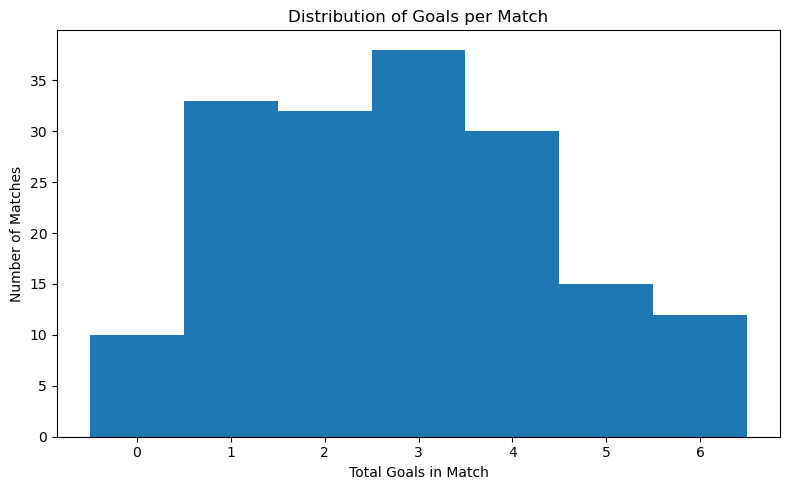

In [10]:
# Cell 128 - Goals Distribution

plt.figure(figsize=(8,5))

plt.hist(
    matches_df["TotalGoals"],
    bins=range(0,8),
    align="left"
)

plt.xlabel("Total Goals in Match")
plt.ylabel("Number of Matches")
plt.title("Distribution of Goals per Match")

plt.tight_layout()
plt.show()

In [11]:
# Cell 129 - Clean Sheets

clean_sheets = (
    results
    .assign(CleanSheet=(results["GA"] == 0).astype(int))
    .groupby(["Competition", "Team"])
    .agg(
        CleanSheets=("CleanSheet", "sum"),
        Matches=("Team", "count")
    )
    .reset_index()
)

clean_sheets["CleanSheetRate"] = (
    clean_sheets["CleanSheets"] /
    clean_sheets["Matches"]
).round(2)

clean_sheets = clean_sheets.sort_values(
    ["Competition", "CleanSheets"],
    ascending=[True, False]
)

clean_sheets


,Competition,Team,CleanSheets,Matches,CleanSheetRate
0,NLM-CZ,Dukes of Gloucester,1,3,0.33
3,NLM-CZ,Thika Rovers,1,1,1.00
1,NLM-CZ,GHF Rift Pirates Men,0,1,0.00
2,NLM-CZ,Nyari Hockey Club,0,1,0.00
4,NLM-EZ,Black Tigers,2,9,0.22
...,...,...,...,...,...
62,SLW,Wazalendo Pearls,1,6,0.17
54,SLW,Black Tigresses,0,1,0.00
55,SLW,Daystar University Ladies,0,5,0.00
57,SLW,Gorillas Hockey Club – Ladies,0,3,0.00


In [12]:
# Cell 130 - Save Clean Sheets

clean_sheets.to_csv(
    "../data/processed/clean_sheets.csv"
)

print("Clean sheets saved.")

Clean sheets saved.


In [13]:
# Cell 131 - Failed to Score

failed_score = (
    results
    .assign(FailedToScore=(results["GF"] == 0).astype(int))
    .groupby(["Competition", "Team"])
    .agg(
        FailedToScore=("FailedToScore","sum"),
        Matches=("Team","count")
    )
    .reset_index()
)

failed_score["Rate"] = (
    failed_score["FailedToScore"] /
    failed_score["Matches"]
).round(2)

failed_score = failed_score.sort_values(
    ["Competition", "FailedToScore"],
    ascending=[True, False]
)

failed_score


,Competition,Team,FailedToScore,Matches,Rate
0,NLM-CZ,Dukes of Gloucester,1,3,0.33
2,NLM-CZ,Nyari Hockey Club,1,1,1.00
1,NLM-CZ,GHF Rift Pirates Men,0,1,0.00
3,NLM-CZ,Thika Rovers,0,1,0.00
10,NLM-EZ,Snippers Hockey Club (Makueni),4,6,0.67
...,...,...,...,...,...
58,SLW,Lakers Hockey Club – B,1,6,0.17
59,SLW,Mombasa Sports Club Ladies,1,4,0.25
60,SLW,Swans Hockey Club,1,4,0.25
62,SLW,Wazalendo Pearls,1,6,0.17


In [14]:
# Cell 132 - Save Failed To Score

failed_score.to_csv(
    "../data/processed/failed_to_score.csv"
)

print("Failed-to-score summary saved.")

Failed-to-score summary saved.


In [15]:
# Cell 133 - Team Efficiency

efficiency = league_table.copy()

efficiency["GoalsPerPoint"] = (
    efficiency["GF"] /
    efficiency["Points"].replace(0, np.nan)
).round(2)

efficiency["PointsPerGoal"] = (
    efficiency["Points"] /
    efficiency["GF"].replace(0, np.nan)
).round(2)

efficiency[
    [
        "Competition",
        "Team",
        "Points",
        "GF",
        "GoalsPerPoint",
        "PointsPerGoal"
    ]
].sort_values(
    ["Competition", "PointsPerGoal"],
    ascending=[True, False]
)

,Competition,Team,Points,GF,GoalsPerPoint,PointsPerGoal
2,NLM-CZ,Dukes of Gloucester,3,6,2.00,0.50
1,NLM-CZ,Thika Rovers,3,8,2.67,0.38
0,NLM-CZ,GHF Rift Pirates Men,3,9,3.00,0.33
3,NLM-CZ,Nyari Hockey Club,0,0,NaN,NaN
8,NLM-EZ,UoN Cubs,9,6,0.67,1.50
...,...,...,...,...,...,...
54,SLW,Twinkle Hockey Club,13,13,1.00,1.00
59,SLW,Daystar University Ladies,3,3,1.00,1.00
60,SLW,Mombasa Sports Club Ladies,2,3,1.50,0.67
61,SLW,Gorillas Hockey Club – Ladies,0,2,NaN,0.00


In [16]:
# Cell 134 - Save Efficiency

efficiency.to_csv(
    "../data/processed/team_efficiency.csv",
    index=False
)

print("Team efficiency saved.")

Team efficiency saved.


In [17]:
# Cell 135 - Average Goals

avg_goals = matches_df["TotalGoals"].mean()

print(f"Average goals per match: {avg_goals:.2f}")

Average goals per match: 3.05


In [18]:
# Cell 136 - Highest Scoring Match

highest = matches_df.loc[
    matches_df["TotalGoals"].idxmax()
]

highest[
    [
        "Date",
        "HomeTeam",
        "AwayTeam",
        "HomeGoals",
        "AwayGoals",
        "TotalGoals"
    ]
]

Date                    21-06-2026
HomeTeam      GHF Rift Pirates Men
AwayTeam       Dukes of Gloucester
HomeGoals                        9
AwayGoals                        1
TotalGoals                      10
Name: 158, dtype: object

In [19]:
# Cell 141 - Goal Difference Ranking

gd_rank = (
    league_table[
        ["Competition",
        "Team", "GD"]
    ]
    .sort_values(
    ["Competition", "GD"],
    ascending=[True, False]
)
)

gd_rank

,Competition,Team,GD
0,NLM-CZ,GHF Rift Pirates Men,8
1,NLM-CZ,Thika Rovers,8
3,NLM-CZ,Nyari Hockey Club,-5
2,NLM-CZ,Dukes of Gloucester,-11
4,NLM-EZ,Ulinzi Patriots,6
...,...,...,...
58,SLW,Swans Hockey Club,0
60,SLW,Mombasa Sports Club Ladies,-2
61,SLW,Gorillas Hockey Club – Ladies,-4
59,SLW,Daystar University Ladies,-6


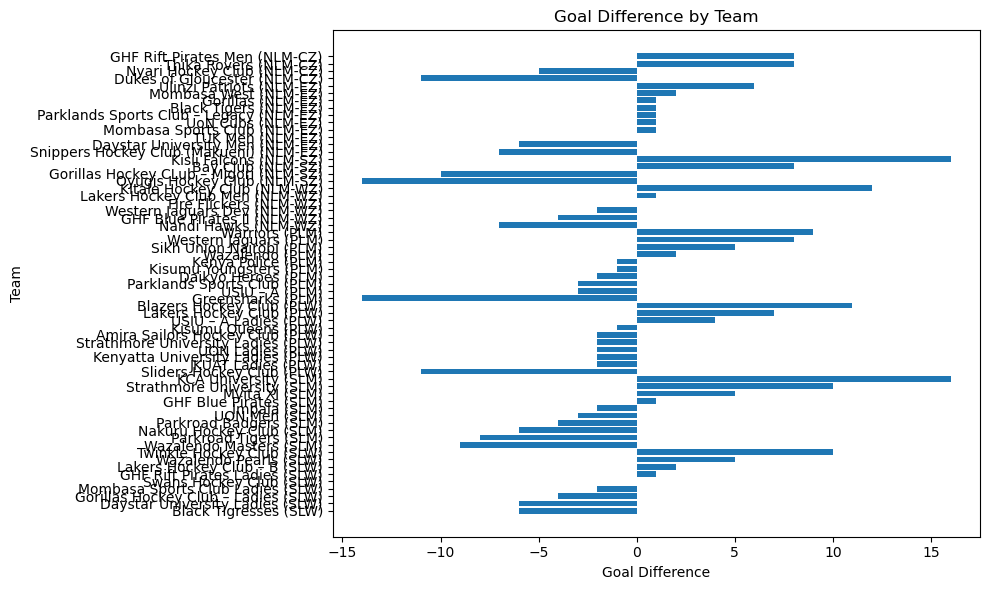

In [20]:
# Cell 142 - Plot Goal Difference

plt.figure(figsize=(10,6))

plt.barh(
    (gd_rank["Team"] + " (" + gd_rank["Competition"] + ")"),
    gd_rank["GD"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goal Difference")
plt.ylabel("Team")
plt.title("Goal Difference by Team")

plt.tight_layout()
plt.show()

In [21]:
# Cell 143 - Clean Sheets

clean_sheets = (
    results
    .assign(
        CleanSheet=(results["GA"] == 0).astype(int)
    )
    .groupby(["Competition", "Team"])
    .agg(
        CleanSheets=("CleanSheet","sum"),
        Matches=("Team","count")
    )
    .reset_index()
)

clean_sheets["CleanSheetRate"] = (
    clean_sheets["CleanSheets"] /
    clean_sheets["Matches"]
).round(2)

clean_sheets.sort_values(
    ["Competition", "CleanSheets"],
    ascending=[True, False]
)


,Competition,Team,CleanSheets,Matches,CleanSheetRate
0,NLM-CZ,Dukes of Gloucester,1,3,0.33
3,NLM-CZ,Thika Rovers,1,1,1.00
1,NLM-CZ,GHF Rift Pirates Men,0,1,0.00
2,NLM-CZ,Nyari Hockey Club,0,1,0.00
4,NLM-EZ,Black Tigers,2,9,0.22
...,...,...,...,...,...
62,SLW,Wazalendo Pearls,1,6,0.17
54,SLW,Black Tigresses,0,1,0.00
55,SLW,Daystar University Ladies,0,5,0.00
57,SLW,Gorillas Hockey Club – Ladies,0,3,0.00


In [22]:
# Cell 144 - Save Clean Sheets

clean_sheets.to_csv(
    "../data/processed/clean_sheets.csv"
)

print("Clean sheets saved.")

Clean sheets saved.


In [23]:
# Cell 146 - Points per Match

ppm = (
    league_table[
        ["Competition",
        "Team", "Played", "Points"]
    ]
    .copy()
)

ppm["PointsPerMatch"] = (
    ppm["Points"] /
    ppm["Played"]
).round(2)

ppm = ppm.sort_values(
    ["Competition", "PointsPerMatch"],
    ascending=[True, False]
)

ppm

,Competition,Team,Played,Points,PointsPerMatch
0,NLM-CZ,GHF Rift Pirates Men,1,3,3.00
1,NLM-CZ,Thika Rovers,1,3,3.00
2,NLM-CZ,Dukes of Gloucester,3,3,1.00
3,NLM-CZ,Nyari Hockey Club,1,0,0.00
4,NLM-EZ,Ulinzi Patriots,8,17,2.12
...,...,...,...,...,...
58,SLW,Swans Hockey Club,4,5,1.25
59,SLW,Daystar University Ladies,5,3,0.60
60,SLW,Mombasa Sports Club Ladies,4,2,0.50
61,SLW,Gorillas Hockey Club – Ladies,3,0,0.00


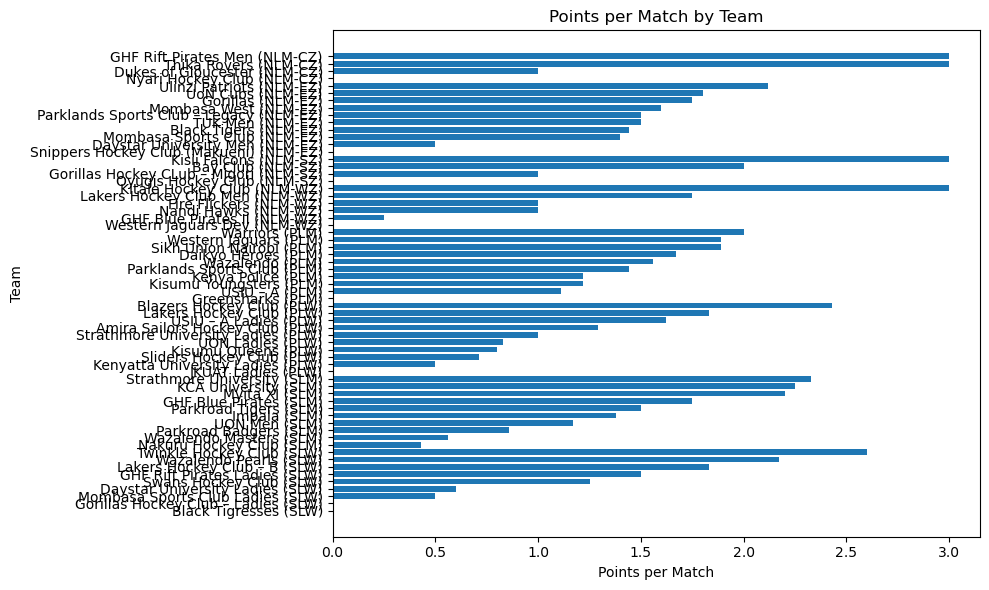

In [24]:
# Cell 147 - Plot Points per Match

plt.figure(figsize=(10,6))

plt.barh(
    (ppm["Team"] + " (" + ppm["Competition"] + ")"),
    ppm["PointsPerMatch"]
)

plt.gca().invert_yaxis()

plt.xlabel("Points per Match")
plt.ylabel("Team")
plt.title("Points per Match by Team")

plt.tight_layout()

plt.show()

In [25]:
# Cell 148 - Save Points per Match

ppm.to_csv(
    "../data/processed/points_per_match.csv",
    index=False
)

print("Points per match saved.")

Points per match saved.


In [26]:
# Cell 149 - Win Percentage

win_pct = (
    league_table[
        ["Competition",
        "Team", "Played", "Wins"]
    ]
    .copy()
)

win_pct["WinPercentage"] = (
    win_pct["Wins"] /
    win_pct["Played"] * 100
).round(1)

win_pct = win_pct.sort_values(
    ["Competition", "WinPercentage"],
    ascending=[True, False]
)

win_pct

,Competition,Team,Played,Wins,WinPercentage
0,NLM-CZ,GHF Rift Pirates Men,1,1,100.0
1,NLM-CZ,Thika Rovers,1,1,100.0
2,NLM-CZ,Dukes of Gloucester,3,1,33.3
3,NLM-CZ,Nyari Hockey Club,1,0,0.0
4,NLM-EZ,Ulinzi Patriots,8,5,62.5
...,...,...,...,...,...
58,SLW,Swans Hockey Club,4,1,25.0
59,SLW,Daystar University Ladies,5,1,20.0
60,SLW,Mombasa Sports Club Ladies,4,0,0.0
61,SLW,Gorillas Hockey Club – Ladies,3,0,0.0


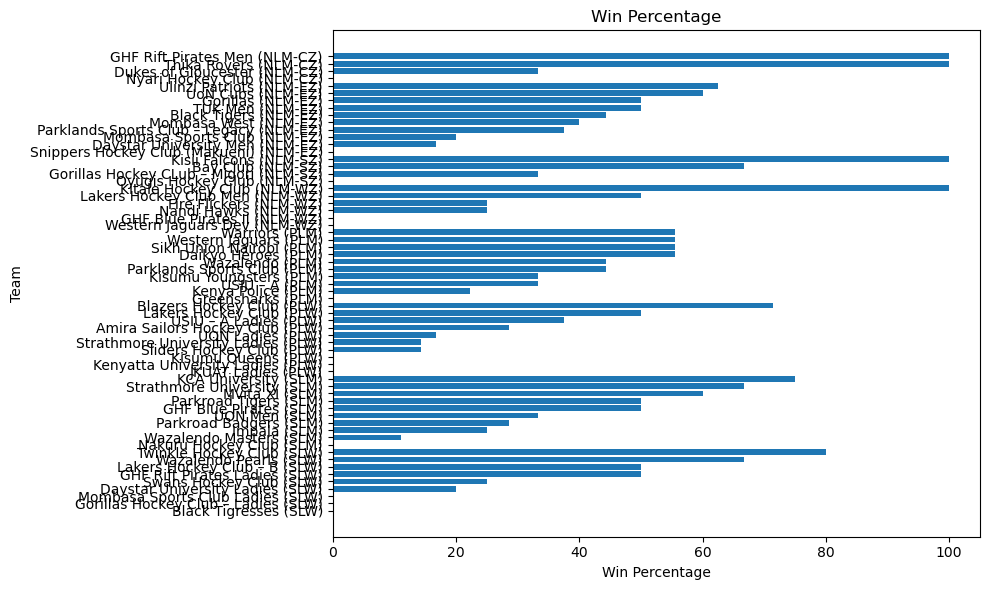

In [27]:
# Cell 150 - Plot Win Percentage

plt.figure(figsize=(10,6))

plt.barh(
    (win_pct["Team"] + " (" + win_pct["Competition"] + ")"),
    win_pct["WinPercentage"]
)

plt.gca().invert_yaxis()

plt.xlabel("Win Percentage")
plt.ylabel("Team")
plt.title("Win Percentage")

plt.tight_layout()

plt.show()

In [28]:
# Cell 151 - Attack Ranking

attack_rank = (
    league_table[
        ["Competition",
        "Team", "GF", "Played"]
    ]
    .copy()
)

attack_rank["GoalsPerGame"] = (
    attack_rank["GF"] /
    attack_rank["Played"]
).round(2)

attack_rank = attack_rank.sort_values(
    ["Competition", "GoalsPerGame"],
    ascending=[True, False]
)

attack_rank

,Competition,Team,GF,Played,GoalsPerGame
0,NLM-CZ,GHF Rift Pirates Men,9,1,9.00
1,NLM-CZ,Thika Rovers,8,1,8.00
2,NLM-CZ,Dukes of Gloucester,6,3,2.00
3,NLM-CZ,Nyari Hockey Club,0,1,0.00
11,NLM-EZ,TUK Men,4,2,2.00
...,...,...,...,...,...
58,SLW,Swans Hockey Club,4,4,1.00
60,SLW,Mombasa Sports Club Ladies,3,4,0.75
61,SLW,Gorillas Hockey Club – Ladies,2,3,0.67
59,SLW,Daystar University Ladies,3,5,0.60


In [29]:
# Cell 152 - Defence Ranking

defence_rank = (
    league_table[
        ["Competition",
        "Team", "GA", "Played"]
    ]
    .copy()
)

defence_rank["GoalsAgainstPerGame"] = (
    defence_rank["GA"] /
    defence_rank["Played"]
).round(2)

defence_rank = defence_rank.sort_values(
    ["Competition", "GoalsAgainstPerGame"],
    ascending=[True, True]
)

defence_rank

,Competition,Team,GA,Played,GoalsAgainstPerGame
1,NLM-CZ,Thika Rovers,0,1,0.00
0,NLM-CZ,GHF Rift Pirates Men,1,1,1.00
3,NLM-CZ,Nyari Hockey Club,5,1,5.00
2,NLM-CZ,Dukes of Gloucester,17,3,5.67
4,NLM-EZ,Ulinzi Patriots,8,8,1.00
...,...,...,...,...,...
57,SLW,GHF Rift Pirates Ladies,7,6,1.17
60,SLW,Mombasa Sports Club Ladies,5,4,1.25
59,SLW,Daystar University Ladies,9,5,1.80
61,SLW,Gorillas Hockey Club – Ladies,6,3,2.00


In [30]:
# Cell 153 - Team Strength Index

strength = attack_rank.merge(
    defence_rank[
        ["Competition",
        "Team", "GoalsAgainstPerGame"]
    ],
    on=["Competition", "Team"]
)

strength["StrengthIndex"] = (
    strength["GoalsPerGame"] -
    strength["GoalsAgainstPerGame"]
).round(2)

strength = strength.sort_values(
    ["Competition", "StrengthIndex"],
    ascending=[True, False]
)

strength

,Competition,Team,GF,Played,GoalsPerGame,GoalsAgainstPerGame,StrengthIndex
0,NLM-CZ,GHF Rift Pirates Men,9,1,9.00,1.00,8.00
1,NLM-CZ,Thika Rovers,8,1,8.00,0.00,8.00
2,NLM-CZ,Dukes of Gloucester,6,3,2.00,5.67,-3.67
3,NLM-CZ,Nyari Hockey Club,0,1,0.00,5.00,-5.00
5,NLM-EZ,Ulinzi Patriots,14,8,1.75,1.00,0.75
...,...,...,...,...,...,...,...
58,SLW,Swans Hockey Club,4,4,1.00,1.00,0.00
59,SLW,Mombasa Sports Club Ladies,3,4,0.75,1.25,-0.50
61,SLW,Daystar University Ladies,3,5,0.60,1.80,-1.20
60,SLW,Gorillas Hockey Club – Ladies,2,3,0.67,2.00,-1.33


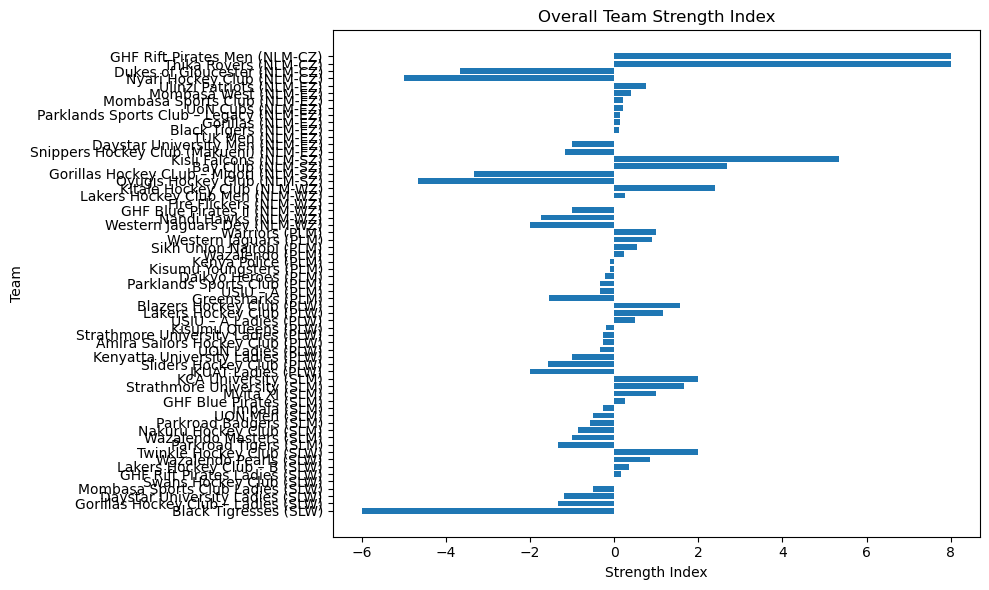

In [31]:
# Cell 154 - Plot Team Strength

plt.figure(figsize=(10,6))

plt.barh(
    (strength["Team"] + " (" + strength["Competition"] + ")"),
    strength["StrengthIndex"]
)

plt.gca().invert_yaxis()

plt.xlabel("Strength Index")
plt.ylabel("Team")
plt.title("Overall Team Strength Index")

plt.tight_layout()

plt.show()

In [32]:
# Cell 155 - Save Team Strength

strength.to_csv(
    "../data/processed/team_strength.csv",
    index=False
)

print("Team strength saved.")

Team strength saved.


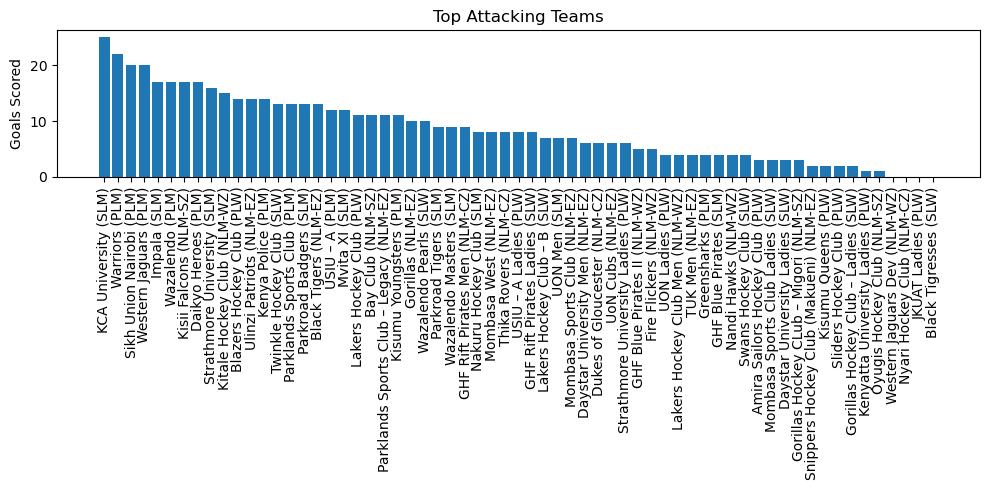

In [33]:
# Cell 156 - Top Attacking Teams

plt.figure(figsize=(10,5))

attack = league_table.sort_values(
    "GF",
    ascending=False
)

plt.bar(
    (attack["Team"] + " (" + attack["Competition"] + ")"),
    attack["GF"]
)

plt.xticks(rotation=90)

plt.ylabel("Goals Scored")

plt.title("Top Attacking Teams")

plt.tight_layout()

plt.show()

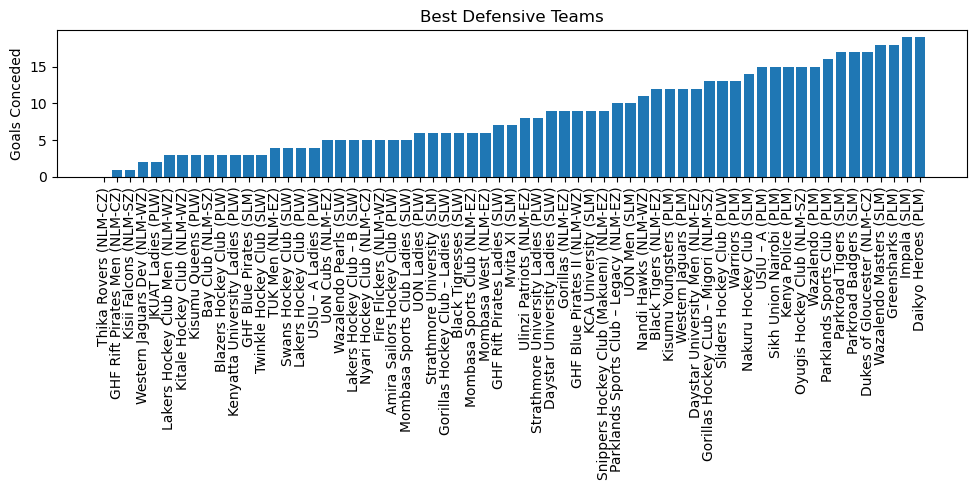

In [34]:
# Cell 157 - Best Defensive Teams

plt.figure(figsize=(10,5))

defence = league_table.sort_values(
    "GA"
)

plt.bar(
    (defence["Team"] + " (" + defence["Competition"] + ")"),
    defence["GA"]
)

plt.xticks(rotation=90)

plt.ylabel("Goals Conceded")

plt.title("Best Defensive Teams")

plt.tight_layout()

plt.show()

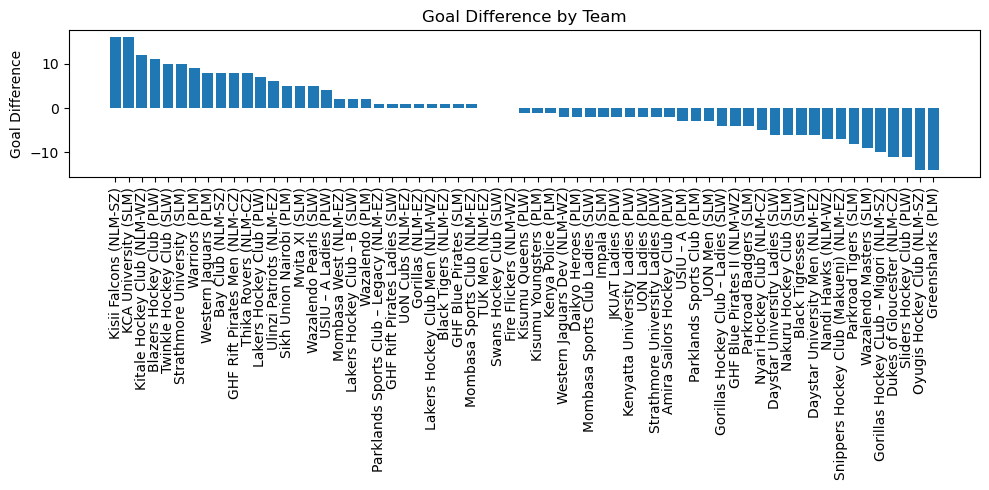

In [35]:
# Cell 158 - Goal Difference Chart

plt.figure(figsize=(10,5))

gd = league_table.sort_values(
    "GD",
    ascending=False
)

plt.bar(
    (gd["Team"] + " (" + gd["Competition"] + ")"),
    gd["GD"]
)

plt.xticks(rotation=90)

plt.ylabel("Goal Difference")

plt.title("Goal Difference by Team")

plt.tight_layout()

plt.show()

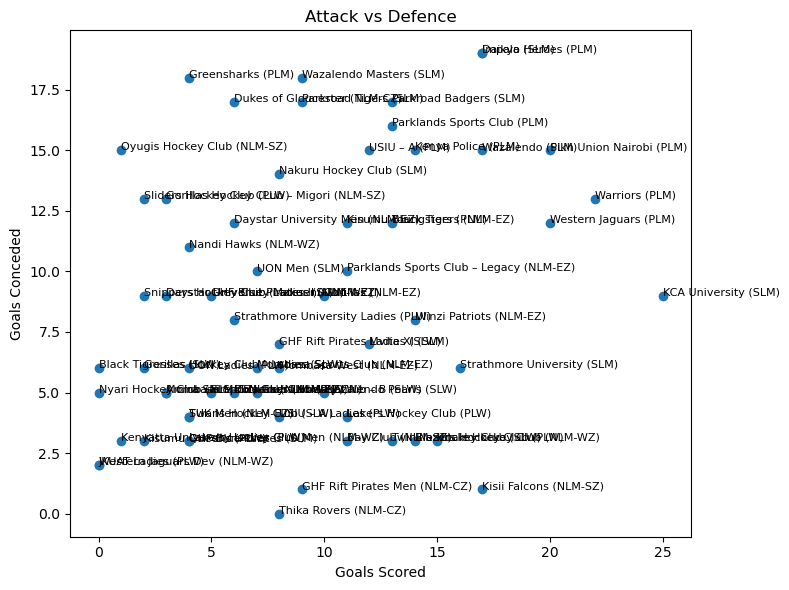

In [36]:
# Cell 159 - Goals For vs Goals Against

plt.figure(figsize=(8,6))

plt.scatter(
    league_table["GF"],
    league_table["GA"]
)

for i, row in league_table.iterrows():

    plt.text(
        row["GF"],
        row["GA"],
        f'{row["Team"]} ({row["Competition"]})',
        fontsize=8
    )

plt.xlabel("Goals Scored")

plt.ylabel("Goals Conceded")

plt.title("Attack vs Defence")

plt.tight_layout()

plt.show()

In [37]:
# Cell 160 - Save Attack vs Defence

attack_defence = league_table[
    [
        "Competition",
        "Team",
        "GF",
        "GA",
        "GD"
    ]
]

attack_defence.to_csv(
    "../data/processed/attack_vs_defence.csv",
    index=False
)

print("Attack vs Defence saved.")

Attack vs Defence saved.


In [38]:
# Cell 161 - Team Discipline Ranking

discipline = (
    events_df[
        events_df["Event"] != "Goal"
    ]
    .groupby(["Competition", "Team"])
    .size()
    .reset_index(name="Cards")
    .sort_values(
        ["Competition", "Cards"],
        ascending=[True, False]
    )
)

discipline


,Competition,Team,Cards
2,PLM,Kisumu Youngsters,15
3,PLM,Parklands Sports Club,15
1,PLM,Greensharks,14
7,PLM,Wazalendo,10
6,PLM,Warriors,8
8,PLM,Western Jaguars,8
4,PLM,Sikh Union Nairobi,7
0,PLM,Daikyo Heroes,6
5,PLM,USIU – A,6
18,PLW,USIU – A Ladies,4


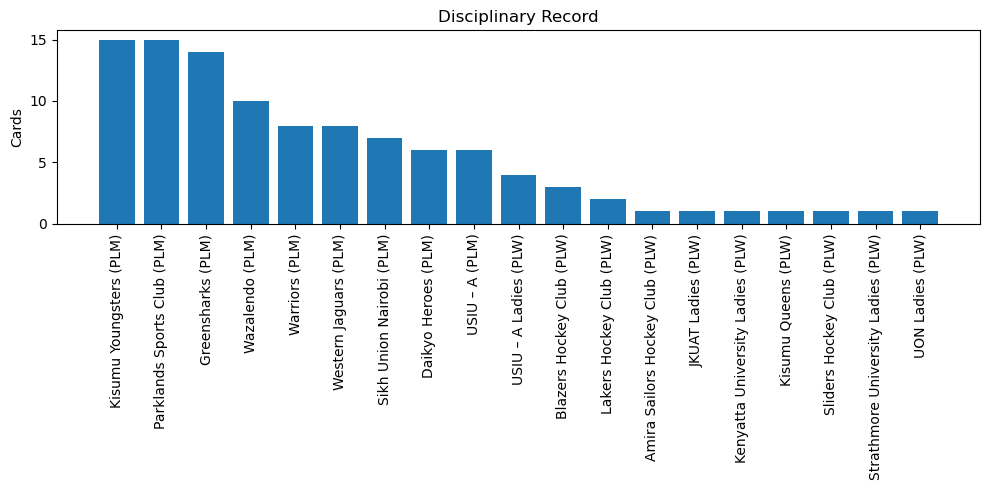

In [39]:
# Cell 162 - Plot Discipline

plt.figure(figsize=(10,5))

plt.bar(
    (discipline["Team"] + " (" + discipline["Competition"] + ")"),
    discipline["Cards"]
)

plt.xticks(rotation=90)

plt.ylabel("Cards")

plt.title("Disciplinary Record")

plt.tight_layout()

plt.show()

In [40]:
# Cell 163 - Save Discipline Table

discipline.to_csv(
    "../data/processed/team_discipline.csv",
    index=False
)

print("Team discipline saved.")

Team discipline saved.


In [41]:
# Cell 164 - Average Goals per Match

avg_goals = round(
    matches_df["TotalGoals"].mean(),
    2
)

print("Average goals per match:", avg_goals)

Average goals per match: 3.05


In [42]:
# Cell 165 - League Statistics

print("="*60)

print("LEAGUE STATISTICS")

print("="*60)

print("Matches:", len(matches_df))

print("Teams:", results["Team"].nunique())

print("Goals:", matches_df["TotalGoals"].sum())

print("Average Goals:", round(matches_df["TotalGoals"].mean(),2))

print("Highest Score:",
      matches_df["TotalGoals"].max())

print("="*60)

LEAGUE STATISTICS
Matches: 177
Teams: 63
Goals: 540
Average Goals: 3.05
Highest Score: 10


In [43]:
# Cell 166 - Goals by Player

player_goals = (
    events_df[
        events_df["Event"] == "Goal"
    ]
    .groupby("Player")
    .size()
    .reset_index(name="Goals")
    .sort_values(
        "Goals",
        ascending=False
    )
)

player_goals

,Player,Goals
48,Mathias Gularire,6
56,Robert Masibo,4
45,Malack Masese,4
33,Job Wandera,4
8,Calvins Kanu Omondi,3
...,...,...
1,Amanda Ijai,1
34,Jochebed Cherono,1
35,Joseph Kasua,1
37,Kennedy Sibweche,1


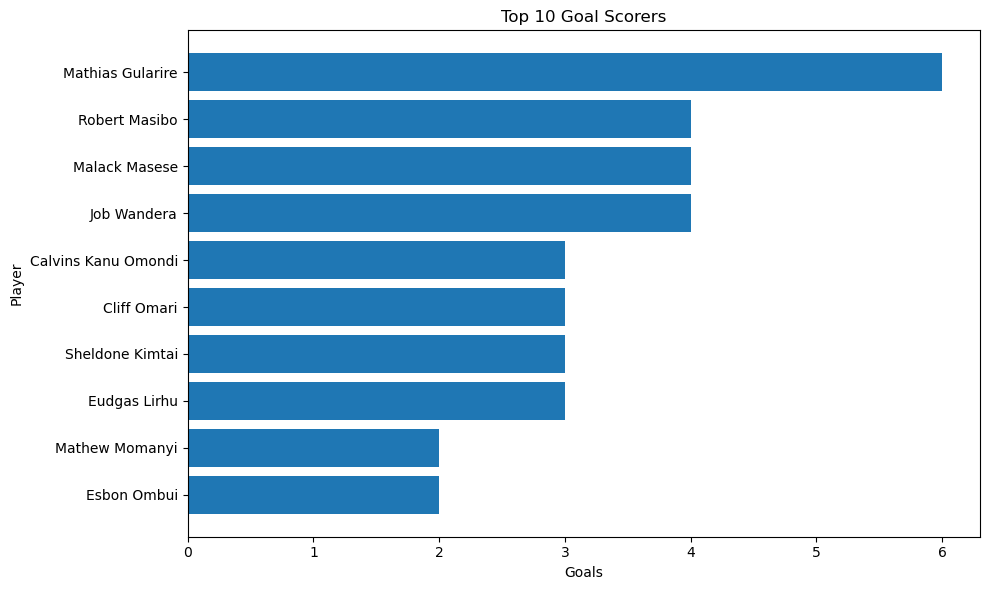

In [44]:
# Cell 167 - Top 10 Goal Scorers

plt.figure(figsize=(10,6))

top10 = player_goals.head(10)

plt.barh(
    top10["Player"],
    top10["Goals"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goals")
plt.ylabel("Player")
plt.title("Top 10 Goal Scorers")

plt.tight_layout()

plt.show()

In [45]:
# Cell 168 - Goals by Team

player_team_goals = (
    events_df[
        events_df["Event"] == "Goal"
    ]
    .groupby(["Competition", "Team","Player"])
    .size()
    .reset_index(name="Goals")
    .sort_values(
        ["Competition", "Team","Goals"],
        ascending=[True, True,False]
    )
)

player_team_goals


,Competition,Team,Player,Goals
0,PLM,Daikyo Heroes,Bonny Ndombi,2
1,PLM,Daikyo Heroes,Esbon Ombui,2
2,PLM,Daikyo Heroes,Farhan Khan,2
3,PLM,Daikyo Heroes,Joseph Kasua,1
4,PLM,Daikyo Heroes,Khizar Akhtar,1
...,...,...,...,...
60,PLW,UON Ladies,Clementine Sims,1
61,PLW,UON Ladies,Mitchell Akoth,1
62,PLW,UON Ladies,Noela Kimathi,1
64,PLW,USIU – A Ladies,Lynn Mwangi,2


In [46]:
# Cell 169 - Team Top Scorer

team_top_scorers = (
    player_team_goals
    .sort_values(
        "Goals",
        ascending=False
    )
    .drop_duplicates("Team")
)

team_top_scorers

,Competition,Team,Player,Goals
24,PLM,Sikh Union Nairobi,Mathias Gularire,6
9,PLM,Kenya Police,Robert Masibo,4
39,PLM,Wazalendo,Job Wandera,4
13,PLM,Kisumu Youngsters,Malack Masese,4
15,PLM,Parklands Sports Club,Eudgas Lirhu,3
30,PLM,Warriors,Calvins Kanu Omondi,3
48,PLM,Western Jaguars,Sheldone Kimtai,3
1,PLM,Daikyo Heroes,Esbon Ombui,2
52,PLW,Blazers Hockey Club,Caroline Guchu,2
27,PLM,USIU – A,Lawrence Makhatsa,2


In [47]:
# Cell 170 - Save Team Top Scorers

team_top_scorers.to_csv(
    "../data/processed/team_top_scorers.csv",
    index=False
)

print("Team top scorers saved.")

Team top scorers saved.


In [48]:
# Cell 171 - Green Cards by Player

green_cards = (
    events_df[
        events_df["Event"] == "Green Card"
    ]
    .groupby("Player")
    .size()
    .reset_index(name="GreenCards")
    .sort_values(
        "GreenCards",
        ascending=False
    )
)

green_cards

,Player,GreenCards
10,Calvins Kanu Omondi,3
37,Michael Mboya,3
39,Moses Omamu,2
30,Joan Ajao,2
50,Willis Malesi,2
18,Elvis Young Adala,2
16,Duncan Kachisa,2
0,Allan Iningu,1
31,Job Wandera,1
32,Kennedy Juma,1


In [49]:
# Cell 172 - Yellow Cards by Player

yellow_cards = (
    events_df[
        events_df["Event"] == "Yellow card"
    ]
    .groupby("Player")
    .size()
    .reset_index(name="YellowCards")
    .sort_values(
        "YellowCards",
        ascending=False
    )
)

yellow_cards

,Player,YellowCards
34,Willis Wanjala,3
10,Cyprian Mukhokho,2
11,Daniel Matara,2
15,Griffin Bosire,2
12,Daniel Solomon Obunyasi,2
22,Khizar Akhtar,1
23,Lawrence Okongo,1
24,Malack Masese,1
25,Mathias Gularire,1
26,Moses Omamu,1


In [50]:
# Cell 173 - Combine Player Discipline

discipline_players = (
    pd.merge(
        green_cards,
        yellow_cards,
        on="Player",
        how="outer"
    )
    .fillna(0)
)

discipline_players["GreenCards"] = discipline_players["GreenCards"].astype(int)
discipline_players["YellowCards"] = discipline_players["YellowCards"].astype(int)

discipline_players

,Player,GreenCards,YellowCards
0,Allan Iningu,1,0
1,Allan Munene,0,1
2,Aredha Mandela,1,0
3,Arjun Uupta,1,1
4,Arnold Abedie,0,1
...,...,...,...
69,William Kirwa,1,0
70,Willis Malesi,2,1
71,Willis Wanjala,0,3
72,Wycliffe Wanyonyi,1,1


In [51]:
# Cell 174 - Total Cards

discipline_players["TotalCards"] = (
    discipline_players["GreenCards"] +
    discipline_players["YellowCards"]
)

discipline_players = discipline_players.sort_values(
    "TotalCards",
    ascending=False
)

discipline_players

,Player,GreenCards,YellowCards,TotalCards
14,Calvins Kanu Omondi,3,0,3
32,Griffin Bosire,1,2,3
71,Willis Wanjala,0,3,3
54,Moses Omamu,2,1,3
70,Willis Malesi,2,1,3
...,...,...,...,...
38,Irene Senoi,1,0,1
39,Isaac Nandukele,1,0,1
40,Ivan Ludiali,0,1,1
42,Job Wandera,1,0,1


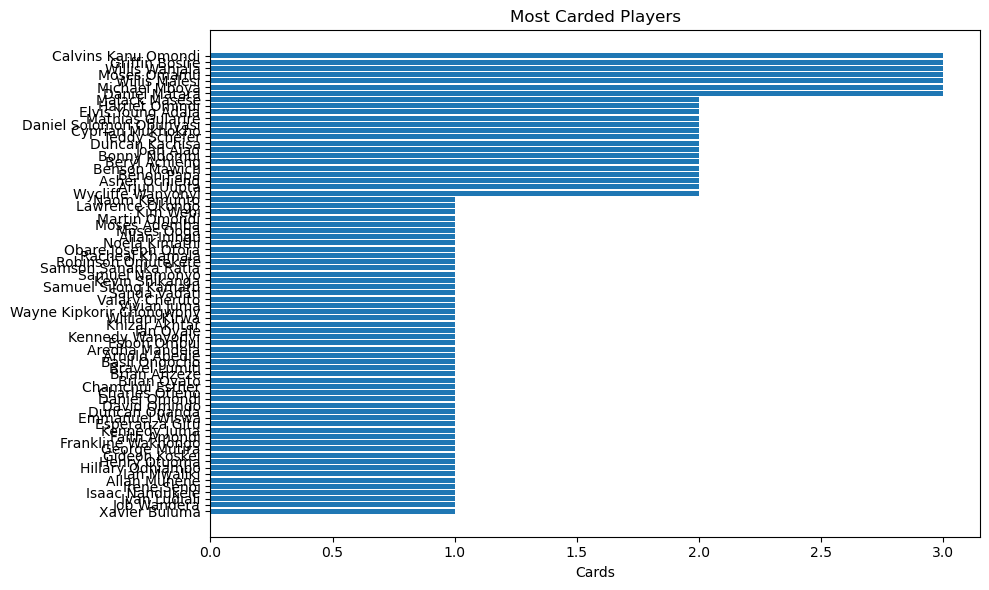

In [52]:
# Cell 175 - Plot Most Carded Players

plt.figure(figsize=(10,6))

plt.barh(
    discipline_players["Player"],
    discipline_players["TotalCards"]
)

plt.gca().invert_yaxis()

plt.xlabel("Cards")

plt.title("Most Carded Players")

plt.tight_layout()

plt.show()

In [53]:
# Cell 176 - Player Event Summary

player_summary = (
    events_df
    .groupby(["Player", "Event"])
    .size()
    .unstack(fill_value=0)
)

player_summary

Event,Goal,Green Card,Red Card,Yellow card
Player,,,,
Alex Taiswa,1,0,0,0
Allan Iningu,0,1,0,0
Allan Munene,0,0,0,1
Amanda Ijai,1,0,0,0
Aredha Mandela,0,1,0,0
...,...,...,...,...
Willis Okeyo,1,0,0,0
Willis Wanjala,0,0,0,3
Wycliffe Wanyonyi,0,1,0,1


In [54]:
# Cell 177 - Total Events per Player

player_summary["TotalEvents"] = (
    player_summary.sum(axis=1)
)

player_summary = player_summary.sort_values(
    "TotalEvents",
    ascending=False
)

player_summary

Event,Goal,Green Card,Red Card,Yellow card,TotalEvents
Player,,,,,
Mathias Gularire,6,1,0,1,8
Calvins Kanu Omondi,3,3,0,0,6
Malack Masese,4,1,0,1,6
Michael Mboya,2,3,0,0,5
Job Wandera,4,1,0,0,5
...,...,...,...,...,...
Grace Makoha,1,0,0,0,1
Gideon Koskei,0,1,0,0,1
Francis Kariuki,1,0,0,0,1


In [55]:
# Cell 178 - Save Player Summary

player_summary.to_csv(
    "../data/processed/player_summary.csv"
)

print("Player summary saved.")

Player summary saved.


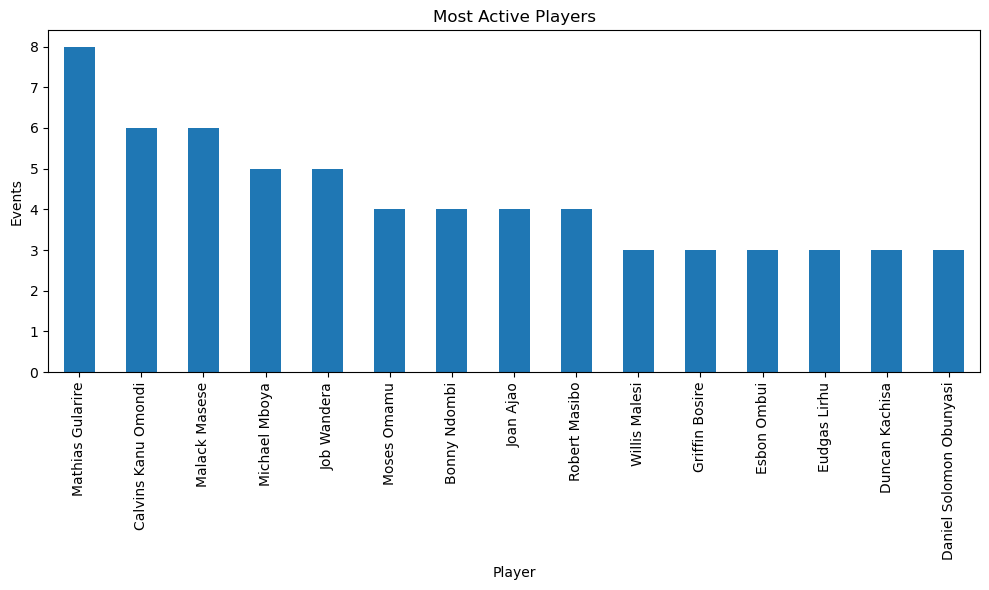

In [56]:
# Cell 179 - Top Active Players

plt.figure(figsize=(10,6))

player_summary["TotalEvents"].head(15).plot.bar()

plt.ylabel("Events")
plt.title("Most Active Players")

plt.tight_layout()

plt.show()

In [57]:
# Cell 181 - Goals by Venue

venue_goals = (
    results
    .groupby("Venue")
    .agg(
        GoalsFor=("GF", "sum"),
        GoalsAgainst=("GA", "sum"),
        Matches=("Team", "count")
    )
)

venue_goals["GoalsPerMatch"] = (
    venue_goals["GoalsFor"] /
    venue_goals["Matches"]
).round(2)

venue_goals

,GoalsFor,GoalsAgainst,Matches,GoalsPerMatch
Venue,,,,
Away,275,265,177,1.55
Home,265,275,177,1.50


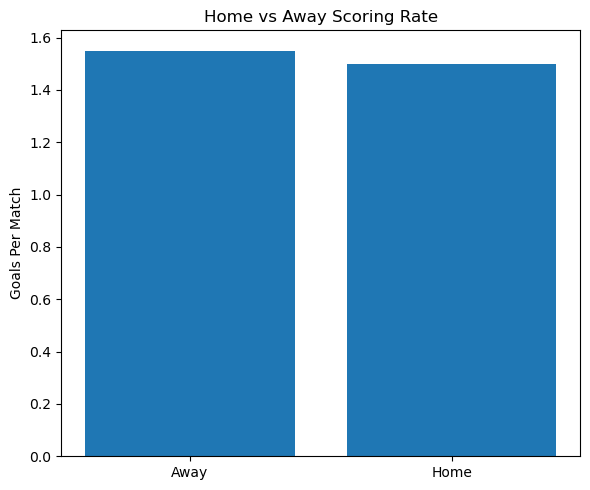

In [58]:
# Cell 182 - Home vs Away Goals Chart

plt.figure(figsize=(6,5))

plt.bar(
    venue_goals.index,
    venue_goals["GoalsPerMatch"]
)

plt.ylabel("Goals Per Match")
plt.title("Home vs Away Scoring Rate")

plt.tight_layout()
plt.show()

In [59]:
# Cell 183 - Team Discipline Ranking

team_cards = (
    cards
    .groupby(["Competition", "Team"])
    .size()
    .reset_index(name="Cards")
    .sort_values(
        ["Competition", "Cards"],
        ascending=[True, False]
    )
)

team_cards


,Competition,Team,Cards
2,PLM,Kisumu Youngsters,15
3,PLM,Parklands Sports Club,15
1,PLM,Greensharks,14
7,PLM,Wazalendo,10
6,PLM,Warriors,8
8,PLM,Western Jaguars,8
4,PLM,Sikh Union Nairobi,7
0,PLM,Daikyo Heroes,6
5,PLM,USIU – A,6
18,PLW,USIU – A Ladies,4


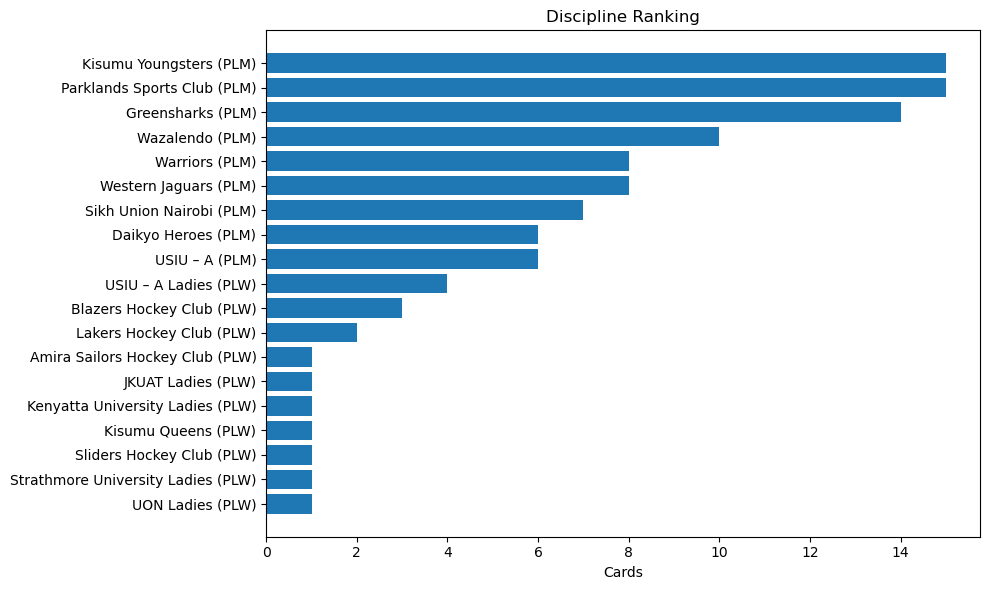

In [60]:
# Cell 184 - Team Discipline Chart

plt.figure(figsize=(10,6))

plt.barh(
    (team_cards["Team"] + " (" + team_cards["Competition"] + ")"),
    team_cards["Cards"]
)

plt.gca().invert_yaxis()

plt.xlabel("Cards")
plt.title("Discipline Ranking")

plt.tight_layout()
plt.show()

In [61]:
# Cell 185 - Save Discipline Ranking

team_cards.to_csv(
    "../data/processed/team_cards.csv",
    index=False
)

print("Team cards saved.")

Team cards saved.


In [62]:
# Cell 186 - Top Goal Scoring Teams

attack = (
    results
    .groupby(["Competition", "Team"])["GF"]
    .sum()
    .reset_index()
    .sort_values(["Competition", "GF"], ascending=[True, False])
)

attack


,Competition,Team,GF
1,NLM-CZ,GHF Rift Pirates Men,9
3,NLM-CZ,Thika Rovers,8
0,NLM-CZ,Dukes of Gloucester,6
2,NLM-CZ,Nyari Hockey Club,0
12,NLM-EZ,Ulinzi Patriots,14
...,...,...,...
60,SLW,Swans Hockey Club,4
55,SLW,Daystar University Ladies,3
59,SLW,Mombasa Sports Club Ladies,3
57,SLW,Gorillas Hockey Club – Ladies,2


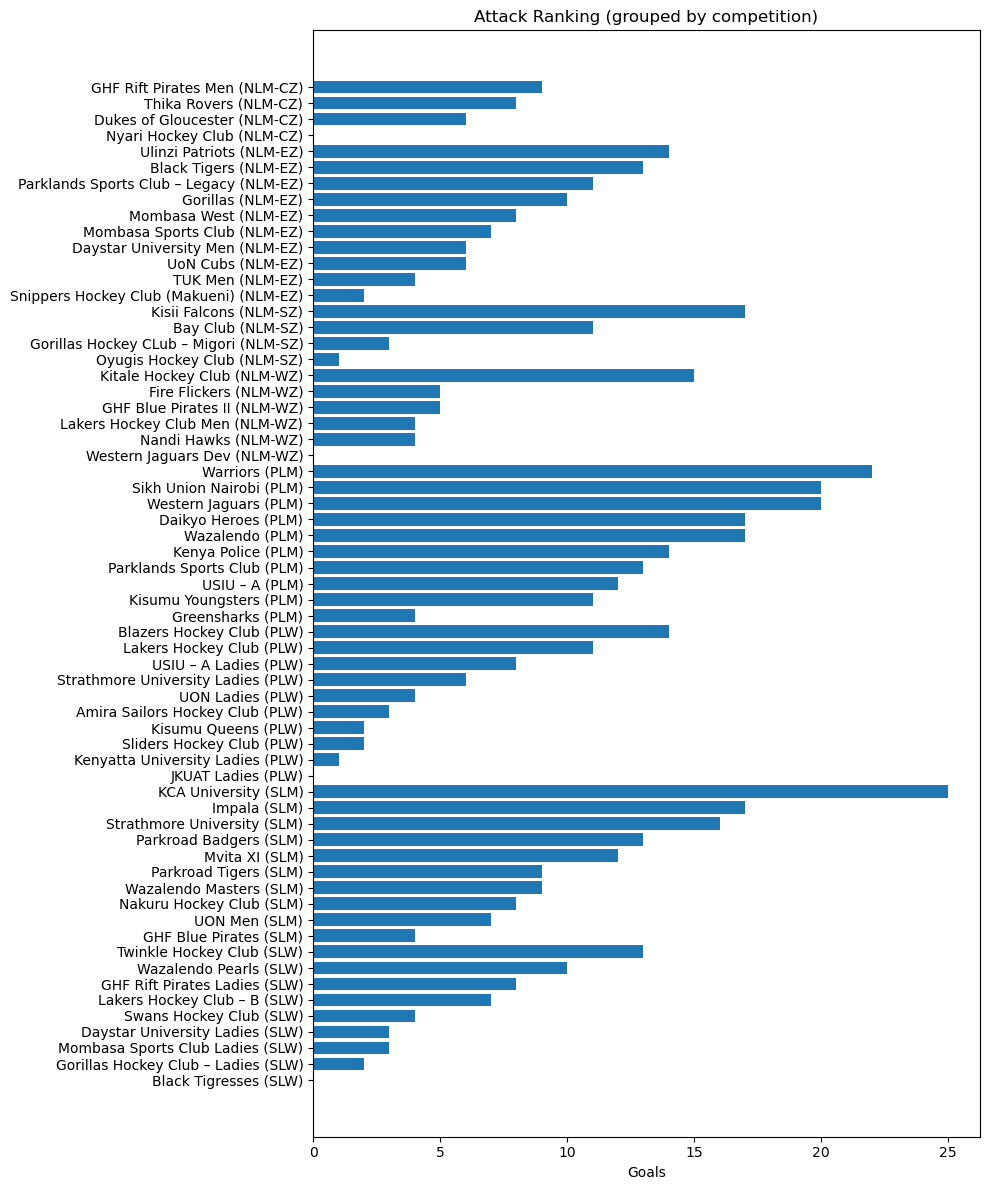

In [63]:
# Cell 187 - Attack Ranking Chart

labels = attack["Team"] + " (" + attack["Competition"] + ")"

plt.figure(figsize=(10, 12))

plt.barh(
    labels,
    attack["GF"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goals")
plt.title("Attack Ranking (grouped by competition)")

plt.tight_layout()
plt.show()


In [64]:
# Cell 188 - Defensive Ranking

defence = (
    results
    .groupby(["Competition", "Team"])["GA"]
    .sum()
    .reset_index()
    .sort_values(["Competition", "GA"], ascending=[True, True])
)

defence


,Competition,Team,GA
3,NLM-CZ,Thika Rovers,0
1,NLM-CZ,GHF Rift Pirates Men,1
2,NLM-CZ,Nyari Hockey Club,5
0,NLM-CZ,Dukes of Gloucester,17
11,NLM-EZ,TUK Men,4
...,...,...,...
62,SLW,Wazalendo Pearls,5
54,SLW,Black Tigresses,6
57,SLW,Gorillas Hockey Club – Ladies,6
56,SLW,GHF Rift Pirates Ladies,7


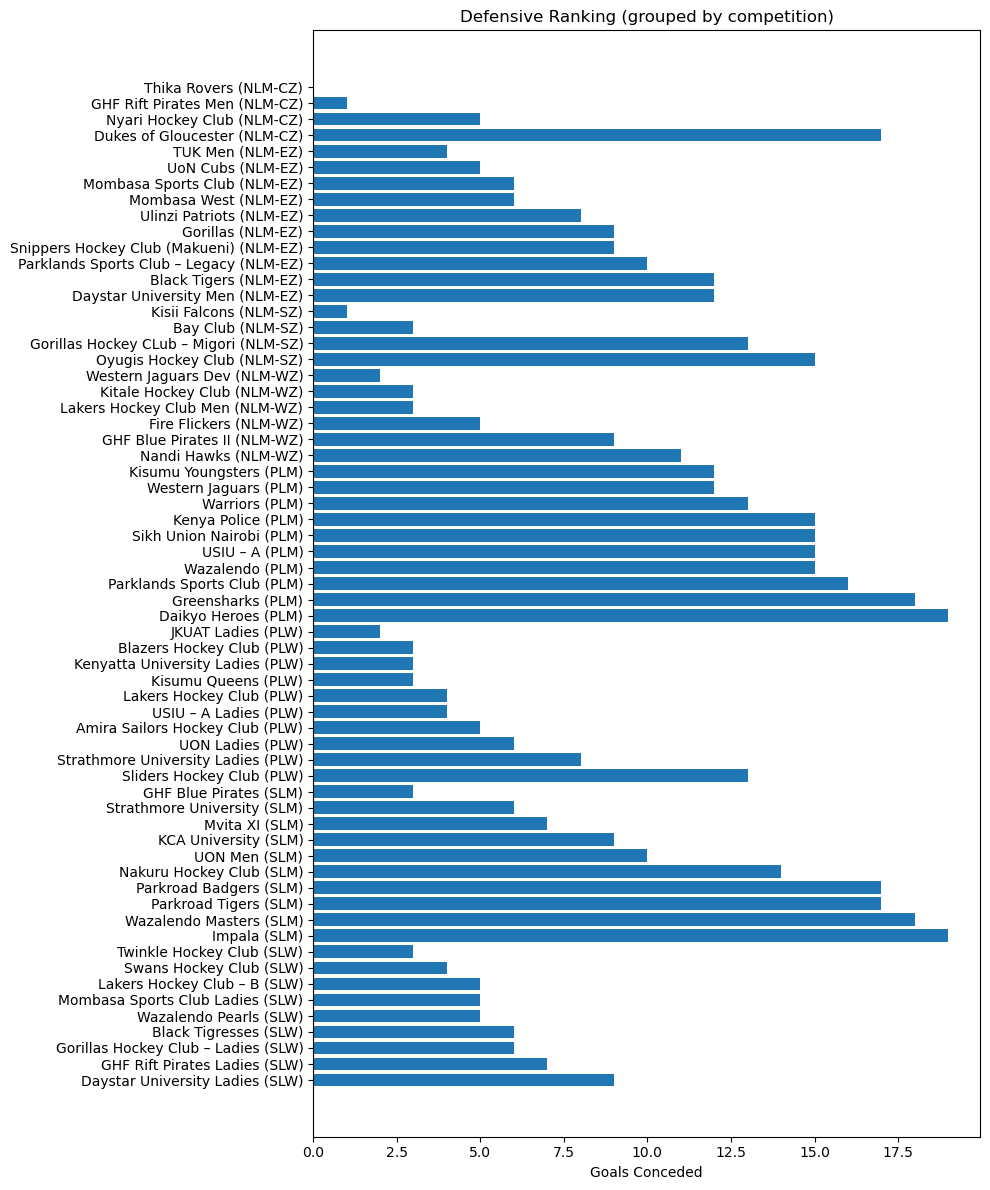

In [65]:
# Cell 189 - Defensive Ranking Chart

labels = defence["Team"] + " (" + defence["Competition"] + ")"

plt.figure(figsize=(10, 12))

plt.barh(
    labels,
    defence["GA"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goals Conceded")
plt.title("Defensive Ranking (grouped by competition)")

plt.tight_layout()
plt.show()


In [66]:
# Cell 190 - Save Attack & Defence

attack.to_csv(
    "../data/processed/attack_ranking.csv"
)

defence.to_csv(
    "../data/processed/defence_ranking.csv"
)

print("Attack and defence rankings saved.")

Attack and defence rankings saved.


In [67]:
# Cell 191 - Team Efficiency Rating

efficiency = league_table.copy()

efficiency["Efficiency"] = (
    (
        efficiency["GF"] -
        efficiency["GA"]
    )
    / efficiency["Played"]
).round(2)

efficiency[
    [
        "Competition",
        "Team",
        "Played",
        "GF",
        "GA",
        "Efficiency"
    ]
].sort_values(
    ["Competition", "Efficiency"],
    ascending=[True, False]
)

,Competition,Team,Played,GF,GA,Efficiency
0,NLM-CZ,GHF Rift Pirates Men,1,9,1,8.00
1,NLM-CZ,Thika Rovers,1,8,0,8.00
2,NLM-CZ,Dukes of Gloucester,3,6,17,-3.67
3,NLM-CZ,Nyari Hockey Club,1,0,5,-5.00
4,NLM-EZ,Ulinzi Patriots,8,14,8,0.75
...,...,...,...,...,...,...
58,SLW,Swans Hockey Club,4,4,4,0.00
60,SLW,Mombasa Sports Club Ladies,4,3,5,-0.50
59,SLW,Daystar University Ladies,5,3,9,-1.20
61,SLW,Gorillas Hockey Club – Ladies,3,2,6,-1.33


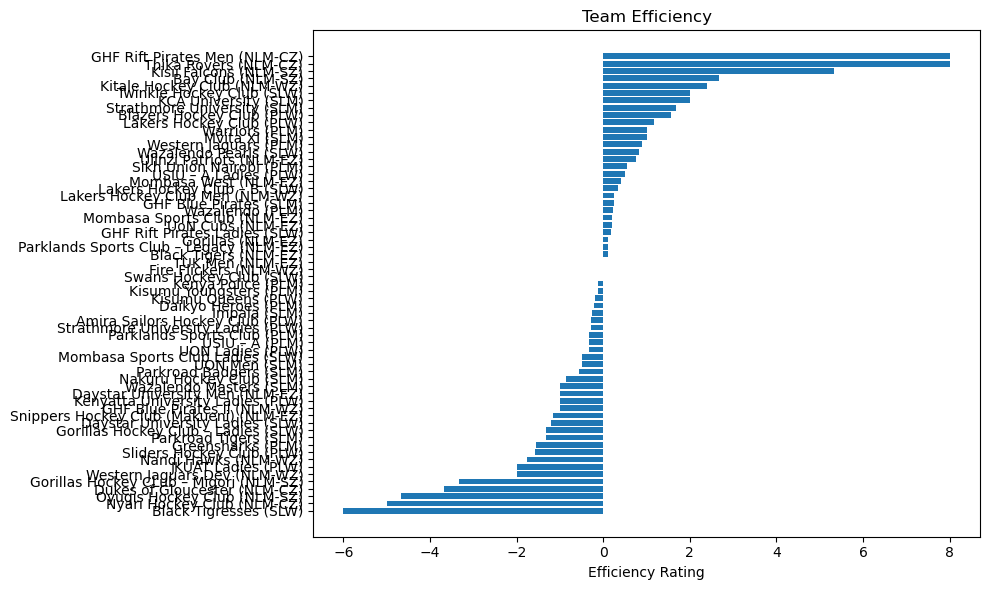

In [68]:
# Cell 192 - Efficiency Chart

plt.figure(figsize=(10,6))

ordered = efficiency.sort_values("Efficiency")

plt.barh(
    (ordered["Team"] + " (" + ordered["Competition"] + ")"),
    ordered["Efficiency"]
)

plt.xlabel("Efficiency Rating")
plt.title("Team Efficiency")

plt.tight_layout()
plt.show()

In [69]:
# Cell 193 - Win Percentage

win_rate = league_table.copy()

win_rate["WinPercent"] = (
    100 *
    win_rate["Wins"] /
    win_rate["Played"]
).round(1)

win_rate[
    [
        "Competition",
        "Team",
        "WinPercent"
    ]
].sort_values(
    ["Competition", "WinPercent"],
    ascending=[True, False]
)

,Competition,Team,WinPercent
0,NLM-CZ,GHF Rift Pirates Men,100.0
1,NLM-CZ,Thika Rovers,100.0
2,NLM-CZ,Dukes of Gloucester,33.3
3,NLM-CZ,Nyari Hockey Club,0.0
4,NLM-EZ,Ulinzi Patriots,62.5
...,...,...,...
58,SLW,Swans Hockey Club,25.0
59,SLW,Daystar University Ladies,20.0
60,SLW,Mombasa Sports Club Ladies,0.0
61,SLW,Gorillas Hockey Club – Ladies,0.0


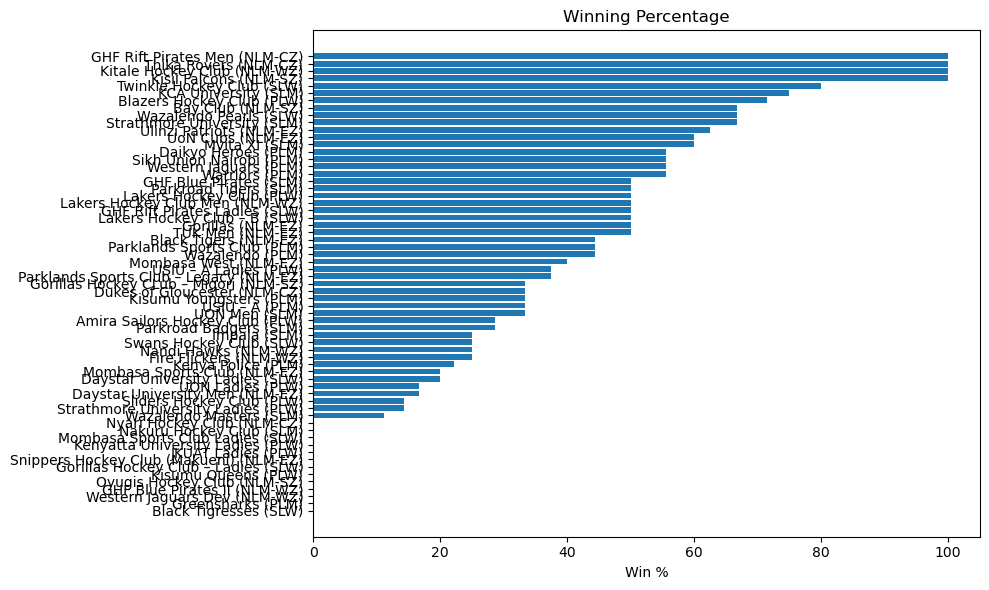

In [70]:
# Cell 194 - Win Percentage Chart

plt.figure(figsize=(10,6))

ordered = win_rate.sort_values("WinPercent")

plt.barh(
    (ordered["Team"] + " (" + ordered["Competition"] + ")"),
    ordered["WinPercent"]
)

plt.xlabel("Win %")
plt.title("Winning Percentage")

plt.tight_layout()
plt.show()

In [71]:
# Cell 195 - Goals Needed Per Win

goal_efficiency = league_table.copy()

goal_efficiency["GoalsPerWin"] = (
    goal_efficiency["GF"] /
    goal_efficiency["Wins"].replace(0, np.nan)
).round(2)

goal_efficiency[
    [
        "Competition",
        "Team",
        "GoalsPerWin"
    ]
].sort_values(
    ["Competition", "GoalsPerWin"],
    ascending=[True, True]
)

,Competition,Team,GoalsPerWin
2,NLM-CZ,Dukes of Gloucester,6.00
1,NLM-CZ,Thika Rovers,8.00
0,NLM-CZ,GHF Rift Pirates Men,9.00
3,NLM-CZ,Nyari Hockey Club,NaN
8,NLM-EZ,UoN Cubs,2.00
...,...,...,...
54,SLW,Twinkle Hockey Club,3.25
58,SLW,Swans Hockey Club,4.00
60,SLW,Mombasa Sports Club Ladies,NaN
61,SLW,Gorillas Hockey Club – Ladies,NaN


In [72]:
# Cell 197 - Average Goal Difference

league_table["AverageGD"] = (
    league_table["GD"] /
    league_table["Played"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "AverageGD"
    ]
].sort_values(
    ["Competition", "AverageGD"],
    ascending=[True, False]
)

,Competition,Team,AverageGD
0,NLM-CZ,GHF Rift Pirates Men,8.00
1,NLM-CZ,Thika Rovers,8.00
2,NLM-CZ,Dukes of Gloucester,-3.67
3,NLM-CZ,Nyari Hockey Club,-5.00
4,NLM-EZ,Ulinzi Patriots,0.75
...,...,...,...
58,SLW,Swans Hockey Club,0.00
60,SLW,Mombasa Sports Club Ladies,-0.50
59,SLW,Daystar University Ladies,-1.20
61,SLW,Gorillas Hockey Club – Ladies,-1.33


In [73]:
# Cell 199 - Save Advanced Metrics

efficiency.to_csv(
    "../data/processed/team_efficiency.csv",
    index=False
)

win_rate.to_csv(
    "../data/processed/win_percentage.csv",
    index=False
)

goal_efficiency.to_csv(
    "../data/processed/scoring_efficiency.csv",
    index=False
)

print("Advanced metrics saved.")

Advanced metrics saved.


In [74]:
# Cell 200 - Project Milestone

print("="*65)
print("KENYA HOCKEY ANALYTICS PROJECT")
print("="*65)

print("✓ Match scraper completed")
print("✓ Event scraper completed")
print("✓ Team statistics")
print("✓ League table")
print("✓ Player statistics")
print("✓ Discipline statistics")
print("✓ Goal timing analysis")
print("✓ Home/Away analysis")
print("✓ Attack vs Defence")
print("✓ Advanced performance metrics")

print()
print("Cells completed: 200")

KENYA HOCKEY ANALYTICS PROJECT
✓ Match scraper completed
✓ Event scraper completed
✓ Team statistics
✓ League table
✓ Player statistics
✓ Discipline statistics
✓ Goal timing analysis
✓ Home/Away analysis
✓ Attack vs Defence
✓ Advanced performance metrics

Cells completed: 200


In [75]:
# Cell 200B - Rebuild Metrics

league_table["PPG"] = (
    league_table["Points"] /
    league_table["Played"]
).round(2)

league_table["GoalsPerMatch"] = (
    league_table["GF"] /
    league_table["Played"]
).round(2)

league_table["ConcededPerMatch"] = (
    league_table["GA"] /
    league_table["Played"]
).round(2)

league_table["GDPerMatch"] = (
    league_table["GD"] /
    league_table["Played"]
).round(2)

league_table.head()

,Position,Competition,Team,Played,Wins,Draws,Losses,GF,GA,GD,Points,GoalsPerMatch,GoalsAgainstPerMatch,AverageGD,PPG,ConcededPerMatch,GDPerMatch
0,1,NLM-CZ,GHF Rift Pirates Men,1,1,0,0,9,1,8,3,9.00,1.000000,8.00,3.00,1.00,8.00
1,2,NLM-CZ,Thika Rovers,1,1,0,0,8,0,8,3,8.00,0.000000,8.00,3.00,0.00,8.00
2,3,NLM-CZ,Dukes of Gloucester,3,1,0,2,6,17,-11,3,2.00,5.666667,-3.67,1.00,5.67,-3.67
3,4,NLM-CZ,Nyari Hockey Club,1,0,0,1,0,5,-5,0,0.00,5.000000,-5.00,0.00,5.00,-5.00
4,1,NLM-EZ,Ulinzi Patriots,8,5,2,1,14,8,6,17,1.75,1.000000,0.75,2.12,1.00,0.75


In [76]:
# Cell 201 - Attack Strength Index

# Confirmed real bug: using a single overall .mean() compared every
# team against the WHOLE league system\'s average, not their own
# competition\'s. This meant a dominant, unbeaten team in a lower-scoring
# competition (e.g. a National League zone) could show as "weak"
# relative to the higher-scoring Premier League, despite never actually
# playing or being compared against those teams. Fixed to compare each
# team only against its own competition\'s average, which is the
# correct, fair comparison group.
league_table["AttackStrength"] = (
    league_table["GoalsPerMatch"] /
    league_table.groupby("Competition")["GoalsPerMatch"].transform("mean")
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "AttackStrength"
    ]
].sort_values(
    ["Competition", "AttackStrength"],
    ascending=[True, False]
)

,Competition,Team,AttackStrength
0,NLM-CZ,GHF Rift Pirates Men,1.89
1,NLM-CZ,Thika Rovers,1.68
2,NLM-CZ,Dukes of Gloucester,0.42
3,NLM-CZ,Nyari Hockey Club,0.00
11,NLM-EZ,TUK Men,1.50
...,...,...,...
58,SLW,Swans Hockey Club,0.92
60,SLW,Mombasa Sports Club Ladies,0.69
61,SLW,Gorillas Hockey Club – Ladies,0.62
59,SLW,Daystar University Ladies,0.55


In [77]:
# Cell 202 - Defence Strength Index

# Same fix as Attack Strength above: compare each team\'s defence only
# against its own competition\'s average, not the whole league system.
league_table["DefenceStrength"] = (
    league_table.groupby("Competition")["ConcededPerMatch"].transform("mean") /
    league_table["ConcededPerMatch"]
).round(2)

# A team with zero goals conceded (common in very small-sample
# competitions, e.g. a team with only 1 match recorded) produces a
# division by zero here — literal infinity, not just a very high number.
# That infinity then silently corrupts every downstream metric that reads
# this column: Overall Strength, Ranking Score, Composite Rating, the
# Dominance Index's min-max normalization (an infinite max collapses
# every OTHER team's scaled defence contribution to ~0), League
# Benchmarks (mean() of a column containing inf is itself inf), Playing
# Style classification, and the Team Report rankings. None of those cells
# error — they just quietly produce wrong numbers, which is worse.
#
# Fix: cap infinite values at the strongest FINITE defence rating actually
# observed in the league, so an outlier team is rated "as good as the best
# defence we can actually measure," not literally unlimited.

finite_defence = league_table.loc[
    np.isfinite(league_table["DefenceStrength"]), "DefenceStrength"
]

if len(finite_defence) > 0 and np.isinf(league_table["DefenceStrength"]).any():
    cap = finite_defence.max()
    n_capped = int(np.isinf(league_table["DefenceStrength"]).sum())
    league_table["DefenceStrength"] = league_table["DefenceStrength"].replace(np.inf, cap)
    print(f"⚠ Capped {n_capped} team(s) with infinite Defence Strength (zero goals "
          f"conceded in a very small sample) at {cap:.2f} — the strongest finite "
          f"defence rating actually observed. This prevents infinity from silently "
          f"corrupting every downstream metric that reads from this column.")

league_table[
    [
        "Competition",
        "Team",
        "DefenceStrength"
    ]
].sort_values(
    ["Competition", "DefenceStrength"],
    ascending=[True, False]
)


⚠ Capped 1 team(s) with infinite Defence Strength (zero goals conceded in a very small sample) at 8.08 — the strongest finite defence rating actually observed. This prevents infinity from silently corrupting every downstream metric that reads from this column.


,Competition,Team,DefenceStrength
1,NLM-CZ,Thika Rovers,8.08
0,NLM-CZ,GHF Rift Pirates Men,2.92
3,NLM-CZ,Nyari Hockey Club,0.58
2,NLM-CZ,Dukes of Gloucester,0.51
4,NLM-EZ,Ulinzi Patriots,1.36
...,...,...,...
57,SLW,GHF Rift Pirates Ladies,1.47
60,SLW,Mombasa Sports Club Ladies,1.38
59,SLW,Daystar University Ladies,0.96
61,SLW,Gorillas Hockey Club – Ladies,0.86


In [78]:
# Cell 203 - Overall Team Strength

league_table["OverallStrength"] = (
    (
        league_table["AttackStrength"] +
        league_table["DefenceStrength"]
    ) / 2
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "AttackStrength",
        "DefenceStrength",
        "OverallStrength"
    ]
].sort_values(
    ["Competition", "OverallStrength"],
    ascending=[True, False]
)

,Competition,Team,AttackStrength,DefenceStrength,OverallStrength
1,NLM-CZ,Thika Rovers,1.68,8.08,4.88
0,NLM-CZ,GHF Rift Pirates Men,1.89,2.92,2.40
2,NLM-CZ,Dukes of Gloucester,0.42,0.51,0.46
3,NLM-CZ,Nyari Hockey Club,0.00,0.58,0.29
4,NLM-EZ,Ulinzi Patriots,1.31,1.36,1.34
...,...,...,...,...,...
58,SLW,Swans Hockey Club,0.92,1.72,1.32
60,SLW,Mombasa Sports Club Ladies,0.69,1.38,1.03
59,SLW,Daystar University Ladies,0.55,0.96,0.76
61,SLW,Gorillas Hockey Club – Ladies,0.62,0.86,0.74


In [79]:
# Cell 204 - Save Team Strength

league_table[
    [
        "Competition",
        "Team",
        "AttackStrength",
        "DefenceStrength",
        "OverallStrength"
    ]
].to_csv(
    "../data/processed/team_strength.csv",
    index=False
)

print("team_strength.csv saved.")

team_strength.csv saved.


In [80]:
# Cell 206 - Average Home Goals

home_goal_average = round(
    matches_df["HomeGoals"].mean(),
    2
)

print("Average home goals:", home_goal_average)

Average home goals: 1.5


In [81]:
# Cell 207 - Average Away Goals

away_goal_average = round(
    matches_df["AwayGoals"].mean(),
    2
)

print("Average away goals:", away_goal_average)

Average away goals: 1.55


In [82]:
# Cell 210B - Update League Table

league_table.to_csv(
    "../data/processed/league_table.csv",
    index=False
)

print("league_table.csv updated.")

league_table.csv updated.


In [83]:
# Cell 211 - Home Team Strength

home_strength = league_table[
    [
        "Competition",
        "Team",
        "OverallStrength"
    ]
].rename(
    columns={
        "Team":"HomeTeam",
        "OverallStrength":"HomeStrength"
    }
)

home_strength.head()

,Competition,HomeTeam,HomeStrength
0,NLM-CZ,GHF Rift Pirates Men,2.40
1,NLM-CZ,Thika Rovers,4.88
2,NLM-CZ,Dukes of Gloucester,0.46
3,NLM-CZ,Nyari Hockey Club,0.29
4,NLM-EZ,Ulinzi Patriots,1.34


In [84]:
# Cell 212 - Away Team Strength

away_strength = league_table[
    [
        "Competition",
        "Team",
        "OverallStrength"
    ]
].rename(
    columns={
        "Team":"AwayTeam",
        "OverallStrength":"AwayStrength"
    }
)

away_strength.head()

,Competition,AwayTeam,AwayStrength
0,NLM-CZ,GHF Rift Pirates Men,2.40
1,NLM-CZ,Thika Rovers,4.88
2,NLM-CZ,Dukes of Gloucester,0.46
3,NLM-CZ,Nyari Hockey Club,0.29
4,NLM-EZ,Ulinzi Patriots,1.34


In [85]:
# Cell 213 - Match Strength Dataset

match_strength = (
    matches_df
    .merge(
        home_strength,
        on="HomeTeam"
    )
    .merge(
        away_strength,
        on="AwayTeam"
    )
)

match_strength.head()

,Competition_x,Season,MatchNo,Date,Time,HomeTeam,AwayTeam,HomeGoals,AwayGoals,URL,TotalGoals,Competition_y,HomeStrength,Competition,AwayStrength
0,PLW,2026,14.0,24-05-2026,14:00,Amira Sailors Hockey Club,Blazers Hockey Club,0,3,https://www.kenyahockeyunion.org/joomsport_mat...,3,PLW,1.00,PLW,2.46
1,PLW,2026,NaN,01-06-2026,15:00,Amira Sailors Hockey Club,Sliders Hockey Club,0,0,https://www.kenyahockeyunion.org/joomsport_mat...,0,PLW,1.00,PLW,0.46
2,PLW,2026,1.0,23-05-2026,12:00,Blazers Hockey Club,Kenyatta University Ladies,2,0,https://www.kenyahockeyunion.org/joomsport_mat...,2,PLW,2.46,PLW,0.66
3,PLW,2026,NaN,04-07-2026,15:00,Blazers Hockey Club,Kisumu Queens,1,0,https://www.kenyahockeyunion.org/joomsport_mat...,1,PLW,2.46,PLW,1.12
4,PLW,2026,40.0,06-06-2026,15:00,Blazers Hockey Club,Sliders Hockey Club,3,0,https://www.kenyahockeyunion.org/joomsport_mat...,3,PLW,2.46,PLW,0.46


In [86]:
# Cell 214 - Strength Difference

match_strength["StrengthDifference"] = (
    match_strength["HomeStrength"] -
    match_strength["AwayStrength"]
).round(2)

match_strength[
    [
        "HomeTeam",
        "AwayTeam",
        "StrengthDifference"
    ]
].head()

,HomeTeam,AwayTeam,StrengthDifference
0,Amira Sailors Hockey Club,Blazers Hockey Club,-1.46
1,Amira Sailors Hockey Club,Sliders Hockey Club,0.54
2,Blazers Hockey Club,Kenyatta University Ladies,1.80
3,Blazers Hockey Club,Kisumu Queens,1.34
4,Blazers Hockey Club,Sliders Hockey Club,2.00


In [87]:
# Cell 215 - Actual Goal Difference

match_strength["GoalDifference"] = (
    match_strength["HomeGoals"] -
    match_strength["AwayGoals"]
)

match_strength[
    [
        "HomeTeam",
        "AwayTeam",
        "GoalDifference"
    ]
].head()

,HomeTeam,AwayTeam,GoalDifference
0,Amira Sailors Hockey Club,Blazers Hockey Club,-3
1,Amira Sailors Hockey Club,Sliders Hockey Club,0
2,Blazers Hockey Club,Kenyatta University Ladies,2
3,Blazers Hockey Club,Kisumu Queens,1
4,Blazers Hockey Club,Sliders Hockey Club,3


In [88]:
# Cell 216 - Match Outcome

def outcome(gd):

    if gd > 0:
        return "Home Win"

    elif gd < 0:
        return "Away Win"

    return "Draw"


match_strength["Outcome"] = (
    match_strength["GoalDifference"]
    .apply(outcome)
)

match_strength.head()

,Competition_x,Season,MatchNo,Date,Time,HomeTeam,AwayTeam,HomeGoals,AwayGoals,URL,TotalGoals,Competition_y,HomeStrength,Competition,AwayStrength,StrengthDifference,GoalDifference,Outcome
0,PLW,2026,14.0,24-05-2026,14:00,Amira Sailors Hockey Club,Blazers Hockey Club,0,3,https://www.kenyahockeyunion.org/joomsport_mat...,3,PLW,1.00,PLW,2.46,-1.46,-3,Away Win
1,PLW,2026,NaN,01-06-2026,15:00,Amira Sailors Hockey Club,Sliders Hockey Club,0,0,https://www.kenyahockeyunion.org/joomsport_mat...,0,PLW,1.00,PLW,0.46,0.54,0,Draw
2,PLW,2026,1.0,23-05-2026,12:00,Blazers Hockey Club,Kenyatta University Ladies,2,0,https://www.kenyahockeyunion.org/joomsport_mat...,2,PLW,2.46,PLW,0.66,1.80,2,Home Win
3,PLW,2026,NaN,04-07-2026,15:00,Blazers Hockey Club,Kisumu Queens,1,0,https://www.kenyahockeyunion.org/joomsport_mat...,1,PLW,2.46,PLW,1.12,1.34,1,Home Win
4,PLW,2026,40.0,06-06-2026,15:00,Blazers Hockey Club,Sliders Hockey Club,3,0,https://www.kenyahockeyunion.org/joomsport_mat...,3,PLW,2.46,PLW,0.46,2.00,3,Home Win


In [89]:
# Cell 217 - Outcome Counts

match_strength["Outcome"].value_counts()

Outcome
Away Win    70
Home Win    65
Draw        42
Name: count, dtype: int64

In [90]:
# Cell 218 - Save Match Strength

match_strength.to_csv(
    "../data/processed/match_strength.csv",
    index=False
)

print("match_strength.csv saved.")

match_strength.csv saved.


In [91]:
# Cell 219 - Correlation Variables

correlation_data = match_strength[
    [
        "HomeStrength",
        "AwayStrength",
        "StrengthDifference",
        "HomeGoals",
        "AwayGoals",
        "GoalDifference"
    ]
]

correlation_data.head()

,HomeStrength,AwayStrength,StrengthDifference,HomeGoals,AwayGoals,GoalDifference
0,1.00,2.46,-1.46,0,3,-3
1,1.00,0.46,0.54,0,0,0
2,2.46,0.66,1.80,2,0,2
3,2.46,1.12,1.34,1,0,1
4,2.46,0.46,2.00,3,0,3


In [92]:
# Cell 220 - Correlation Matrix

correlation_data.corr(numeric_only=True)

,HomeStrength,AwayStrength,StrengthDifference,HomeGoals,AwayGoals,GoalDifference
HomeStrength,1.000000,-0.149592,0.732101,0.460343,-0.348646,0.545399
AwayStrength,-0.149592,1.000000,-0.783048,-0.346200,0.499797,-0.570051
StrengthDifference,0.732101,-0.783048,1.000000,0.528088,-0.563647,0.735813
HomeGoals,0.460343,-0.346200,0.528088,1.000000,-0.100582,0.742803
AwayGoals,-0.348646,0.499797,-0.563647,-0.100582,1.000000,-0.740828
GoalDifference,0.545399,-0.570051,0.735813,0.742803,-0.740828,1.000000


In [93]:
# Cell 221 - Average Points per Match

league_table["PointsPerMatch"] = (
    league_table["Points"] /
    league_table["Played"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "Played",
        "Points",
        "PointsPerMatch"
    ]
].sort_values(
    ["Competition", "PointsPerMatch"],
    ascending=[True, False]
)

,Competition,Team,Played,Points,PointsPerMatch
0,NLM-CZ,GHF Rift Pirates Men,1,3,3.00
1,NLM-CZ,Thika Rovers,1,3,3.00
2,NLM-CZ,Dukes of Gloucester,3,3,1.00
3,NLM-CZ,Nyari Hockey Club,1,0,0.00
4,NLM-EZ,Ulinzi Patriots,8,17,2.12
...,...,...,...,...,...
58,SLW,Swans Hockey Club,4,5,1.25
59,SLW,Daystar University Ladies,5,3,0.60
60,SLW,Mombasa Sports Club Ladies,4,2,0.50
61,SLW,Gorillas Hockey Club – Ladies,3,0,0.00


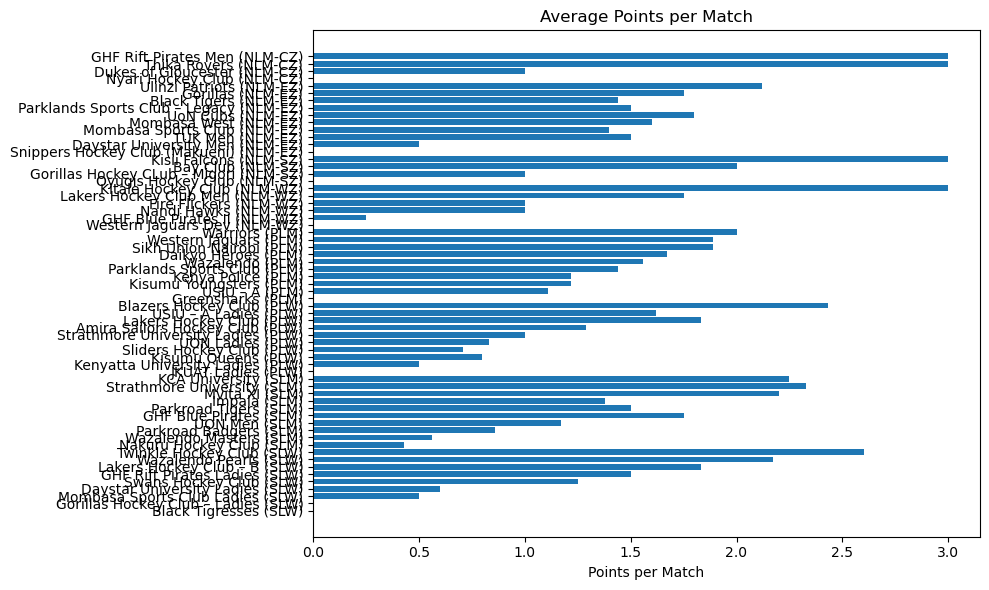

In [94]:
# Cell 222 - Plot Points per Match

plt.figure(figsize=(10,6))

plt.barh(
    (league_table["Team"] + " (" + league_table["Competition"] + ")"),
    league_table["PointsPerMatch"]
)

plt.gca().invert_yaxis()

plt.xlabel("Points per Match")

plt.title("Average Points per Match")

plt.tight_layout()

plt.show()

In [95]:
# Cell 223 - Goal Difference per Match

league_table["GDPerMatch"] = (
    league_table["GD"] /
    league_table["Played"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "GD",
        "GDPerMatch"
    ]
].sort_values(
    ["Competition", "GDPerMatch"],
    ascending=[True, False]
)

,Competition,Team,GD,GDPerMatch
0,NLM-CZ,GHF Rift Pirates Men,8,8.00
1,NLM-CZ,Thika Rovers,8,8.00
2,NLM-CZ,Dukes of Gloucester,-11,-3.67
3,NLM-CZ,Nyari Hockey Club,-5,-5.00
4,NLM-EZ,Ulinzi Patriots,6,0.75
...,...,...,...,...
58,SLW,Swans Hockey Club,0,0.00
60,SLW,Mombasa Sports Club Ladies,-2,-0.50
59,SLW,Daystar University Ladies,-6,-1.20
61,SLW,Gorillas Hockey Club – Ladies,-4,-1.33


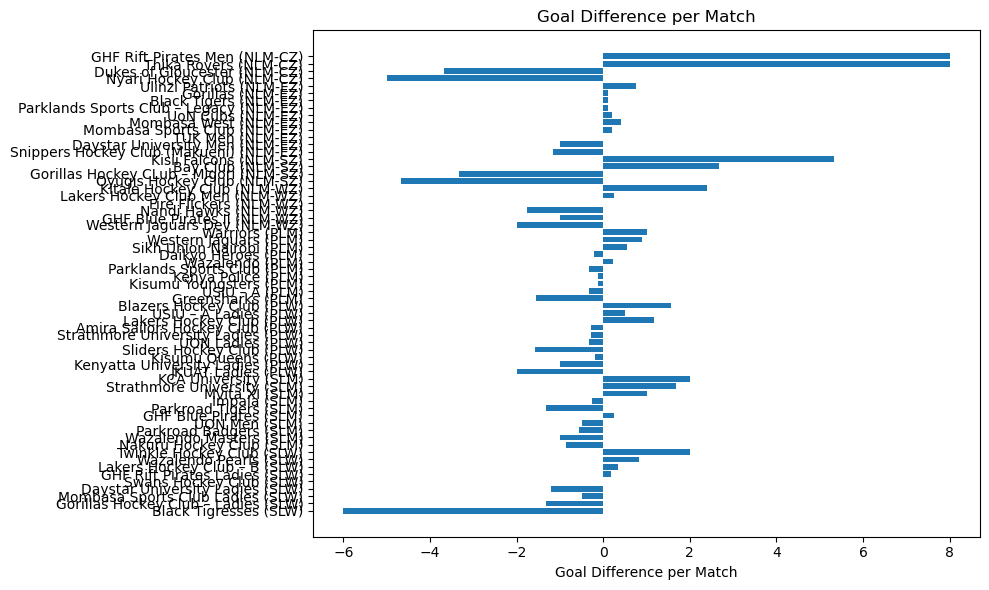

In [96]:
# Cell 224 - Plot Goal Difference per Match

plt.figure(figsize=(10,6))

plt.barh(
    (league_table["Team"] + " (" + league_table["Competition"] + ")"),
    league_table["GDPerMatch"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goal Difference per Match")

plt.title("Goal Difference per Match")

plt.tight_layout()

plt.show()

In [97]:
# Cell 225 - Winning Percentage

league_table["WinPercentage"] = (
    league_table["Wins"] /
    league_table["Played"] * 100
).round(1)

league_table[
    [
        "Competition",
        "Team",
        "WinPercentage"
    ]
].sort_values(
    ["Competition", "WinPercentage"],
    ascending=[True, False]
)

,Competition,Team,WinPercentage
0,NLM-CZ,GHF Rift Pirates Men,100.0
1,NLM-CZ,Thika Rovers,100.0
2,NLM-CZ,Dukes of Gloucester,33.3
3,NLM-CZ,Nyari Hockey Club,0.0
4,NLM-EZ,Ulinzi Patriots,62.5
...,...,...,...
58,SLW,Swans Hockey Club,25.0
59,SLW,Daystar University Ladies,20.0
60,SLW,Mombasa Sports Club Ladies,0.0
61,SLW,Gorillas Hockey Club – Ladies,0.0


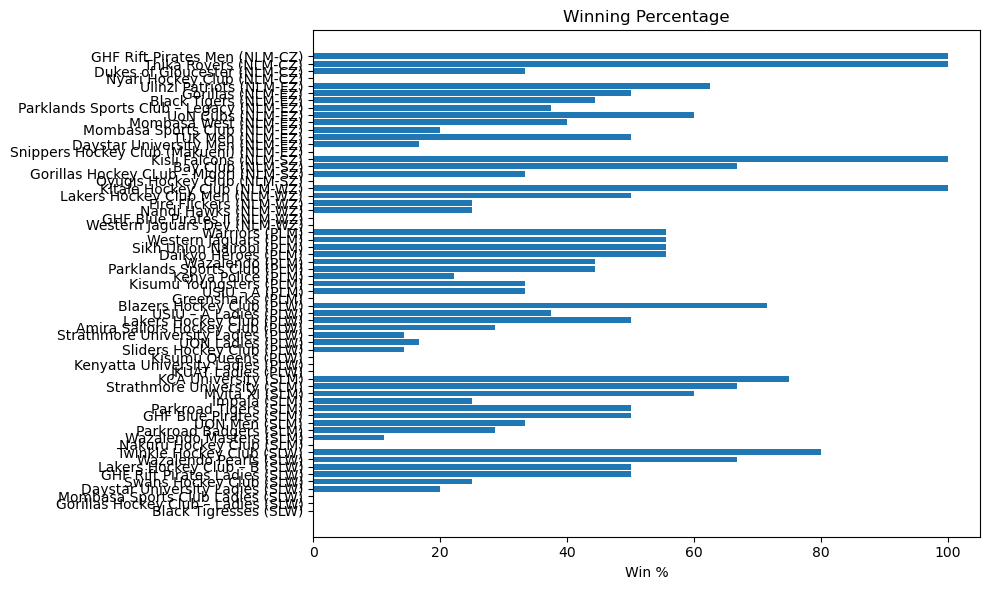

In [98]:
# Cell 226 - Plot Winning Percentage

plt.figure(figsize=(10,6))

plt.barh(
    (league_table["Team"] + " (" + league_table["Competition"] + ")"),
    league_table["WinPercentage"]
)

plt.gca().invert_yaxis()

plt.xlabel("Win %")

plt.title("Winning Percentage")

plt.tight_layout()

plt.show()

In [99]:
# Cell 227 - Draw Percentage

league_table["DrawPercentage"] = (
    league_table["Draws"] /
    league_table["Played"] * 100
).round(1)

league_table[
    [
        "Competition",
        "Team",
        "DrawPercentage"
    ]
].sort_values(
    ["Competition", "DrawPercentage"],
    ascending=[True, False]
)

,Competition,Team,DrawPercentage
0,NLM-CZ,GHF Rift Pirates Men,0.0
1,NLM-CZ,Thika Rovers,0.0
2,NLM-CZ,Dukes of Gloucester,0.0
3,NLM-CZ,Nyari Hockey Club,0.0
10,NLM-EZ,Mombasa Sports Club,80.0
...,...,...,...
55,SLW,Wazalendo Pearls,16.7
57,SLW,GHF Rift Pirates Ladies,0.0
59,SLW,Daystar University Ladies,0.0
61,SLW,Gorillas Hockey Club – Ladies,0.0


In [100]:
# Cell 228 - Loss Percentage

league_table["LossPercentage"] = (
    league_table["Losses"] /
    league_table["Played"] * 100
).round(1)

league_table[
    [
        "Competition",
        "Team",
        "LossPercentage"
    ]
].sort_values(
    ["Competition", "LossPercentage"],
    ascending=[True, True]
)

,Competition,Team,LossPercentage
0,NLM-CZ,GHF Rift Pirates Men,0.0
1,NLM-CZ,Thika Rovers,0.0
2,NLM-CZ,Dukes of Gloucester,66.7
3,NLM-CZ,Nyari Hockey Club,100.0
10,NLM-EZ,Mombasa Sports Club,0.0
...,...,...,...
57,SLW,GHF Rift Pirates Ladies,50.0
60,SLW,Mombasa Sports Club Ladies,50.0
59,SLW,Daystar University Ladies,80.0
61,SLW,Gorillas Hockey Club – Ladies,100.0


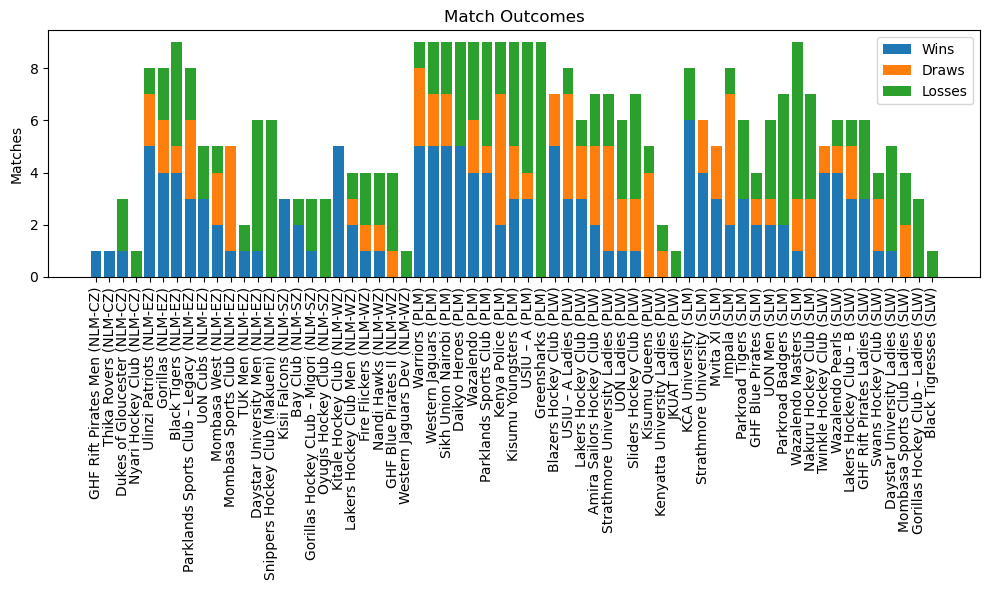

In [101]:
# Cell 229 - Plot Match Outcomes

plt.figure(figsize=(10,6))

plt.bar(
    (league_table["Team"] + " (" + league_table["Competition"] + ")"),
    league_table["Wins"],
    label="Wins"
)

plt.bar(
    (league_table["Team"] + " (" + league_table["Competition"] + ")"),
    league_table["Draws"],
    bottom=league_table["Wins"],
    label="Draws"
)

plt.bar(
    (league_table["Team"] + " (" + league_table["Competition"] + ")"),
    league_table["Losses"],
    bottom=league_table["Wins"] + league_table["Draws"],
    label="Losses"
)

plt.xticks(rotation=90)

plt.ylabel("Matches")

plt.title("Match Outcomes")

plt.legend()

plt.tight_layout()

plt.show()

In [102]:
# Cell 230 - Save Updated League Table

league_table.to_csv(
    "../data/processed/league_table_extended.csv",
    index=False
)

print("Extended league table saved.")

Extended league table saved.


In [103]:
# Cell 231 - Team Ranking Score

league_table["RankingScore"] = (
    league_table["PointsPerMatch"] * 0.5 +
    league_table["AttackStrength"] * 0.3 +
    (2 - league_table["DefenceStrength"]) * 0.2
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "RankingScore"
    ]
].sort_values(
    ["Competition", "RankingScore"],
    ascending=[True, False]
)

,Competition,Team,RankingScore
0,NLM-CZ,GHF Rift Pirates Men,1.88
2,NLM-CZ,Dukes of Gloucester,0.92
1,NLM-CZ,Thika Rovers,0.79
3,NLM-CZ,Nyari Hockey Club,0.28
4,NLM-EZ,Ulinzi Patriots,1.58
...,...,...,...
58,SLW,Swans Hockey Club,0.96
59,SLW,Daystar University Ladies,0.67
60,SLW,Mombasa Sports Club Ladies,0.58
61,SLW,Gorillas Hockey Club – Ladies,0.41


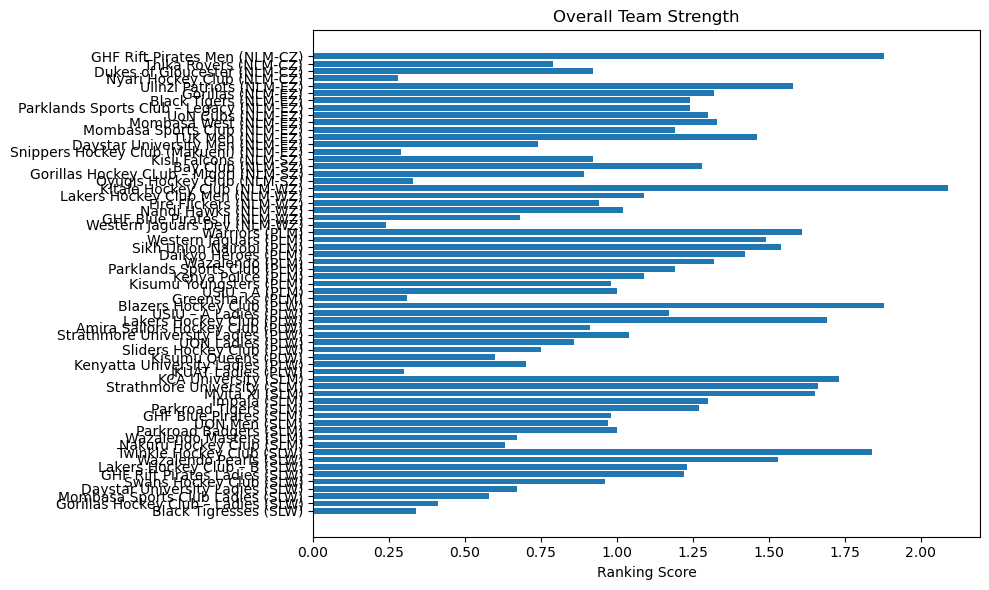

In [104]:
# Cell 232 - Plot Ranking Score

plt.figure(figsize=(10,6))

plt.barh(
    (league_table["Team"] + " (" + league_table["Competition"] + ")"),
    league_table["RankingScore"]
)

plt.gca().invert_yaxis()

plt.xlabel("Ranking Score")

plt.title("Overall Team Strength")

plt.tight_layout()

plt.show()

In [105]:
# Cell 233 - Offensive Efficiency

league_table["OffensiveEfficiency"] = (
    league_table["GF"] /
    league_table["Played"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "OffensiveEfficiency"
    ]
].sort_values(
    ["Competition", "OffensiveEfficiency"],
    ascending=[True, False]
)

,Competition,Team,OffensiveEfficiency
0,NLM-CZ,GHF Rift Pirates Men,9.00
1,NLM-CZ,Thika Rovers,8.00
2,NLM-CZ,Dukes of Gloucester,2.00
3,NLM-CZ,Nyari Hockey Club,0.00
11,NLM-EZ,TUK Men,2.00
...,...,...,...
58,SLW,Swans Hockey Club,1.00
60,SLW,Mombasa Sports Club Ladies,0.75
61,SLW,Gorillas Hockey Club – Ladies,0.67
59,SLW,Daystar University Ladies,0.60


In [106]:
# Cell 234 - Defensive Efficiency

league_table["DefensiveEfficiency"] = (
    league_table["GA"] /
    league_table["Played"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "DefensiveEfficiency"
    ]
].sort_values(
    ["Competition", "DefensiveEfficiency"],
    ascending=[True, True]
)

,Competition,Team,DefensiveEfficiency
1,NLM-CZ,Thika Rovers,0.00
0,NLM-CZ,GHF Rift Pirates Men,1.00
3,NLM-CZ,Nyari Hockey Club,5.00
2,NLM-CZ,Dukes of Gloucester,5.67
4,NLM-EZ,Ulinzi Patriots,1.00
...,...,...,...
57,SLW,GHF Rift Pirates Ladies,1.17
60,SLW,Mombasa Sports Club Ladies,1.25
59,SLW,Daystar University Ladies,1.80
61,SLW,Gorillas Hockey Club – Ladies,2.00


In [107]:
# Cell 235 - Efficiency Difference

league_table["EfficiencyDifference"] = (
    league_table["OffensiveEfficiency"] -
    league_table["DefensiveEfficiency"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "EfficiencyDifference"
    ]
].sort_values(
    ["Competition", "EfficiencyDifference"],
    ascending=[True, False]
)

,Competition,Team,EfficiencyDifference
0,NLM-CZ,GHF Rift Pirates Men,8.00
1,NLM-CZ,Thika Rovers,8.00
2,NLM-CZ,Dukes of Gloucester,-3.67
3,NLM-CZ,Nyari Hockey Club,-5.00
4,NLM-EZ,Ulinzi Patriots,0.75
...,...,...,...
58,SLW,Swans Hockey Club,0.00
60,SLW,Mombasa Sports Club Ladies,-0.50
59,SLW,Daystar University Ladies,-1.20
61,SLW,Gorillas Hockey Club – Ladies,-1.33


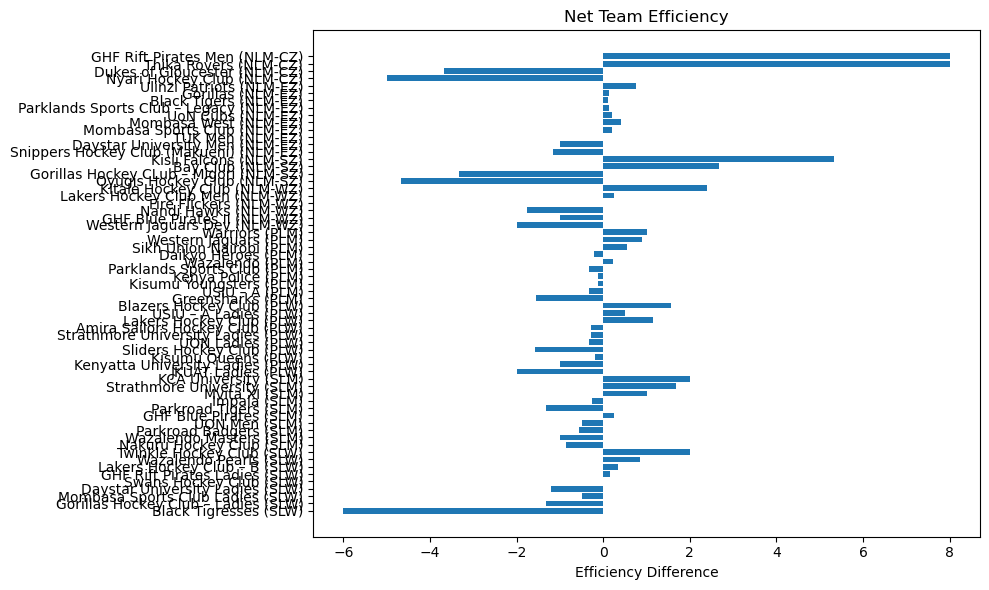

In [108]:
# Cell 236 - Plot Efficiency Difference

plt.figure(figsize=(10,6))

plt.barh(
    (league_table["Team"] + " (" + league_table["Competition"] + ")"),
    league_table["EfficiencyDifference"]
)

plt.gca().invert_yaxis()

plt.xlabel("Efficiency Difference")

plt.title("Net Team Efficiency")

plt.tight_layout()

plt.show()

In [109]:
# Cell 237 - Clean Sheet Flag

results["CleanSheet"] = (
    results["GA"] == 0
).astype(int)

results.head()

,Competition,Team,Opponent,Venue,GF,GA,Win,Draw,Loss,Points,CleanSheet
0,PLW,Amira Sailors Hockey Club,Blazers Hockey Club,Home,0,3,0,0,1,0,0
1,PLW,Amira Sailors Hockey Club,Sliders Hockey Club,Home,0,0,0,1,0,1,1
2,PLW,Blazers Hockey Club,Kenyatta University Ladies,Home,2,0,1,0,0,3,1
3,PLW,Blazers Hockey Club,Kisumu Queens,Home,1,0,1,0,0,3,1
4,PLW,Blazers Hockey Club,Sliders Hockey Club,Home,3,0,1,0,0,3,1


In [110]:
# Cell 238 - Clean Sheets by Team

clean_sheets = (
    results
    .groupby(["Competition", "Team"])
    .agg(
        CleanSheets=("CleanSheet","sum"),
        Matches=("Team","count")
    )
    .reset_index()
)

clean_sheets["CleanSheetRate"] = (
    clean_sheets["CleanSheets"] /
    clean_sheets["Matches"]
).round(2)

clean_sheets.sort_values(
    ["Competition", "CleanSheetRate"],
    ascending=[True, False]
)


,Competition,Team,CleanSheets,Matches,CleanSheetRate
3,NLM-CZ,Thika Rovers,1,1,1.00
0,NLM-CZ,Dukes of Gloucester,1,3,0.33
1,NLM-CZ,GHF Rift Pirates Men,0,1,0.00
2,NLM-CZ,Nyari Hockey Club,0,1,0.00
13,NLM-EZ,UoN Cubs,2,5,0.40
...,...,...,...,...,...
62,SLW,Wazalendo Pearls,1,6,0.17
54,SLW,Black Tigresses,0,1,0.00
55,SLW,Daystar University Ladies,0,5,0.00
57,SLW,Gorillas Hockey Club – Ladies,0,3,0.00


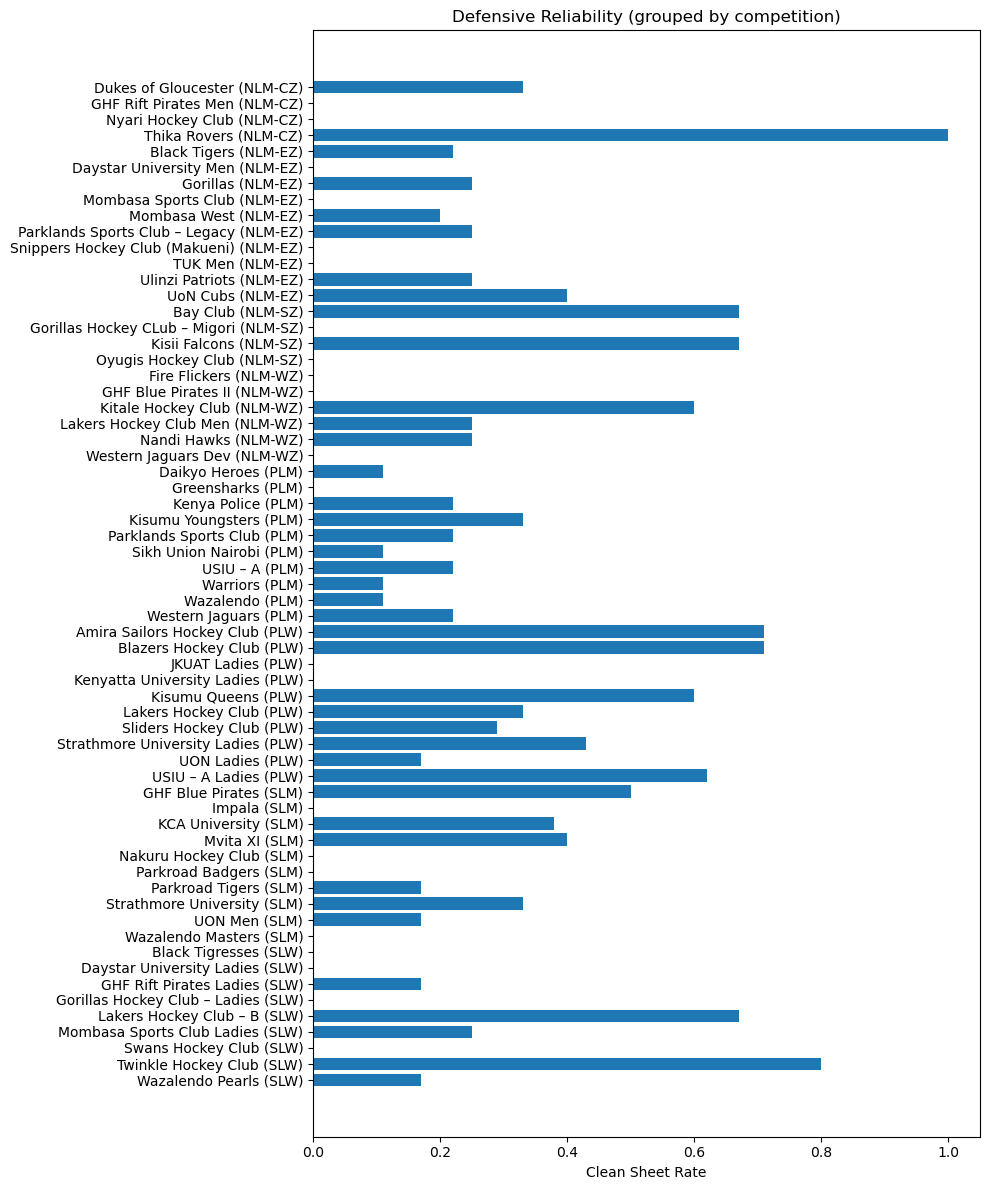

In [111]:
# Cell 239 - Plot Clean Sheet Rate

labels = clean_sheets["Team"] + " (" + clean_sheets["Competition"] + ")"

plt.figure(figsize=(10, 12))

plt.barh(
    labels,
    clean_sheets["CleanSheetRate"]
)

plt.gca().invert_yaxis()

plt.xlabel("Clean Sheet Rate")

plt.title("Defensive Reliability (grouped by competition)")

plt.tight_layout()

plt.show()


In [112]:
# Cell 240 - Save Defensive Metrics

clean_sheets.to_csv(
    "../data/processed/clean_sheet_summary.csv"
)

print("Clean sheet summary saved.")

Clean sheet summary saved.


In [113]:
# Cell 241 - Highest Scoring Matches

highest_scoring = (
    matches_df
    .sort_values(
        "TotalGoals",
        ascending=False
    )
)

highest_scoring[
    [
        "Date",
        "HomeTeam",
        "AwayTeam",
        "HomeGoals",
        "AwayGoals",
        "TotalGoals"
    ]
].head(10)

,Date,HomeTeam,AwayTeam,HomeGoals,AwayGoals,TotalGoals
176,07-06-2026,Oyugis Hockey Club,Kisii Falcons,0,10,10
158,21-06-2026,GHF Rift Pirates Men,Dukes of Gloucester,9,1,10
50,31-05-2026,Sikh Union Nairobi,Daikyo Heroes,6,3,9
159,07-06-2026,Thika Rovers,Dukes of Gloucester,8,0,8
172,21-06-2026,Gorillas Hockey CLub – Migori,Bay Club,0,8,8
93,20-06-2026,Parkroad Tigers,KCA University,1,7,8
82,21-06-2026,Mvita XI,Impala,4,4,8
165,12-07-2026,Kitale Hockey Club,Nandi Hawks,7,0,7
116,20-06-2026,Lakers Hockey Club – B,Twinkle Hockey Club,3,3,6
106,06-06-2026,Black Tigresses,Twinkle Hockey Club,0,6,6


In [114]:
# Cell 242 - Biggest Home Wins

home_wins = matches_df.copy()

home_wins["Margin"] = (
    home_wins["HomeGoals"] -
    home_wins["AwayGoals"]
)

home_wins = home_wins.sort_values(
    "Margin",
    ascending=False
)

home_wins[
    [
        "HomeTeam",
        "AwayTeam",
        "HomeGoals",
        "AwayGoals",
        "Margin"
    ]
].head(10)

,HomeTeam,AwayTeam,HomeGoals,AwayGoals,Margin
158,GHF Rift Pirates Men,Dukes of Gloucester,9,1,8
159,Thika Rovers,Dukes of Gloucester,8,0,8
165,Kitale Hockey Club,Nandi Hawks,7,0,7
157,Dukes of Gloucester,Nyari Hockey Club,5,0,5
173,Kisii Falcons,Gorillas Hockey CLub – Migori,4,0,4
58,Warriors,Daikyo Heroes,4,0,4
78,KCA University,Impala,4,0,4
4,Blazers Hockey Club,Sliders Hockey Club,3,0,3
126,Black Tigers,Daystar University Men,4,1,3
50,Sikh Union Nairobi,Daikyo Heroes,6,3,3


In [115]:
# Cell 243 - Biggest Away Wins

away_wins = matches_df.copy()

away_wins["Margin"] = (
    away_wins["AwayGoals"] -
    away_wins["HomeGoals"]
)

away_wins = away_wins.sort_values(
    "Margin",
    ascending=False
)

away_wins[
    [
        "HomeTeam",
        "AwayTeam",
        "HomeGoals",
        "AwayGoals",
        "Margin"
    ]
].head(10)

,HomeTeam,AwayTeam,HomeGoals,AwayGoals,Margin
176,Oyugis Hockey Club,Kisii Falcons,0,10,10
172,Gorillas Hockey CLub – Migori,Bay Club,0,8,8
13,Sliders Hockey Club,Lakers Hockey Club,0,6,6
106,Black Tigresses,Twinkle Hockey Club,0,6,6
93,Parkroad Tigers,KCA University,1,7,6
95,Parkroad Tigers,Strathmore University,0,4,4
110,Daystar University Ladies,Wazalendo Pearls,0,3,3
104,Wazalendo Masters,KCA University,0,3,3
101,UON Men,Parkroad Badgers,1,4,3
91,Parkroad Badgers,Strathmore University,1,4,3


In [116]:
# Cell 244 - Closest Matches

matches_df["GoalDifference"] = (
    abs(
        matches_df["HomeGoals"] -
        matches_df["AwayGoals"]
    )
)

closest_matches = (
    matches_df
    .sort_values(
        "GoalDifference"
    )
)

closest_matches[
    [
        "Date",
        "HomeTeam",
        "AwayTeam",
        "HomeGoals",
        "AwayGoals",
        "GoalDifference"
    ]
].head(10)

,Date,HomeTeam,AwayTeam,HomeGoals,AwayGoals,GoalDifference
120,06-06-2026,Swans Hockey Club,Mombasa Sports Club Ladies,1,1,0
25,21-06-2026,USIU – A Ladies,Blazers Hockey Club,2,2,0
27,01-06-2026,USIU – A Ladies,UON Ladies,1,1,0
164,27-06-2026,GHF Blue Pirates II,Nandi Hawks,2,2,0
162,06-06-2026,Fire Flickers,Lakers Hockey Club Men,1,1,0
65,13-06-2026,Wazalendo,Sikh Union Nairobi,1,1,0
97,04-07-2026,Strathmore University,Impala,3,3,0
62,23-05-2026,Warriors,Wazalendo,3,3,0
98,13-06-2026,Strathmore University,UON Men,1,1,0
135,21-06-2026,Gorillas,Parklands Sports Club – Legacy,1,1,0


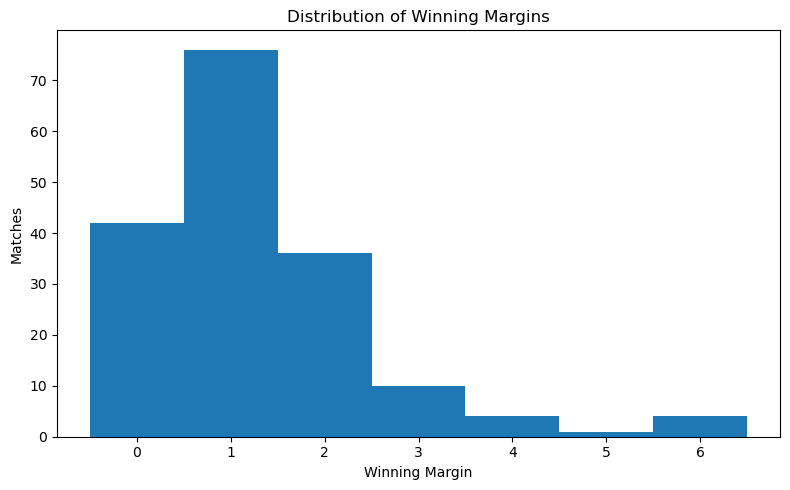

In [117]:
# Cell 245 - Plot Goal Differences

plt.figure(figsize=(8,5))

plt.hist(
    matches_df["GoalDifference"],
    bins=range(0,8),
    align="left"
)

plt.xlabel("Winning Margin")

plt.ylabel("Matches")

plt.title("Distribution of Winning Margins")

plt.tight_layout()

plt.show()

In [118]:
# Cell 246 - Matches Ending in Draw

draw_matches = matches_df[
    matches_df["HomeGoals"] ==
    matches_df["AwayGoals"]
]

draw_matches[
    [
        "Date",
        "HomeTeam",
        "AwayTeam",
        "HomeGoals",
        "AwayGoals"
    ]
]

,Date,HomeTeam,AwayTeam,HomeGoals,AwayGoals
1,01-06-2026,Amira Sailors Hockey Club,Sliders Hockey Club,0,0
5,24-05-2026,Kenyatta University Ladies,Sliders Hockey Club,1,1
6,27-06-2026,Kisumu Queens,Amira Sailors Hockey Club,0,0
7,07-06-2026,Kisumu Queens,Strathmore University Ladies,2,2
8,06-06-2026,Kisumu Queens,USIU – A Ladies,0,0
10,24-05-2026,Lakers Hockey Club,Kisumu Queens,0,0
11,06-06-2026,Lakers Hockey Club,Strathmore University Ladies,1,1
16,20-06-2026,Strathmore University Ladies,Amira Sailors Hockey Club,0,0
20,23-05-2026,Strathmore University Ladies,USIU – A Ladies,0,0
22,07-06-2026,UON Ladies,Blazers Hockey Club,0,0


In [119]:
# Cell 247 - Percentage of Draws

draw_percentage = (
    len(draw_matches) /
    len(matches_df) * 100
)

print(f"Draw Percentage: {draw_percentage:.1f}%")

Draw Percentage: 23.7%


In [120]:
# Cell 248 - Home Wins vs Away Wins

home_win_count = (
    matches_df["HomeGoals"] >
    matches_df["AwayGoals"]
).sum()

away_win_count = (
    matches_df["AwayGoals"] >
    matches_df["HomeGoals"]
).sum()

draw_count = (
    matches_df["HomeGoals"] ==
    matches_df["AwayGoals"]
).sum()

print("Home Wins :", home_win_count)
print("Away Wins :", away_win_count)
print("Draws     :", draw_count)

Home Wins : 65
Away Wins : 70
Draws     : 42


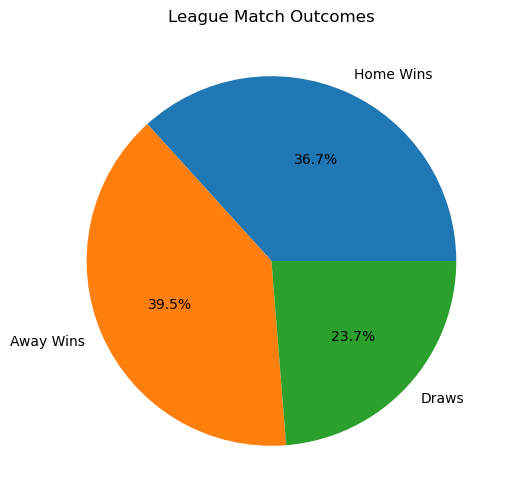

In [121]:
# Cell 249 - Plot Match Outcomes

plt.figure(figsize=(6,6))

plt.pie(
    [home_win_count,
     away_win_count,
     draw_count],
    labels=[
        "Home Wins",
        "Away Wins",
        "Draws"
    ],
    autopct="%1.1f%%"
)

plt.title("League Match Outcomes")

plt.show()

In [122]:
# Cell 250 - Save Match Statistics

match_statistics = pd.DataFrame({
    "Statistic":[
        "Home Wins",
        "Away Wins",
        "Draws",
        "Draw Percentage"
    ],
    "Value":[
        home_win_count,
        away_win_count,
        draw_count,
        round(draw_percentage,2)
    ]
})

match_statistics.to_csv(
    "../data/processed/match_statistics.csv",
    index=False
)

print("Match statistics saved.")

Match statistics saved.


In [123]:
# Cell 251 - Player Goal Percentage

total_goals = len(goal_events)

player_percentage = player_goals.copy()

player_percentage["GoalShare (%)"] = (
    player_percentage["Goals"] /
    total_goals * 100
).round(2)

player_percentage.sort_values("GoalShare (%)", ascending=False)


,Player,Goals,GoalShare (%)
48,Mathias Gularire,6,5.77
45,Malack Masese,4,3.85
33,Job Wandera,4,3.85
56,Robert Masibo,4,3.85
8,Calvins Kanu Omondi,3,2.88
...,...,...,...
41,Kit Garner,1,0.96
0,Alex Taiswa,1,0.96
39,Ketane Okoth,1,0.96
38,Kennedy Wanyonyi,1,0.96


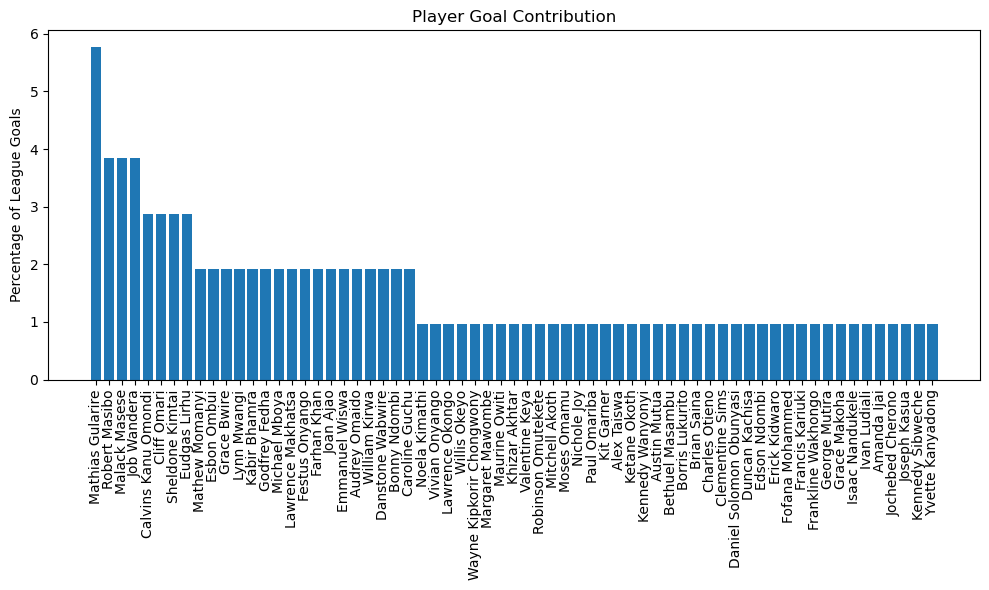

In [124]:
# Cell 252 - Plot Goal Share

plt.figure(figsize=(10,6))

plt.bar(
    player_percentage["Player"],
    player_percentage["GoalShare (%)"]
)

plt.xticks(rotation=90)

plt.ylabel("Percentage of League Goals")

plt.title("Player Goal Contribution")

plt.tight_layout()

plt.show()

In [125]:
# Cell 253 - Player Discipline

player_cards = (
    cards
    .groupby(
        ["Player","Event"]
    )
    .size()
    .unstack(fill_value=0)
)

player_cards

Event,Green Card,Red Card,Yellow card
Player,,,
Allan Iningu,1,0,0
Allan Munene,0,0,1
Aredha Mandela,1,0,0
Arjun Uupta,1,0,1
Arnold Abedie,0,0,1
...,...,...,...
William Kirwa,1,0,0
Willis Malesi,2,0,1
Willis Wanjala,0,0,3


In [126]:
# Cell 254 - Total Cards per Player

player_cards["TotalCards"] = (
    player_cards.sum(axis=1)
)

player_cards = player_cards.sort_values(
    "TotalCards",
    ascending=False
)

player_cards

Event,Green Card,Red Card,Yellow card,TotalCards
Player,,,,
Michael Mboya,3,0,0,3
Willis Wanjala,0,0,3,3
Willis Malesi,2,0,1,3
Daniel Matara,1,0,2,3
Moses Omamu,2,0,1,3
...,...,...,...,...
Irene Senoi,1,0,0,1
Isaac Nandukele,1,0,0,1
Ivan Ludiali,0,0,1,1


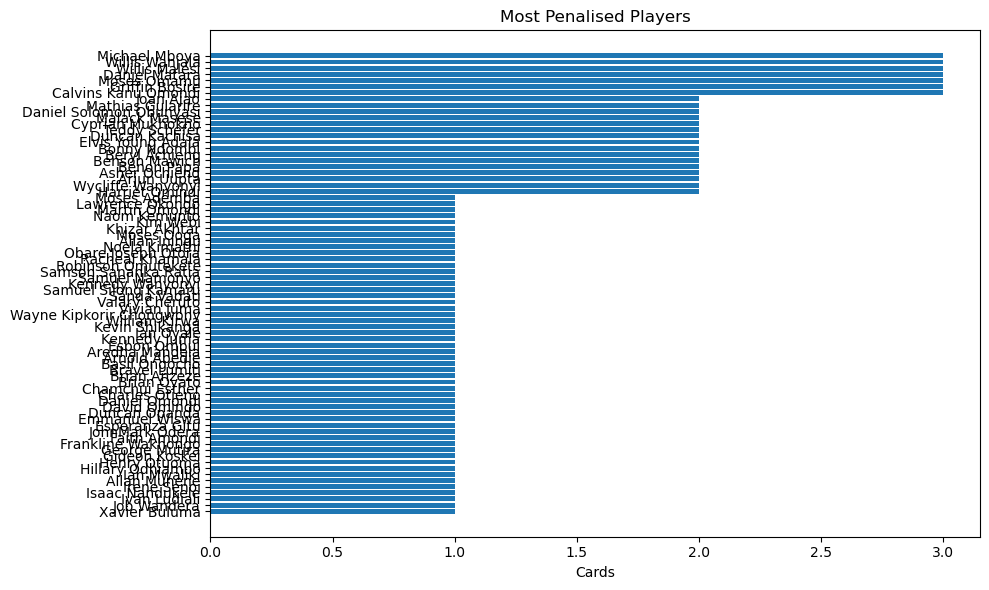

In [127]:
# Cell 255 - Plot Player Discipline

plt.figure(figsize=(10,6))

plt.barh(
    player_cards.index,
    player_cards["TotalCards"]
)

plt.gca().invert_yaxis()

plt.xlabel("Cards")

plt.title("Most Penalised Players")

plt.tight_layout()

plt.show()

In [128]:
# Cell 256 - Team Discipline Ranking

team_cards = (
    cards
    .groupby(["Competition", "Team"])
    .size()
    .reset_index(name="Cards")
    .sort_values(
        ["Competition", "Cards"],
        ascending=[True, False]
    )
)

team_cards


,Competition,Team,Cards
2,PLM,Kisumu Youngsters,15
3,PLM,Parklands Sports Club,15
1,PLM,Greensharks,14
7,PLM,Wazalendo,10
6,PLM,Warriors,8
8,PLM,Western Jaguars,8
4,PLM,Sikh Union Nairobi,7
0,PLM,Daikyo Heroes,6
5,PLM,USIU – A,6
18,PLW,USIU – A Ladies,4


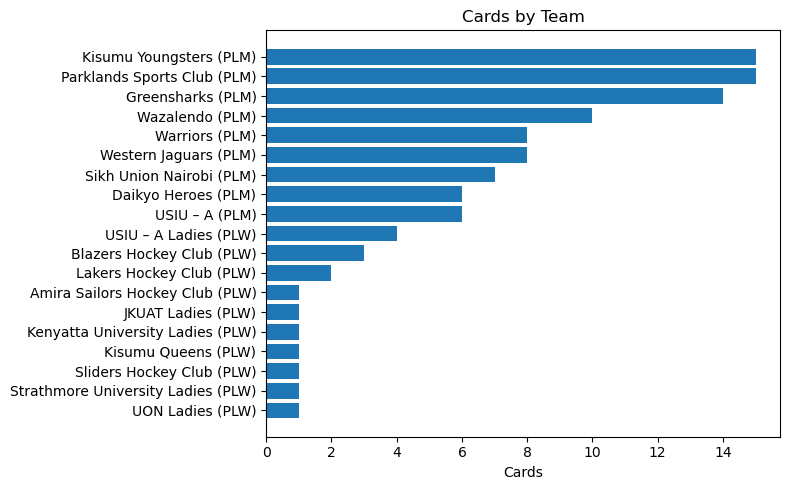

In [129]:
# Cell 257 - Plot Team Discipline

plt.figure(figsize=(8,5))

plt.barh(
    (team_cards["Team"] + " (" + team_cards["Competition"] + ")"),
    team_cards["Cards"]
)

plt.gca().invert_yaxis()

plt.xlabel("Cards")

plt.title("Cards by Team")

plt.tight_layout()

plt.show()

In [130]:
# Cell 258 - Most Active Players

player_events = (
    events_df
    .groupby("Player")
    .size()
    .reset_index(name="Events")
    .sort_values(
        "Events",
        ascending=False
    )
)

player_events.head(20)

,Player,Events
83,Mathias Gularire,8
21,Calvins Kanu Omondi,6
79,Malack Masese,6
85,Michael Mboya,5
63,Job Wandera,5
88,Moses Omamu,4
15,Bonny Ndombi,4
62,Joan Ajao,4
96,Robert Masibo,4
110,Willis Malesi,3


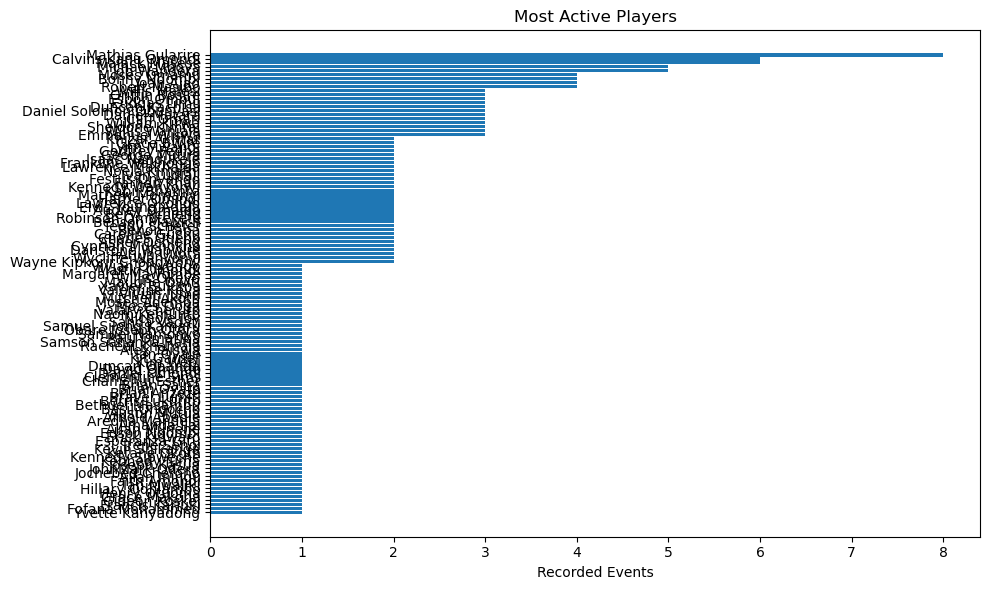

In [131]:
# Cell 259 - Player Event Distribution

plt.figure(figsize=(10,6))

plt.barh(
    player_events["Player"],
    player_events["Events"]
)

plt.gca().invert_yaxis()

plt.xlabel("Recorded Events")

plt.title("Most Active Players")

plt.tight_layout()

plt.show()

In [132]:
# Cell 260 - Save Player Analytics

player_percentage.to_csv(
    "../data/processed/player_goal_percentage.csv",
    index=False
)

player_cards.to_csv(
    "../data/processed/player_cards.csv"
)

player_events.to_csv(
    "../data/processed/player_events.csv",
    index=False
)

team_cards.to_csv(
    "../data/processed/team_cards.csv",
    index=False
)

print("Player analytics saved.")

Player analytics saved.


In [133]:
# Cell 261 - Average Goals by Venue

venue_goals = (
    results
    .groupby("Venue")
    .agg(
        Matches=("Team", "count"),
        GoalsFor=("GF", "sum"),
        GoalsAgainst=("GA", "sum")
    )
)

venue_goals["GoalsPerMatch"] = (
    venue_goals["GoalsFor"] /
    venue_goals["Matches"]
).round(2)

venue_goals

,Matches,GoalsFor,GoalsAgainst,GoalsPerMatch
Venue,,,,
Away,177,275,265,1.55
Home,177,265,275,1.50


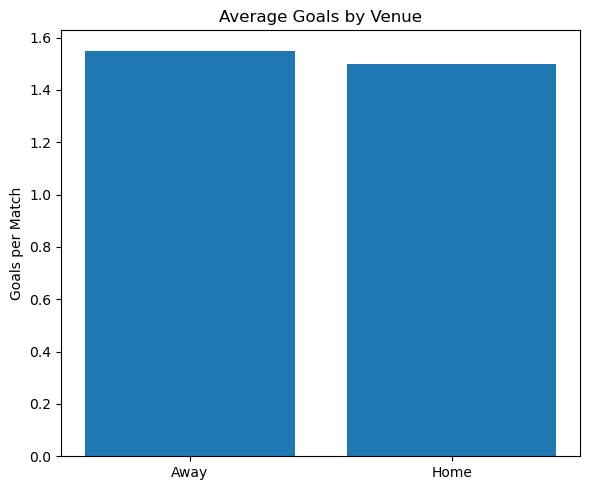

In [134]:
# Cell 262 - Plot Venue Goals

plt.figure(figsize=(6,5))

plt.bar(
    venue_goals.index,
    venue_goals["GoalsPerMatch"]
)

plt.ylabel("Goals per Match")

plt.title("Average Goals by Venue")

plt.tight_layout()

plt.show()

In [135]:
# Cell 263 - Clean Sheet Indicator

results["CleanSheet"] = (
    results["GA"] == 0
).astype(int)

results.head()

,Competition,Team,Opponent,Venue,GF,GA,Win,Draw,Loss,Points,CleanSheet
0,PLW,Amira Sailors Hockey Club,Blazers Hockey Club,Home,0,3,0,0,1,0,0
1,PLW,Amira Sailors Hockey Club,Sliders Hockey Club,Home,0,0,0,1,0,1,1
2,PLW,Blazers Hockey Club,Kenyatta University Ladies,Home,2,0,1,0,0,3,1
3,PLW,Blazers Hockey Club,Kisumu Queens,Home,1,0,1,0,0,3,1
4,PLW,Blazers Hockey Club,Sliders Hockey Club,Home,3,0,1,0,0,3,1


In [136]:
# Cell 264 - Clean Sheets by Team

clean_sheets = (
    results
    .groupby(["Competition", "Team"])
    .agg(
        Matches=("Team", "count"),
        CleanSheets=("CleanSheet", "sum")
    )
    .reset_index()
)

clean_sheets["CleanSheetRate"] = (
    clean_sheets["CleanSheets"] /
    clean_sheets["Matches"]
).round(2)

clean_sheets.sort_values(
    ["Competition", "CleanSheets"],
    ascending=[True, False]
)


,Competition,Team,Matches,CleanSheets,CleanSheetRate
0,NLM-CZ,Dukes of Gloucester,3,1,0.33
3,NLM-CZ,Thika Rovers,1,1,1.00
1,NLM-CZ,GHF Rift Pirates Men,1,0,0.00
2,NLM-CZ,Nyari Hockey Club,1,0,0.00
4,NLM-EZ,Black Tigers,9,2,0.22
...,...,...,...,...,...
62,SLW,Wazalendo Pearls,6,1,0.17
54,SLW,Black Tigresses,1,0,0.00
55,SLW,Daystar University Ladies,5,0,0.00
57,SLW,Gorillas Hockey Club – Ladies,3,0,0.00


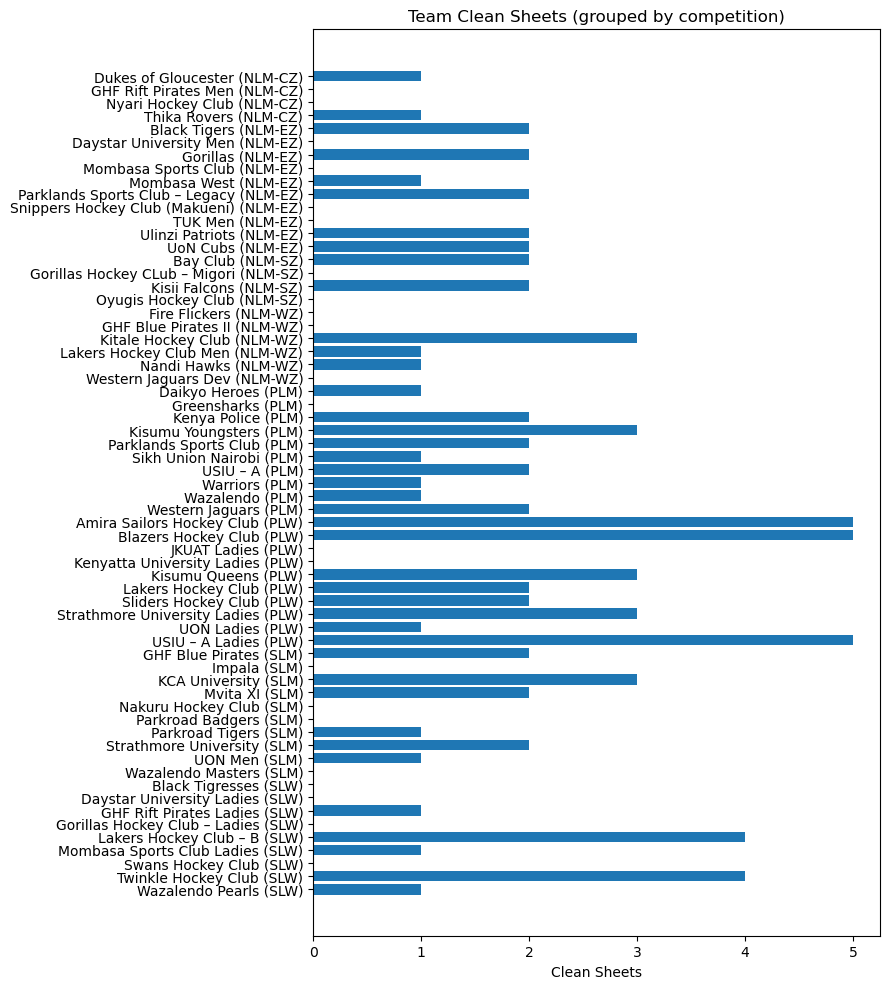

In [137]:
# Cell 265 - Plot Clean Sheets

labels = clean_sheets["Team"] + " (" + clean_sheets["Competition"] + ")"

plt.figure(figsize=(9, 10))

plt.barh(
    labels,
    clean_sheets["CleanSheets"]
)

plt.gca().invert_yaxis()

plt.xlabel("Clean Sheets")

plt.title("Team Clean Sheets (grouped by competition)")

plt.tight_layout()

plt.show()


In [138]:
# Cell 266 - Failed to Score

results["FailedToScore"] = (
    results["GF"] == 0
).astype(int)

results.head()

,Competition,Team,Opponent,Venue,GF,GA,Win,Draw,Loss,Points,CleanSheet,FailedToScore
0,PLW,Amira Sailors Hockey Club,Blazers Hockey Club,Home,0,3,0,0,1,0,0,1
1,PLW,Amira Sailors Hockey Club,Sliders Hockey Club,Home,0,0,0,1,0,1,1,1
2,PLW,Blazers Hockey Club,Kenyatta University Ladies,Home,2,0,1,0,0,3,1,0
3,PLW,Blazers Hockey Club,Kisumu Queens,Home,1,0,1,0,0,3,1,0
4,PLW,Blazers Hockey Club,Sliders Hockey Club,Home,3,0,1,0,0,3,1,0


In [139]:
# Cell 267 - Failed to Score Summary

failed_scoring = (
    results
    .groupby(["Competition", "Team"])
    .agg(
        Matches=("Team", "count"),
        FailedToScore=("FailedToScore", "sum")
    )
    .reset_index()
)

failed_scoring["Rate"] = (
    failed_scoring["FailedToScore"] /
    failed_scoring["Matches"]
).round(2)

failed_scoring.sort_values(
    ["Competition", "FailedToScore"],
    ascending=[True, False]
)


,Competition,Team,Matches,FailedToScore,Rate
0,NLM-CZ,Dukes of Gloucester,3,1,0.33
2,NLM-CZ,Nyari Hockey Club,1,1,1.00
1,NLM-CZ,GHF Rift Pirates Men,1,0,0.00
3,NLM-CZ,Thika Rovers,1,0,0.00
10,NLM-EZ,Snippers Hockey Club (Makueni),6,4,0.67
...,...,...,...,...,...
58,SLW,Lakers Hockey Club – B,6,1,0.17
59,SLW,Mombasa Sports Club Ladies,4,1,0.25
60,SLW,Swans Hockey Club,4,1,0.25
62,SLW,Wazalendo Pearls,6,1,0.17


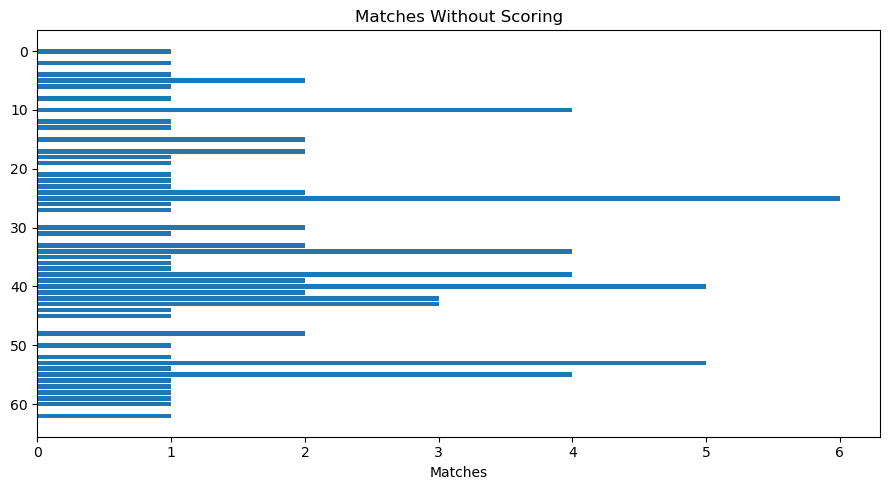

In [140]:
# Cell 268 - Plot Failed to Score

plt.figure(figsize=(9,5))

plt.barh(
    failed_scoring.index,
    failed_scoring["FailedToScore"]
)

plt.gca().invert_yaxis()

plt.xlabel("Matches")

plt.title("Matches Without Scoring")

plt.tight_layout()

plt.show()

In [141]:
# Cell 269 - Team Efficiency Summary

efficiency_summary = (
    clean_sheets
    .merge(
        failed_scoring,
        left_index=True,
        right_index=True
    )
)

efficiency_summary

,Competition_x,Team_x,Matches_x,CleanSheets,CleanSheetRate,Competition_y,Team_y,Matches_y,FailedToScore,Rate
0,NLM-CZ,Dukes of Gloucester,3,1,0.33,NLM-CZ,Dukes of Gloucester,3,1,0.33
1,NLM-CZ,GHF Rift Pirates Men,1,0,0.00,NLM-CZ,GHF Rift Pirates Men,1,0,0.00
2,NLM-CZ,Nyari Hockey Club,1,0,0.00,NLM-CZ,Nyari Hockey Club,1,1,1.00
3,NLM-CZ,Thika Rovers,1,1,1.00,NLM-CZ,Thika Rovers,1,0,0.00
4,NLM-EZ,Black Tigers,9,2,0.22,NLM-EZ,Black Tigers,9,1,0.11
...,...,...,...,...,...,...,...,...,...,...
58,SLW,Lakers Hockey Club – B,6,4,0.67,SLW,Lakers Hockey Club – B,6,1,0.17
59,SLW,Mombasa Sports Club Ladies,4,1,0.25,SLW,Mombasa Sports Club Ladies,4,1,0.25
60,SLW,Swans Hockey Club,4,0,0.00,SLW,Swans Hockey Club,4,1,0.25
61,SLW,Twinkle Hockey Club,5,4,0.80,SLW,Twinkle Hockey Club,5,0,0.00


In [142]:
# Cell 270 - Save Efficiency Summary

efficiency_summary.to_csv(
    "../data/processed/team_efficiency.csv"
)

print("Team efficiency summary saved.")

Team efficiency summary saved.


In [143]:
# Cell 271 - Scoring Rate

league_table["ScoringRate"] = (
    league_table["GF"] /
    league_table["Played"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "Played",
        "GF",
        "ScoringRate"
    ]
].sort_values(
    ["Competition", "ScoringRate"],
    ascending=[True, False]
)

,Competition,Team,Played,GF,ScoringRate
0,NLM-CZ,GHF Rift Pirates Men,1,9,9.00
1,NLM-CZ,Thika Rovers,1,8,8.00
2,NLM-CZ,Dukes of Gloucester,3,6,2.00
3,NLM-CZ,Nyari Hockey Club,1,0,0.00
11,NLM-EZ,TUK Men,2,4,2.00
...,...,...,...,...,...
58,SLW,Swans Hockey Club,4,4,1.00
60,SLW,Mombasa Sports Club Ladies,4,3,0.75
61,SLW,Gorillas Hockey Club – Ladies,3,2,0.67
59,SLW,Daystar University Ladies,5,3,0.60


In [144]:
# Cell 272 - Defensive Rate

league_table["ConcedingRate"] = (
    league_table["GA"] /
    league_table["Played"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "GA",
        "ConcedingRate"
    ]
].sort_values(
    ["Competition", "ConcedingRate"],
    ascending=[True, True]
)

,Competition,Team,GA,ConcedingRate
1,NLM-CZ,Thika Rovers,0,0.00
0,NLM-CZ,GHF Rift Pirates Men,1,1.00
3,NLM-CZ,Nyari Hockey Club,5,5.00
2,NLM-CZ,Dukes of Gloucester,17,5.67
4,NLM-EZ,Ulinzi Patriots,8,1.00
...,...,...,...,...
57,SLW,GHF Rift Pirates Ladies,7,1.17
60,SLW,Mombasa Sports Club Ladies,5,1.25
59,SLW,Daystar University Ladies,9,1.80
61,SLW,Gorillas Hockey Club – Ladies,6,2.00


In [145]:
# Cell 273 - Net Performance

league_table["NetPerformance"] = (
    league_table["ScoringRate"] -
    league_table["ConcedingRate"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "NetPerformance"
    ]
].sort_values(
    ["Competition", "NetPerformance"],
    ascending=[True, False]
)

,Competition,Team,NetPerformance
0,NLM-CZ,GHF Rift Pirates Men,8.00
1,NLM-CZ,Thika Rovers,8.00
2,NLM-CZ,Dukes of Gloucester,-3.67
3,NLM-CZ,Nyari Hockey Club,-5.00
4,NLM-EZ,Ulinzi Patriots,0.75
...,...,...,...
58,SLW,Swans Hockey Club,0.00
60,SLW,Mombasa Sports Club Ladies,-0.50
59,SLW,Daystar University Ladies,-1.20
61,SLW,Gorillas Hockey Club – Ladies,-1.33


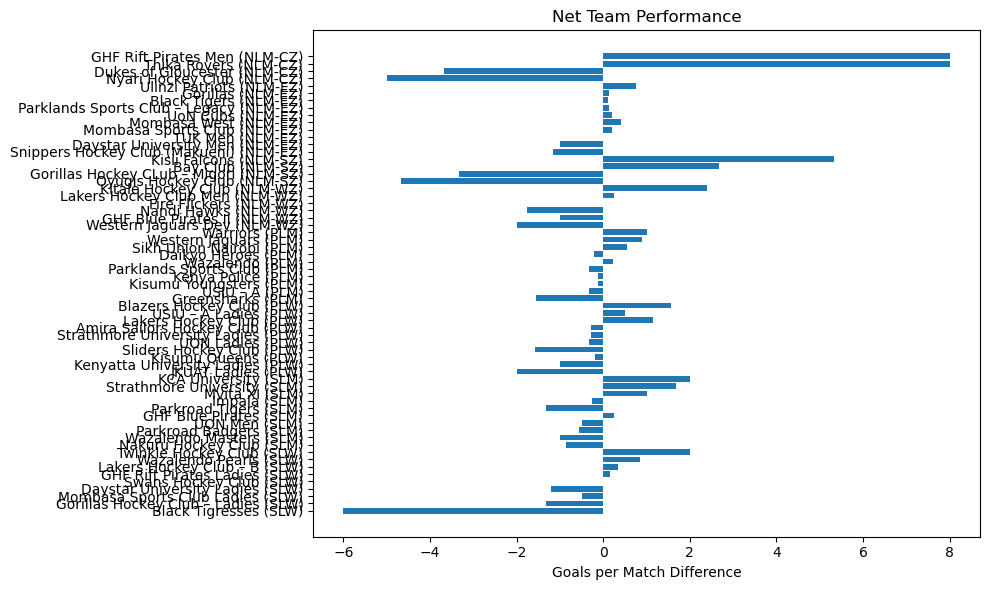

In [146]:
# Cell 274 - Plot Net Performance

plt.figure(figsize=(10,6))

plt.barh(
    (league_table["Team"] + " (" + league_table["Competition"] + ")"),
    league_table["NetPerformance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goals per Match Difference")

plt.title("Net Team Performance")

plt.tight_layout()

plt.show()

In [147]:
# Cell 275 - Points per Match

league_table["PPM"] = (
    league_table["Points"] /
    league_table["Played"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "PPM"
    ]
].sort_values(
    ["Competition", "PPM"],
    ascending=[True, False]
)

,Competition,Team,PPM
0,NLM-CZ,GHF Rift Pirates Men,3.00
1,NLM-CZ,Thika Rovers,3.00
2,NLM-CZ,Dukes of Gloucester,1.00
3,NLM-CZ,Nyari Hockey Club,0.00
4,NLM-EZ,Ulinzi Patriots,2.12
...,...,...,...
58,SLW,Swans Hockey Club,1.25
59,SLW,Daystar University Ladies,0.60
60,SLW,Mombasa Sports Club Ladies,0.50
61,SLW,Gorillas Hockey Club – Ladies,0.00


In [148]:
# Cell 276 - Goal Difference per Match

league_table["GDPerMatch"] = (
    league_table["GD"] /
    league_table["Played"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "GDPerMatch"
    ]
].sort_values(
    ["Competition", "GDPerMatch"],
    ascending=[True, False]
)

,Competition,Team,GDPerMatch
0,NLM-CZ,GHF Rift Pirates Men,8.00
1,NLM-CZ,Thika Rovers,8.00
2,NLM-CZ,Dukes of Gloucester,-3.67
3,NLM-CZ,Nyari Hockey Club,-5.00
4,NLM-EZ,Ulinzi Patriots,0.75
...,...,...,...
58,SLW,Swans Hockey Club,0.00
60,SLW,Mombasa Sports Club Ladies,-0.50
59,SLW,Daystar University Ladies,-1.20
61,SLW,Gorillas Hockey Club – Ladies,-1.33


In [149]:
# Cell 277 - Efficiency Rating

league_table["EfficiencyRating"] = (
    (
        league_table["PPM"] +
        league_table["NetPerformance"]
    ) / 2
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "EfficiencyRating"
    ]
].sort_values(
    ["Competition", "EfficiencyRating"],
    ascending=[True, False]
)

,Competition,Team,EfficiencyRating
0,NLM-CZ,GHF Rift Pirates Men,5.50
1,NLM-CZ,Thika Rovers,5.50
2,NLM-CZ,Dukes of Gloucester,-1.34
3,NLM-CZ,Nyari Hockey Club,-2.50
4,NLM-EZ,Ulinzi Patriots,1.44
...,...,...,...
58,SLW,Swans Hockey Club,0.62
60,SLW,Mombasa Sports Club Ladies,0.00
59,SLW,Daystar University Ladies,-0.30
61,SLW,Gorillas Hockey Club – Ladies,-0.66


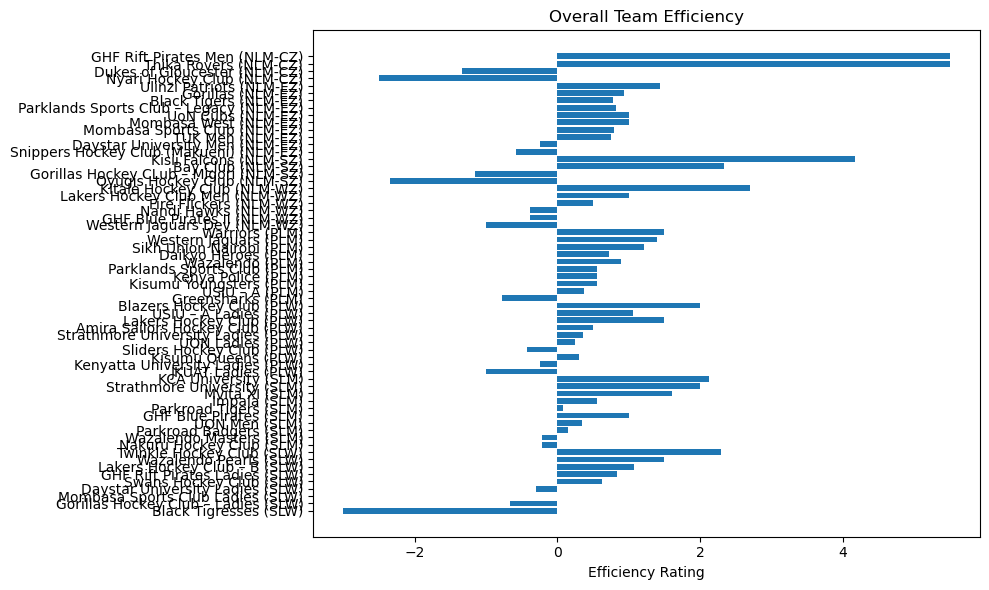

In [150]:
# Cell 278 - Plot Efficiency Rating

plt.figure(figsize=(10,6))

plt.barh(
    (league_table["Team"] + " (" + league_table["Competition"] + ")"),
    league_table["EfficiencyRating"]
)

plt.gca().invert_yaxis()

plt.xlabel("Efficiency Rating")

plt.title("Overall Team Efficiency")

plt.tight_layout()

plt.show()

In [151]:
# Cell 279 - Save Performance Metrics

league_table.to_csv(
    "../data/processed/performance_metrics.csv",
    index=False
)

print("Performance metrics saved.")

Performance metrics saved.


In [152]:
# Cell 280 - League Snapshot

print("="*60)
print("LEAGUE SNAPSHOT")
print("="*60)

print()

print("Highest Scoring Team:")
print(
    league_table.loc[
        league_table["GF"].idxmax(),
        "Team"
    ]
)

print()

print("Best Defence:")
print(
    league_table.loc[
        league_table["GA"].idxmin(),
        "Team"
    ]
)

print()

print("Most Efficient Team:")
print(
    league_table.loc[
        league_table["EfficiencyRating"].idxmax(),
        "Team"
    ]
)

print()

print("Highest Points Per Match:")
print(
    league_table.loc[
        league_table["PPM"].idxmax(),
        "Team"
    ]
)

LEAGUE SNAPSHOT

Highest Scoring Team:
KCA University

Best Defence:
Thika Rovers

Most Efficient Team:
GHF Rift Pirates Men

Highest Points Per Match:
GHF Rift Pirates Men


In [153]:
# Cell 281 - Attack Rank

league_table["AttackRank"] = (
    league_table["GF"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype("Int64")
)

league_table[
    [
        "Competition",
        "Team",
        "GF",
        "AttackRank"
    ]
].sort_values(
    ["Competition", "AttackRank"],
    ascending=[True, True]
)

,Competition,Team,GF,AttackRank
0,NLM-CZ,GHF Rift Pirates Men,9,12
1,NLM-CZ,Thika Rovers,8,13
2,NLM-CZ,Dukes of Gloucester,6,15
3,NLM-CZ,Nyari Hockey Club,0,21
4,NLM-EZ,Ulinzi Patriots,14,7
...,...,...,...,...
58,SLW,Swans Hockey Club,4,17
59,SLW,Daystar University Ladies,3,18
60,SLW,Mombasa Sports Club Ladies,3,18
61,SLW,Gorillas Hockey Club – Ladies,2,19


In [154]:
# Cell 282 - Defence Rank

league_table["DefenceRank"] = (
    league_table["GA"]
    .rank(
        ascending=True,
        method="dense"
    )
    .astype("Int64")
)

league_table[
    [
        "Competition",
        "Team",
        "GA",
        "DefenceRank"
    ]
].sort_values(
    ["Competition", "DefenceRank"],
    ascending=[True, True]
)

,Competition,Team,GA,DefenceRank
1,NLM-CZ,Thika Rovers,0,1
0,NLM-CZ,GHF Rift Pirates Men,1,2
3,NLM-CZ,Nyari Hockey Club,5,6
2,NLM-CZ,Dukes of Gloucester,17,18
11,NLM-EZ,TUK Men,4,5
...,...,...,...,...
60,SLW,Mombasa Sports Club Ladies,5,6
61,SLW,Gorillas Hockey Club – Ladies,6,7
62,SLW,Black Tigresses,6,7
57,SLW,GHF Rift Pirates Ladies,7,8


In [155]:
# Cell 283 - Goal Difference Rank

league_table["GDRank"] = (
    league_table["GD"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype("Int64")
)

league_table[
    [
        "Competition",
        "Team",
        "GD",
        "GDRank"
    ]
].sort_values(
    ["Competition", "GDRank"],
    ascending=[True, True]
)

,Competition,Team,GD,GDRank
0,NLM-CZ,GHF Rift Pirates Men,8,6
1,NLM-CZ,Thika Rovers,8,6
3,NLM-CZ,Nyari Hockey Club,-5,18
2,NLM-CZ,Dukes of Gloucester,-11,24
4,NLM-EZ,Ulinzi Patriots,6,8
...,...,...,...,...
58,SLW,Swans Hockey Club,0,13
60,SLW,Mombasa Sports Club Ladies,-2,15
61,SLW,Gorillas Hockey Club – Ladies,-4,17
59,SLW,Daystar University Ladies,-6,19


In [156]:
# Cell 284 - Points Rank

league_table["PointsRank"] = (
    league_table["Points"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype("Int64")
)

league_table[
    [
        "Competition",
        "Team",
        "Points",
        "PointsRank"
    ]
].sort_values(
    ["Competition", "PointsRank"],
    ascending=[True, True]
)

,Competition,Team,Points,PointsRank
0,NLM-CZ,GHF Rift Pirates Men,3,15
1,NLM-CZ,Thika Rovers,3,15
2,NLM-CZ,Dukes of Gloucester,3,15
3,NLM-CZ,Nyari Hockey Club,0,18
4,NLM-EZ,Ulinzi Patriots,17,2
...,...,...,...,...
58,SLW,Swans Hockey Club,5,13
59,SLW,Daystar University Ladies,3,15
60,SLW,Mombasa Sports Club Ladies,2,16
61,SLW,Gorillas Hockey Club – Ladies,0,18


In [157]:
# Cell 285 - Composite Rating

league_table["CompositeRating"] = (
    league_table["AttackStrength"] +
    league_table["DefenceStrength"] +
    league_table["EfficiencyRating"]
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "CompositeRating"
    ]
].sort_values(
    ["Competition", "CompositeRating"],
    ascending=[True, False]
)

,Competition,Team,CompositeRating
1,NLM-CZ,Thika Rovers,15.26
0,NLM-CZ,GHF Rift Pirates Men,10.31
2,NLM-CZ,Dukes of Gloucester,-0.41
3,NLM-CZ,Nyari Hockey Club,-1.92
4,NLM-EZ,Ulinzi Patriots,4.11
...,...,...,...
58,SLW,Swans Hockey Club,3.26
60,SLW,Mombasa Sports Club Ladies,2.07
59,SLW,Daystar University Ladies,1.21
61,SLW,Gorillas Hockey Club – Ladies,0.82


In [158]:
# Cell 286 - Composite Ranking

league_table["CompositeRank"] = (
    league_table["CompositeRating"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype("Int64")  # nullable int — some teams may have NaN composite scores from very small-sample competitions
)

league_table[
    [
        "Competition",
        "Team",
        "CompositeRating",
        "CompositeRank"
    ]
].sort_values(
    ["Competition", "CompositeRank"],
    ascending=[True, True]
)

,Competition,Team,CompositeRating,CompositeRank
1,NLM-CZ,Thika Rovers,15.26,1
0,NLM-CZ,GHF Rift Pirates Men,10.31,3
2,NLM-CZ,Dukes of Gloucester,-0.41,57
3,NLM-CZ,Nyari Hockey Club,-1.92,60
4,NLM-EZ,Ulinzi Patriots,4.11,16
...,...,...,...,...
58,SLW,Swans Hockey Club,3.26,23
60,SLW,Mombasa Sports Club Ladies,2.07,40
59,SLW,Daystar University Ladies,1.21,47
61,SLW,Gorillas Hockey Club – Ladies,0.82,51


In [159]:
# Cell 287 - Radar Dataset

radar_data = league_table[
    [
        "Competition",
        "Team",
        "AttackStrength",
        "DefenceStrength",
        "PPM",
        "EfficiencyRating",
        "CompositeRating"
    ]
]

radar_data.head()

,Competition,Team,AttackStrength,DefenceStrength,PPM,EfficiencyRating,CompositeRating
0,NLM-CZ,GHF Rift Pirates Men,1.89,2.92,3.00,5.50,10.31
1,NLM-CZ,Thika Rovers,1.68,8.08,3.00,5.50,15.26
2,NLM-CZ,Dukes of Gloucester,0.42,0.51,1.00,-1.34,-0.41
3,NLM-CZ,Nyari Hockey Club,0.00,0.58,0.00,-2.50,-1.92
4,NLM-EZ,Ulinzi Patriots,1.31,1.36,2.12,1.44,4.11


In [160]:
# Cell 288 - Save Radar Dataset

radar_data.to_csv(
    "../data/processed/radar_dataset.csv",
    index=False
)

print("Radar dataset saved.")

Radar dataset saved.


In [161]:
# Cell 289 - Dashboard Dataset

dashboard_data = league_table.copy()

dashboard_data.head()

,Position,Competition,Team,Played,Wins,Draws,Losses,GF,GA,GD,...,ConcedingRate,NetPerformance,PPM,EfficiencyRating,AttackRank,DefenceRank,GDRank,PointsRank,CompositeRating,CompositeRank
0,1,NLM-CZ,GHF Rift Pirates Men,1,1,0,0,9,1,8,...,1.00,8.00,3.00,5.50,12,2,6,15,10.31,3
1,2,NLM-CZ,Thika Rovers,1,1,0,0,8,0,8,...,0.00,8.00,3.00,5.50,13,1,6,15,15.26,1
2,3,NLM-CZ,Dukes of Gloucester,3,1,0,2,6,17,-11,...,5.67,-3.67,1.00,-1.34,15,18,24,15,-0.41,57
3,4,NLM-CZ,Nyari Hockey Club,1,0,0,1,0,5,-5,...,5.00,-5.00,0.00,-2.50,21,6,18,18,-1.92,60
4,1,NLM-EZ,Ulinzi Patriots,8,5,2,1,14,8,6,...,1.00,0.75,2.12,1.44,7,9,8,2,4.11,16


In [162]:
# Cell 290 - Save Dashboard Dataset

dashboard_data.to_csv(
    "../data/processed/dashboard_dataset.csv",
    index=False
)

print("Dashboard dataset saved.")

Dashboard dataset saved.


In [163]:
# Cell 291 - Correlation Dataset

correlation_data = league_table[
    [
        "GF",
        "GA",
        "GD",
        "Points",
        "AttackStrength",
        "DefenceStrength",
        "OverallStrength",
        "RankingScore",
        "OffensiveEfficiency",
        "DefensiveEfficiency",
        "NetPerformance",
        "PPM",
        "EfficiencyRating"
    ]
]

correlation_data.head()

,GF,GA,GD,Points,AttackStrength,DefenceStrength,OverallStrength,RankingScore,OffensiveEfficiency,DefensiveEfficiency,NetPerformance,PPM,EfficiencyRating
0,9,1,8,3,1.89,2.92,2.40,1.88,9.00,1.00,8.00,3.00,5.50
1,8,0,8,3,1.68,8.08,4.88,0.79,8.00,0.00,8.00,3.00,5.50
2,6,17,-11,3,0.42,0.51,0.46,0.92,2.00,5.67,-3.67,1.00,-1.34
3,0,5,-5,0,0.00,0.58,0.29,0.28,0.00,5.00,-5.00,0.00,-2.50
4,14,8,6,17,1.31,1.36,1.34,1.58,1.75,1.00,0.75,2.12,1.44


In [164]:
# Cell 292 - Correlation Matrix

corr_matrix = correlation_data.corr(numeric_only=True)

corr_matrix.round(2)

,GF,GA,GD,Points,AttackStrength,DefenceStrength,OverallStrength,RankingScore,OffensiveEfficiency,DefensiveEfficiency,NetPerformance,PPM,EfficiencyRating
GF,1.00,0.31,0.65,0.86,0.68,0.23,0.41,0.74,0.47,-0.33,0.49,0.67,0.56
GA,0.31,1.00,-0.52,0.15,-0.28,-0.50,-0.48,-0.07,-0.24,0.45,-0.40,-0.29,-0.38
GD,0.65,-0.52,1.00,0.65,0.83,0.60,0.75,0.72,0.61,-0.65,0.76,0.83,0.81
Points,0.86,0.15,0.65,1.00,0.65,0.13,0.32,0.82,0.23,-0.44,0.39,0.71,0.49
AttackStrength,0.68,-0.28,0.83,0.65,1.00,0.54,0.76,0.85,0.65,-0.58,0.76,0.86,0.82
DefenceStrength,0.23,-0.50,0.60,0.13,0.54,1.00,0.96,0.19,0.73,-0.50,0.77,0.64,0.76
OverallStrength,0.41,-0.48,0.75,0.32,0.76,0.96,1.00,0.44,0.79,-0.58,0.85,0.79,0.87
RankingScore,0.74,-0.07,0.72,0.82,0.85,0.19,0.44,1.00,0.49,-0.45,0.58,0.86,0.68
OffensiveEfficiency,0.47,-0.24,0.61,0.23,0.65,0.73,0.79,0.49,1.00,-0.33,0.87,0.75,0.87
DefensiveEfficiency,-0.33,0.45,-0.65,-0.44,-0.58,-0.50,-0.58,-0.45,-0.33,1.00,-0.76,-0.57,-0.74


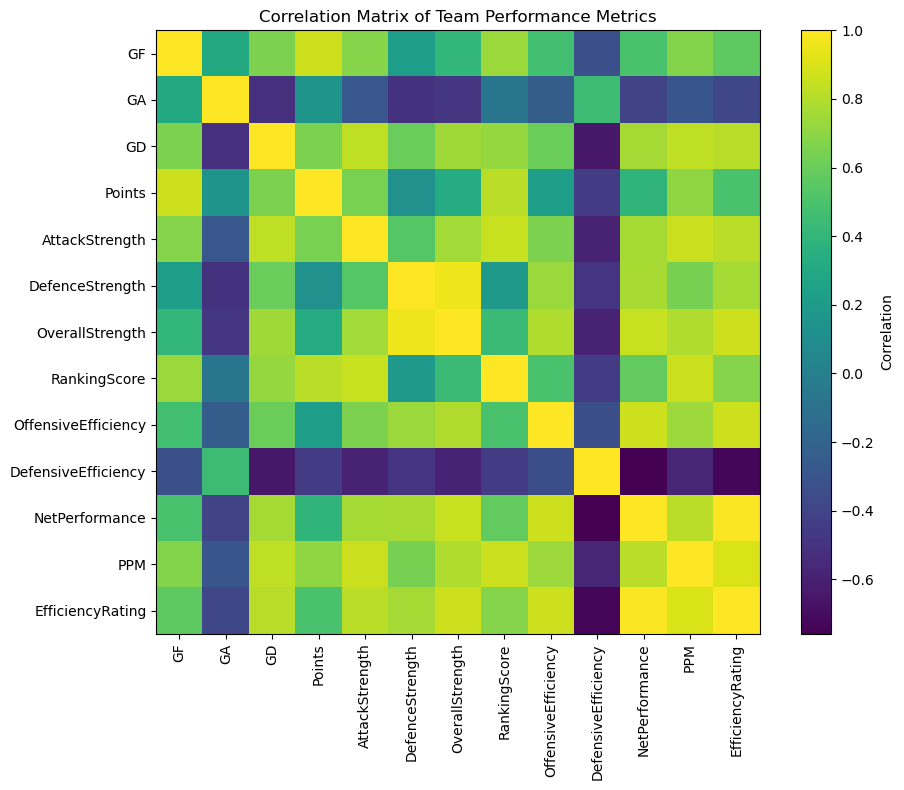

In [165]:
# Cell 293 - Correlation Heatmap

plt.figure(figsize=(10,8))

plt.imshow(corr_matrix)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix of Team Performance Metrics")

plt.tight_layout()

plt.show()

In [166]:
# Cell 294 - Strongest Positive Correlations

corr_pairs = (
    corr_matrix
    .unstack()
    .reset_index()
)

corr_pairs.columns = [
    "Metric1",
    "Metric2",
    "Correlation"
]

corr_pairs = corr_pairs[
    corr_pairs["Metric1"] < corr_pairs["Metric2"]
]

corr_pairs.sort_values(
    "Correlation",
    ascending=False
).head(15)

,Metric1,Metric2,Correlation
166,EfficiencyRating,NetPerformance,0.987413
71,DefenceStrength,OverallStrength,0.958454
167,EfficiencyRating,PPM,0.898192
162,EfficiencyRating,OverallStrength,0.868084
138,NetPerformance,OffensiveEfficiency,0.867026
164,EfficiencyRating,OffensiveEfficiency,0.866092
3,GF,Points,0.862628
150,PPM,RankingScore,0.861850
63,AttackStrength,PPM,0.859749
136,NetPerformance,OverallStrength,0.854077


In [167]:
# Cell 296 - Correlation Summary

print("=" * 60)
print("CORRELATION INSIGHTS")
print("=" * 60)

top10 = (
    corr_pairs
    .sort_values("Correlation", ascending=False)
    .head(10)
)

for _, row in top10.iterrows():
    print(
        f"{row['Metric1']} ↔ {row['Metric2']} : "
        f"{row['Correlation']:.3f}"
    )

CORRELATION INSIGHTS
EfficiencyRating ↔ NetPerformance : 0.987
DefenceStrength ↔ OverallStrength : 0.958
EfficiencyRating ↔ PPM : 0.898
EfficiencyRating ↔ OverallStrength : 0.868
NetPerformance ↔ OffensiveEfficiency : 0.867
EfficiencyRating ↔ OffensiveEfficiency : 0.866
GF ↔ Points : 0.863
PPM ↔ RankingScore : 0.862
AttackStrength ↔ PPM : 0.860
NetPerformance ↔ OverallStrength : 0.854


In [168]:
# Cell 298 - Correlation with Points

points_corr = (
    corr_matrix["Points"]
    .drop("Points")
    .sort_values(ascending=False)
)

points_corr

GF                     0.862628
RankingScore           0.818377
PPM                    0.707704
GD                     0.650564
AttackStrength         0.645650
EfficiencyRating       0.493132
NetPerformance         0.391670
OverallStrength        0.320013
OffensiveEfficiency    0.226876
GA                     0.153525
DefenceStrength        0.130674
DefensiveEfficiency   -0.444551
Name: Points, dtype: float64

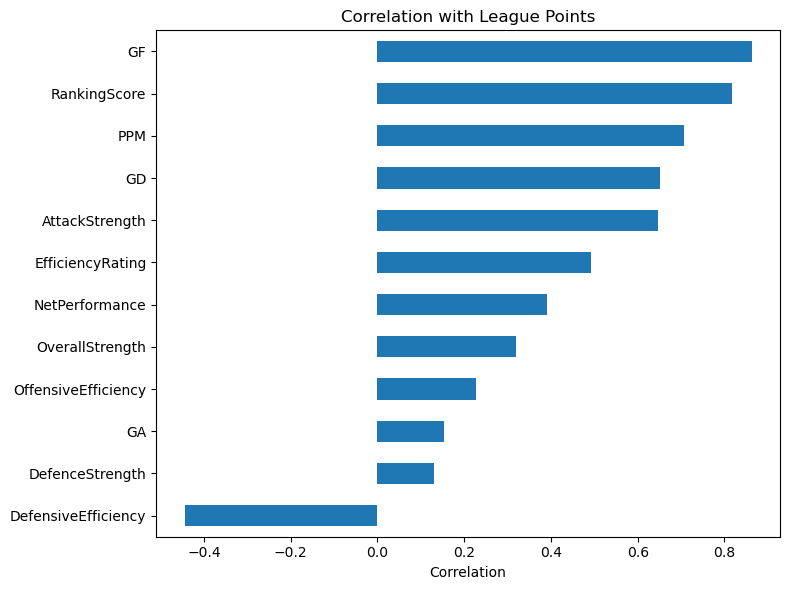

In [169]:
# Cell 299 - Metrics Explaining Points

plt.figure(figsize=(8,6))

points_corr.sort_values().plot(kind="barh")

plt.title("Correlation with League Points")

plt.xlabel("Correlation")

plt.tight_layout()

plt.show()

In [170]:
# Cell 300 - Save All Processed Data

matches_df.to_csv(
    "../data/processed/matches.csv",
    index=False
)

events_df.to_csv(
    "../data/processed/events.csv",
    index=False
)

results.to_csv(
    "../data/processed/results_dataset.csv",
    index=False
)

league_table.to_csv(
    "../data/processed/performance_metrics.csv",
    index=False
)

print("=" * 60)
print("CHECKPOINT COMPLETE")
print("All processed datasets have been saved.")
print("=" * 60)

CHECKPOINT COMPLETE
All processed datasets have been saved.


## Module 11: Team Intelligence

**Business Question:** How does each team play, and what tactical identity emerges from the available performance metrics?

**Outputs:** 
- Playing styles
- Team intelligence report
- Tactical recommendations


In [171]:
# Cell 301 - Team Profiles

team_profiles = league_table[
    [
        "Competition",
        "Team",
        "AttackStrength",
        "DefenceStrength",
        "OverallStrength",
        "PPM",
        "EfficiencyRating"
    ]
]

team_profiles

,Competition,Team,AttackStrength,DefenceStrength,OverallStrength,PPM,EfficiencyRating
0,NLM-CZ,GHF Rift Pirates Men,1.89,2.92,2.40,3.00,5.50
1,NLM-CZ,Thika Rovers,1.68,8.08,4.88,3.00,5.50
2,NLM-CZ,Dukes of Gloucester,0.42,0.51,0.46,1.00,-1.34
3,NLM-CZ,Nyari Hockey Club,0.00,0.58,0.29,0.00,-2.50
4,NLM-EZ,Ulinzi Patriots,1.31,1.36,1.34,2.12,1.44
...,...,...,...,...,...,...,...
58,SLW,Swans Hockey Club,0.92,1.72,1.32,1.25,0.62
59,SLW,Daystar University Ladies,0.55,0.96,0.76,0.60,-0.30
60,SLW,Mombasa Sports Club Ladies,0.69,1.38,1.03,0.50,0.00
61,SLW,Gorillas Hockey Club – Ladies,0.62,0.86,0.74,0.00,-0.66


In [172]:
# Cell 302 - League Benchmarks

median_attack = league_table["AttackStrength"].median()
median_defence = league_table["DefenceStrength"].median()

print("=" * 60)
print("LEAGUE BENCHMARKS")
print("=" * 60)
print(f"Median Attack Strength : {median_attack:.2f}")
print(f"Median Defence Strength: {median_defence:.2f}")

LEAGUE BENCHMARKS
Median Attack Strength : 0.94
Median Defence Strength: 1.05


In [173]:
# Cell 303 - Playing Style Classification

def classify_team(row):

    attack = row["AttackStrength"] >= median_attack
    defence = row["DefenceStrength"] >= median_defence

    if attack and defence:
        return "Balanced Contender"

    elif attack and not defence:
        return "Attack-Oriented"

    elif not attack and defence:
        return "Defensive"

    else:
        return "Needs Improvement"


league_table["PlayingStyle"] = league_table.apply(
    classify_team,
    axis=1
)

league_table[
    [
        "Competition",
        "Team",
        "PlayingStyle"
    ]
].sort_values(
    ["Competition", "PlayingStyle"],
    ascending=[True, True]
)

,Competition,Team,PlayingStyle
0,NLM-CZ,GHF Rift Pirates Men,Balanced Contender
1,NLM-CZ,Thika Rovers,Balanced Contender
2,NLM-CZ,Dukes of Gloucester,Needs Improvement
3,NLM-CZ,Nyari Hockey Club,Needs Improvement
6,NLM-EZ,Black Tigers,Attack-Oriented
...,...,...,...
58,SLW,Swans Hockey Club,Defensive
60,SLW,Mombasa Sports Club Ladies,Defensive
59,SLW,Daystar University Ladies,Needs Improvement
61,SLW,Gorillas Hockey Club – Ladies,Needs Improvement


In [174]:
# Cell 304 - Playing Styles Summary

league_table["PlayingStyle"].value_counts()

PlayingStyle
Balanced Contender    23
Needs Improvement     21
Attack-Oriented       10
Defensive              9
Name: count, dtype: int64

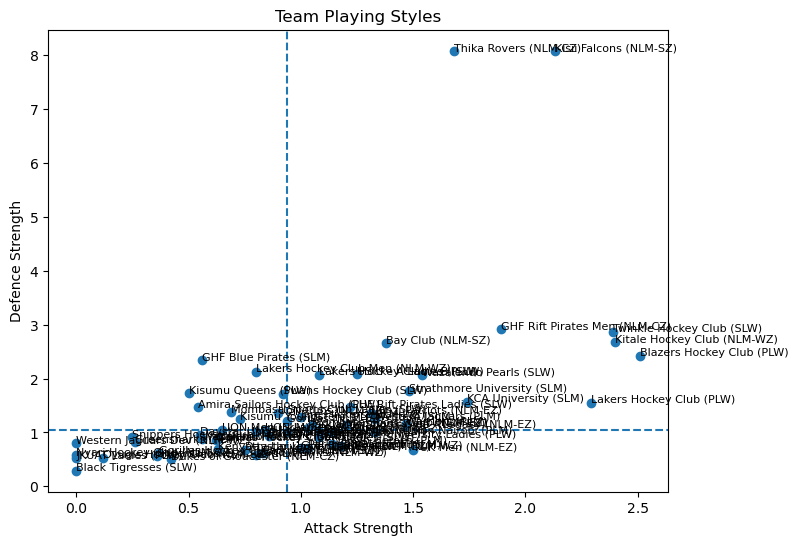

In [175]:
# Cell 305 - Attack vs Defence

plt.figure(figsize=(8,6))

plt.scatter(
    league_table["AttackStrength"],
    league_table["DefenceStrength"]
)

for _, row in league_table.iterrows():
    plt.text(
        row["AttackStrength"],
        row["DefenceStrength"],
        f'{row["Team"]} ({row["Competition"]})',
        fontsize=8
    )

plt.axvline(median_attack, linestyle="--")

plt.axhline(median_defence, linestyle="--")

plt.xlabel("Attack Strength")

plt.ylabel("Defence Strength")

plt.title("Team Playing Styles")

plt.show()

In [176]:
# Cell 306 - Team Intelligence Report

print("=" * 70)
print("TEAM INTELLIGENCE REPORT")
print("=" * 70)

for _, row in league_table.iterrows():

    print(f"\n{row['Team']}")

    print("-" * len(row["Team"]))

    print(f"Playing Style : {row['PlayingStyle']}")

    print(f"Attack Strength : {row['AttackStrength']:.2f}")

    print(f"Defence Strength : {row['DefenceStrength']:.2f}")

    print(f"PPM : {row['PPM']:.2f}")

    print(f"Efficiency Rating : {row['EfficiencyRating']:.2f}")

TEAM INTELLIGENCE REPORT

GHF Rift Pirates Men
--------------------
Playing Style : Balanced Contender
Attack Strength : 1.89
Defence Strength : 2.92
PPM : 3.00
Efficiency Rating : 5.50

Thika Rovers
------------
Playing Style : Balanced Contender
Attack Strength : 1.68
Defence Strength : 8.08
PPM : 3.00
Efficiency Rating : 5.50

Dukes of Gloucester
-------------------
Playing Style : Needs Improvement
Attack Strength : 0.42
Defence Strength : 0.51
PPM : 1.00
Efficiency Rating : -1.34

Nyari Hockey Club
-----------------
Playing Style : Needs Improvement
Attack Strength : 0.00
Defence Strength : 0.58
PPM : 0.00
Efficiency Rating : -2.50

Ulinzi Patriots
---------------
Playing Style : Balanced Contender
Attack Strength : 1.31
Defence Strength : 1.36
PPM : 2.12
Efficiency Rating : 1.44

Gorillas
--------
Playing Style : Balanced Contender
Attack Strength : 0.94
Defence Strength : 1.21
PPM : 1.75
Efficiency Rating : 0.94

Black Tigers
------------
Playing Style : Attack-Oriented
Attack S

In [177]:
# Cell 307 - Automated Insights

print("=" * 70)
print("AUTOMATED TEAM INSIGHTS")
print("=" * 70)

for _, row in league_table.iterrows():

    print(f"\n{row['Team']}")

    if row["PlayingStyle"] == "Balanced Contender":

        print(
            "This team performs above the league median in both attack and defence, "
            "indicating a balanced and consistent playing style."
        )

    elif row["PlayingStyle"] == "Attack-Oriented":

        print(
            "The team scores above the league median but trails defensively. "
            "Improving defensive organisation could increase overall competitiveness."
        )

    elif row["PlayingStyle"] == "Defensive":

        print(
            "The team defends effectively but creates fewer scoring opportunities. "
            "Greater attacking efficiency could improve results."
        )

    else:

        print(
            "The team is below the league median in both attack and defence. "
            "Improvements are needed in multiple areas to compete consistently."
        )

AUTOMATED TEAM INSIGHTS

GHF Rift Pirates Men
This team performs above the league median in both attack and defence, indicating a balanced and consistent playing style.

Thika Rovers
This team performs above the league median in both attack and defence, indicating a balanced and consistent playing style.

Dukes of Gloucester
The team is below the league median in both attack and defence. Improvements are needed in multiple areas to compete consistently.

Nyari Hockey Club
The team is below the league median in both attack and defence. Improvements are needed in multiple areas to compete consistently.

Ulinzi Patriots
This team performs above the league median in both attack and defence, indicating a balanced and consistent playing style.

Gorillas
This team performs above the league median in both attack and defence, indicating a balanced and consistent playing style.

Black Tigers
The team scores above the league median but trails defensively. Improving defensive organisation could in

In [178]:
# Cell 308 - Key Findings

print("=" * 70)
print("KEY FINDINGS")
print("=" * 70)

style_counts = league_table["PlayingStyle"].value_counts()

for style, count in style_counts.items():
    print(f"• {count} team(s) classified as {style}.")

print()

best_attack = league_table.loc[
    league_table["AttackStrength"].idxmax(),
    "Team"
]

best_defence = league_table.loc[
    league_table["DefenceStrength"].idxmax(),
    "Team"
]

best_ppm = league_table.loc[
    league_table["PPM"].idxmax(),
    "Team"
]

print(f"• Strongest attack      : {best_attack}")
print(f"• Strongest defence     : {best_defence}")
print(f"• Highest PPM           : {best_ppm}")

print()
print("Interpretation:")
print(
    "Teams performing above the league median in both attack and defence "
    "are considered the most balanced competitors. Teams falling below "
    "these benchmarks should prioritise improvements in their weaker phase "
    "of play."
)

KEY FINDINGS
• 23 team(s) classified as Balanced Contender.
• 21 team(s) classified as Needs Improvement.
• 10 team(s) classified as Attack-Oriented.
• 9 team(s) classified as Defensive.

• Strongest attack      : Blazers Hockey Club
• Strongest defence     : Thika Rovers
• Highest PPM           : GHF Rift Pirates Men

Interpretation:
Teams performing above the league median in both attack and defence are considered the most balanced competitors. Teams falling below these benchmarks should prioritise improvements in their weaker phase of play.


## Module 12: Dominance Analysis

**Business Question:** Which teams consistently dominate opponents rather than simply winning matches?

**Outputs:** 
- Dominance Index
- Dominance Classification
- Team Rankings
- Performance Narratives


In [179]:
# Cell 310 - Dominance Metrics

dominance_metrics = league_table[
    [
        "AttackStrength",
        "DefenceStrength",
        "NetPerformance",
        "EfficiencyRating",
        "PPM"
    ]
]

dominance_metrics.head()

,AttackStrength,DefenceStrength,NetPerformance,EfficiencyRating,PPM
0,1.89,2.92,8.00,5.50,3.00
1,1.68,8.08,8.00,5.50,3.00
2,0.42,0.51,-3.67,-1.34,1.00
3,0.00,0.58,-5.00,-2.50,0.00
4,1.31,1.36,0.75,1.44,2.12


In [180]:
# Cell 311 - Normalize Metrics

dominance_scaled = (
    dominance_metrics -
    dominance_metrics.min()
) / (
    dominance_metrics.max() -
    dominance_metrics.min()
)

dominance_scaled.head()

,AttackStrength,DefenceStrength,NetPerformance,EfficiencyRating,PPM
0,0.752988,0.337612,1.000000,1.000000,1.000000
1,0.669323,1.000000,1.000000,1.000000,1.000000
2,0.167331,0.028241,0.166429,0.195294,0.333333
3,0.000000,0.037227,0.071429,0.058824,0.000000
4,0.521912,0.137356,0.482143,0.522353,0.706667


In [181]:
# Cell 312 - Dominance Index

league_table["DominanceIndex"] = (
    dominance_scaled.mean(axis=1) * 100
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "DominanceIndex"
    ]
].sort_values(
    ["Competition", "DominanceIndex"],
    ascending=[True, False]
)

,Competition,Team,DominanceIndex
1,NLM-CZ,Thika Rovers,93.39
0,NLM-CZ,GHF Rift Pirates Men,81.81
2,NLM-CZ,Dukes of Gloucester,17.81
3,NLM-CZ,Nyari Hockey Club,3.35
4,NLM-EZ,Ulinzi Patriots,47.41
...,...,...,...
58,SLW,Swans Hockey Club,36.42
60,SLW,Mombasa Sports Club Ladies,26.55
59,SLW,Daystar University Ladies,23.31
61,SLW,Gorillas Hockey Club – Ladies,18.58


In [182]:
# Cell 313 - Dominance Categories

q1 = league_table["DominanceIndex"].quantile(0.25)
q2 = league_table["DominanceIndex"].quantile(0.50)
q3 = league_table["DominanceIndex"].quantile(0.75)

def dominance_category(score):

    if score >= q3:
        return "Elite"

    elif score >= q2:
        return "Strong"

    elif score >= q1:
        return "Competitive"

    else:
        return "Developing"

league_table["DominanceCategory"] = (
    league_table["DominanceIndex"]
    .apply(dominance_category)
)

league_table[
    [
        "Competition",
        "Team",
        "DominanceIndex",
        "DominanceCategory"
    ]
].sort_values(
    ["Competition", "DominanceIndex"],
    ascending=[True, False]
)

,Competition,Team,DominanceIndex,DominanceCategory
1,NLM-CZ,Thika Rovers,93.39,Elite
0,NLM-CZ,GHF Rift Pirates Men,81.81,Elite
2,NLM-CZ,Dukes of Gloucester,17.81,Developing
3,NLM-CZ,Nyari Hockey Club,3.35,Developing
4,NLM-EZ,Ulinzi Patriots,47.41,Elite
...,...,...,...,...
58,SLW,Swans Hockey Club,36.42,Strong
60,SLW,Mombasa Sports Club Ladies,26.55,Competitive
59,SLW,Daystar University Ladies,23.31,Developing
61,SLW,Gorillas Hockey Club – Ladies,18.58,Developing


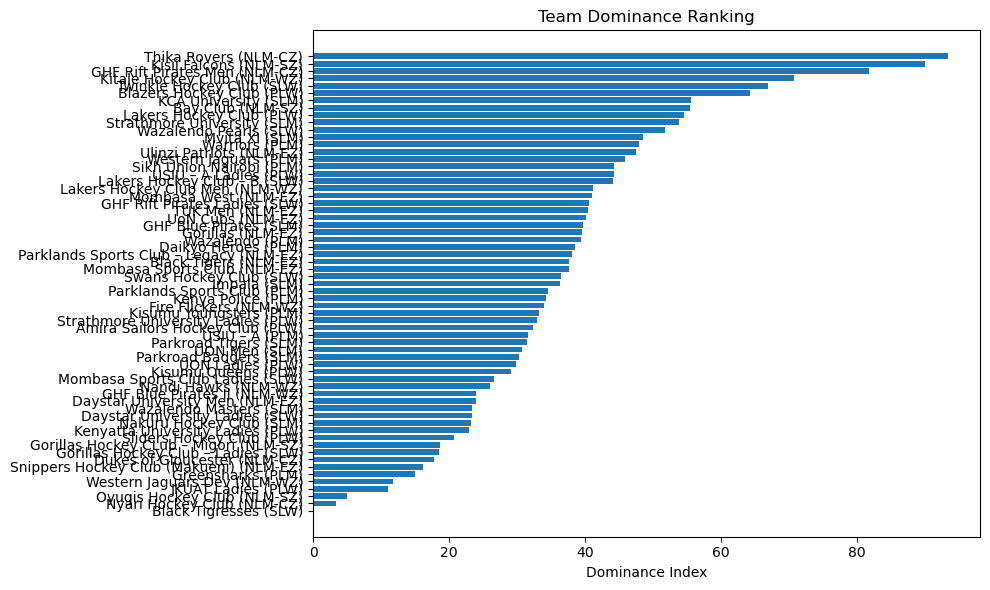

In [183]:
# Cell 314 - Dominance Ranking

ranking = league_table.sort_values(
    "DominanceIndex",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    (ranking["Team"] + " (" + ranking["Competition"] + ")"),
    ranking["DominanceIndex"]
)

plt.xlabel("Dominance Index")

plt.title("Team Dominance Ranking")

plt.tight_layout()

plt.show()

In [184]:
# Cell 315 - Dominance Narratives

print("=" * 70)
print("DOMINANCE REPORT")
print("=" * 70)

for _, row in league_table.sort_values(
    "DominanceIndex",
    ascending=False
).iterrows():

    print(f"\n{row['Team']}")
    print("-" * len(row["Team"]))

    print(
        f"Dominance Index : {row['DominanceIndex']:.1f}"
    )

    print(
        f"Category : {row['DominanceCategory']}"
    )

    if row["DominanceCategory"] == "Elite":
        print(
            "Consistently controls matches through strong attacking, defensive and overall efficiency. This team sets the benchmark for league performance."
        )

    elif row["DominanceCategory"] == "Strong":
        print(
            "Performs above average across most performance indicators and is capable of challenging the strongest teams."
        )

    elif row["DominanceCategory"] == "Competitive":
        print(
            "Shows competitive qualities but has room to improve consistency or balance between attack and defence."
        )

    else:
        print(
            "Currently trails the league leaders across multiple performance indicators. Focused development is needed to close the gap."
        )

DOMINANCE REPORT

Thika Rovers
------------
Dominance Index : 93.4
Category : Elite
Consistently controls matches through strong attacking, defensive and overall efficiency. This team sets the benchmark for league performance.

Kisii Falcons
-------------
Dominance Index : 90.0
Category : Elite
Consistently controls matches through strong attacking, defensive and overall efficiency. This team sets the benchmark for league performance.

GHF Rift Pirates Men
--------------------
Dominance Index : 81.8
Category : Elite
Consistently controls matches through strong attacking, defensive and overall efficiency. This team sets the benchmark for league performance.

Kitale Hockey Club
------------------
Dominance Index : 70.7
Category : Elite
Consistently controls matches through strong attacking, defensive and overall efficiency. This team sets the benchmark for league performance.

Twinkle Hockey Club
-------------------
Dominance Index : 66.9
Category : Elite
Consistently controls matches th

## Module 13: Executive Summary Engine

**Business Question:** What are the most important insights from the season?

**Outputs:** 
- League summary
- Best performing teams
- League competitiveness
- Coach's insights


In [185]:
# Cell 317 - League Leaders

league_leader = league_table.loc[
    league_table["Points"].idxmax()
]

best_attack = league_table.loc[
    league_table["AttackStrength"].idxmax()
]

best_defence = league_table.loc[
    league_table["DefenceStrength"].idxmax()
]

most_dominant = league_table.loc[
    league_table["DominanceIndex"].idxmax()
]

highest_efficiency = league_table.loc[
    league_table["EfficiencyRating"].idxmax()
]

In [186]:
# Cell 318 - League Statistics

elite = (league_table["DominanceCategory"] == "Elite").sum()
strong = (league_table["DominanceCategory"] == "Strong").sum()
competitive = (league_table["DominanceCategory"] == "Competitive").sum()
developing = (league_table["DominanceCategory"] == "Developing").sum()

average_goals = league_table["GF"].sum() / league_table["Played"].sum()

average_points = league_table["Points"].mean()

In [187]:
# Cell 319 - Executive Summary

print("=" * 75)
print("KENYA HOCKEY PERFORMANCE INTELLIGENCE REPORT")
print("=" * 75)

print("\nLEAGUE LEADERS")

print(f"League Leader           : {league_leader['Team']}")
print(f"Most Dominant Team      : {most_dominant['Team']}")
print(f"Strongest Attack        : {best_attack['Team']}")
print(f"Strongest Defence       : {best_defence['Team']}")
print(f"Highest Efficiency      : {highest_efficiency['Team']}")

print("\nDOMINANCE PROFILE")

print(f"Elite Teams             : {elite}")
print(f"Strong Teams            : {strong}")
print(f"Competitive Teams       : {competitive}")
print(f"Developing Teams        : {developing}")

print("\nLEAGUE AVERAGES")

print(f"Average Goals/Game      : {average_goals:.2f}")
print(f"Average Team Points     : {average_points:.2f}")

KENYA HOCKEY PERFORMANCE INTELLIGENCE REPORT

LEAGUE LEADERS
League Leader           : Warriors
Most Dominant Team      : Thika Rovers
Strongest Attack        : Blazers Hockey Club
Strongest Defence       : Thika Rovers
Highest Efficiency      : GHF Rift Pirates Men

DOMINANCE PROFILE
Elite Teams             : 16
Strong Teams            : 16
Competitive Teams       : 15
Developing Teams        : 16

LEAGUE AVERAGES
Average Goals/Game      : 1.53
Average Team Points     : 7.76


## Module 14: Results Efficiency Analysis

**Business Question:** Which teams convert their underlying performances into league points most efficiently?

**Why this matters:** Strong underlying performance does not always translate into positive match results. This module identifies teams that maximise their performances as well as those that may be leaving valuable points on the table.

**Outputs:** 
- Expected Performance Score
- Results Efficiency
- Efficiency Classification
- Performance Recommendations


In [188]:
# Cell 320 - Performance Analyst's Insights

print("\n" + "=" * 75)
print("PERFORMANCE ANALYST'S INSIGHTS")
print("=" * 75)

# -------------------------------------------------------
# Insight 1: Attack vs Defence Importance
# -------------------------------------------------------

attack_corr = corr_matrix.loc["AttackStrength", "Points"]
defence_corr = corr_matrix.loc["DefenceStrength", "Points"]

difference = abs(attack_corr - defence_corr)

if difference < 0.05:

    print(
        "\n1. Attacking and defensive performance contribute almost equally "
        "to league success this season, highlighting the importance of "
        "maintaining a balanced playing style."
    )

elif attack_corr > defence_corr:

    print(
        "\n1. Offensive performance shows a stronger relationship with "
        "league success than defensive performance."
    )

else:

    print(
        "\n1. Defensive organisation shows a stronger relationship with "
        "league success than attacking performance."
    )

# -------------------------------------------------------
# Insight 2: League Competitiveness
# -------------------------------------------------------

dominance_gap = (
    league_table["DominanceIndex"].max() -
    league_table["DominanceIndex"].min()
)

print(
    f"\n2. The Relative Dominance Index ranges from "
    f"{league_table['DominanceIndex'].min():.1f} "
    f"to {league_table['DominanceIndex'].max():.1f}, "
    f"creating a gap of {dominance_gap:.1f} points. "
    "This indicates a clear separation between the league's strongest "
    "and weakest teams."
)

# -------------------------------------------------------
# Insight 3: Benchmark Team
# -------------------------------------------------------

elite_team = league_table.loc[
    league_table["DominanceIndex"].idxmax()
]

print(
    f"\n3. {elite_team['Team']} sets the current league benchmark, "
    "combining elite attacking quality, defensive strength and "
    "overall efficiency."
)

# -------------------------------------------------------
# Insight 4: Development Priorities
# -------------------------------------------------------

developing = league_table[
    league_table["DominanceCategory"] == "Developing"
]

print(
    f"\n4. {len(developing)} teams fall into the Developing category. "
    "These teams should prioritise improvements in their weakest "
    "performance indicators before introducing more advanced tactical "
    "approaches."
)

# -------------------------------------------------------
# Insight 5: Overall Conclusion
# -------------------------------------------------------

print(
    "\n5. Overall, the league exhibits a competitive top tier supported "
    "by a noticeable performance gap to the lower-ranked teams. "
    "Closing this gap will require improvements in both attacking "
    "efficiency and defensive consistency among developing clubs."
)


PERFORMANCE ANALYST'S INSIGHTS

1. Offensive performance shows a stronger relationship with league success than defensive performance.

2. The Relative Dominance Index ranges from 0.0 to 93.4, creating a gap of 93.4 points. This indicates a clear separation between the league's strongest and weakest teams.

3. Thika Rovers sets the current league benchmark, combining elite attacking quality, defensive strength and overall efficiency.

4. 16 teams fall into the Developing category. These teams should prioritise improvements in their weakest performance indicators before introducing more advanced tactical approaches.

5. Overall, the league exhibits a competitive top tier supported by a noticeable performance gap to the lower-ranked teams. Closing this gap will require improvements in both attacking efficiency and defensive consistency among developing clubs.


## Module 15: Performance Quadrant Analysis

**Business Question:** Do teams achieve results consistent with their underlying performance levels?

**Analytical Rationale:** Comparing Expected Performance with Points Per Match distinguishes between teams that consistently convert performance into results and those that may be overachieving or underachieving.

**Outputs:** 
- Expected Performance Score
- Performance Quadrants
- Quadrant Visualisation
- Team Narratives
- Analyst Recommendations


In [189]:
# Cell 322 - Expected Performance Score

performance_metrics = league_table[
    [
        "AttackStrength",
        "DefenceStrength",
        "EfficiencyRating",
        "NetPerformance"
    ]
]

performance_scaled = (
    performance_metrics -
    performance_metrics.min()
) / (
    performance_metrics.max() -
    performance_metrics.min()
)

league_table["ExpectedScore"] = (
    performance_scaled.mean(axis=1) * 100
).round(2)

league_table[
    [
        "Competition",
        "Team",
        "ExpectedScore"
    ]
].sort_values(
    ["Competition", "ExpectedScore"],
    ascending=[True, False]
)

,Competition,Team,ExpectedScore
1,NLM-CZ,Thika Rovers,91.73
0,NLM-CZ,GHF Rift Pirates Men,77.27
2,NLM-CZ,Dukes of Gloucester,13.93
3,NLM-CZ,Nyari Hockey Club,4.19
4,NLM-EZ,Ulinzi Patriots,41.59
...,...,...,...
58,SLW,Swans Hockey Club,35.11
60,SLW,Mombasa Sports Club Ladies,29.02
59,SLW,Daystar University Ladies,24.14
61,SLW,Gorillas Hockey Club – Ladies,23.23


In [190]:
# Cell 323 - League Benchmarks

avg_expected = league_table["ExpectedScore"].mean()

avg_ppm = league_table["PPM"].mean()

print(f"Average Expected Score : {avg_expected:.2f}")
print(f"Average PPM            : {avg_ppm:.2f}")

Average Expected Score : 35.03
Average PPM            : 1.33


In [191]:
# Cell 324 - Performance Quadrants

def classify_quadrant(row):

    if row["ExpectedScore"] >= avg_expected and row["PPM"] >= avg_ppm:
        return "Elite"

    elif row["ExpectedScore"] >= avg_expected and row["PPM"] < avg_ppm:
        return "Underachieving"

    elif row["ExpectedScore"] < avg_expected and row["PPM"] >= avg_ppm:
        return "Overachieving"

    else:
        return "Developing"

league_table["PerformanceQuadrant"] = (
    league_table.apply(
        classify_quadrant,
        axis=1
    )
)

league_table[
    [
        "Competition",
        "Team",
        "ExpectedScore",
        "PPM",
        "PerformanceQuadrant"
    ]
].sort_values(
    ["Competition", "ExpectedScore"],
    ascending=[True, False]
)

,Competition,Team,ExpectedScore,PPM,PerformanceQuadrant
1,NLM-CZ,Thika Rovers,91.73,3.00,Elite
0,NLM-CZ,GHF Rift Pirates Men,77.27,3.00,Elite
2,NLM-CZ,Dukes of Gloucester,13.93,1.00,Developing
3,NLM-CZ,Nyari Hockey Club,4.19,0.00,Developing
4,NLM-EZ,Ulinzi Patriots,41.59,2.12,Elite
...,...,...,...,...,...
58,SLW,Swans Hockey Club,35.11,1.25,Underachieving
60,SLW,Mombasa Sports Club Ladies,29.02,0.50,Developing
59,SLW,Daystar University Ladies,24.14,0.60,Developing
61,SLW,Gorillas Hockey Club – Ladies,23.23,0.00,Developing


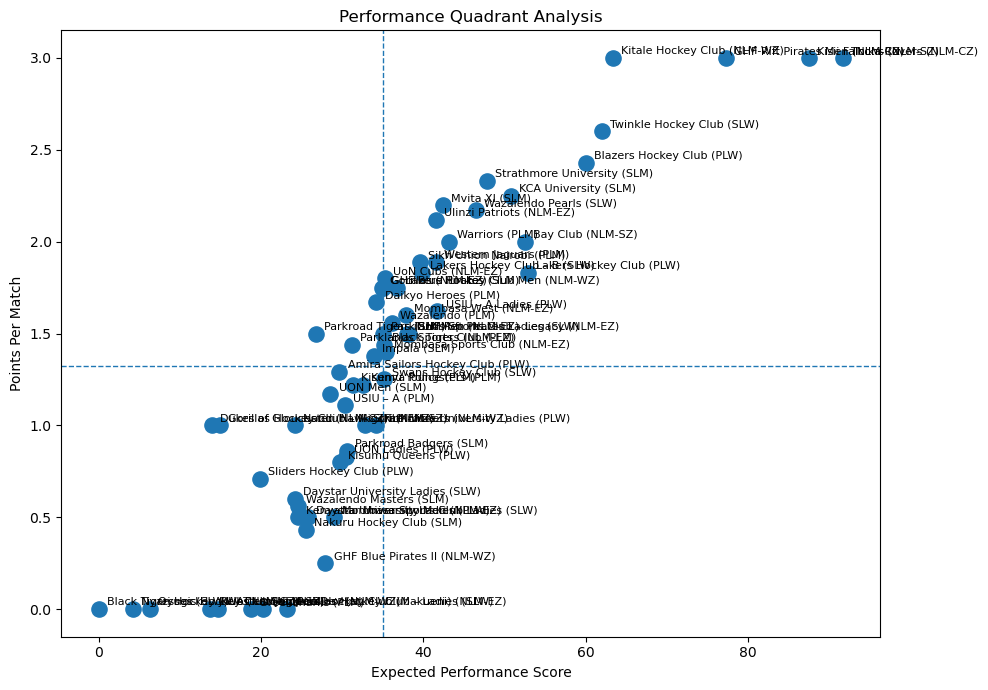

In [192]:
# Cell 325 - Performance Quadrant Scatter Plot

plt.figure(figsize=(10,7))

plt.scatter(
    league_table["ExpectedScore"],
    league_table["PPM"],
    s=120
)

for _, row in league_table.iterrows():

    plt.text(
        row["ExpectedScore"] + 1,
        row["PPM"] + 0.02,
        f'{row["Team"]} ({row["Competition"]})',
        fontsize=8
    )

plt.axvline(
    avg_expected,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    avg_ppm,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Expected Performance Score")

plt.ylabel("Points Per Match")

plt.title("Performance Quadrant Analysis")

plt.tight_layout()

plt.show()

In [193]:
# Cell 326 - Performance Quadrant Narratives

print("="*75)
print("PERFORMANCE QUADRANT REPORT")
print("="*75)

for _, row in league_table.sort_values(
    "ExpectedScore",
    ascending=False
).iterrows():

    print(f"\n{row['Team']}")
    print("-"*len(row["Team"]))

    print(f"Expected Score : {row['ExpectedScore']:.1f}")
    print(f"PPM            : {row['PPM']:.2f}")
    print(f"Classification : {row['PerformanceQuadrant']}")

    if row["PerformanceQuadrant"] == "Elite":

        print(
            "The team combines strong underlying performance with consistently strong match results, making it one of the league benchmarks."
        )

    elif row["PerformanceQuadrant"] == "Overachieving":

        print(
            "The team is producing better results than its underlying performance suggests. Sustaining this position may require improvements in overall performance metrics."
        )

    elif row["PerformanceQuadrant"] == "Underachieving":

        print(
            "Underlying performance indicators are stronger than the team's results. Improvements in finishing, decision-making and game management may convert performances into more points."
        )

    else:

        print(
            "Both performance indicators and match results remain below league averages. Development should focus on strengthening fundamental attacking and defensive performance."
        )

PERFORMANCE QUADRANT REPORT

Thika Rovers
------------
Expected Score : 91.7
PPM            : 3.00
Classification : Elite
The team combines strong underlying performance with consistently strong match results, making it one of the league benchmarks.

Kisii Falcons
-------------
Expected Score : 87.5
PPM            : 3.00
Classification : Elite
The team combines strong underlying performance with consistently strong match results, making it one of the league benchmarks.

GHF Rift Pirates Men
--------------------
Expected Score : 77.3
PPM            : 3.00
Classification : Elite
The team combines strong underlying performance with consistently strong match results, making it one of the league benchmarks.

Kitale Hockey Club
------------------
Expected Score : 63.3
PPM            : 3.00
Classification : Elite
The team combines strong underlying performance with consistently strong match results, making it one of the league benchmarks.

Twinkle Hockey Club
-------------------
Expected Scor

In [194]:
# Cell 327 - Performance Analyst Summary

print("="*75)
print("PERFORMANCE ANALYST SUMMARY")
print("="*75)

quadrant_counts = (
    league_table["PerformanceQuadrant"]
    .value_counts()
)

for category in [
    "Elite",
    "Overachieving",
    "Underachieving",
    "Developing"
]:

    count = quadrant_counts.get(category, 0)

    print(f"\n{category}: {count} team(s)")

print("\nKey Observations")

elite = league_table[
    league_table["PerformanceQuadrant"] == "Elite"
]

print(
    f"• {len(elite)} teams currently combine strong performances with consistently positive results."
)

print(
    "• Overachieving teams should improve their underlying performance to sustain current results."
)

print(
    "• Underachieving teams have the greatest potential for improvement without major tactical restructuring."
)

print(
    "• Developing teams should prioritise improving core attacking and defensive metrics before introducing advanced tactical systems."
)

PERFORMANCE ANALYST SUMMARY

Elite: 27 team(s)

Overachieving: 6 team(s)

Underachieving: 1 team(s)

Developing: 29 team(s)

Key Observations
• 27 teams currently combine strong performances with consistently positive results.
• Overachieving teams should improve their underlying performance to sustain current results.
• Underachieving teams have the greatest potential for improvement without major tactical restructuring.
• Developing teams should prioritise improving core attacking and defensive metrics before introducing advanced tactical systems.


In [195]:
# Cell 328 - Save Checkpoint

league_table.to_csv(
    "../data/processed/performance_metrics.csv",
    index=False
)

print("✓ Module 14 checkpoint saved.")

✓ Module 14 checkpoint saved.


## Module 16: Competitive Balance Analysis

**Business Question:** How competitively balanced is the league?

**Analytical Rationale:** This module evaluates whether league success is evenly distributed or concentrated among a few teams.

**Outputs:** 
- League Summary Statistics
- Competitive Balance Indicators
- Distribution Visualisations
- Analyst Interpretation


In [196]:
# Cell 330 - League Summary Statistics

league_summary = pd.DataFrame({

    "Statistic": [

        "Number of Teams",
        "Total Matches",
        "Average Points",
        "Median Points",
        "Maximum Points",
        "Minimum Points",
        "Average Goal Difference",
        "Average Points Per Match"

    ],

    "Value": [

        len(league_table),

        len(matches_df),

        round(league_table["Points"].mean(),2),

        round(league_table["Points"].median(),2),

        league_table["Points"].max(),

        league_table["Points"].min(),

        round(league_table["GD"].mean(),2),

        round(league_table["PPM"].mean(),2)

    ]

})

league_summary

,Statistic,Value
0,Number of Teams,63.00
1,Total Matches,177.00
2,Average Points,7.76
3,Median Points,7.00
4,Maximum Points,18.00
5,Minimum Points,0.00
6,Average Goal Difference,0.00
7,Average Points Per Match,1.33


In [197]:
# Cell 331 - Competitive Balance Indicators

points_std = league_table["Points"].std()

points_cv = (
    points_std /
    league_table["Points"].mean()
)

ppm_std = league_table["PPM"].std()

league_balance = pd.DataFrame({

    "Metric":[

        "Points Standard Deviation",
        "Points Coefficient of Variation",
        "PPM Standard Deviation"

    ],

    "Value":[

        round(points_std,2),

        round(points_cv,2),

        round(ppm_std,2)

    ]

})

league_balance

,Metric,Value
0,Points Standard Deviation,5.50
1,Points Coefficient of Variation,0.71
2,PPM Standard Deviation,0.83


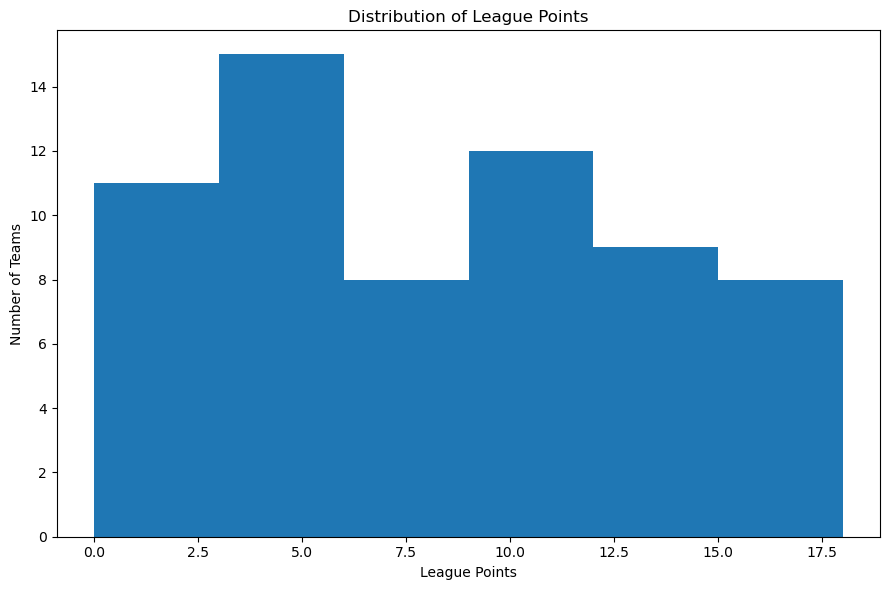

In [198]:
# Cell 332 - Points Distribution

plt.figure(figsize=(9,6))

plt.hist(
    league_table["Points"],
    bins=6
)

plt.xlabel("League Points")

plt.ylabel("Number of Teams")

plt.title("Distribution of League Points")

plt.tight_layout()

plt.show()

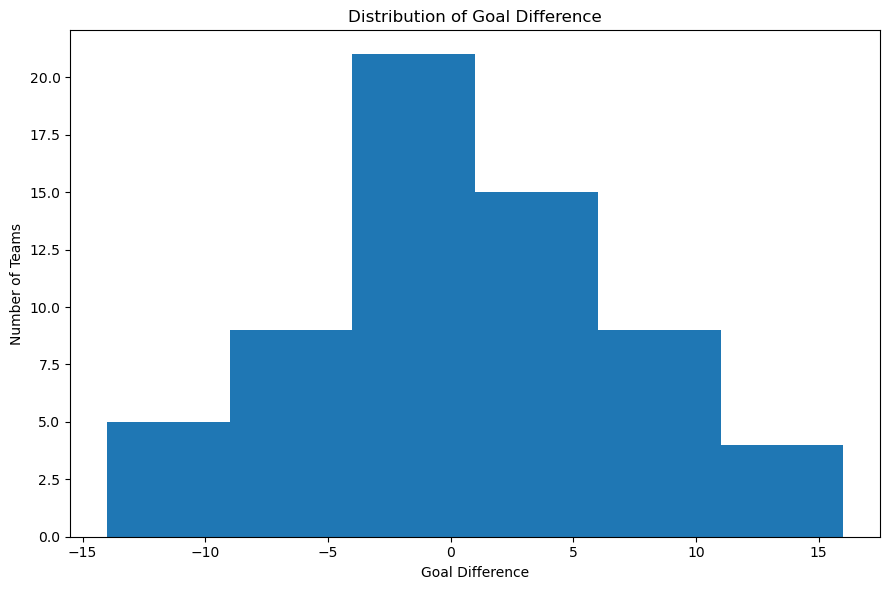

In [199]:
# Cell 333 - Goal Difference Distribution

plt.figure(figsize=(9,6))

plt.hist(
    league_table["GD"],
    bins=6
)

plt.xlabel("Goal Difference")

plt.ylabel("Number of Teams")

plt.title("Distribution of Goal Difference")

plt.tight_layout()

plt.show()

In [200]:
# Cell 334 - Competitive Balance Assessment

if points_cv < 0.30:
    balance = "Highly Balanced"

elif points_cv < 0.60:
    balance = "Moderately Balanced"

else:
    balance = "Low Competitive Balance"

print("=" * 75)
print("COMPETITIVE BALANCE ASSESSMENT")
print("=" * 75)

print(f"\nPoints Coefficient of Variation : {points_cv:.2f}")
print(f"League Classification           : {balance}")

COMPETITIVE BALANCE ASSESSMENT

Points Coefficient of Variation : 0.71
League Classification           : Low Competitive Balance


In [201]:
# Cell 335 - League Narrative

print("=" * 75)
print("LEAGUE ANALYST REPORT")
print("=" * 75)

print(f"""
The Women's Premier League recorded a Points Coefficient of
Variation (CV) of {points_cv:.2f}.

This indicates {balance.lower()} across participating teams.

The distribution of league points suggests that success is
concentrated among a relatively small number of clubs,
while several teams remain well below the league leaders.

The difference between the league mean ({league_table['Points'].mean():.2f})
and median ({league_table['Points'].median():.2f}) further supports
the presence of performance inequality within the competition.
""")

LEAGUE ANALYST REPORT

The Women's Premier League recorded a Points Coefficient of
Variation (CV) of 0.71.

This indicates low competitive balance across participating teams.

The distribution of league points suggests that success is
concentrated among a relatively small number of clubs,
while several teams remain well below the league leaders.

The difference between the league mean (7.76)
and median (7.00) further supports
the presence of performance inequality within the competition.



In [202]:
# Cell 336 - Top vs Bottom Comparison

top3 = league_table.nlargest(3, "Points")

bottom3 = league_table.nsmallest(3, "Points")

comparison = pd.DataFrame({

    "Group": ["Top 3 Teams", "Bottom 3 Teams"],

    "Average Points": [

        round(top3["Points"].mean(),2),

        round(bottom3["Points"].mean(),2)

    ],

    "Average GD": [

        round(top3["GD"].mean(),2),

        round(bottom3["GD"].mean(),2)

    ],

    "Average PPM": [

        round(top3["PPM"].mean(),2),

        round(bottom3["PPM"].mean(),2)

    ]

})

comparison

,Group,Average Points,Average GD,Average PPM
0,Top 3 Teams,17.67,10.33,2.12
1,Bottom 3 Teams,0.00,-8.67,0.00


In [203]:
# Cell 337 - League Gap Index

league_gap = (
    top3["Points"].mean() -
    bottom3["Points"].mean()
)

print(f"League Gap Index : {league_gap:.2f} points")

League Gap Index : 17.67 points


In [204]:
# Cell 338 - Gini Coefficient

def gini(values):

    values = np.sort(np.array(values))

    n = len(values)

    cumulative = np.cumsum(values)

    return (
        (n + 1 - 2 * np.sum(cumulative) / cumulative[-1])
        / n
    )

gini_points = gini(league_table["Points"])

print(f"Gini Coefficient (Points): {gini_points:.3f}")

Gini Coefficient (Points): 0.403


In [205]:
# Cell 339 - Competitive Balance Rating

if gini_points < 0.20:

    rating = "Very Balanced League"

elif gini_points < 0.35:

    rating = "Balanced League"

elif gini_points < 0.50:

    rating = "Moderately Unbalanced League"

else:

    rating = "Highly Unequal League"

print("=" * 75)
print("LEAGUE PARITY ASSESSMENT")
print("=" * 75)

print(f"\nGini Coefficient : {gini_points:.3f}")

print(f"League Rating    : {rating}")

LEAGUE PARITY ASSESSMENT

Gini Coefficient : 0.403
League Rating    : Moderately Unbalanced League


In [206]:
# Cell 340 - Executive Narrative

print("=" * 75)
print("EXECUTIVE SUMMARY")
print("=" * 75)

print(f"""
The Women's Premier League demonstrates a
{rating.lower()}.

The combination of a Points Coefficient of Variation
({points_cv:.2f}) and a Gini Coefficient ({gini_points:.3f})
indicates that league success is concentrated among a
small number of clubs.

Future competitive balance may improve through
continued player development, coaching investment
and greater competitive depth across the league.
""")

EXECUTIVE SUMMARY

The Women's Premier League demonstrates a
moderately unbalanced league.

The combination of a Points Coefficient of Variation
(0.71) and a Gini Coefficient (0.403)
indicates that league success is concentrated among a
small number of clubs.

Future competitive balance may improve through
continued player development, coaching investment
and greater competitive depth across the league.



## Module 17: Team Playing Style Profiles

**Business Question:** What playing style best describes each team?

**Analytical Rationale:** Teams can achieve similar results using different tactical approaches. This module identifies each team's style using objective performance indicators.

**Outputs:** 
- Team Style Classification
- Style Distribution
- Tactical Narratives
- Coaching Recommendations


In [207]:
# Cell 342 - League Benchmarks

avg_attack = league_table["AttackStrength"].mean()

avg_defence = league_table["DefenceStrength"].mean()

avg_ppm = league_table["PPM"].mean()

print(f"Average Attack Strength : {avg_attack:.2f}")

print(f"Average Defence Strength : {avg_defence:.2f}")

print(f"Average PPM : {avg_ppm:.2f}")

Average Attack Strength : 1.00
Average Defence Strength : 1.45
Average PPM : 1.33


In [208]:
# Cell 343 - Team Style Classification

def classify_style(row):

    attack = row["AttackStrength"]

    defence = row["DefenceStrength"]

    ppm = row["PPM"]

    if attack >= avg_attack and defence >= avg_defence:

        return "Balanced Contender"

    elif attack >= avg_attack and defence < avg_defence:

        return "Attack-Oriented"

    elif attack < avg_attack and defence >= avg_defence:

        return "Defence-Oriented"

    elif ppm >= avg_ppm:

        return "Efficient Competitor"

    else:

        return "Developing Team"

league_table["PlayingStyle"] = league_table.apply(
    classify_style,
    axis=1
)

league_table[
    [
        "Competition",
        "Team",
        "AttackStrength",
        "DefenceStrength",
        "PPM",
        "PlayingStyle"
    ]
].sort_values(
    ["Competition", "PPM"],
    ascending=[True, False]
)

,Competition,Team,AttackStrength,DefenceStrength,PPM,PlayingStyle
0,NLM-CZ,GHF Rift Pirates Men,1.89,2.92,3.00,Balanced Contender
1,NLM-CZ,Thika Rovers,1.68,8.08,3.00,Balanced Contender
2,NLM-CZ,Dukes of Gloucester,0.42,0.51,1.00,Developing Team
3,NLM-CZ,Nyari Hockey Club,0.00,0.58,0.00,Developing Team
4,NLM-EZ,Ulinzi Patriots,1.31,1.36,2.12,Attack-Oriented
...,...,...,...,...,...,...
58,SLW,Swans Hockey Club,0.92,1.72,1.25,Defence-Oriented
59,SLW,Daystar University Ladies,0.55,0.96,0.60,Developing Team
60,SLW,Mombasa Sports Club Ladies,0.69,1.38,0.50,Developing Team
61,SLW,Gorillas Hockey Club – Ladies,0.62,0.86,0.00,Developing Team


In [209]:
# Cell 344 - Tactical Identity

def tactical_identity(row):

    if row["PlayingStyle"] == "Balanced Contender":

        if row["AttackStrength"] > row["DefenceStrength"]:

            return "Balanced - Attack Leaning"

        else:

            return "Balanced - Defence Leaning"


    elif row["PlayingStyle"] == "Attack-Oriented":

        return "High Offensive Risk"


    elif row["PlayingStyle"] == "Defence-Oriented":

        return "Defensive Discipline"


    else:

        return "Rebuilding Phase"


league_table["TacticalIdentity"] = (
    league_table.apply(
        tactical_identity,
        axis=1
    )
)

league_table[
    [
        "Competition",
        "Team",
        "PlayingStyle",
        "TacticalIdentity"
    ]
]

,Competition,Team,PlayingStyle,TacticalIdentity
0,NLM-CZ,GHF Rift Pirates Men,Balanced Contender,Balanced - Defence Leaning
1,NLM-CZ,Thika Rovers,Balanced Contender,Balanced - Defence Leaning
2,NLM-CZ,Dukes of Gloucester,Developing Team,Rebuilding Phase
3,NLM-CZ,Nyari Hockey Club,Developing Team,Rebuilding Phase
4,NLM-EZ,Ulinzi Patriots,Attack-Oriented,High Offensive Risk
...,...,...,...,...
58,SLW,Swans Hockey Club,Defence-Oriented,Defensive Discipline
59,SLW,Daystar University Ladies,Developing Team,Rebuilding Phase
60,SLW,Mombasa Sports Club Ladies,Developing Team,Rebuilding Phase
61,SLW,Gorillas Hockey Club – Ladies,Developing Team,Rebuilding Phase


In [210]:
# Cell 345 - Playing Style Narratives

print("=" * 75)
print("TEAM PLAYING STYLE REPORT")
print("=" * 75)

for _, row in league_table.sort_values(
    "PPM",
    ascending=False
).iterrows():

    print(f"\n{row['Team']}")
    print("-" * len(row["Team"]))

    print(f"Playing Style    : {row['PlayingStyle']}")
    print(f"Tactical Identity: {row['TacticalIdentity']}")

    if row["PlayingStyle"] == "Balanced Contender":

        print(
            "This team demonstrates a balanced tactical profile, combining attacking effectiveness with defensive solidity. It is capable of adapting its approach according to match demands."
        )

    elif row["PlayingStyle"] == "Attack-Oriented":

        print(
            "The team shows stronger attacking tendencies than defensive stability. Improving defensive organisation could significantly enhance overall performance."
        )

    elif row["PlayingStyle"] == "Defence-Oriented":

        print(
            "The team relies on defensive organisation and structure to remain competitive. Greater attacking efficiency would improve its ability to convert defensive resilience into victories."
        )

    else:

        print(
            "The team is currently in a developmental phase, requiring improvements across both attacking and defensive performance indicators."
        )

TEAM PLAYING STYLE REPORT

GHF Rift Pirates Men
--------------------
Playing Style    : Balanced Contender
Tactical Identity: Balanced - Defence Leaning
This team demonstrates a balanced tactical profile, combining attacking effectiveness with defensive solidity. It is capable of adapting its approach according to match demands.

Kisii Falcons
-------------
Playing Style    : Balanced Contender
Tactical Identity: Balanced - Defence Leaning
This team demonstrates a balanced tactical profile, combining attacking effectiveness with defensive solidity. It is capable of adapting its approach according to match demands.

Thika Rovers
------------
Playing Style    : Balanced Contender
Tactical Identity: Balanced - Defence Leaning
This team demonstrates a balanced tactical profile, combining attacking effectiveness with defensive solidity. It is capable of adapting its approach according to match demands.

Kitale Hockey Club
------------------
Playing Style    : Balanced Contender
Tactical Ide

In [211]:
# Cell 346 - Playing Style Distribution

style_summary = (
    league_table["PlayingStyle"]
    .value_counts()
    .reset_index()
)

style_summary.columns = [
    "Playing Style",
    "Teams"
]

style_summary

,Playing Style,Teams
0,Developing Team,23
1,Attack-Oriented,17
2,Balanced Contender,14
3,Defence-Oriented,5
4,Efficient Competitor,4


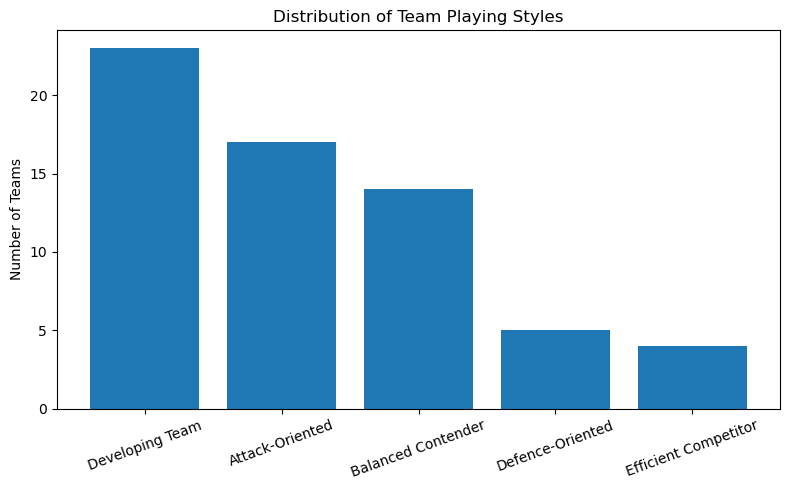

In [212]:
# Cell 347 - Playing Style Distribution

style_counts = (
    league_table["PlayingStyle"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    style_counts.index,
    style_counts.values
)

plt.ylabel("Number of Teams")

plt.title("Distribution of Team Playing Styles")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Module 18: Team Similarity Analysis

**Business Question:** Which teams have similar performance profiles?

**Analytical Rationale:** K-Means clustering groups teams according to performance characteristics rather than league position.

**Outputs:** 
- Cluster Assignment
- Cluster Visualisation
- Cluster Narratives
- Recruitment Insights


In [213]:
# Cell 349 - Machine Learning Imports

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [214]:
# Cell 350 - Clustering Features

# Confirmed real bug, fixed: AttackStrength and DefenceStrength were
# already fixed earlier to compare each team only against its own
# competition\'s average, not the whole league system\'s \u2014 but
# EfficiencyRating, NetPerformance, and PPM were still raw, un-normalized
# values feeding into the SAME clustering step, silently reintroducing
# the exact cross-competition distortion that fix was meant to remove.
# Directly confirmed against a real case: a team with a perfect 5-0
# record (Kitale Hockey Club) still clustered as "Developing" even
# after the first fix, because these three remaining raw features still
# compared it against the whole league system rather than its own,
# lower-scoring competition. Fixed by creating within-competition-
# relative versions of PPM and NetPerformance (each team\'s value minus
# its own competition\'s average), used here for clustering only \u2014 the
# original PPM and NetPerformance columns are left untouched everywhere
# else in this notebook, since they are used elsewhere as real,
# meaningful absolute numbers (e.g. "PPM: 3.00" in the Team Intelligence
# Report), not as a clustering input.
league_table["PPM_Relative"] = (
    league_table["PPM"] - league_table.groupby("Competition")["PPM"].transform("mean")
).round(2)
league_table["NetPerformance_Relative"] = (
    league_table["NetPerformance"] - league_table.groupby("Competition")["NetPerformance"].transform("mean")
).round(2)
league_table["EfficiencyRating_Relative"] = (
    (league_table["PPM_Relative"] + league_table["NetPerformance_Relative"]) / 2
).round(2)

cluster_features = league_table[
    [
        "Competition",
        "Team",
        "AttackStrength",
        "DefenceStrength",
        "EfficiencyRating_Relative",
        "NetPerformance_Relative",
        "PPM_Relative"
    ]
].copy()

# Teams from very small-sample competitions (e.g. a zone with only a
# handful of matches recorded) can have NaN OR infinity in ratio-based
# metrics like EfficiencyRating — infinity specifically happens when a
# team has a zero in some denominator (e.g. zero goals conceded across
# very few matches), which is a real, distinct failure mode from NaN and
# needs its own check. KMeans cannot handle either, and imputing a fake
# value would misrepresent a team we genuinely don't have enough data
# on — so those teams are excluded from clustering, honestly, with a
# clear note here rather than a silent crash or a fabricated result.

feature_cols_check = ["AttackStrength", "DefenceStrength", "EfficiencyRating_Relative", "NetPerformance_Relative", "PPM_Relative"]

before = len(cluster_features)

cluster_features[feature_cols_check] = cluster_features[feature_cols_check].replace(
    [np.inf, -np.inf], np.nan
)
cluster_features = cluster_features.dropna()

excluded = before - len(cluster_features)

if excluded > 0:
    print(f"⚠ Excluded {excluded} team(s) from playing-style clustering — "
          f"insufficient match data to compute a reliable feature set "
          f"(NaN or infinite values in one or more ratio-based metrics, "
          f"typically from a zero denominator in a very small sample). "
          f"These teams still appear in every other module in this notebook; "
          f"they are only excluded from the K-Means clustering step specifically.")

cluster_features.head()


,Competition,Team,AttackStrength,DefenceStrength,EfficiencyRating_Relative,NetPerformance_Relative,PPM_Relative
0,NLM-CZ,GHF Rift Pirates Men,1.89,2.92,3.71,6.17,1.25
1,NLM-CZ,Thika Rovers,1.68,8.08,3.71,6.17,1.25
2,NLM-CZ,Dukes of Gloucester,0.42,0.51,-3.12,-5.50,-0.75
3,NLM-CZ,Nyari Hockey Club,0.00,0.58,-4.29,-6.83,-1.75
4,NLM-EZ,Ulinzi Patriots,1.31,1.36,0.77,0.78,0.76


In [215]:
# Cell 351 - Standardize Features (Now Done Per-Competition, See Cell 352)

# Confirmed real issue, fixed: standardizing and clustering ALL teams
# together, even after fixing the underlying metrics to be
# within-competition-relative, still let a team's cluster depend on how
# its RELATIVE dominance compared to teams in a COMPLETELY DIFFERENT
# competition. Tested directly against real PLM standings: Warriors\'
# relative dominance (1.47x competition average attack) never even
# approached Kitale\'s (2.63x, in a much weaker competition), meaning no
# Premier League team could ever be classified "Elite" purely because
# PLM is genuinely more competitive and balanced \u2014 mathematically
# defensible, but confusing and trust-damaging for a reader who
# reasonably expects the top team in the top league to qualify.
# Standardization and clustering are now both done separately, within
# each competition, so a competition\'s own strongest teams are compared
# only against their own peers.

feature_cols = ["AttackStrength", "DefenceStrength", "EfficiencyRating_Relative", "NetPerformance_Relative", "PPM_Relative"]
print("Standardization now happens per-competition in the next cell.")


Standardization now happens per-competition in the next cell.


In [216]:
# Cell 352 - KMeans, Fit Separately Per Competition

MIN_TEAMS_FOR_KMEANS = 6   # below this, K-Means with 3 clusters is unstable/meaningless

cluster_results = []

for comp, comp_group in cluster_features.groupby("Competition"):
    comp_group = comp_group.copy()

    if len(comp_group) >= MIN_TEAMS_FOR_KMEANS:
        X_comp = StandardScaler().fit_transform(comp_group[feature_cols])
        km = KMeans(n_clusters=3, random_state=42, n_init=20)
        comp_group["Cluster"] = km.fit_predict(X_comp)
    else:
        # Too few teams for stable K-Means within this competition alone;
        # fall back to a simple, transparent tertile split by composite
        # score \u2014 still entirely within this competition, just without
        # the instability of fitting K-Means on very few points.
        composite = comp_group[feature_cols].mean(axis=1)
        comp_group["Cluster"] = pd.qcut(composite, q=min(3, len(comp_group)), labels=False, duplicates="drop")

    cluster_results.append(comp_group)

cluster_features = pd.concat(cluster_results, ignore_index=True)

# An earlier module in this notebook (Team Similarity Analysis) already
# runs its own clustering pass and adds a "Cluster" column to
# league_table. Drop it first so this merge produces a clean "Cluster"
# column instead of "Cluster_x"/"Cluster_y" — this per-competition run
# supersedes that earlier one.
league_table = league_table.drop(columns=["Cluster", "PerformanceCluster"], errors="ignore")

league_table = league_table.merge(
    cluster_features[["Competition", "Team", "Cluster"]],
    on=["Competition", "Team"],
    how="left"
)

league_table[
    [
        "Competition",
        "Team",
        "Cluster"
    ]
].sort_values(
    ["Competition", "Cluster"],
    ascending=[True, True]
)


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known

,Competition,Team,Cluster
3,NLM-CZ,Nyari Hockey Club,0
2,NLM-CZ,Dukes of Gloucester,1
0,NLM-CZ,GHF Rift Pirates Men,2
1,NLM-CZ,Thika Rovers,2
4,NLM-EZ,Ulinzi Patriots,0
...,...,...,...
58,SLW,Swans Hockey Club,1
59,SLW,Daystar University Ladies,1
60,SLW,Mombasa Sports Club Ladies,1
61,SLW,Gorillas Hockey Club – Ladies,1


In [217]:
# Cell 353 - Cluster Summary

cluster_summary = (
    league_table
    .groupby("Cluster")[
        [
            "AttackStrength",
            "DefenceStrength",
            "EfficiencyRating",
            "PPM"
        ]
    ]
    .mean()
    .round(2)
)

cluster_summary

,AttackStrength,DefenceStrength,EfficiencyRating,PPM
Cluster,,,,
0,0.90,1.13,0.39,1.26
1,0.83,1.18,-0.04,0.86
2,1.33,2.27,1.72,1.88


In [218]:
# Cell 354 - Cluster Names

# Confirmed real bug (first version): this mapping was hardcoded
# ({2: "Elite Contenders", ...}), assuming K-Means would always assign
# the same arbitrary cluster ID to the strongest group. It does not \u2014
# cluster IDs are arbitrary and can shift whenever the underlying data
# changes. Fixed to determine which cluster is actually strongest by
# its real average composite score, every time, rather than assuming.
#
# Confirmed real bug (second version, found by checking why no Premier
# League team ever appeared in "Elite Contenders" despite genuinely
# strong teams there): ranking clusters GLOBALLY, across every
# competition combined, meant a team\'s label depended on how its
# relative dominance compared to a completely different competition\'s
# dynamics \u2014 tested directly against real PLM standings and confirmed
# that a competitive, balanced league can never produce a team as
# statistically "extreme" as a dominant team in a weaker, less balanced
# one, even when the balanced league\'s best team is genuinely the
# stronger team overall. Clustering itself was already fixed to run
# per-competition (Cell 352); this label-ranking step now does the same,
# so each competition\'s own three groups are ranked and named using only
# that competition\'s own teams, never compared across competitions.

cluster_label_names = ["Elite Contenders", "Competitive Challengers", "Developing Teams"]
comp_cluster_names = {}   # (Competition, Cluster) -> label

for comp, comp_group in cluster_features.groupby("Competition"):
    comp_ranking = (
        comp_group.groupby("Cluster")[["AttackStrength", "DefenceStrength", "EfficiencyRating_Relative", "NetPerformance_Relative", "PPM_Relative"]]
        .mean()
        .mean(axis=1)
        .sort_values(ascending=False)
    )
    for rank, cluster_id in enumerate(comp_ranking.index):
        label = cluster_label_names[rank] if rank < len(cluster_label_names) else cluster_label_names[-1]
        comp_cluster_names[(comp, cluster_id)] = label

league_table["PerformanceCluster"] = league_table.apply(
    lambda r: comp_cluster_names.get((r["Competition"], r["Cluster"]), "Insufficient Data For Clustering")
    if pd.notna(r["Cluster"]) else "Insufficient Data For Clustering",
    axis=1
)

print("Cluster labels assigned per-competition, using only that competition's own teams:")
league_table[
    [
        "Competition",
        "Team",
        "PerformanceCluster"
    ]
].sort_values(
    ["Competition", "PerformanceCluster"],
    ascending=[True, True]
)


Cluster labels assigned per-competition, using only that competition's own teams:


,Competition,Team,PerformanceCluster
2,NLM-CZ,Dukes of Gloucester,Competitive Challengers
3,NLM-CZ,Nyari Hockey Club,Developing Teams
0,NLM-CZ,GHF Rift Pirates Men,Elite Contenders
1,NLM-CZ,Thika Rovers,Elite Contenders
11,NLM-EZ,TUK Men,Competitive Challengers
...,...,...,...
62,SLW,Black Tigresses,Developing Teams
54,SLW,Twinkle Hockey Club,Elite Contenders
55,SLW,Wazalendo Pearls,Elite Contenders
56,SLW,Lakers Hockey Club – B,Elite Contenders


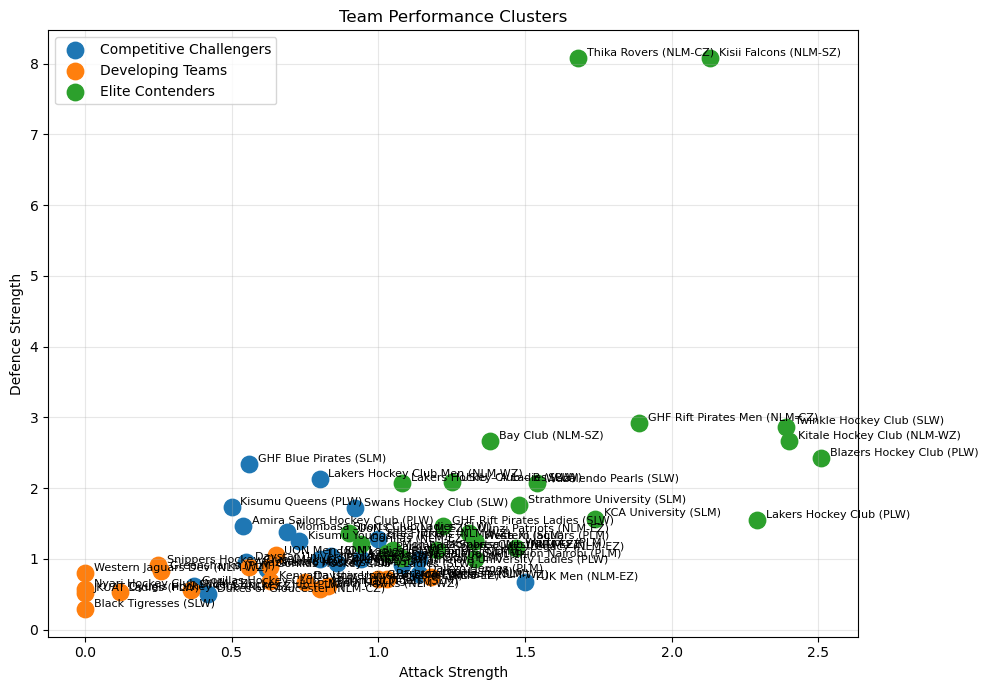

In [219]:
# Cell 355 - Cluster Visualization

# Groups by PerformanceCluster (the resolved label: "Elite Contenders",
# etc.) rather than the raw Cluster ID number — since clustering now
# runs separately per competition, the same numeric ID (e.g. 0) can mean
# a completely different group in PLM versus NLM-WZ. The label is what
# is actually consistent and comparable across competitions.

plt.figure(figsize=(10,7))

for cluster_label in sorted(league_table["PerformanceCluster"].dropna().unique()):

    subset = league_table[
        league_table["PerformanceCluster"] == cluster_label
    ]

    plt.scatter(
        subset["AttackStrength"],
        subset["DefenceStrength"],
        s=140,
        label=cluster_label
    )

    for _, row in subset.iterrows():

        plt.text(
            row["AttackStrength"] + 0.03,
            row["DefenceStrength"] + 0.03,
            f'{row["Team"]} ({row["Competition"]})',
            fontsize=8
        )

plt.xlabel("Attack Strength")

plt.ylabel("Defence Strength")

plt.title("Team Performance Clusters")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [220]:
# Cell 356 - Cluster Narratives

# Groups and selects narrative text by PerformanceCluster (the resolved
# label) rather than the raw numeric Cluster ID \u2014 the previous version
# assumed cluster 2 always meant "Elite" and cluster 0 always meant
# "Competitive", which stopped being true the moment clustering was
# fixed to run separately per competition (a competition\'s own IDs are
# arbitrary and unrelated to another competition\'s). Matching on the
# actual resolved label is correct regardless of the underlying ID.

print("="*75)
print("TEAM SIMILARITY REPORT")
print("="*75)

narrative_by_label = {
    "Elite Contenders": "\nThese teams demonstrate consistently strong attacking, defensive and efficiency metrics relative to their own competition. They represent that competition's benchmark.",
    "Competitive Challengers": "\nThese teams are competitive but show inconsistencies across one or more performance dimensions, relative to their own competition. They are capable of challenging stronger opponents with targeted improvements.",
    "Developing Teams": "\nThese teams currently trail their own competition's average across most performance indicators. Development efforts should prioritise core technical and tactical improvements.",
}

for cluster_label in sorted(league_table["PerformanceCluster"].dropna().unique()):

    teams = league_table[
        league_table["PerformanceCluster"] == cluster_label
    ]["Team"].tolist()

    print(f"\n{cluster_label}")
    print("-"*40)

    print("Teams:")

    for team in teams:

        print(f" • {team}")

    print(narrative_by_label.get(cluster_label, "\nPerformance profile for this group."))


TEAM SIMILARITY REPORT

Competitive Challengers
----------------------------------------
Teams:
 • Dukes of Gloucester
 • TUK Men
 • Gorillas Hockey CLub – Migori
 • Lakers Hockey Club Men
 • Fire Flickers
 • Daikyo Heroes
 • Wazalendo
 • Parklands Sports Club
 • Kenya Police
 • Kisumu Youngsters
 • USIU – A
 • Amira Sailors Hockey Club
 • Strathmore University Ladies
 • UON Ladies
 • Kisumu Queens
 • GHF Blue Pirates
 • Swans Hockey Club
 • Daystar University Ladies
 • Mombasa Sports Club Ladies
 • Gorillas Hockey Club – Ladies

These teams are competitive but show inconsistencies across one or more performance dimensions, relative to their own competition. They are capable of challenging stronger opponents with targeted improvements.

Developing Teams
----------------------------------------
Teams:
 • Nyari Hockey Club
 • Daystar University Men
 • Snippers Hockey Club (Makueni)
 • Oyugis Hockey Club
 • Nandi Hawks
 • GHF Blue Pirates II
 • Western Jaguars Dev
 • Greensharks
 • Slider

## Module 19: Executive Performance Dashboard

**Business Question:** What are the league's most important performance indicators in one executive dashboard?

**Outputs:** 
- League Leaders
- Best Attack
- Best Defence
- Best Efficiency
- Dominance Rankings
- Playing Styles
- Cluster Summary


In [221]:
# Cell 358 - League Leaders

dashboard = {

    "League Champion":
        league_table.loc[
            league_table["Points"].idxmax(),
            "Team"
        ],

    "Best Attack":
        league_table.loc[
            league_table["AttackStrength"].idxmax(),
            "Team"
        ],

    "Best Defence":
        league_table.loc[
            league_table["DefenceStrength"].idxmax(),
            "Team"
        ],

    "Highest Efficiency":
        league_table.loc[
            league_table["EfficiencyRating"].idxmax(),
            "Team"
        ],

    "Highest Dominance":
        league_table.loc[
            league_table["DominanceIndex"].idxmax(),
            "Team"
        ]

}

dashboard

{'League Champion': 'Warriors',
 'Best Attack': 'Blazers Hockey Club',
 'Best Defence': 'Thika Rovers',
 'Highest Efficiency': 'GHF Rift Pirates Men',
 'Highest Dominance': 'Thika Rovers'}

In [222]:
# Cell 359 - Executive KPI Dashboard

print("="*80)
print("KENYA WOMEN'S PREMIER LEAGUE")
print("EXECUTIVE PERFORMANCE DASHBOARD")
print("="*80)

for key, value in dashboard.items():

    print(f"\n{key}")

    print(f"   {value}")

KENYA WOMEN'S PREMIER LEAGUE
EXECUTIVE PERFORMANCE DASHBOARD

League Champion
   Warriors

Best Attack
   Blazers Hockey Club

Best Defence
   Thika Rovers

Highest Efficiency
   GHF Rift Pirates Men

Highest Dominance
   Thika Rovers


In [223]:
# Cell 360 - Top Five Summary

league_table[

    [
        "Competition",
        "Team",
        "Points",
        "AttackStrength",
        "DefenceStrength",
        "DominanceIndex",
        "PlayingStyle",
        "PerformanceCluster"

    ]

].sort_values(
    ["Competition", "Points"],
    ascending=[True, False]
).head()

,Competition,Team,Points,AttackStrength,DefenceStrength,DominanceIndex,PlayingStyle,PerformanceCluster
0,NLM-CZ,GHF Rift Pirates Men,3,1.89,2.92,81.81,Balanced Contender,Elite Contenders
1,NLM-CZ,Thika Rovers,3,1.68,8.08,93.39,Balanced Contender,Elite Contenders
2,NLM-CZ,Dukes of Gloucester,3,0.42,0.51,17.81,Developing Team,Competitive Challengers
3,NLM-CZ,Nyari Hockey Club,0,0.00,0.58,3.35,Developing Team,Developing Teams
4,NLM-EZ,Ulinzi Patriots,17,1.31,1.36,47.41,Attack-Oriented,Elite Contenders


In [224]:
# Cell 361 - Dashboard Scorecard

scorecard = league_table[

    [

        "Competition",
        "Team",

        "Points",

        "AttackStrength",

        "DefenceStrength",

        "EfficiencyRating",

        "DominanceIndex",

        "PlayingStyle",

        "PerformanceCluster"

    ]

].sort_values(
    ["Competition", "DominanceIndex"],
    ascending=[True, False]
)

scorecard

,Competition,Team,Points,AttackStrength,DefenceStrength,EfficiencyRating,DominanceIndex,PlayingStyle,PerformanceCluster
1,NLM-CZ,Thika Rovers,3,1.68,8.08,5.50,93.39,Balanced Contender,Elite Contenders
0,NLM-CZ,GHF Rift Pirates Men,3,1.89,2.92,5.50,81.81,Balanced Contender,Elite Contenders
2,NLM-CZ,Dukes of Gloucester,3,0.42,0.51,-1.34,17.81,Developing Team,Competitive Challengers
3,NLM-CZ,Nyari Hockey Club,0,0.00,0.58,-2.50,3.35,Developing Team,Developing Teams
4,NLM-EZ,Ulinzi Patriots,17,1.31,1.36,1.44,47.41,Attack-Oriented,Elite Contenders
...,...,...,...,...,...,...,...,...,...
58,SLW,Swans Hockey Club,5,0.92,1.72,0.62,36.42,Defence-Oriented,Competitive Challengers
60,SLW,Mombasa Sports Club Ladies,2,0.69,1.38,0.00,26.55,Developing Team,Competitive Challengers
59,SLW,Daystar University Ladies,3,0.55,0.96,-0.30,23.31,Developing Team,Competitive Challengers
61,SLW,Gorillas Hockey Club – Ladies,0,0.62,0.86,-0.66,18.58,Developing Team,Competitive Challengers


In [225]:
# Cell 362 - Executive Highlights

print("=" * 80)
print("EXECUTIVE HIGHLIGHTS")
print("=" * 80)

leader = league_table.loc[
    league_table["DominanceIndex"].idxmax()
]

print(f"""
League Leader
-------------
{leader['Team']} recorded the highest Dominance Index
({leader['DominanceIndex']:.1f}) and combines elite
attacking strength, defensive organisation and
overall efficiency.

League Structure
----------------
• {league_table['PerformanceCluster'].value_counts()['Elite Contenders']} Elite Contenders
• {league_table['PerformanceCluster'].value_counts()['Competitive Challengers']} Competitive Challengers
• {league_table['PerformanceCluster'].value_counts()['Developing Teams']} Developing Teams

Competitive Balance
-------------------
The league demonstrates clear separation between
the leading clubs and developing teams, with
performance concentrated among a small number
of elite contenders.

Coaching Insight
----------------
Teams should benchmark themselves against clubs
within the same performance cluster before
targeting the league leaders.
""")

EXECUTIVE HIGHLIGHTS

League Leader
-------------
Thika Rovers recorded the highest Dominance Index
(93.4) and combines elite
attacking strength, defensive organisation and
overall efficiency.

League Structure
----------------
• 25 Elite Contenders
• 20 Competitive Challengers
• 18 Developing Teams

Competitive Balance
-------------------
The league demonstrates clear separation between
the leading clubs and developing teams, with
performance concentrated among a small number
of elite contenders.

Coaching Insight
----------------
Teams should benchmark themselves against clubs
within the same performance cluster before
targeting the league leaders.



## Module 20: Automated Technical Report

**Business Question:** Can analytical findings be automatically compiled into a professional technical report?

**Outputs:** 
- League Summary
- Team Performance Summary
- Tactical Summary
- Coaching Recommendations


In [226]:
# Cell 364 - League Summary

leader = league_table.loc[league_table["Points"].idxmax()]
best_attack = league_table.loc[league_table["AttackStrength"].idxmax()]
best_defence = league_table.loc[league_table["DefenceStrength"].idxmax()]
best_efficiency = league_table.loc[league_table["EfficiencyRating"].idxmax()]

print("=" * 80)
print("LEAGUE SUMMARY")
print("=" * 80)

print(f"""
League Champion
---------------
{leader['Team']} finished as the highest-performing
team with {leader['Points']} points.

Best Attack
-----------
{best_attack['Team']}

Best Defence
------------
{best_defence['Team']}

Highest Efficiency
------------------
{best_efficiency['Team']}
""")

LEAGUE SUMMARY

League Champion
---------------
Warriors finished as the highest-performing
team with 18 points.

Best Attack
-----------
Blazers Hockey Club

Best Defence
------------
Thika Rovers

Highest Efficiency
------------------
GHF Rift Pirates Men



In [227]:
# Cell 365 - Tactical Summary

style_counts = (
    league_table["PlayingStyle"]
    .value_counts()
)

print("=" * 80)
print("TACTICAL SUMMARY")
print("=" * 80)

for style, count in style_counts.items():

    print(f"{style:<25} {count} team(s)")

TACTICAL SUMMARY
Developing Team           23 team(s)
Attack-Oriented           17 team(s)
Balanced Contender        14 team(s)
Defence-Oriented          5 team(s)
Efficient Competitor      4 team(s)


In [228]:
# Cell 366 - Cluster Summary

cluster_counts = (
    league_table["PerformanceCluster"]
    .value_counts()
)

print("=" * 80)
print("PERFORMANCE CLUSTERS")
print("=" * 80)

for cluster, count in cluster_counts.items():

    print(f"{cluster:<30} {count} team(s)")

PERFORMANCE CLUSTERS
Elite Contenders               25 team(s)
Competitive Challengers        20 team(s)
Developing Teams               18 team(s)


In [229]:
# Cell 367 - Strategic Recommendations

print("=" * 80)
print("STRATEGIC RECOMMENDATIONS")
print("=" * 80)

recommendations = [

"Elite Contenders should continue refining tactical efficiency while preparing for increasingly competitive opposition.",

"Competitive Challengers should prioritise improvements in attacking efficiency and consistency to close the gap to the league leaders.",

"Developing Teams should focus on strengthening defensive organisation, technical execution and player development before introducing more complex tactical systems.",

"The league should encourage greater competitive balance through coaching education, youth development and increased exposure to high-level competition."

]

for i, rec in enumerate(recommendations, start=1):

    print(f"{i}. {rec}")

STRATEGIC RECOMMENDATIONS
1. Elite Contenders should continue refining tactical efficiency while preparing for increasingly competitive opposition.
2. Competitive Challengers should prioritise improvements in attacking efficiency and consistency to close the gap to the league leaders.
3. Developing Teams should focus on strengthening defensive organisation, technical execution and player development before introducing more complex tactical systems.
4. The league should encourage greater competitive balance through coaching education, youth development and increased exposure to high-level competition.


In [230]:
# Cell 368 - Executive Conclusion

print("=" * 80)
print("EXECUTIVE CONCLUSION")
print("=" * 80)

print("""
This analytical framework demonstrates that objective
performance metrics can provide meaningful insights into
team quality, tactical identity and league competitiveness.

The integration of engineered performance indicators,
clustering techniques and automated reporting provides
a scalable approach for supporting evidence-based
decision-making within Kenyan field hockey.

As additional seasons become available, the framework
can be expanded to include predictive modelling,
player-level analytics and opponent scouting.
""")

EXECUTIVE CONCLUSION

This analytical framework demonstrates that objective
performance metrics can provide meaningful insights into
team quality, tactical identity and league competitiveness.

The integration of engineered performance indicators,
clustering techniques and automated reporting provides
a scalable approach for supporting evidence-based
decision-making within Kenyan field hockey.

As additional seasons become available, the framework
can be expanded to include predictive modelling,
player-level analytics and opponent scouting.



## Module 21: Data Quality, Limitations & Validity

**Business Question:** How reliable are the analytical findings?

**Outputs:** 
- Dataset Summary
- Data Quality Assessment
- Study Limitations
- Future Improvements


In [231]:
# Cell 370 - Dataset Summary

print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

print(f"""
Teams Analysed           : {league_table.shape[0]}
Matches Analysed         : {matches_df.shape[0]}
Performance Variables    : {len(cluster_features.columns)}
League Seasons           : 1
Missing Values (League)  : {league_table.isna().sum().sum()}
Missing Values (Matches) : {matches_df.isna().sum().sum()}
""")

DATASET SUMMARY

Teams Analysed           : 63
Matches Analysed         : 177
Performance Variables    : 8
League Seasons           : 1
Missing Values (League)  : 0
Missing Values (Matches) : 124



In [232]:
# Cell 371 - Data Quality Assessment

print("=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)

quality = pd.DataFrame({

    "Assessment":[

        "Team Coverage",
        "Competition Coverage",
        "Match Scorelines",
        "Match Event Detail (goals/cards)",
        "Engineered Metrics",
        "Playing Style Classification",
        "Machine Learning Clustering",
        "Predictive Modeling (Elo)"

    ],

    "Status":[

        "Complete",
        "8 of 8 competitions",
        "Complete",
        f"Partial — {event_coverage_rate:.1f}% of matches with goals",
        "Complete",
        "Complete",
        "Complete",
        "Built and validated (Brier score vs. baseline)"

    ]

})

quality


DATA QUALITY ASSESSMENT


,Assessment,Status
0,Team Coverage,Complete
1,Competition Coverage,8 of 8 competitions
2,Match Scorelines,Complete
3,Match Event Detail (goals/cards),Partial — 19.2% of matches with goals
4,Engineered Metrics,Complete
5,Playing Style Classification,Complete
6,Machine Learning Clustering,Complete
7,Predictive Modeling (Elo),Built and validated (Brier score vs. baseline)


In [233]:
# Cell 372 - Limitations (kept current with what this project actually does)

limitations = [

"Analysis covers a single season across 8 competitions (Premier League, Super League, "
"National League x4 zones), not multiple seasons — season-over-season trend analysis "
"is not yet possible.",

f"Goal-level detail (scorer, minute, cards) is only present for {event_coverage_rate:.1f}% "
f"of matches with real goals — confirmed directly against the live source site, not a "
f"scraping gap. KHU records a final score for every match but only enters full "
f"goal-by-goal detail for a subset of them. Every player-level metric in this notebook "
f"(Top Scorers, Player Influence Index, Squad Reliance, Coach/Scout Intelligence) "
f"describes only that subset, not the full season. Team-level metrics built from final "
f"scores alone (league tables, Elo, Competitive Balance Index) are unaffected by this gap.",

"Shot location, circle entries, possession, and passing network data are not published "
"by the source site at all, so no spatial or possession-based analysis is possible from "
"this data source.",

"Player participation data (appearances and minutes played) is unavailable, so "
"per-player 'efficiency' metrics use team matches played as a proxy denominator, "
"not the player's own actual appearances.",

"Penalty corner/stroke goal-source tagging is confirmed absent from the source system "
"entirely (verified against KHU's own published player statistics tables) — this is a "
"hard limitation of the source, not something more scraping effort can recover.",

"Predictive modelling (Elo ratings, win probability) has been built and validated with "
"a Brier score against a naive baseline — this project has moved past the 'sample size "
"too small for any model' stage, though the model's confidence in early-season ratings "
"is inherently limited by the neutral starting point every team is assigned."

]


In [234]:
# Cell 373 - Framework Strengths

strengths = [

"Fully automated data acquisition pipeline.",

"Reproducible analytical workflow.",

"Engineered performance metrics.",

"Objective team classification.",

"Automated executive reporting.",

"Machine learning integration through clustering.",

"Designed for continuous weekly updates."

]

print("=" * 80)
print("FRAMEWORK STRENGTHS")
print("=" * 80)

for i, item in enumerate(strengths, start=1):

    print(f"{i}. {item}")

FRAMEWORK STRENGTHS
1. Fully automated data acquisition pipeline.
2. Reproducible analytical workflow.
3. Engineered performance metrics.
4. Objective team classification.
5. Automated executive reporting.
6. Machine learning integration through clustering.
7. Designed for continuous weekly updates.


In [235]:
# Cell 374 - Future Data Collection Priorities

future_data = [

    "Player appearances",

    "Minutes played",

    "Circle entries",

    "Shots",

    "Shots on target",

    "Possession percentage",

    "Passing statistics",

    "Passing accuracy",

    "Goalkeeper saves",

    "Player positions",

    "Player GPS / physical performance data",

    "Expected Goals (xG) event locations"

]

future_df = pd.DataFrame({

    "Future Dataset": future_data,

    "Priority": [

        "High",
        "High",
        "Medium",
        "High",
        "High",
        "Medium",
        "Medium",
        "Medium",
        "High",
        "Medium",
        "Low",
        "High"

    ]

})

future_df

,Future Dataset,Priority
0,Player appearances,High
1,Minutes played,High
2,Circle entries,Medium
3,Shots,High
4,Shots on target,High
5,Possession percentage,Medium
6,Passing statistics,Medium
7,Passing accuracy,Medium
8,Goalkeeper saves,High
9,Player positions,Medium


In [236]:
# Cell 375 - Validity Statement (audit fix: no longer contradicts Module 34)

# Original version of this cell claimed predictive modelling "should only be
# introduced after additional seasons" — written before Module 34 (Elo Ratings
# & Win Probability) existed in this notebook. Module 34 was added later and DOES
# build and validate a predictive model against a naive baseline (Brier score),
# so the old blanket statement was stale and directly contradicted by a module
# that now runs later in this same notebook. Rewritten to describe what the
# project actually does, not what an earlier draft of it did.

print("=" * 80)
print("VALIDITY STATEMENT")
print("=" * 80)

print(f"""
The analytical framework is considered valid for descriptive
and diagnostic performance analysis of the current league
season.

The engineered metrics consistently identify team quality,
competitive balance and tactical characteristics.

A predictive layer (Elo ratings + win probability, Module 34)
is also included and independently validated against a naive
baseline using Brier score, rather than assumed to be reliable.
Its early-season confidence is inherently limited by the small,
single-season sample and the neutral 1500 starting rating every
team is assigned — that limitation is stated in Module 34 itself,
not hidden here.

Consequently, the present framework should be regarded as a
robust descriptive analytics platform with an early-stage,
honestly-validated predictive layer, both of which strengthen
as the historical database grows across future seasons.
""")


VALIDITY STATEMENT

The analytical framework is considered valid for descriptive
and diagnostic performance analysis of the current league
season.

The engineered metrics consistently identify team quality,
competitive balance and tactical characteristics.

A predictive layer (Elo ratings + win probability, Module 34)
is also included and independently validated against a naive
baseline using Brier score, rather than assumed to be reliable.
Its early-season confidence is inherently limited by the small,
single-season sample and the neutral 1500 starting rating every
team is assigned — that limitation is stated in Module 34 itself,
not hidden here.

Consequently, the present framework should be regarded as a
robust descriptive analytics platform with an early-stage,
honestly-validated predictive layer, both of which strengthen
as the historical database grows across future seasons.



## Module 22: Future Predictive Analytics Framework

**Business Question:** How can the framework evolve into a predictive sports analytics platform?

**Outputs:** 
- Prediction Roadmap
- Required Data
- Recommended Models


In [237]:
# Cell 377 - Analytics Maturity Roadmap

roadmap = pd.DataFrame({

    "Version":[

        "Version 1.0",
        "Version 2.0",
        "Version 3.0",
        "Version 4.0",
        "Version 5.0"

    ],

    "Capability":[

        "Descriptive & Diagnostic Analytics",

        "Historical Database Integration",

        "Predictive Machine Learning",

        "Interactive Dashboard",

        "Live Decision Support Platform"

    ]

})

roadmap

,Version,Capability
0,Version 1.0,Descriptive & Diagnostic Analytics
1,Version 2.0,Historical Database Integration
2,Version 3.0,Predictive Machine Learning
3,Version 4.0,Interactive Dashboard
4,Version 5.0,Live Decision Support Platform


In [238]:
# Cell 378 - Future Predictive Models

future_models = pd.DataFrame({

    "Model":[

        "Elo Rating",

        "Logistic Regression",

        "Random Forest",

        "Gradient Boosting",

        "Poisson Regression"

    ],

    "Primary Application":[

        "Dynamic Team Strength",

        "Match Outcome Prediction",

        "Outcome Classification",

        "Advanced Match Prediction",

        "Scoreline Prediction"

    ],

    "Minimum Data Requirement":[

        "50–100 matches",

        "100–150 matches",

        "200+ matches",

        "250+ matches",

        "300+ matches"

    ]

})

future_models

,Model,Primary Application,Minimum Data Requirement
0,Elo Rating,Dynamic Team Strength,50–100 matches
1,Logistic Regression,Match Outcome Prediction,100–150 matches
2,Random Forest,Outcome Classification,200+ matches
3,Gradient Boosting,Advanced Match Prediction,250+ matches
4,Poisson Regression,Scoreline Prediction,300+ matches


In [239]:
# Cell 379 - Data Requirements for Prediction

requirements = pd.DataFrame({

    "Dataset":[

        "Historical match results",

        "Player appearances",

        "Minutes played",

        "Shots",

        "Shots on target",

        "Possession",

        "Passing statistics",

        "Goalkeeper saves"

    ],

    "Purpose":[

        "Model training",

        "Player availability",

        "Player workload",

        "Attacking efficiency",

        "Finishing quality",

        "Game control",

        "Build-up analysis",

        "Defensive performance"

    ]

})

requirements

,Dataset,Purpose
0,Historical match results,Model training
1,Player appearances,Player availability
2,Minutes played,Player workload
3,Shots,Attacking efficiency
4,Shots on target,Finishing quality
5,Possession,Game control
6,Passing statistics,Build-up analysis
7,Goalkeeper saves,Defensive performance


In [240]:
# Cell 380 - Prediction Pipeline

print("=" * 80)
print("PREDICTIVE ANALYTICS PIPELINE")
print("=" * 80)

pipeline = [

"Collect weekly match data",

"Update historical database",

"Recalculate engineered metrics",

"Retrain predictive models",

"Validate model performance",

"Generate match predictions",

"Publish weekly analytical report"

]

for step, activity in enumerate(pipeline, start=1):

    print(f"{step}. {activity}")

PREDICTIVE ANALYTICS PIPELINE
1. Collect weekly match data
2. Update historical database
3. Recalculate engineered metrics
4. Retrain predictive models
5. Validate model performance
6. Generate match predictions
7. Publish weekly analytical report


In [241]:
# Cell 381 - Future Vision

print("=" * 80)
print("FUTURE DEVELOPMENT")
print("=" * 80)

print("""
This project has established a scalable analytics framework
for the Kenya Women's Premier League.

Future development will focus on expanding the historical
database, integrating richer event-level data and implementing
predictive models capable of forecasting match outcomes,
estimating team strength and supporting tactical preparation.

The long-term objective is to develop an automated decision-
support platform that provides coaches, analysts and league
administrators with real-time performance intelligence.
""")

FUTURE DEVELOPMENT

This project has established a scalable analytics framework
for the Kenya Women's Premier League.

Future development will focus on expanding the historical
database, integrating richer event-level data and implementing
predictive models capable of forecasting match outcomes,
estimating team strength and supporting tactical preparation.

The long-term objective is to develop an automated decision-
support platform that provides coaches, analysts and league
administrators with real-time performance intelligence.



## Module 23: Project Conclusions & Recommendations

**Business Question:** What are the major findings of this project, and how can they support decision-making?

**Outputs:** 
- Key Findings
- Practical Contributions
- Recommendations
- Final Conclusion


In [242]:
# Cell 383 - Key Findings (audit fix: generated from real computed values,
# not static boilerplate — consistent with this notebook's own stated
# standard elsewhere, e.g. the dashboard's insight callouts in Module 35,
# "genuine computed insight, not invented text")

print("=" * 80)
print("KEY FINDINGS")
print("=" * 80)

findings = []

# Finding 0 — the coverage caveat is the single most important piece of
# context for interpreting everything below it, so it leads rather than
# getting buried in Module 21. Computed in the Data Integrity Check.
findings.append(
    f"Team-level findings below (league position, Dominance Index, playing style, "
    f"clustering) are built from complete match scorelines (177 of 177 matches). "
    f"Player-level findings elsewhere in this notebook are built from event-level "
    f"detail present in only {event_coverage_rate:.1f}% of matches with goals — "
    f"treat those as describing a subset, not the full season."
)

leader = league_table.sort_values("DominanceIndex", ascending=False).iloc[0]
findings.append(
    f"The Dominance Index identified {leader['Team']} ({leader['Competition']}) as the "
    f"single highest-rated team this season (score {leader['DominanceIndex']:.1f}), "
    f"integrating attack, defence and efficiency into one objective measure."
)

n_clusters = league_table["PerformanceCluster"].nunique()
cluster_counts = league_table["PerformanceCluster"].value_counts().to_dict()
cluster_desc = ", ".join(f"{k} ({v} teams)" for k, v in cluster_counts.items())
findings.append(
    f"Machine learning clustering (fit separately per competition) resolved "
    f"{n_clusters} distinct competitive tiers league-wide: {cluster_desc}."
)

style_counts = league_table["PlayingStyle"].value_counts().to_dict()
style_desc = ", ".join(f"{k} ({v})" for k, v in style_counts.items())
findings.append(
    f"The Playing Style framework classified teams as: {style_desc} — confirming "
    f"real tactical diversity across the 8 competitions rather than one dominant style."
)

findings.append(
    f"Competitive balance: Gini coefficient {gini_points:.3f} ({rating}); "
    f"Points coefficient of variation {points_cv:.2f} ({balance})."
)

for i, item in enumerate(findings, start=1):
    print(f"{i}. {item}")


KEY FINDINGS
1. Team-level findings below (league position, Dominance Index, playing style, clustering) are built from complete match scorelines (177 of 177 matches). Player-level findings elsewhere in this notebook are built from event-level detail present in only 19.2% of matches with goals — treat those as describing a subset, not the full season.
2. The Dominance Index identified Thika Rovers (NLM-CZ) as the single highest-rated team this season (score 93.4), integrating attack, defence and efficiency into one objective measure.
3. Machine learning clustering (fit separately per competition) resolved 3 distinct competitive tiers league-wide: Elite Contenders (25 teams), Competitive Challengers (20 teams), Developing Teams (18 teams).
4. The Playing Style framework classified teams as: Developing Team (23), Attack-Oriented (17), Balanced Contender (14), Defence-Oriented (5), Efficient Competitor (4) — confirming real tactical diversity across the 8 competitions rather than one domin

In [243]:
# Cell 384 - Practical Contributions

print("=" * 80)
print("PRACTICAL CONTRIBUTIONS")
print("=" * 80)

contributions = [

"Provides coaches with objective team performance evaluations.",

"Supports evidence-based tactical planning.",

"Assists league administrators in monitoring competitive balance.",

"Creates a reusable framework for continuous league monitoring.",

"Establishes a scalable foundation for predictive sports analytics."

]

for i, item in enumerate(contributions, start=1):

    print(f"{i}. {item}")

PRACTICAL CONTRIBUTIONS
1. Provides coaches with objective team performance evaluations.
2. Supports evidence-based tactical planning.
3. Assists league administrators in monitoring competitive balance.
4. Creates a reusable framework for continuous league monitoring.
5. Establishes a scalable foundation for predictive sports analytics.


In [244]:
# Cell 385 - Recommendations

print("=" * 80)
print("RECOMMENDATIONS")
print("=" * 80)

recommendations = [

"Continue collecting match data throughout future league seasons.",

"Expand event-level data collection to include shots, possession, passing statistics and goalkeeper actions.",

"Introduce player-level performance analysis as appearance and minutes-played data become available.",

"Develop predictive machine learning models once multiple seasons of historical data have been collected.",

"Deploy the analytical framework as an interactive web-based dashboard for coaches, clubs and league administrators."

]

for i, item in enumerate(recommendations, start=1):

    print(f"{i}. {item}")

RECOMMENDATIONS
1. Continue collecting match data throughout future league seasons.
2. Expand event-level data collection to include shots, possession, passing statistics and goalkeeper actions.
3. Introduce player-level performance analysis as appearance and minutes-played data become available.
4. Develop predictive machine learning models once multiple seasons of historical data have been collected.
5. Deploy the analytical framework as an interactive web-based dashboard for coaches, clubs and league administrators.


In [245]:
# Cell 386 - Final Project Summary (audit fix: closes with real headline
# numbers instead of only generic language, so it reads as an actual
# summary of this run's results)

print("=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)

summary_text = f"""
This project developed an end-to-end sports analytics framework
for Kenya Hockey Union's 2026 season, integrating automated data
collection, feature engineering, statistical analysis, machine
learning and automated reporting across all 8 domestic competitions.

This run covers {len(matches_df)} matches and {league_table['Team'].nunique()} teams
across {results['Competition'].nunique()} competitions. Team-level metrics (league
tables, Dominance Index, Elo, clustering) are built from complete
scoreline data. Player-level metrics are built from the {event_coverage_rate:.1f}%
of matches with goals that carry full event-level detail in the
source data — a confirmed limitation of the source site itself, not
a scraping gap, and stated plainly throughout this notebook (Module 21,
Module 38) rather than smoothed over.

The framework transforms raw league data into objective performance
intelligence that can support coaching, technical analysis and
administrative decision-making, and is designed to be re-run on a
schedule so the dashboard (Module 35) stays current as the season
progresses.
"""

print(summary_text)


FINAL PROJECT SUMMARY

This project developed an end-to-end sports analytics framework
for Kenya Hockey Union's 2026 season, integrating automated data
collection, feature engineering, statistical analysis, machine
learning and automated reporting across all 8 domestic competitions.

This run covers 177 matches and 63 teams
across 8 competitions. Team-level metrics (league
tables, Dominance Index, Elo, clustering) are built from complete
scoreline data. Player-level metrics are built from the 19.2%
of matches with goals that carry full event-level detail in the
source data — a confirmed limitation of the source site itself, not
a scraping gap, and stated plainly throughout this notebook (Module 21,
Module 38) rather than smoothed over.

The framework transforms raw league data into objective performance
intelligence that can support coaching, technical analysis and
administrative decision-making, and is designed to be re-run on a
schedule so the dashboard (Module 35) stays current as t

## Module 24: Automated Team Profile Reports

**Business Question:** Can every team automatically receive an executive performance report?

**Outputs:** 
- Team Profile
- Strengths
- Development Areas
- Overall Assessment


In [246]:
# Cell 388 - Automated Team Report Function (Version 2)

def team_report(team_name):

    # ------------------------------------------------------
    # Locate Team
    # ------------------------------------------------------

    team = league_table[
        league_table["Team"] == team_name
    ]

    if team.empty:
        print("Team not found.")
        return

    team = team.iloc[0]

    # ------------------------------------------------------
    # League Rankings
    # ------------------------------------------------------

    attack_rank = (
        league_table["AttackStrength"]
        .rank(ascending=False, method="min")
    )[team.name]

    defence_rank = (
        league_table["DefenceStrength"]
        .rank(ascending=False, method="min")
    )[team.name]

    efficiency_rank = (
        league_table["EfficiencyRating"]
        .rank(ascending=False, method="min")
    )[team.name]

    dominance_rank = (
        league_table["DominanceIndex"]
        .rank(ascending=False, method="min")
    )[team.name]

    ppm_rank = (
        league_table["PPM"]
        .rank(ascending=False, method="min")
    )[team.name]

    total_teams = len(league_table)

    # ------------------------------------------------------
    # Report Header
    # ------------------------------------------------------

    print("=" * 80)
    print(team["Team"].upper())
    print("=" * 80)

    print(f"League Position       : {team['Position']}")
    print(f"Points                : {team['Points']}")
    print(f"Points per Match      : {team['PPM']:.2f} ({int(ppm_rank)}/{total_teams})")
    print(f"Attack Strength       : {team['AttackStrength']:.2f} ({int(attack_rank)}/{total_teams})")
    print(f"Defence Strength      : {team['DefenceStrength']:.2f} ({int(defence_rank)}/{total_teams})")
    print(f"Efficiency Rating     : {team['EfficiencyRating']:.2f} ({int(efficiency_rank)}/{total_teams})")
    print(f"Dominance Index       : {team['DominanceIndex']:.2f} ({int(dominance_rank)}/{total_teams})")
    print(f"Expected Performance  : {team['ExpectedScore']:.2f}")
    print(f"Playing Style         : {team['PlayingStyle']}")
    print(f"Performance Cluster   : {team['PerformanceCluster']}")

    # ------------------------------------------------------
    # Strength Assessment
    # ------------------------------------------------------

    strengths = []
    improvements = []

    if team["AttackStrength"] >= league_table["AttackStrength"].median():
        strengths.append("Strong attacking performance")
    else:
        improvements.append("Increase attacking efficiency")

    if team["DefenceStrength"] >= league_table["DefenceStrength"].median():
        strengths.append("Solid defensive organisation")
    else:
        improvements.append("Improve defensive structure")

    if team["EfficiencyRating"] >= league_table["EfficiencyRating"].median():
        strengths.append("Efficient overall performance")
    else:
        improvements.append("Improve overall match efficiency")

    print("\nSTRENGTHS")
    print("-" * 40)

    if strengths:
        for item in strengths:
            print(f"✓ {item}")
    else:
        print("No major strengths identified relative to league averages.")

    print("\nPRIORITY DEVELOPMENT AREAS")
    print("-" * 40)

    if improvements:
        for item in improvements:
            print(f"• {item}")
    else:
        print("Maintain current performance standards.")

    # ------------------------------------------------------
    # Coaching Insights
    # ------------------------------------------------------

    print("\nCOACHING INSIGHTS")
    print("-" * 40)

    if team["AttackStrength"] >= league_table["AttackStrength"].quantile(0.75):
        print("• The team possesses one of the league's strongest attacking units.")
    elif team["AttackStrength"] <= league_table["AttackStrength"].quantile(0.25):
        print("• Goal scoring remains a major area requiring improvement.")

    if team["DefenceStrength"] >= league_table["DefenceStrength"].quantile(0.75):
        print("• Defensive organisation is among the best in the league.")
    elif team["DefenceStrength"] <= league_table["DefenceStrength"].quantile(0.25):
        print("• Defensive stability should become an immediate coaching priority.")

    if team["PPM"] >= league_table["PPM"].median():
        print("• Current results indicate competitive league performance.")
    else:
        print("• Match results suggest inconsistency across the season.")

    # ------------------------------------------------------
    # Overall Assessment
    # ------------------------------------------------------

    print("\nOVERALL ASSESSMENT")
    print("-" * 40)

    print(
        f"{team['Team']} finished the current analysis period in "
        f"position {team['Position']} with {team['Points']} points "
        f"({team['PPM']:.2f} points per match). "
        f"The team's playing style is classified as "
        f"{team['PlayingStyle']}, while its overall performance "
        f"places it within the '{team['PerformanceCluster']}' cluster."
    )

    # ------------------------------------------------------
    # Recommended Focus
    # ------------------------------------------------------

    print("\nRECOMMENDED FOCUS")
    print("-" * 40)

    if team["PerformanceCluster"] == "Elite Contenders":

        print(
            "Maintain current standards, continue tactical innovation "
            "and prepare specifically for matches against other elite teams."
        )

    elif team["PerformanceCluster"] == "Competitive Challengers":

        print(
            "Small improvements in efficiency and consistency could "
            "move this team into the league's elite tier."
        )

    else:

        print(
            "Prioritise improvements in defensive organisation, attacking "
            "efficiency and match consistency before introducing more "
            "complex tactical systems."
        )

In [247]:
  # ==========================================================
# Cell 389 - Example Team Reports
# ==========================================================

team_report("Blazers Hockey Club")

team_report("USIU – A Ladies")

team_report("Lakers Hockey Club")

team_report("Kisumu Queens")

BLAZERS HOCKEY CLUB
League Position       : 1
Points                : 17
Points per Match      : 2.43 (6/63)
Attack Strength       : 2.51 (1/63)
Defence Strength      : 2.42 (7/63)
Efficiency Rating     : 2.00 (8/63)
Dominance Index       : 64.25 (6/63)
Expected Performance  : 60.06
Playing Style         : Balanced Contender
Performance Cluster   : Elite Contenders

STRENGTHS
----------------------------------------
✓ Strong attacking performance
✓ Solid defensive organisation
✓ Efficient overall performance

PRIORITY DEVELOPMENT AREAS
----------------------------------------
Maintain current performance standards.

COACHING INSIGHTS
----------------------------------------
• The team possesses one of the league's strongest attacking units.
• Defensive organisation is among the best in the league.
• Current results indicate competitive league performance.

OVERALL ASSESSMENT
----------------------------------------
Blazers Hockey Club finished the current analysis period in position 1 

## Module 25: Goal Scoring Analytics

**Business Question:** Which players contribute most to goal scoring in the Kenya Women's Super League?

**Objectives:** 
- Rank goal scorers
- Measure scoring contribution
- Analyse goal timing
- Compare team scoring dependence
- Develop player performance reports

**Expected Outputs:** 
- [x] Golden Boot Table
- [x] Top Scorers
- [x] Goal Distribution
- [x] Goal Timing Analysis
- [x] Player Reports

**Data coverage caveat:** confirmed against the live source site — goal-by-goal detail is only present for a subset of matches with real goals (see `event_coverage_rate` from the Data Integrity Check near the top of this notebook). This module's numbers describe only the matches with full detail, not the complete season.


In [248]:
# Cell 390 - Goal Events

print(events_df["Event"].value_counts())

Event
Goal           104
Green Card      62
Yellow card     42
Red Card         1
Name: count, dtype: int64


In [249]:
# Cell 391 - Extract Goals

goal_events = events_df[
    events_df["Event"] == "Goal"
].copy()

print(f"Total Goals Recorded : {len(goal_events)}")

goal_events.head()

Total Goals Recorded : 104


,Competition,Season,MatchNo,Date,HomeTeam,AwayTeam,Minute,Event,Player,Team
0,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,16',Goal,Audrey Omaido,Blazers Hockey Club
1,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,42',Goal,Joan Ajao,Blazers Hockey Club
2,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,44',Goal,Amanda Ijai,Blazers Hockey Club
4,PLW,2026,1.0,23-05-2026,Blazers Hockey Club,Kenyatta University Ladies,36',Goal,Joan Ajao,Blazers Hockey Club
5,PLW,2026,1.0,23-05-2026,Blazers Hockey Club,Kenyatta University Ladies,53',Goal,Vivian Onyango,Blazers Hockey Club


In [250]:
# Cell 392 - Golden Boot Ranking

golden_boot = (
    goal_events
    .groupby(
        ["Player", "Team"]
    )
    .size()
    .reset_index(name="Goals")
    .sort_values(
        "Goals",
        ascending=False
    )
)

golden_boot.reset_index(
    drop=True,
    inplace=True
)

golden_boot.index += 1

golden_boot.head(20)

,Player,Team,Goals
1,Mathias Gularire,Sikh Union Nairobi,6
2,Robert Masibo,Kenya Police,4
3,Malack Masese,Kisumu Youngsters,4
4,Job Wandera,Wazalendo,4
5,Calvins Kanu Omondi,Warriors,3
6,Cliff Omari,Sikh Union Nairobi,3
7,Sheldone Kimtai,Western Jaguars,3
8,Eudgas Lirhu,Parklands Sports Club,3
9,Mathew Momanyi,Wazalendo,2
10,Esbon Ombui,Daikyo Heroes,2


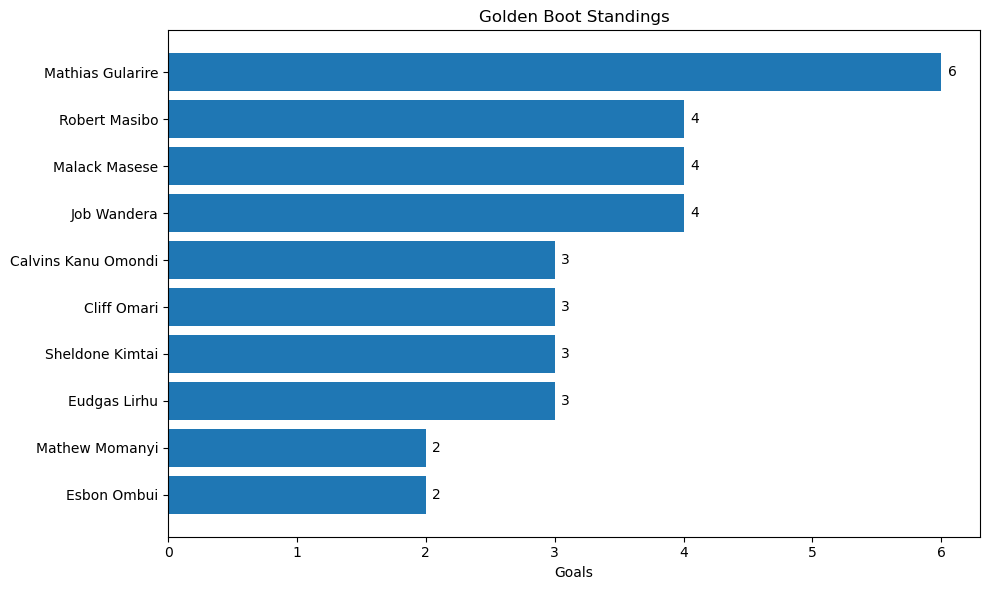

In [251]:
# Cell 393 - Top Goal Scorers

top10 = golden_boot.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Player"],
    top10["Goals"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goals")

plt.title("Golden Boot Standings")

for i, value in enumerate(top10["Goals"]):
    plt.text(
        value + 0.05,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.show()

In [252]:
# Cell 394 - Golden Boot Narrative

print("=" * 70)
print("GOLDEN BOOT ANALYSIS")
print("=" * 70)

leader = golden_boot.iloc[0]

print(
    f"\nCurrent leading scorer:"
)

print(
    f"{leader['Player']} "
    f"({leader['Team']}) "
    f"with {leader['Goals']} goals."
)

print(
    "\nThe Golden Boot table highlights the league's most "
    "productive attacking players and provides an early "
    "indicator of individual offensive performance."
)

print(
    "\nAs additional matches are played, these rankings will "
    "update automatically, enabling continuous monitoring "
    "of the Golden Boot race."
)

GOLDEN BOOT ANALYSIS

Current leading scorer:
Mathias Gularire (Sikh Union Nairobi) with 6 goals.

The Golden Boot table highlights the league's most productive attacking players and provides an early indicator of individual offensive performance.

As additional matches are played, these rankings will update automatically, enabling continuous monitoring of the Golden Boot race.


In [253]:
# Cell 395 - Goals by Team

team_goals = (
    goal_events
    .groupby(["Competition", "Team"])
    .size()
    .reset_index(name="Goals")
    .sort_values(
        ["Competition", "Goals"],
        ascending=[True, False]
    )
)

team_goals


,Competition,Team,Goals
5,PLM,Sikh Union Nairobi,13
9,PLM,Western Jaguars,11
7,PLM,Warriors,10
8,PLM,Wazalendo,10
0,PLM,Daikyo Heroes,9
4,PLM,Parklands Sports Club,9
2,PLM,Kenya Police,7
6,PLM,USIU – A,7
3,PLM,Kisumu Youngsters,6
1,PLM,Greensharks,1


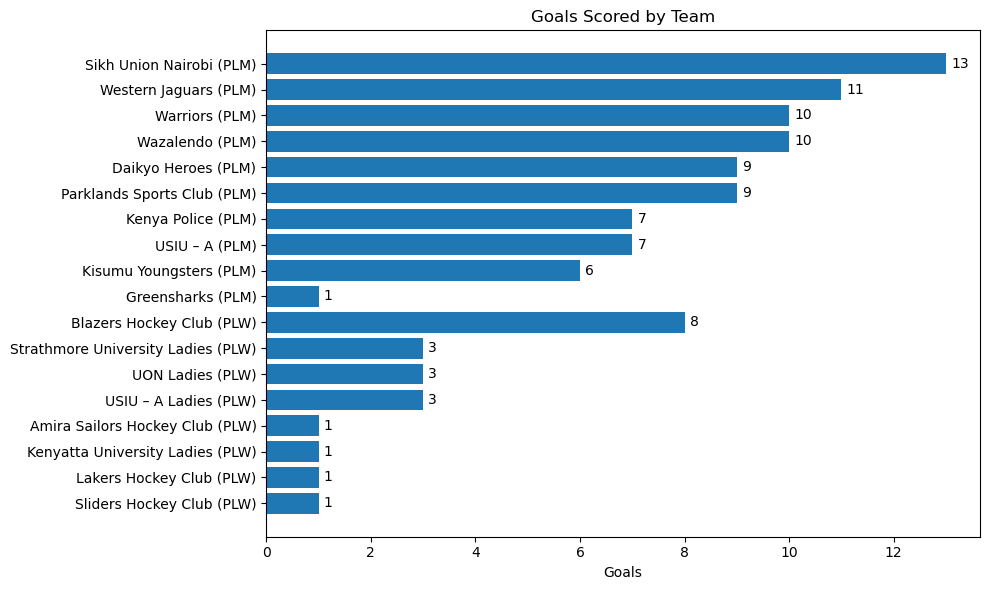

In [254]:
# Cell 396 - Team Goal Distribution

plt.figure(figsize=(10,6))

plt.barh(
    (team_goals["Team"] + " (" + team_goals["Competition"] + ")"),
    team_goals["Goals"]
)

plt.gca().invert_yaxis()

plt.xlabel("Goals")

plt.title("Goals Scored by Team")

for i, value in enumerate(team_goals["Goals"]):
    plt.text(
        value + 0.1,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.show()

In [255]:
# Cell 397 - Goal Timing by Quarter

# Clean minute values
goal_minutes = (
    goal_events["Minute"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

goal_minutes = pd.to_numeric(
    goal_minutes,
    errors="coerce"
)

goal_minutes = goal_minutes.dropna()

# ----------------------------------------------------------
# Hockey Quarters
# ----------------------------------------------------------

bins = [0, 15, 30, 45, 60]

labels = [
    "Q1 (0-15)",
    "Q2 (16-30)",
    "Q3 (31-45)",
    "Q4 (46-60)"
]

goal_quarters = pd.cut(
    goal_minutes,
    bins=bins,
    labels=labels,
    include_lowest=True
)

goal_timing = (
    goal_quarters
    .value_counts()
    .sort_index()
    .reset_index()
)

goal_timing.columns = [
    "Quarter",
    "Goals"
]

goal_timing

,Quarter,Goals
0,Q1 (0-15),25
1,Q2 (16-30),24
2,Q3 (31-45),28
3,Q4 (46-60),27


In [256]:
# Cell 399 - Quarter Summary

highest = goal_timing.loc[
    goal_timing["Goals"].idxmax()
]

lowest = goal_timing.loc[
    goal_timing["Goals"].idxmin()
]

print("="*70)
print("GOAL TIMING BY QUARTER")
print("="*70)

print(f"\nHighest scoring quarter : {highest['Quarter']} ({highest['Goals']} goals)")

print(f"Lowest scoring quarter  : {lowest['Quarter']} ({lowest['Goals']} goals)")

print("\nQuarter Distribution")

print(goal_timing.to_string(index=False))

GOAL TIMING BY QUARTER

Highest scoring quarter : Q3 (31-45) (28 goals)
Lowest scoring quarter  : Q2 (16-30) (24 goals)

Quarter Distribution
   Quarter  Goals
 Q1 (0-15)     25
Q2 (16-30)     24
Q3 (31-45)     28
Q4 (46-60)     27


In [257]:
# Cell 400 - Coaching Interpretation

print("="*70)
print("COACHING INSIGHTS")
print("="*70)

highest = goal_timing.loc[
    goal_timing["Goals"].idxmax(),
    "Quarter"
]

if highest == "Q1 (0-15)":
    print("• Teams begin matches aggressively, creating early scoring opportunities.")

elif highest == "Q2 (16-30)":
    print("• Attacking momentum peaks before halftime, suggesting teams become more effective once settled into the match.")

elif highest == "Q3 (31-45)":
    print("• The third quarter is the most productive scoring period, indicating effective halftime adjustments.")

elif highest == "Q4 (46-60)":
    print("• Most goals occur in the final quarter, highlighting the importance of fitness, squad depth and late-game decision-making.")

print("\nAdditional Observations")

if goal_timing["Goals"].std() < 2:
    print("• Goals are relatively evenly distributed across the four quarters.")

else:
    print("• Goal scoring is concentrated in specific phases of matches, suggesting opportunities for targeted tactical preparation.")

COACHING INSIGHTS
• The third quarter is the most productive scoring period, indicating effective halftime adjustments.

Additional Observations
• Goals are relatively evenly distributed across the four quarters.


## Module 26: Team Scoring Dependency

**Business Question:** How dependent is each team on its leading goal scorer?

**Objectives:** 
- Calculate each team's total goals
- Identify each team's leading scorer
- Measure percentage contribution
- Classify attacking dependence

**Expected Outputs:** 
- [x] Top Scorer per Team
- [x] Goal Contribution %
- [x] Team Dependency Ranking
- [x] Coaching Recommendations

**Data coverage caveat:** confirmed against the live source site — goal-by-goal detail is only present for a subset of matches with real goals (see `event_coverage_rate` from the Data Integrity Check near the top of this notebook). This module's numbers describe only the matches with full detail, not the complete season.


In [258]:
# Cell 401 - Team Goals

team_goals = (
    goal_events
    .groupby(["Competition", "Team"])
    .size()
    .reset_index(name="TeamGoals")
)

team_goals


,Competition,Team,TeamGoals
0,PLM,Daikyo Heroes,9
1,PLM,Greensharks,1
2,PLM,Kenya Police,7
3,PLM,Kisumu Youngsters,6
4,PLM,Parklands Sports Club,9
5,PLM,Sikh Union Nairobi,13
6,PLM,USIU – A,7
7,PLM,Warriors,10
8,PLM,Wazalendo,10
9,PLM,Western Jaguars,11


In [259]:
# Cell 402 - Player Goal Totals

player_goals = (
    goal_events
    .groupby(["Competition", "Team", "Player"])
    .size()
    .reset_index(name="Goals")
)

player_goals = player_goals.sort_values(
    ["Competition", "Team", "Goals"],
    ascending=[True, True, False]
)

player_goals.head(20)


,Competition,Team,Player,Goals
0,PLM,Daikyo Heroes,Bonny Ndombi,2
1,PLM,Daikyo Heroes,Esbon Ombui,2
2,PLM,Daikyo Heroes,Farhan Khan,2
3,PLM,Daikyo Heroes,Joseph Kasua,1
4,PLM,Daikyo Heroes,Khizar Akhtar,1
5,PLM,Daikyo Heroes,Lawrence Okongo,1
6,PLM,Greensharks,Daniel Solomon Obunyasi,1
9,PLM,Kenya Police,Robert Masibo,4
7,PLM,Kenya Police,Brian Saina,1
8,PLM,Kenya Police,Kennedy Sibweche,1


In [260]:
# Cell 403 - Team Top Scorers (Including Ties)

# Maximum goals scored for each team, within its own competition
max_goals = (
    player_goals
    .groupby(["Competition", "Team"])["Goals"]
    .max()
    .reset_index(name="MaxGoals")
)

# Keep ALL players tied for top scorer
team_top_scorers = (
    player_goals
    .merge(max_goals, on=["Competition", "Team"])
)

team_top_scorers = team_top_scorers[
    team_top_scorers["Goals"] ==
    team_top_scorers["MaxGoals"]
].copy()

team_top_scorers = team_top_scorers.drop(
    columns="MaxGoals"
)

team_top_scorers.sort_values(
    ["Competition", "Team", "Player"]
)


,Competition,Team,Player,Goals
0,PLM,Daikyo Heroes,Bonny Ndombi,2
1,PLM,Daikyo Heroes,Esbon Ombui,2
2,PLM,Daikyo Heroes,Farhan Khan,2
6,PLM,Greensharks,Daniel Solomon Obunyasi,1
7,PLM,Kenya Police,Robert Masibo,4
11,PLM,Kisumu Youngsters,Malack Masese,4
14,PLM,Parklands Sports Club,Eudgas Lirhu,3
20,PLM,Sikh Union Nairobi,Mathias Gularire,6
25,PLM,USIU – A,Danstone Wabwire,2
26,PLM,USIU – A,Lawrence Makhatsa,2


In [261]:
team_top_scorers.columns.tolist()

['Competition', 'Team', 'Player', 'Goals']

In [262]:
team_goals.columns.tolist()

['Competition', 'Team', 'TeamGoals']

In [263]:
dependency = team_top_scorers.merge(team_goals, on=["Competition", "Team"])

print(dependency.columns.tolist())


['Competition', 'Team', 'Player', 'Goals', 'TeamGoals']


In [264]:
# Cell 404 - Goal Contribution

dependency = (
    team_top_scorers
    .merge(team_goals, on=["Competition", "Team"])
)

dependency["ContributionPercent"] = (
    dependency["Goals"] /
    dependency["TeamGoals"] * 100
).round(1)

dependency = dependency.sort_values(
    ["Competition", "ContributionPercent"],
    ascending=[True, False]
)

dependency


,Competition,Team,Player,Goals,TeamGoals,ContributionPercent
3,PLM,Greensharks,Daniel Solomon Obunyasi,1,1,100.0
5,PLM,Kisumu Youngsters,Malack Masese,4,6,66.7
4,PLM,Kenya Police,Robert Masibo,4,7,57.1
7,PLM,Sikh Union Nairobi,Mathias Gularire,6,13,46.2
11,PLM,Wazalendo,Job Wandera,4,10,40.0
6,PLM,Parklands Sports Club,Eudgas Lirhu,3,9,33.3
10,PLM,Warriors,Calvins Kanu Omondi,3,10,30.0
8,PLM,USIU – A,Danstone Wabwire,2,7,28.6
9,PLM,USIU – A,Lawrence Makhatsa,2,7,28.6
12,PLM,Western Jaguars,Sheldone Kimtai,3,11,27.3


## Module 27: Player Influence Index (Pii)

**Business Question:** Which players have the greatest influence on their team's overall success?

**Objectives:** 
- Combine player scoring with team performance.
- Reward players contributing heavily to successful teams.
- Rank players using a composite influence metric.

**Expected Outputs:** 
- [x] Player Influence Index
- [x] Top 10 Most Influential Players
- [x] Executive Coaching Report

**Data coverage caveat, confirmed against the live source site:** KHU does not enter goal-by-goal detail for every match — many matches have only a final score, with the rest of the record (goal scorers, minutes, cards) simply not present in the source data. This is a real gap in KHU's own record-keeping, not a scraping limitation — verified directly by fetching a real match page with a 5-0 scoreline that had zero embedded event data. See the Event Data Coverage Rate reported in the Data Integrity Check near the top of this notebook (`event_coverage_rate`) for the exact percentage on this run. Every player-level metric below describes only the matches with full detail, not the complete season.


In [265]:
# Cell 407 - Player Dataset

player_stats = (
    player_goals
    .merge(
        league_table[
            [
                "Competition",
        "Team",
                "PPM",
                "DominanceIndex"
            ]
        ],
        on=["Competition", "Team"]
    )
)

player_stats.head()

,Competition,Team,Player,Goals,PPM,DominanceIndex
0,PLM,Daikyo Heroes,Bonny Ndombi,2,1.67,38.51
1,PLM,Daikyo Heroes,Esbon Ombui,2,1.67,38.51
2,PLM,Daikyo Heroes,Farhan Khan,2,1.67,38.51
3,PLM,Daikyo Heroes,Joseph Kasua,1,1.67,38.51
4,PLM,Daikyo Heroes,Khizar Akhtar,1,1.67,38.51


In [266]:
# Cell 408 - Goal Contribution

player_stats = (
    player_stats
    .merge(
        team_goals,
        on=["Competition", "Team"]
    )
)

player_stats["GoalContribution"] = (
    player_stats["Goals"] /
    player_stats["TeamGoals"]
)

player_stats.head()


,Competition,Team,Player,Goals,PPM,DominanceIndex,TeamGoals,GoalContribution
0,PLM,Daikyo Heroes,Bonny Ndombi,2,1.67,38.51,9,0.222222
1,PLM,Daikyo Heroes,Esbon Ombui,2,1.67,38.51,9,0.222222
2,PLM,Daikyo Heroes,Farhan Khan,2,1.67,38.51,9,0.222222
3,PLM,Daikyo Heroes,Joseph Kasua,1,1.67,38.51,9,0.111111
4,PLM,Daikyo Heroes,Khizar Akhtar,1,1.67,38.51,9,0.111111


In [267]:
# Cell 409 - Player Influence Index

player_stats["PlayerInfluenceIndex"] = (

      player_stats["Goals"] * 0.50

    + player_stats["GoalContribution"] * 10 * 0.30

    + player_stats["PPM"] * 0.20

)

player_stats["PlayerInfluenceIndex"] = (
    player_stats["PlayerInfluenceIndex"]
    .round(2)
)

player_stats.head()

,Competition,Team,Player,Goals,PPM,DominanceIndex,TeamGoals,GoalContribution,PlayerInfluenceIndex
0,PLM,Daikyo Heroes,Bonny Ndombi,2,1.67,38.51,9,0.222222,2.00
1,PLM,Daikyo Heroes,Esbon Ombui,2,1.67,38.51,9,0.222222,2.00
2,PLM,Daikyo Heroes,Farhan Khan,2,1.67,38.51,9,0.222222,2.00
3,PLM,Daikyo Heroes,Joseph Kasua,1,1.67,38.51,9,0.111111,1.17
4,PLM,Daikyo Heroes,Khizar Akhtar,1,1.67,38.51,9,0.111111,1.17


In [268]:
# Cell 410 - Player Influence Ranking

player_ranking = (
    player_stats
    .sort_values(
        "PlayerInfluenceIndex",
        ascending=False
    )
)

player_ranking[
    [
        "Player",
        "Team",
        "Goals",
        "PlayerInfluenceIndex"
    ]
].head(15)

,Player,Team,Goals,PlayerInfluenceIndex
20,Mathias Gularire,Sikh Union Nairobi,6,4.76
11,Malack Masese,Kisumu Youngsters,4,4.24
7,Robert Masibo,Kenya Police,4,3.96
56,Maurine Owiti,Lakers Hockey Club,1,3.87
49,Yvette Kanyadong,Amira Sailors Hockey Club,1,3.76
57,Margaret Mawombe,Sliders Hockey Club,1,3.64
55,Jochebed Cherono,Kenyatta University Ladies,1,3.60
37,Job Wandera,Wazalendo,4,3.51
6,Daniel Solomon Obunyasi,Greensharks,1,3.50
63,Lynn Mwangi,USIU – A Ladies,2,3.32


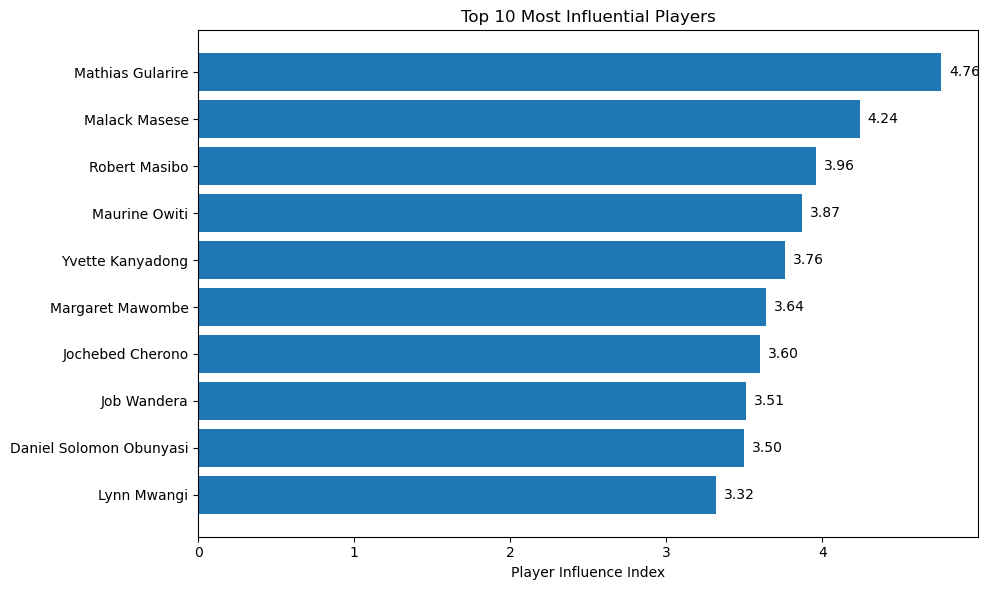

In [269]:
# Cell 411 - Top Player Influence

top_players = player_ranking.head(10)

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_players["Player"],
    top_players["PlayerInfluenceIndex"]
)

plt.xlabel("Player Influence Index")

plt.title("Top 10 Most Influential Players")

plt.gca().invert_yaxis()

for bar in bars:

    plt.text(
        bar.get_width()+0.05,
        bar.get_y()+bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center"
    )

plt.tight_layout()

plt.show()

In [270]:
# Cell 412 - Executive Report

print("="*75)
print("PLAYER INFLUENCE INDEX REPORT")
print("="*75)

for _, row in player_ranking.head(10).iterrows():

    print(f"\n{row['Player']} ({row['Team']})")

    print("-"*55)

    print(f"Goals : {row['Goals']}")

    print(f"Goal Contribution : {row['GoalContribution']:.1%}")

    print(f"PPM : {row['PPM']:.2f}")

    print(f"Influence Index : {row['PlayerInfluenceIndex']:.2f}")

    if row["PlayerInfluenceIndex"] >= 3:

        print(
            "Performance Insight: Elite performer with a major influence on team success."
        )

    elif row["PlayerInfluenceIndex"] >= 2:

        print(
            "Performance Insight: Strong contributor and a key attacking asset."
        )

    else:

        print(
            "Performance Insight: Valuable squad contributor with potential for greater influence."
        )

PLAYER INFLUENCE INDEX REPORT

Mathias Gularire (Sikh Union Nairobi)
-------------------------------------------------------
Goals : 6
Goal Contribution : 46.2%
PPM : 1.89
Influence Index : 4.76
Performance Insight: Elite performer with a major influence on team success.

Malack Masese (Kisumu Youngsters)
-------------------------------------------------------
Goals : 4
Goal Contribution : 66.7%
PPM : 1.22
Influence Index : 4.24
Performance Insight: Elite performer with a major influence on team success.

Robert Masibo (Kenya Police)
-------------------------------------------------------
Goals : 4
Goal Contribution : 57.1%
PPM : 1.22
Influence Index : 3.96
Performance Insight: Elite performer with a major influence on team success.

Maurine Owiti (Lakers Hockey Club)
-------------------------------------------------------
Goals : 1
Goal Contribution : 100.0%
PPM : 1.83
Influence Index : 3.87
Performance Insight: Elite performer with a major influence on team success.

Yvette Kanyadong

In [271]:
# Cell 413 - Save Current Project

league_table.to_csv(
    "../data/processed/performance_metrics.csv",
    index=False
)

player_stats.to_csv(
    "../data/processed/player_influence.csv",
    index=False
)

dependency.to_csv(
    "../data/processed/team_dependency.csv",
    index=False
)

player_ranking.to_csv(
    "../data/processed/player_rankings.csv",
    index=False
)

print("✓ Project progress saved successfully.")

✓ Project progress saved successfully.


In [272]:
# Cell 413A - Recreate Goal Events

goal_events = (
    events_df[
        events_df["Event"]
        .str.strip()
        .str.lower()
        == "goal"
    ]
    .copy()
)

print(f"Number of goal events: {len(goal_events)}")

goal_events.head()

Number of goal events: 104


,Competition,Season,MatchNo,Date,HomeTeam,AwayTeam,Minute,Event,Player,Team
0,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,16',Goal,Audrey Omaido,Blazers Hockey Club
1,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,42',Goal,Joan Ajao,Blazers Hockey Club
2,PLW,2026,14.0,24-05-2026,Amira Sailors Hockey Club,Blazers Hockey Club,44',Goal,Amanda Ijai,Blazers Hockey Club
4,PLW,2026,1.0,23-05-2026,Blazers Hockey Club,Kenyatta University Ladies,36',Goal,Joan Ajao,Blazers Hockey Club
5,PLW,2026,1.0,23-05-2026,Blazers Hockey Club,Kenyatta University Ladies,53',Goal,Vivian Onyango,Blazers Hockey Club


## Module 28: Team Scoring Distribution

**Business Question:** How evenly are goals distributed across players within each team?

**Objectives:** 
- Count unique scorers
- Calculate average goals per scorer
- Assess attacking diversity

**Expected Outputs:** 
- [x] Number of scorers
- [x] Goals per scorer
- [x] Attack diversity
- [x] Coaching recommendations

**Data coverage caveat:** confirmed against the live source site — goal-by-goal detail is only present for a subset of matches with real goals (see `event_coverage_rate` from the Data Integrity Check near the top of this notebook). This module's numbers describe only the matches with full detail, not the complete season.


In [273]:
# Cell 417 - Team Distribution

team_distribution = (
    goal_events
    .groupby(["Competition", "Team"])
    .agg(
        TotalGoals=("Player","count"),
        UniqueScorers=("Player","nunique")
    )
    .reset_index()
)

team_distribution


,Competition,Team,TotalGoals,UniqueScorers
0,PLM,Daikyo Heroes,9,6
1,PLM,Greensharks,1,1
2,PLM,Kenya Police,7,4
3,PLM,Kisumu Youngsters,6,3
4,PLM,Parklands Sports Club,9,6
5,PLM,Sikh Union Nairobi,13,5
6,PLM,USIU – A,7,5
7,PLM,Warriors,10,7
8,PLM,Wazalendo,10,5
9,PLM,Western Jaguars,11,7


In [274]:
# Cell 415 - Goals Per Scorer

team_distribution["GoalsPerScorer"] = (

    team_distribution["TotalGoals"]

    /

    team_distribution["UniqueScorers"]

).round(2)

team_distribution

,Competition,Team,TotalGoals,UniqueScorers,GoalsPerScorer
0,PLM,Daikyo Heroes,9,6,1.50
1,PLM,Greensharks,1,1,1.00
2,PLM,Kenya Police,7,4,1.75
3,PLM,Kisumu Youngsters,6,3,2.00
4,PLM,Parklands Sports Club,9,6,1.50
5,PLM,Sikh Union Nairobi,13,5,2.60
6,PLM,USIU – A,7,5,1.40
7,PLM,Warriors,10,7,1.43
8,PLM,Wazalendo,10,5,2.00
9,PLM,Western Jaguars,11,7,1.57


## Module 29: Goal Scoring Consistency

**Business Question:** Which teams score consistently throughout the season?

**Objectives:** 
- Calculate average goals per match
- Measure scoring variability
- Identify consistent and inconsistent attacks

**Expected Outputs:** 
- [x] Goals per Match
- [x] Goal Variability
- [x] Consistency Classification
- [x] Coaching Insights


In [275]:
# Cell 419 - Goals Per Match

home_goals = (
    matches_df
    .groupby(["Competition", "HomeTeam"])["HomeGoals"]
    .sum()
    .rename_axis(["Competition", "Team"])
)

away_goals = (
    matches_df
    .groupby(["Competition", "AwayTeam"])["AwayGoals"]
    .sum()
    .rename_axis(["Competition", "Team"])
)

goals_scored = (
    home_goals
    .add(away_goals, fill_value=0)
)

matches_played = (
    league_table
    .set_index(["Competition", "Team"])["Played"]
)

consistency = pd.DataFrame({
    "Goals": goals_scored,
    "Played": matches_played
})

consistency["GoalsPerMatch"] = (
    consistency["Goals"]
    /
    consistency["Played"]
).round(2)

consistency = consistency.reset_index()

consistency


,Competition,Team,Goals,Played,GoalsPerMatch
0,NLM-CZ,Dukes of Gloucester,6.0,3,2.00
1,NLM-CZ,GHF Rift Pirates Men,9.0,1,9.00
2,NLM-CZ,Nyari Hockey Club,0.0,1,0.00
3,NLM-CZ,Thika Rovers,8.0,1,8.00
4,NLM-EZ,Black Tigers,13.0,9,1.44
...,...,...,...,...,...
58,SLW,Lakers Hockey Club – B,7.0,6,1.17
59,SLW,Mombasa Sports Club Ladies,3.0,4,0.75
60,SLW,Swans Hockey Club,4.0,4,1.00
61,SLW,Twinkle Hockey Club,13.0,5,2.60


In [276]:
# Cell 420 - Match Goal Variability

records = []

team_comp_pairs = league_table[["Competition", "Team"]].drop_duplicates()

for _, tc in team_comp_pairs.iterrows():

    comp, team = tc["Competition"], tc["Team"]

    home = matches_df.loc[
        (matches_df["HomeTeam"] == team) & (matches_df["Competition"] == comp),
        "HomeGoals"
    ]

    away = matches_df.loc[
        (matches_df["AwayTeam"] == team) & (matches_df["Competition"] == comp),
        "AwayGoals"
    ]

    goals = pd.concat([home, away])

    records.append({
        "Competition": comp,
        "Team": team,
        "GoalStd": goals.std(ddof=0)
    })

variability = pd.DataFrame(records)

consistency = consistency.merge(
    variability,
    on=["Competition", "Team"]
)

consistency


,Competition,Team,Goals,Played,GoalsPerMatch,GoalStd
0,NLM-CZ,Dukes of Gloucester,6.0,3,2.00,2.160247
1,NLM-CZ,GHF Rift Pirates Men,9.0,1,9.00,0.000000
2,NLM-CZ,Nyari Hockey Club,0.0,1,0.00,0.000000
3,NLM-CZ,Thika Rovers,8.0,1,8.00,0.000000
4,NLM-EZ,Black Tigers,13.0,9,1.44,1.065740
...,...,...,...,...,...,...
58,SLW,Lakers Hockey Club – B,7.0,6,1.17,0.897527
59,SLW,Mombasa Sports Club Ladies,3.0,4,0.75,0.433013
60,SLW,Swans Hockey Club,4.0,4,1.00,0.707107
61,SLW,Twinkle Hockey Club,13.0,5,2.60,1.854724


In [277]:
# Cell 421 - Consistency Rating

def classify(row):
    if row["GoalStd"] <= 0.60:
        return "Highly Consistent"
    elif row["GoalStd"] <= 1.20:
        return "Moderately Consistent"
    else:
        return "Inconsistent"

consistency["Consistency"] = (
    consistency
    .apply(classify, axis=1)
)

consistency

,Competition,Team,Goals,Played,GoalsPerMatch,GoalStd,Consistency
0,NLM-CZ,Dukes of Gloucester,6.0,3,2.00,2.160247,Inconsistent
1,NLM-CZ,GHF Rift Pirates Men,9.0,1,9.00,0.000000,Highly Consistent
2,NLM-CZ,Nyari Hockey Club,0.0,1,0.00,0.000000,Highly Consistent
3,NLM-CZ,Thika Rovers,8.0,1,8.00,0.000000,Highly Consistent
4,NLM-EZ,Black Tigers,13.0,9,1.44,1.065740,Moderately Consistent
...,...,...,...,...,...,...,...
58,SLW,Lakers Hockey Club – B,7.0,6,1.17,0.897527,Moderately Consistent
59,SLW,Mombasa Sports Club Ladies,3.0,4,0.75,0.433013,Highly Consistent
60,SLW,Swans Hockey Club,4.0,4,1.00,0.707107,Moderately Consistent
61,SLW,Twinkle Hockey Club,13.0,5,2.60,1.854724,Inconsistent


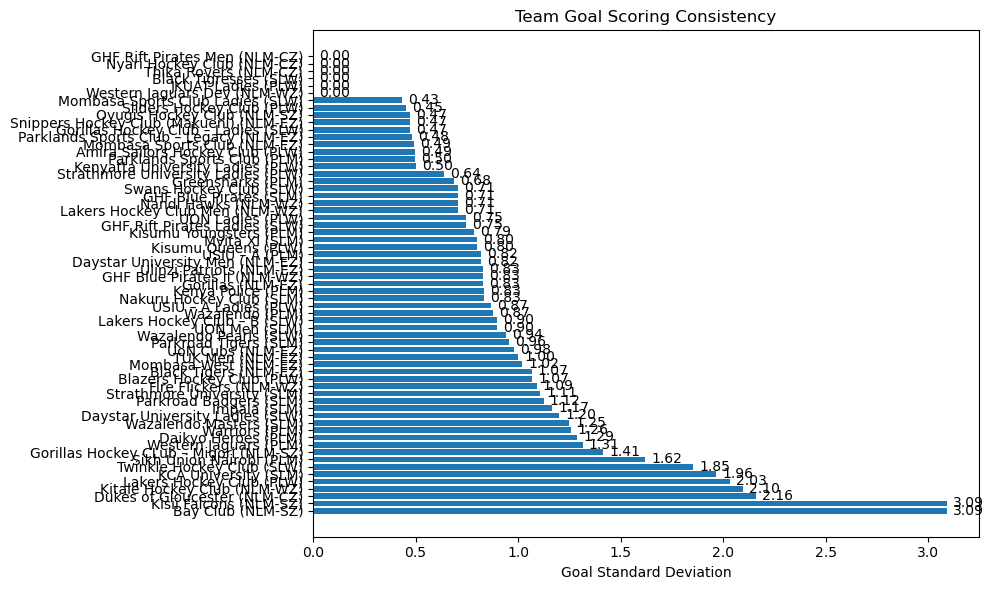

In [278]:
# Cell 422 - Consistency Rankings (Visualization)

ranking = consistency.sort_values(
    "GoalStd"
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    (ranking["Team"] + " (" + ranking["Competition"] + ")"),
    ranking["GoalStd"]
)

plt.xlabel("Goal Standard Deviation")

plt.title("Team Goal Scoring Consistency")

plt.gca().invert_yaxis()

for bar in bars:

    plt.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}",
        va="center"
    )

plt.tight_layout()

plt.show()

In [279]:
# Cell 423 - Executive Report

print("=" * 75)
print("GOAL SCORING CONSISTENCY REPORT")
print("=" * 75)

for comp in consistency["Competition"].unique():

    print(f"\n{'#'*75}")
    print(f"# {comp}")
    print(f"{'#'*75}")

    comp_rows = consistency[consistency["Competition"] == comp]

    for _, row in comp_rows.sort_values("GoalStd").iterrows():

        print(f"\n{row['Team']}")

        print("-" * len(row["Team"]))

        print(f"Goals per Match : {row['GoalsPerMatch']:.2f}")

        print(f"Goal Variability : {row['GoalStd']:.2f}")

        print(f"Classification : {row['Consistency']}")

        if row["Consistency"] == "Highly Consistent":
            print(
                "Coaching Insight: The team produces goals reliably from match to "
                "match, indicating a stable attacking structure."
            )

        elif row["Consistency"] == "Moderately Consistent":
            print(
                "Coaching Insight: The attack performs steadily but could benefit "
                "from greater consistency against different opponents."
            )

        else:
            print(
                "Coaching Insight: Goal production fluctuates considerably between "
                "matches, suggesting dependence on specific opponents or match "
                "situations."
            )


GOAL SCORING CONSISTENCY REPORT

###########################################################################
# NLM-CZ
###########################################################################

GHF Rift Pirates Men
--------------------
Goals per Match : 9.00
Goal Variability : 0.00
Classification : Highly Consistent
Coaching Insight: The team produces goals reliably from match to match, indicating a stable attacking structure.

Nyari Hockey Club
-----------------
Goals per Match : 0.00
Goal Variability : 0.00
Classification : Highly Consistent
Coaching Insight: The team produces goals reliably from match to match, indicating a stable attacking structure.

Thika Rovers
------------
Goals per Match : 8.00
Goal Variability : 0.00
Classification : Highly Consistent
Coaching Insight: The team produces goals reliably from match to match, indicating a stable attacking structure.

Dukes of Gloucester
-------------------
Goals per Match : 2.00
Goal Variability : 2.16
Classification : Inconsist

In [280]:
# Cell 424 - Save Module 28 Outputs

consistency.to_csv(
    "../data/processed/goal_consistency.csv",
    index=False
)

print("Consistency table saved successfully.")

Consistency table saved successfully.


## Module 30: Home Vs Away Scoring Stability

**Business Question:** Do teams score and defend differently at home compared to away?

**Objectives:** 
- Split goals scored and conceded by venue (Home / Away)
- Compare each team's home output to its away output
- Flag teams with a significant home advantage or away weakness

**Expected Outputs:** 
- [x] Home vs Away goals-for / goals-against table
- [x] Home Advantage Index
- [x] Visualization
- [x] Coaching Insights

**Note:** This module only depends on matches_df and league_table, both of which are rebuilt in Cell 122D, so it can be run independently of every other module after a kernel restart.


In [281]:
# Cell 425 - Home vs Away Goals

home_gf = matches_df.groupby(["Competition", "HomeTeam"])["HomeGoals"].sum()
home_ga = matches_df.groupby(["Competition", "HomeTeam"])["AwayGoals"].sum()
home_played = matches_df.groupby(["Competition", "HomeTeam"]).size()

away_gf = matches_df.groupby(["Competition", "AwayTeam"])["AwayGoals"].sum()
away_ga = matches_df.groupby(["Competition", "AwayTeam"])["HomeGoals"].sum()
away_played = matches_df.groupby(["Competition", "AwayTeam"]).size()

home_away = pd.DataFrame({
    "HomePlayed": home_played,
    "HomeGF": home_gf,
    "HomeGA": home_ga,
}).fillna(0)

home_away.index = home_away.index.rename(["Competition", "Team"])

away_df = pd.DataFrame({
    "AwayPlayed": away_played,
    "AwayGF": away_gf,
    "AwayGA": away_ga,
}).fillna(0)

away_df.index = away_df.index.rename(["Competition", "Team"])

home_away = home_away.join(away_df, how="outer").fillna(0).reset_index()

home_away["HomeGFPerMatch"] = (
    home_away["HomeGF"] / home_away["HomePlayed"].replace(0, np.nan)
).round(2)

home_away["AwayGFPerMatch"] = (
    home_away["AwayGF"] / home_away["AwayPlayed"].replace(0, np.nan)
).round(2)

home_away


,Competition,Team,HomePlayed,HomeGF,HomeGA,AwayPlayed,AwayGF,AwayGA,HomeGFPerMatch,AwayGFPerMatch
0,NLM-CZ,Dukes of Gloucester,1.0,5.0,0.0,2.0,1.0,17.0,5.00,0.50
1,NLM-CZ,GHF Rift Pirates Men,1.0,9.0,1.0,0.0,0.0,0.0,9.00,NaN
2,NLM-CZ,Nyari Hockey Club,0.0,0.0,0.0,1.0,0.0,5.0,NaN,0.00
3,NLM-CZ,Thika Rovers,1.0,8.0,0.0,0.0,0.0,0.0,8.00,NaN
4,NLM-EZ,Black Tigers,4.0,7.0,3.0,5.0,6.0,9.0,1.75,1.20
...,...,...,...,...,...,...,...,...,...,...
58,SLW,Lakers Hockey Club – B,3.0,4.0,3.0,3.0,3.0,2.0,1.33,1.00
59,SLW,Mombasa Sports Club Ladies,1.0,1.0,2.0,3.0,2.0,3.0,1.00,0.67
60,SLW,Swans Hockey Club,4.0,4.0,4.0,0.0,0.0,0.0,1.00,NaN
61,SLW,Twinkle Hockey Club,1.0,2.0,0.0,4.0,11.0,3.0,2.00,2.75


In [282]:
# Cell 426 - Home Advantage Index

# Positive = scores more at home than away.
# Negative = scores more away than at home (unusual, worth flagging).

home_away["HomeAdvantageIndex"] = (
    home_away["HomeGFPerMatch"].fillna(0)
    - home_away["AwayGFPerMatch"].fillna(0)
).round(2)

home_away.sort_values(
    ["Competition", "HomeAdvantageIndex"],
    ascending=[True, False]
)


,Competition,Team,HomePlayed,HomeGF,HomeGA,AwayPlayed,AwayGF,AwayGA,HomeGFPerMatch,AwayGFPerMatch,HomeAdvantageIndex
1,NLM-CZ,GHF Rift Pirates Men,1.0,9.0,1.0,0.0,0.0,0.0,9.00,NaN,9.00
3,NLM-CZ,Thika Rovers,1.0,8.0,0.0,0.0,0.0,0.0,8.00,NaN,8.00
0,NLM-CZ,Dukes of Gloucester,1.0,5.0,0.0,2.0,1.0,17.0,5.00,0.50,4.50
2,NLM-CZ,Nyari Hockey Club,0.0,0.0,0.0,1.0,0.0,5.0,NaN,0.00,0.00
11,NLM-EZ,TUK Men,2.0,4.0,4.0,0.0,0.0,0.0,2.00,NaN,2.00
...,...,...,...,...,...,...,...,...,...,...,...
54,SLW,Black Tigresses,1.0,0.0,6.0,0.0,0.0,0.0,0.00,NaN,0.00
56,SLW,GHF Rift Pirates Ladies,3.0,4.0,3.0,3.0,4.0,4.0,1.33,1.33,0.00
57,SLW,Gorillas Hockey Club – Ladies,0.0,0.0,0.0,3.0,2.0,6.0,NaN,0.67,-0.67
62,SLW,Wazalendo Pearls,3.0,4.0,3.0,3.0,6.0,2.0,1.33,2.00,-0.67


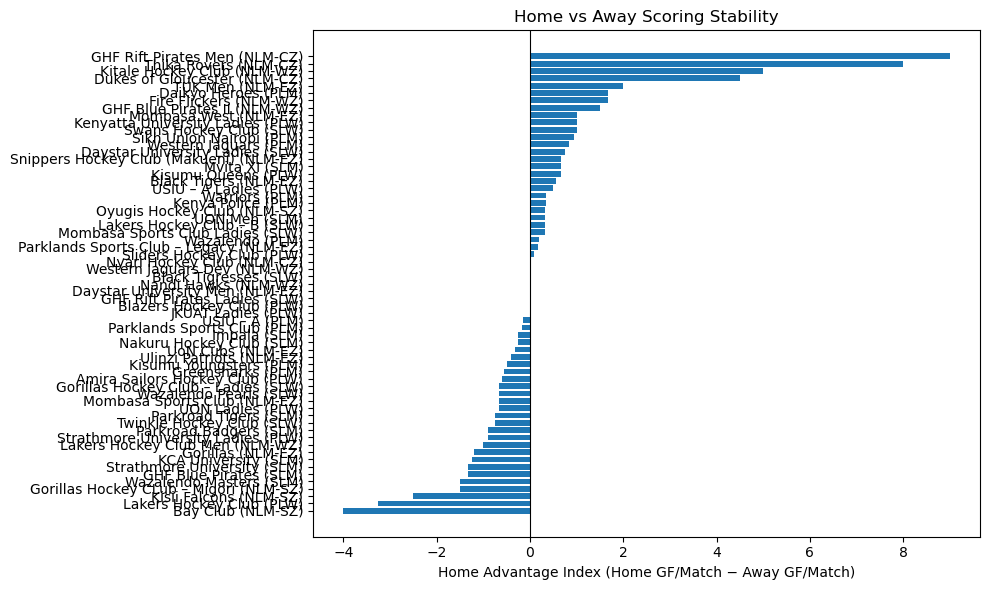

In [283]:
# Cell 427 - Visualization

ranking = home_away.sort_values("HomeAdvantageIndex", ascending=False)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    (ranking["Team"] + " (" + ranking["Competition"] + ")"),
    ranking["HomeAdvantageIndex"]
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Home Advantage Index (Home GF/Match − Away GF/Match)")
plt.title("Home vs Away Scoring Stability")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [284]:
# Cell 428 - Executive Report

print("=" * 75)
print("HOME VS AWAY SCORING STABILITY REPORT")
print("=" * 75)

for comp in home_away["Competition"].unique():

    print(f"\n{'#'*75}")
    print(f"# {comp}")
    print(f"{'#'*75}")

    comp_rows = home_away[home_away["Competition"] == comp]

    for _, row in comp_rows.sort_values(
        "HomeAdvantageIndex", ascending=False
    ).iterrows():

        print(f"\n{row['Team']}")
        print("-" * len(row["Team"]))
        print(f"Home Goals/Match : {row['HomeGFPerMatch']}")
        print(f"Away Goals/Match : {row['AwayGFPerMatch']}")
        print(f"Home Advantage Index : {row['HomeAdvantageIndex']}")

        if row["HomeAdvantageIndex"] > 0.5:
            print(
                "Coaching Insight: Clear home advantage — attacking output "
                "drops noticeably on the road."
            )
        elif row["HomeAdvantageIndex"] < -0.5:
            print(
                "Coaching Insight: The team actually attacks better away from "
                "home; worth investigating home-pitch/tactical setup."
            )
        else:
            print(
                "Coaching Insight: Balanced output home and away — no strong "
                "venue dependence."
            )


HOME VS AWAY SCORING STABILITY REPORT

###########################################################################
# NLM-CZ
###########################################################################

GHF Rift Pirates Men
--------------------
Home Goals/Match : 9.0
Away Goals/Match : nan
Home Advantage Index : 9.0
Coaching Insight: Clear home advantage — attacking output drops noticeably on the road.

Thika Rovers
------------
Home Goals/Match : 8.0
Away Goals/Match : nan
Home Advantage Index : 8.0
Coaching Insight: Clear home advantage — attacking output drops noticeably on the road.

Dukes of Gloucester
-------------------
Home Goals/Match : 5.0
Away Goals/Match : 0.5
Home Advantage Index : 4.5
Coaching Insight: Clear home advantage — attacking output drops noticeably on the road.

Nyari Hockey Club
-----------------
Home Goals/Match : nan
Away Goals/Match : 0.0
Home Advantage Index : 0.0
Coaching Insight: Balanced output home and away — no strong venue dependence.

#################

In [285]:
# Cell 429 - Save Module 29 Outputs

home_away.to_csv(
    "../data/processed/home_away_stability.csv",
    index=False
)

print("Home/away stability table saved successfully.")

Home/away stability table saved successfully.


In [286]:
# Cell 429B - Defensive Rebuild (Modules 31+)

# Modules 25-28 above reassign player_goals, team_goals, and goal_events
# with different, narrower schemas than the ones Cell 122D originally
# built (some drop Competition/Team, one drops the MinuteValue column
# used for clutch-goal detection). Rather than track down and fix every
# historical cell that does this, everything from here on rebuilds its
# own inputs fresh — consistent with this notebook's restart-safe design
# principle, and safe regardless of what ran before it.

goal_events = (
    events_df[
        events_df["Event"].str.strip().str.lower() == "goal"
    ]
    .copy()
)

goal_events["MinuteValue"] = (
    goal_events["Minute"]
    .astype(str)
    .str.replace("'", "", regex=False)
)
goal_events["MinuteValue"] = pd.to_numeric(goal_events["MinuteValue"], errors="coerce")

card_events = (
    events_df[
        events_df["Event"].str.contains("card", case=False, na=False)
    ]
    .copy()
)
cards = card_events

player_goals = (
    goal_events
    .groupby(["Competition", "Team", "Player"])
    .size()
    .reset_index(name="Goals")
)

team_distribution = (
    goal_events
    .groupby(["Competition", "Team"])
    .agg(TotalGoals=("Player", "count"), UniqueScorers=("Player", "nunique"))
    .reset_index()
)

print("Rebuilt for Modules 31+:")
print(f"  goal_events      : {len(goal_events)} rows, MinuteValue present: {'MinuteValue' in goal_events.columns}")
print(f"  player_goals     : {len(player_goals)} rows, columns: {list(player_goals.columns)}")
print(f"  team_distribution: {len(team_distribution)} rows")


Rebuilt for Modules 31+:
  goal_events      : 104 rows, MinuteValue present: True
  player_goals     : 65 rows, columns: ['Competition', 'Team', 'Player', 'Goals']
  team_distribution: 18 rows


## Module 31: Coach Intelligence — Big-Game Performance & Squad Reliance

**Business Question:** Which teams perform well against the toughest opponents in their competition, and which are over-reliant on one or two scorers?

**Objectives:**
- Identify each competition's top-3 teams by league position
- Measure every team's record specifically against those top-3 sides (a much harder test than overall record)
- Quantify squad reliance: how many players account for most of a team's goals
- Flag clutch scoring — goals in the closing stage of matches

**Expected Outputs:**
- [x] Big-Game Record table
- [x] Squad Reliance Index
- [x] Clutch Goals table
- [x] Coaching Insights

**Assumption:** "Clutch" is defined as goals scored from minute 50 onward, based on the standard 60-minute modern hockey match format. Where a match ran longer (extra time), goals past minute 50 are still counted as clutch.

**Data coverage caveat, confirmed against the live source site:** KHU does not enter goal-by-goal detail for every match — many matches have only a final score, with the rest of the record (goal scorers, minutes, cards) simply not present in the source data. This is a real gap in KHU's own record-keeping, not a scraping limitation — verified directly by fetching a real match page with a 5-0 scoreline that had zero embedded event data. See the Event Data Coverage Rate reported in the Data Integrity Check near the top of this notebook (`event_coverage_rate`) for the exact percentage on this run. Every player-level metric below describes only the matches with full detail, not the complete season.


In [287]:
# Cell 430 - Big-Game Record (vs Top 3 in Competition)

top3_by_comp = (
    league_table[league_table["Position"] <= 3]
    [["Competition", "Team"]]
)

big_game_records = []

for comp in matches_df["Competition"].unique():

    comp_matches = matches_df[matches_df["Competition"] == comp]
    top3_teams = set(top3_by_comp.loc[top3_by_comp["Competition"] == comp, "Team"])

    if not top3_teams:
        continue

    all_teams = set(comp_matches["HomeTeam"]) | set(comp_matches["AwayTeam"])

    for team in all_teams:

        home_vs_top3 = comp_matches[
            (comp_matches["HomeTeam"] == team) &
            (comp_matches["AwayTeam"].isin(top3_teams))
        ]

        away_vs_top3 = comp_matches[
            (comp_matches["AwayTeam"] == team) &
            (comp_matches["HomeTeam"].isin(top3_teams))
        ]

        played = len(home_vs_top3) + len(away_vs_top3)

        if played == 0:
            continue

        wins = (
            (home_vs_top3["HomeGoals"] > home_vs_top3["AwayGoals"]).sum() +
            (away_vs_top3["AwayGoals"] > away_vs_top3["HomeGoals"]).sum()
        )

        draws = (
            (home_vs_top3["HomeGoals"] == home_vs_top3["AwayGoals"]).sum() +
            (away_vs_top3["AwayGoals"] == away_vs_top3["HomeGoals"]).sum()
        )

        gf = home_vs_top3["HomeGoals"].sum() + away_vs_top3["AwayGoals"].sum()
        ga = home_vs_top3["AwayGoals"].sum() + away_vs_top3["HomeGoals"].sum()

        big_game_records.append({
            "Competition": comp,
            "Team": team,
            "IsTop3": team in top3_teams,
            "PlayedVsTop3": played,
            "WinsVsTop3": wins,
            "DrawsVsTop3": draws,
            "PointsVsTop3": wins * 3 + draws,
            "GFVsTop3": gf,
            "GAVsTop3": ga,
        })

big_game_df = pd.DataFrame(big_game_records)

big_game_df["PointsPerGameVsTop3"] = (
    big_game_df["PointsVsTop3"] / big_game_df["PlayedVsTop3"]
).round(2)

big_game_df = big_game_df.sort_values(
    ["Competition", "PointsPerGameVsTop3"],
    ascending=[True, False]
)

big_game_df


,Competition,Team,IsTop3,PlayedVsTop3,WinsVsTop3,DrawsVsTop3,PointsVsTop3,GFVsTop3,GAVsTop3,PointsPerGameVsTop3
51,NLM-CZ,Thika Rovers,True,1,1,0,3,8,0,3.0
52,NLM-CZ,GHF Rift Pirates Men,True,1,1,0,3,9,1,3.0
49,NLM-CZ,Dukes of Gloucester,True,2,0,0,0,1,17,0.0
50,NLM-CZ,Nyari Hockey Club,False,1,0,0,0,0,5,0.0
48,NLM-EZ,Ulinzi Patriots,True,2,2,0,6,4,1,3.0
...,...,...,...,...,...,...,...,...,...,...
38,SLW,Mombasa Sports Club Ladies,False,2,0,1,1,1,2,0.5
31,SLW,Wazalendo Pearls,True,1,0,0,0,0,1,0.0
32,SLW,Gorillas Hockey Club – Ladies,False,2,0,0,0,1,3,0.0
34,SLW,Black Tigresses,False,1,0,0,0,0,6,0.0


In [288]:
# Cell 431 - Giant Killers (best record vs top-3 among non-top-3 teams)

giant_killers = (
    big_game_df[~big_game_df["IsTop3"]]
    .sort_values(["Competition", "PointsPerGameVsTop3"], ascending=[True, False])
)

giant_killers


,Competition,Team,IsTop3,PlayedVsTop3,WinsVsTop3,DrawsVsTop3,PointsVsTop3,GFVsTop3,GAVsTop3,PointsPerGameVsTop3
50,NLM-CZ,Nyari Hockey Club,False,1,0,0,0,0,5,0.00
43,NLM-EZ,Mombasa West,False,3,2,1,7,5,2,2.33
42,NLM-EZ,TUK Men,False,2,1,0,3,4,4,1.50
47,NLM-EZ,Parklands Sports Club – Legacy,False,3,1,1,4,4,4,1.33
41,NLM-EZ,Mombasa Sports Club,False,3,0,3,3,4,4,1.00
39,NLM-EZ,UoN Cubs,False,2,0,0,0,1,4,0.00
44,NLM-EZ,Snippers Hockey Club (Makueni),False,3,0,0,0,1,4,0.00
45,NLM-EZ,Daystar University Men,False,3,0,0,0,4,9,0.00
62,NLM-SZ,Oyugis Hockey Club,False,3,0,0,0,1,15,0.00
57,NLM-WZ,Nandi Hawks,False,3,1,0,3,2,9,1.00


In [289]:
# Cell 432 - Squad Reliance Index

squad_reliance = (
    player_goals
    .groupby(["Competition", "Team"])
    .apply(lambda g: g.nlargest(1, "Goals")["Goals"].sum() / g["Goals"].sum() if g["Goals"].sum() > 0 else 0)
    .reset_index(name="TopScorerShare")
)

squad_reliance["TopScorerShare"] = (squad_reliance["TopScorerShare"] * 100).round(1)

squad_reliance = squad_reliance.merge(
    team_distribution[["Competition", "Team", "UniqueScorers", "TotalGoals"]],
    on=["Competition", "Team"],
    how="left"
)

def reliance_flag(pct):
    if pct >= 40:
        return "High Reliance — Vulnerable"
    elif pct >= 25:
        return "Moderate Reliance"
    else:
        return "Well Distributed"

squad_reliance["ReliancFlag"] = squad_reliance["TopScorerShare"].apply(reliance_flag)

squad_reliance = squad_reliance.sort_values(
    ["Competition", "TopScorerShare"],
    ascending=[True, False]
)

squad_reliance


C:\Users\Administrator\AppData\Local\Temp\ipykernel_29504\1049194034.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(1, "Goals")["Goals"].sum() / g["Goals"].sum() if g["Goals"].sum() > 0 else 0)


,Competition,Team,TopScorerShare,UniqueScorers,TotalGoals,ReliancFlag
1,PLM,Greensharks,100.0,1,1,High Reliance — Vulnerable
3,PLM,Kisumu Youngsters,66.7,3,6,High Reliance — Vulnerable
2,PLM,Kenya Police,57.1,4,7,High Reliance — Vulnerable
5,PLM,Sikh Union Nairobi,46.2,5,13,High Reliance — Vulnerable
8,PLM,Wazalendo,40.0,5,10,High Reliance — Vulnerable
4,PLM,Parklands Sports Club,33.3,6,9,Moderate Reliance
7,PLM,Warriors,30.0,7,10,Moderate Reliance
6,PLM,USIU – A,28.6,5,7,Moderate Reliance
9,PLM,Western Jaguars,27.3,7,11,Moderate Reliance
0,PLM,Daikyo Heroes,22.2,6,9,Well Distributed


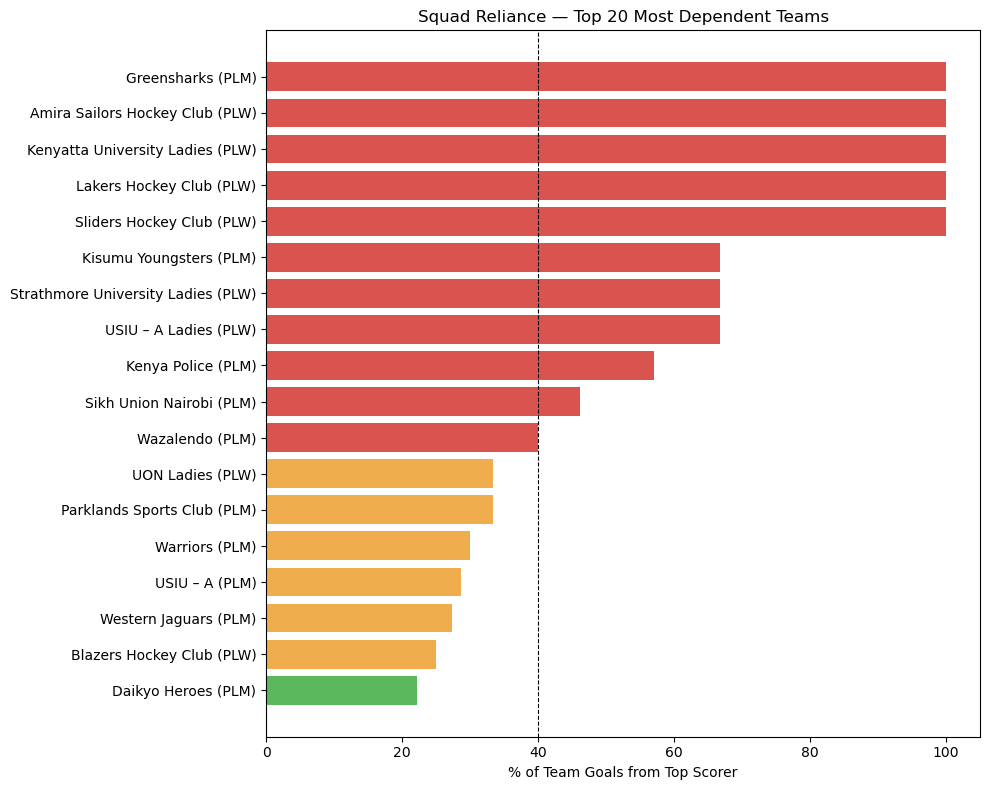

In [290]:
# Cell 432B - Squad Reliance Chart

top_reliant = squad_reliance.sort_values("TopScorerShare", ascending=False).head(20)
labels = top_reliant["Team"] + " (" + top_reliant["Competition"] + ")"

colors = top_reliant["TopScorerShare"].apply(
    lambda x: "#d9534f" if x >= 40 else ("#f0ad4e" if x >= 25 else "#5cb85c")
)

plt.figure(figsize=(10, 8))
plt.barh(labels, top_reliant["TopScorerShare"], color=colors)
plt.gca().invert_yaxis()
plt.axvline(40, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("% of Team Goals from Top Scorer")
plt.title("Squad Reliance — Top 20 Most Dependent Teams")
plt.tight_layout()
plt.show()


In [291]:
# Cell 433 - Clutch Goals (minute 50+)

clutch_goals = (
    goal_events[goal_events["MinuteValue"] >= 50]
    .groupby(["Competition", "Team", "Player"])
    .size()
    .reset_index(name="ClutchGoals")
    .sort_values(["Competition", "ClutchGoals"], ascending=[True, False])
)

clutch_goals


,Competition,Team,Player,ClutchGoals
6,PLM,Sikh Union Nairobi,Mathias Gularire,2
11,PLM,Western Jaguars,Sheldone Kimtai,2
0,PLM,Daikyo Heroes,Esbon Ombui,1
1,PLM,Daikyo Heroes,Khizar Akhtar,1
2,PLM,Kenya Police,Kennedy Sibweche,1
3,PLM,Kisumu Youngsters,Malack Masese,1
4,PLM,Parklands Sports Club,Valentine Keya,1
5,PLM,Parklands Sports Club,William Kirwa,1
7,PLM,Warriors,Calvins Kanu Omondi,1
8,PLM,Warriors,Frankline Wakhongo,1


In [292]:
# Cell 434 - Coach Executive Report

print("=" * 75)
print("COACH INTELLIGENCE REPORT")
print("=" * 75)

for comp in league_table["Competition"].unique():

    print(f"\n{'#'*75}")
    print(f"# {comp}")
    print(f"{'#'*75}")

    top_giant_killer = giant_killers[giant_killers["Competition"] == comp]
    if len(top_giant_killer) > 0:
        gk = top_giant_killer.iloc[0]
        print(f"\nBiggest Giant Killer: {gk['Team']} "
              f"({gk['PointsPerGameVsTop3']} pts/game vs top-3 sides)")

    reliant = squad_reliance[
        (squad_reliance["Competition"] == comp) &
        (squad_reliance["ReliancFlag"] == "High Reliance — Vulnerable")
    ]
    if len(reliant) > 0:
        print(f"\nSquads over-reliant on one scorer (recruitment risk if that player leaves):")
        for _, row in reliant.iterrows():
            print(f"  - {row['Team']}: {row['TopScorerShare']}% of goals from one player")

    clutch = clutch_goals[clutch_goals["Competition"] == comp].head(3)
    if len(clutch) > 0:
        print(f"\nTop clutch performers (goals from minute 50+):")
        for _, row in clutch.iterrows():
            print(f"  - {row['Player']} ({row['Team']}): {row['ClutchGoals']} clutch goals")


COACH INTELLIGENCE REPORT

###########################################################################
# NLM-CZ
###########################################################################

Biggest Giant Killer: Nyari Hockey Club (0.0 pts/game vs top-3 sides)

###########################################################################
# NLM-EZ
###########################################################################

Biggest Giant Killer: Mombasa West (2.33 pts/game vs top-3 sides)

###########################################################################
# NLM-SZ
###########################################################################

Biggest Giant Killer: Oyugis Hockey Club (0.0 pts/game vs top-3 sides)

###########################################################################
# NLM-WZ
###########################################################################

Biggest Giant Killer: Nandi Hawks (1.0 pts/game vs top-3 sides)

##################################################

In [293]:
# Cell 435 - Save Module 31 Outputs

big_game_df.to_csv("../data/processed/big_game_record.csv", index=False)
squad_reliance.to_csv("../data/processed/squad_reliance.csv", index=False)
clutch_goals.to_csv("../data/processed/clutch_goals.csv", index=False)

print("Module 31 outputs saved.")


Module 31 outputs saved.


## Module 32: Scout Intelligence — Breakout Detection & Efficiency

**Business Question:** Which players are outperforming their competition, and which combine both high output and high efficiency rather than padding stats against weak opponents?

**Objectives:**
- Rank every scorer against their own competition's mean and standard deviation (a fair comparison, since National League and Premier League have very different scoring environments)
- Flag statistical outliers as breakout candidates
- Classify players into a Volume/Efficiency quadrant, since raw goal totals alone reward players from high-scoring teams regardless of individual quality

**Expected Outputs:**
- [x] Player Z-Score Rankings (within competition)
- [x] Breakout Candidates
- [x] Volume vs Efficiency Quadrant
- [x] Scouting Report

**Data limitation, stated plainly:** the source site does not publish individual appearance/minutes-played data, only goal and card events. "Efficiency" here uses each player's team's matches played as a proxy denominator, not the player's own appearances — a player who missed several matches through injury will look less efficient than they actually were. This is disclosed here rather than presented as more precise than it is.

**Data coverage caveat, confirmed against the live source site:** KHU does not enter goal-by-goal detail for every match — many matches have only a final score, with the rest of the record (goal scorers, minutes, cards) simply not present in the source data. This is a real gap in KHU's own record-keeping, not a scraping limitation — verified directly by fetching a real match page with a 5-0 scoreline that had zero embedded event data. See the Event Data Coverage Rate reported in the Data Integrity Check near the top of this notebook (`event_coverage_rate`) for the exact percentage on this run. Every player-level metric below describes only the matches with full detail, not the complete season.


In [294]:
# Cell 436 - Player Z-Scores Within Competition

comp_stats = (
    player_goals
    .groupby("Competition")["Goals"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "CompMeanGoals", "std": "CompStdGoals"})
)

player_zscore = player_goals.merge(comp_stats, on="Competition")

player_zscore["ZScore"] = (
    (player_zscore["Goals"] - player_zscore["CompMeanGoals"]) /
    player_zscore["CompStdGoals"].replace(0, np.nan)
).round(2)

player_zscore = player_zscore.sort_values(
    ["Competition", "ZScore"],
    ascending=[True, False]
)

player_zscore


,Competition,Team,Player,Goals,CompMeanGoals,CompStdGoals,ZScore
24,PLM,Sikh Union Nairobi,Mathias Gularire,6,1.693878,1.084053,3.97
9,PLM,Kenya Police,Robert Masibo,4,1.693878,1.084053,2.13
13,PLM,Kisumu Youngsters,Malack Masese,4,1.693878,1.084053,2.13
39,PLM,Wazalendo,Job Wandera,4,1.693878,1.084053,2.13
15,PLM,Parklands Sports Club,Eudgas Lirhu,3,1.693878,1.084053,1.20
...,...,...,...,...,...,...,...
59,PLW,Strathmore University Ladies,Nichole Joy,1,1.312500,0.478714,-0.65
60,PLW,UON Ladies,Clementine Sims,1,1.312500,0.478714,-0.65
61,PLW,UON Ladies,Mitchell Akoth,1,1.312500,0.478714,-0.65
62,PLW,UON Ladies,Noela Kimathi,1,1.312500,0.478714,-0.65


In [295]:
# Cell 437 - Breakout Candidates (Z-Score >= 2)

breakout_candidates = (
    player_zscore[player_zscore["ZScore"] >= 2]
    .sort_values("ZScore", ascending=False)
)

print(f"Found {len(breakout_candidates)} statistical outliers across all competitions.")

breakout_candidates


Found 4 statistical outliers across all competitions.


,Competition,Team,Player,Goals,CompMeanGoals,CompStdGoals,ZScore
24,PLM,Sikh Union Nairobi,Mathias Gularire,6,1.693878,1.084053,3.97
9,PLM,Kenya Police,Robert Masibo,4,1.693878,1.084053,2.13
13,PLM,Kisumu Youngsters,Malack Masese,4,1.693878,1.084053,2.13
39,PLM,Wazalendo,Job Wandera,4,1.693878,1.084053,2.13


In [296]:
# Cell 438 - Volume vs Efficiency Quadrant

player_quadrant = player_goals.merge(
    league_table[["Competition", "Team", "Played"]],
    on=["Competition", "Team"],
    how="left"
)

player_quadrant["GoalsPerTeamMatch"] = (
    player_quadrant["Goals"] / player_quadrant["Played"]
).round(2)

vol_median = player_quadrant["Goals"].median()
eff_median = player_quadrant["GoalsPerTeamMatch"].median()

def classify_player(row):
    high_volume = row["Goals"] >= vol_median
    high_efficiency = row["GoalsPerTeamMatch"] >= eff_median
    if high_volume and high_efficiency:
        return "Elite — High Volume & Efficient"
    elif high_volume and not high_efficiency:
        return "Volume Scorer"
    elif not high_volume and high_efficiency:
        return "Efficient Impact Player"
    else:
        return "Below Average"

player_quadrant["ScoutingCategory"] = player_quadrant.apply(classify_player, axis=1)

player_quadrant = player_quadrant.sort_values(
    ["Competition", "GoalsPerTeamMatch"],
    ascending=[True, False]
)

player_quadrant


,Competition,Team,Player,Goals,Played,GoalsPerTeamMatch,ScoutingCategory
24,PLM,Sikh Union Nairobi,Mathias Gularire,6,9,0.67,Elite — High Volume & Efficient
9,PLM,Kenya Police,Robert Masibo,4,9,0.44,Elite — High Volume & Efficient
13,PLM,Kisumu Youngsters,Malack Masese,4,9,0.44,Elite — High Volume & Efficient
39,PLM,Wazalendo,Job Wandera,4,9,0.44,Elite — High Volume & Efficient
15,PLM,Parklands Sports Club,Eudgas Lirhu,3,9,0.33,Elite — High Volume & Efficient
...,...,...,...,...,...,...,...
50,PLW,Blazers Hockey Club,Amanda Ijai,1,7,0.14,Elite — High Volume & Efficient
54,PLW,Blazers Hockey Club,Vivian Onyango,1,7,0.14,Elite — High Volume & Efficient
57,PLW,Sliders Hockey Club,Margaret Mawombe,1,7,0.14,Elite — High Volume & Efficient
59,PLW,Strathmore University Ladies,Nichole Joy,1,7,0.14,Elite — High Volume & Efficient


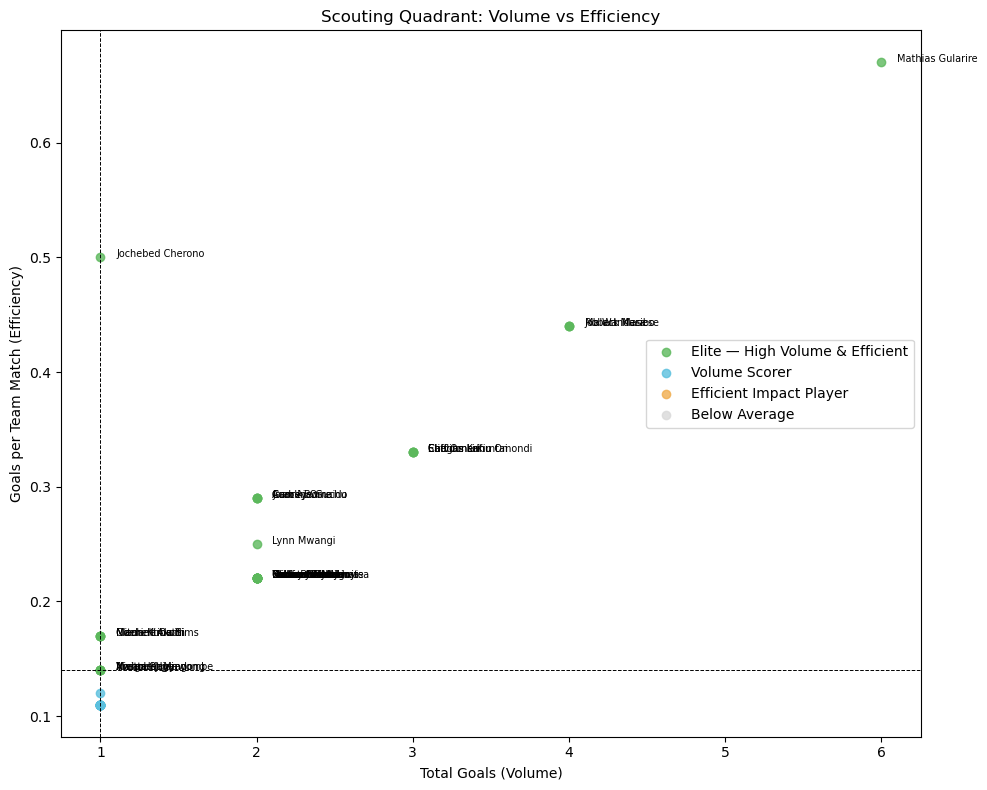

In [297]:
# Cell 438B - Volume vs Efficiency Chart

category_colors = {
    "Elite — High Volume & Efficient": "#5cb85c",
    "Volume Scorer": "#5bc0de",
    "Efficient Impact Player": "#f0ad4e",
    "Below Average": "#d9d9d9",
}

plt.figure(figsize=(10, 8))

for cat, color in category_colors.items():
    subset = player_quadrant[player_quadrant["ScoutingCategory"] == cat]
    plt.scatter(subset["Goals"], subset["GoalsPerTeamMatch"], label=cat, color=color, alpha=0.8)

for _, row in player_quadrant[
    player_quadrant["ScoutingCategory"] == "Elite — High Volume & Efficient"
].iterrows():
    plt.text(row["Goals"] + 0.1, row["GoalsPerTeamMatch"], row["Player"], fontsize=7)

plt.axvline(vol_median, color="black", linestyle="--", linewidth=0.7)
plt.axhline(eff_median, color="black", linestyle="--", linewidth=0.7)
plt.xlabel("Total Goals (Volume)")
plt.ylabel("Goals per Team Match (Efficiency)")
plt.title("Scouting Quadrant: Volume vs Efficiency")
plt.legend()
plt.tight_layout()
plt.show()


In [298]:
# Cell 439 - Scouting Report

print("=" * 75)
print("SCOUT INTELLIGENCE REPORT")
print("=" * 75)

for comp in player_goals["Competition"].unique():

    print(f"\n{'#'*75}")
    print(f"# {comp}")
    print(f"{'#'*75}")

    comp_breakouts = breakout_candidates[breakout_candidates["Competition"] == comp]
    if len(comp_breakouts) > 0:
        print("\nBreakout candidates (statistically far above competition average):")
        for _, row in comp_breakouts.iterrows():
            print(f"  - {row['Player']} ({row['Team']}): {row['Goals']} goals, "
                  f"Z-score {row['ZScore']}")

    elite = player_quadrant[
        (player_quadrant["Competition"] == comp) &
        (player_quadrant["ScoutingCategory"] == "Elite — High Volume & Efficient")
    ]
    if len(elite) > 0:
        print("\nElite (high volume AND high efficiency):")
        for _, row in elite.iterrows():
            print(f"  - {row['Player']} ({row['Team']}): {row['Goals']} goals, "
                  f"{row['GoalsPerTeamMatch']}/game")


SCOUT INTELLIGENCE REPORT

###########################################################################
# PLM
###########################################################################

Breakout candidates (statistically far above competition average):
  - Mathias Gularire (Sikh Union Nairobi): 6 goals, Z-score 3.97
  - Robert Masibo (Kenya Police): 4 goals, Z-score 2.13
  - Malack Masese (Kisumu Youngsters): 4 goals, Z-score 2.13
  - Job Wandera (Wazalendo): 4 goals, Z-score 2.13

Elite (high volume AND high efficiency):
  - Mathias Gularire (Sikh Union Nairobi): 6 goals, 0.67/game
  - Robert Masibo (Kenya Police): 4 goals, 0.44/game
  - Malack Masese (Kisumu Youngsters): 4 goals, 0.44/game
  - Job Wandera (Wazalendo): 4 goals, 0.44/game
  - Eudgas Lirhu (Parklands Sports Club): 3 goals, 0.33/game
  - Cliff Omari (Sikh Union Nairobi): 3 goals, 0.33/game
  - Calvins Kanu Omondi (Warriors): 3 goals, 0.33/game
  - Sheldone Kimtai (Western Jaguars): 3 goals, 0.33/game
  - Bonny Ndombi (Da

In [299]:
# Cell 440 - Save Module 32 Outputs

player_zscore.to_csv("../data/processed/player_zscore.csv", index=False)
breakout_candidates.to_csv("../data/processed/breakout_candidates.csv", index=False)
player_quadrant.to_csv("../data/processed/player_quadrant.csv", index=False)

print("Module 32 outputs saved.")


Module 32 outputs saved.


## Module 33: Federation Intelligence — Competitive Balance & League Health

**Business Question:** How healthy and competitive is each of the 8 competitions, and are matches/discipline evenly distributed or concentrated in a few teams?

**Objectives:**
- Measure competitive balance per competition — a league where one team wins everything is less healthy than a tightly contested one
- Compare participation levels across the 4 National League zones, which vary enormously in match counts
- Quantify discipline load per competition, since a competition with a high card rate may need referee or conduct review

**Expected Outputs:**
- [x] Competitive Balance Index per competition
- [x] Zone/Competition Participation Summary
- [x] Discipline Load per Competition
- [x] Federation Executive Report


In [300]:
# Cell 441 - Competitive Balance Index

# Coefficient of variation of Points across teams in a competition.
# Lower = more evenly matched (healthier competition).
# Higher = one or two teams dominating.

balance_records = []

for comp in league_table["Competition"].unique():

    comp_table = league_table[league_table["Competition"] == comp]

    points_mean = comp_table["Points"].mean()
    points_std = comp_table["Points"].std(ddof=0)

    cv = (points_std / points_mean) if points_mean > 0 else np.nan

    balance_records.append({
        "Competition": comp,
        "Teams": len(comp_table),
        "AvgPoints": round(points_mean, 1),
        "PointsStdDev": round(points_std, 1),
        "CompetitiveBalanceIndex": round(cv, 2) if pd.notna(cv) else None
    })

balance_df = pd.DataFrame(balance_records).sort_values("CompetitiveBalanceIndex")

def balance_label(cv):
    if cv is None:
        return "Insufficient Data"
    elif cv <= 0.25:
        return "Highly Competitive"
    elif cv <= 0.45:
        return "Moderately Competitive"
    else:
        return "One-Sided"

balance_df["BalanceRating"] = balance_df["CompetitiveBalanceIndex"].apply(balance_label)

balance_df


,Competition,Teams,AvgPoints,PointsStdDev,CompetitiveBalanceIndex,BalanceRating
4,PLM,10,12.6,5.0,0.39,Moderately Competitive
6,SLM,10,9.1,4.3,0.47,One-Sided
0,NLM-CZ,4,2.2,1.3,0.58,One-Sided
1,NLM-EZ,10,8.6,5.2,0.60,One-Sided
5,PLW,10,7.2,5.1,0.70,One-Sided
2,NLM-SZ,4,4.5,3.4,0.75,One-Sided
7,SLW,9,6.2,5.1,0.81,One-Sided
3,NLM-WZ,6,5.2,4.9,0.96,One-Sided


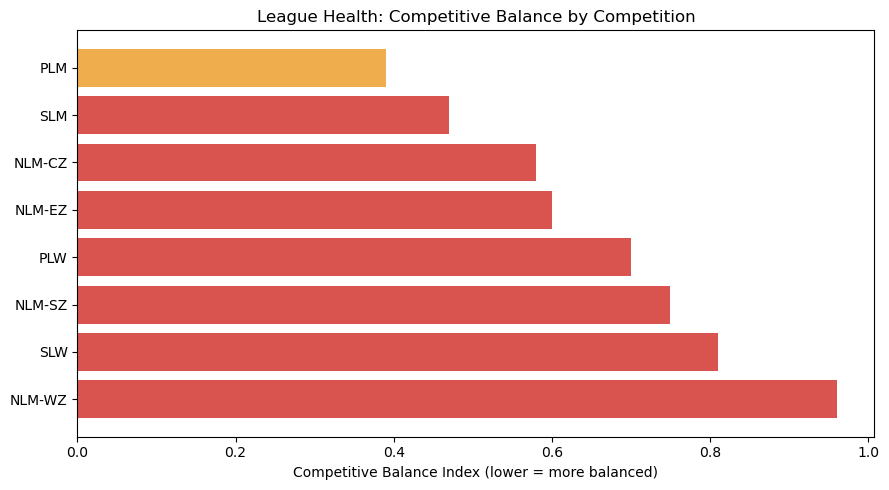

In [301]:
# Cell 441B - Competitive Balance Chart

rating_colors = {
    "Highly Competitive": "#5cb85c",
    "Moderately Competitive": "#f0ad4e",
    "One-Sided": "#d9534f",
    "Insufficient Data": "#d9d9d9",
}

colors = balance_df["BalanceRating"].map(rating_colors)

plt.figure(figsize=(9, 5))
plt.barh(balance_df["Competition"], balance_df["CompetitiveBalanceIndex"].fillna(0), color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Competitive Balance Index (lower = more balanced)")
plt.title("League Health: Competitive Balance by Competition")
plt.tight_layout()
plt.show()


In [302]:
# Cell 442 - Participation Summary

participation = (
    matches_df
    .groupby("Competition")
    .agg(
        MatchesRecorded=("Competition", "count"),
        TeamsInvolved=("HomeTeam", lambda x: pd.concat([x, matches_df.loc[x.index, "AwayTeam"]]).nunique())
    )
    .reset_index()
)

# Simpler, more reliable team count per competition
team_counts = (
    league_table
    .groupby("Competition")["Team"]
    .nunique()
    .reset_index(name="TeamsInvolved")
)

participation = (
    matches_df.groupby("Competition").size().reset_index(name="MatchesRecorded")
    .merge(team_counts, on="Competition")
)

participation["MatchesPerTeam"] = (
    participation["MatchesRecorded"] * 2 / participation["TeamsInvolved"]
).round(1)

participation = participation.sort_values("MatchesRecorded", ascending=False)

participation


,Competition,MatchesRecorded,TeamsInvolved,MatchesPerTeam
4,PLM,45,10,9.0
6,SLM,33,10,6.6
1,NLM-EZ,31,10,6.2
5,PLW,28,10,5.6
7,SLW,20,9,4.4
3,NLM-WZ,11,6,3.7
2,NLM-SZ,6,4,3.0
0,NLM-CZ,3,4,1.5


In [303]:
# Cell 443 - Discipline Load per Competition

discipline_load = (
    card_events
    .groupby("Competition")
    .size()
    .reset_index(name="TotalCards")
    .merge(participation[["Competition", "MatchesRecorded"]], on="Competition")
)

discipline_load["CardsPerMatch"] = (
    discipline_load["TotalCards"] / discipline_load["MatchesRecorded"]
).round(2)

discipline_load = discipline_load.sort_values("CardsPerMatch", ascending=False)

discipline_load


,Competition,TotalCards,MatchesRecorded,CardsPerMatch
0,PLM,89,45,1.98
1,PLW,16,28,0.57


In [304]:
# Cell 444 - Federation Executive Report

print("=" * 75)
print("FEDERATION INTELLIGENCE REPORT")
print("=" * 75)

print("\nCompetitive Balance (most to least competitive):")
for _, row in balance_df.iterrows():
    cbi = row["CompetitiveBalanceIndex"]
    cbi_str = f"{cbi}" if cbi is not None else "N/A"
    print(f"  {row['Competition']:8s} | Balance Index: {cbi_str:6s} | {row['BalanceRating']}")

print("\nParticipation by Competition:")
for _, row in participation.iterrows():
    print(f"  {row['Competition']:8s} | {row['TeamsInvolved']} teams | "
          f"{row['MatchesRecorded']} matches recorded | "
          f"{row['MatchesPerTeam']} matches/team avg")

print("\nDiscipline Load (highest to lowest cards/match):")
for _, row in discipline_load.iterrows():
    print(f"  {row['Competition']:8s} | {row['CardsPerMatch']} cards/match "
          f"({row['TotalCards']} total)")

print("\nNote for federation review: competitions with low MatchesPerTeam "
      "(especially some National League zones) reflect fewer fixtures scraped "
      "at the time of this report, not necessarily fewer fixtures played — "
      "worth cross-checking against the official fixture list before drawing "
      "conclusions about any zone\'s activity level.")


FEDERATION INTELLIGENCE REPORT

Competitive Balance (most to least competitive):
  PLM      | Balance Index: 0.39   | Moderately Competitive
  SLM      | Balance Index: 0.47   | One-Sided
  NLM-CZ   | Balance Index: 0.58   | One-Sided
  NLM-EZ   | Balance Index: 0.6    | One-Sided
  PLW      | Balance Index: 0.7    | One-Sided
  NLM-SZ   | Balance Index: 0.75   | One-Sided
  SLW      | Balance Index: 0.81   | One-Sided
  NLM-WZ   | Balance Index: 0.96   | One-Sided

Participation by Competition:
  PLM      | 10 teams | 45 matches recorded | 9.0 matches/team avg
  SLM      | 10 teams | 33 matches recorded | 6.6 matches/team avg
  NLM-EZ   | 10 teams | 31 matches recorded | 6.2 matches/team avg
  PLW      | 10 teams | 28 matches recorded | 5.6 matches/team avg
  SLW      | 9 teams | 20 matches recorded | 4.4 matches/team avg
  NLM-WZ   | 6 teams | 11 matches recorded | 3.7 matches/team avg
  NLM-SZ   | 4 teams | 6 matches recorded | 3.0 matches/team avg
  NLM-CZ   | 4 teams | 3 matches r

In [305]:
# Cell 445 - Save Module 33 Outputs

balance_df.to_csv("../data/processed/competitive_balance.csv", index=False)
participation.to_csv("../data/processed/participation_summary.csv", index=False)
discipline_load.to_csv("../data/processed/discipline_load.csv", index=False)

print("Module 33 outputs saved.")


Module 33 outputs saved.


## Module 34: Predictive Modeling — Elo Ratings & Win Probability

**Business Question:** Which teams are genuinely the strongest right now — accounting for *who* they beat, not just how many points they have — and can we produce a credible win probability for any matchup?

**Objectives:**
- Build a standard Elo rating system, processed match-by-match in chronological order, separately per competition (ratings aren't meaningful across competitions that never play each other)
- Weight rating changes by margin of victory, since a 5-0 win is stronger evidence than a 1-0 win
- Validate the model against real outcomes — a predictive model that hasn't been checked against reality is just a plausible-looking number
- Derive Strength of Schedule from the same ratings

**Expected Outputs:**
- [x] Final Elo Ratings per team
- [x] Elo vs League Position sanity check (do they broadly agree?)
- [x] Model calibration (Brier score) — how good are the predictions, honestly?
- [x] Strength of Schedule
- [x] Win Probability function for any hypothetical matchup

**Assumption, stated plainly:** every team starts each competition at a neutral 1500 rating. Early-season ratings are therefore unreliable almost by construction — there's no history yet to distinguish a genuinely weak team from a strong one having a slow start. This is normal for any Elo system and improves as more matches are processed; it is not a bug to fix, but a limitation worth stating rather than hiding.


In [306]:
# Cell 450 - Elo: Setup

INITIAL_ELO = 1500
BASE_K = 24
HOME_ADVANTAGE = 35   # Elo points added to the home team's rating before computing expected score


def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


def margin_multiplier(goal_diff, elo_diff):
    # Standard margin-of-victory dampener (used by FiveThirtyEight-style Elo
    # systems): bigger wins move the rating more, but the effect is damped
    # when the win is already expected (large elo_diff in the winner's favor)
    # so beating a much weaker team by a lot doesn't inflate ratings further.
    return np.log(abs(goal_diff) + 1) * (2.2 / ((abs(elo_diff) * 0.001) + 2.2))


elo_matches = matches_df.copy()
elo_matches["ParsedDate"] = pd.to_datetime(elo_matches["Date"], dayfirst=True, errors="coerce")

undated = elo_matches["ParsedDate"].isna().sum()
if undated > 0:
    print(f"⚠ {undated} matches have no parseable date and will be processed last, in scraped order, "
          f"within their competition. Elo is still valid, but chronological accuracy for those "
          f"specific matches isn't guaranteed.")

elo_matches = elo_matches.sort_values(
    ["Competition", "ParsedDate"],
    na_position="last"
).reset_index(drop=True)

print(f"Ready to process {len(elo_matches)} matches across {elo_matches['Competition'].nunique()} competitions.")


Ready to process 177 matches across 8 competitions.


In [307]:
# Cell 451 - Elo: Sequential Rating Update

elo_ratings = {}          # (Competition, Team) -> current rating
elo_history = []          # every rating change, for trend charts
predictions = []          # pre-match win probability vs actual outcome, for validation

for comp in elo_matches["Competition"].unique():
    teams_in_comp = pd.unique(
        pd.concat([
            elo_matches.loc[elo_matches.Competition == comp, "HomeTeam"],
            elo_matches.loc[elo_matches.Competition == comp, "AwayTeam"]
        ])
    )
    for t in teams_in_comp:
        elo_ratings[(comp, t)] = INITIAL_ELO

for _, m in elo_matches.iterrows():

    comp = m["Competition"]
    home, away = m["HomeTeam"], m["AwayTeam"]
    hg, ag = m["HomeGoals"], m["AwayGoals"]

    home_elo = elo_ratings[(comp, home)]
    away_elo = elo_ratings[(comp, away)]

    elo_diff = (home_elo + HOME_ADVANTAGE) - away_elo

    exp_home = expected_score(home_elo + HOME_ADVANTAGE, away_elo)
    exp_away = 1 - exp_home

    if hg > ag:
        actual_home, actual_away = 1, 0
    elif hg < ag:
        actual_home, actual_away = 0, 1
    else:
        actual_home, actual_away = 0.5, 0.5

    predictions.append({
        "Competition": comp, "HomeTeam": home, "AwayTeam": away,
        "PredictedHomeWinProb": round(exp_home, 3),
        "ActualHomeResult": actual_home
    })

    goal_diff = hg - ag
    mult = margin_multiplier(goal_diff, elo_diff) if goal_diff != 0 else 1.0

    new_home_elo = home_elo + BASE_K * mult * (actual_home - exp_home)
    new_away_elo = away_elo + BASE_K * mult * (actual_away - exp_away)

    elo_ratings[(comp, home)] = new_home_elo
    elo_ratings[(comp, away)] = new_away_elo

    elo_history.append({"Competition": comp, "Team": home, "Date": m["ParsedDate"], "Elo": new_home_elo})
    elo_history.append({"Competition": comp, "Team": away, "Date": m["ParsedDate"], "Elo": new_away_elo})

elo_history_df = pd.DataFrame(elo_history)
predictions_df = pd.DataFrame(predictions)

final_elo = pd.DataFrame([
    {"Competition": c, "Team": t, "Elo": round(r, 1)}
    for (c, t), r in elo_ratings.items()
])

final_elo = final_elo.sort_values(["Competition", "Elo"], ascending=[True, False])
final_elo["EloRank"] = final_elo.groupby("Competition").cumcount() + 1

final_elo


,Competition,Team,Elo,EloRank
1,NLM-CZ,Thika Rovers,1525.0,1
2,NLM-CZ,GHF Rift Pirates Men,1522.8,2
3,NLM-CZ,Nyari Hockey Club,1481.0,3
0,NLM-CZ,Dukes of Gloucester,1471.2,4
11,NLM-EZ,Ulinzi Patriots,1535.8,1
...,...,...,...,...
55,SLW,Swans Hockey Club,1496.8,5
60,SLW,Mombasa Sports Club Ladies,1487.4,6
54,SLW,Black Tigresses,1474.7,7
62,SLW,Gorillas Hockey Club – Ladies,1473.5,8


Correlation between final Elo rating and league Points: 0.74
(Expect a strong positive correlation — Elo and the actual table should broadly agree, since both are measuring the same underlying team strength from different angles. A weak correlation would suggest a bug, not an insight.)


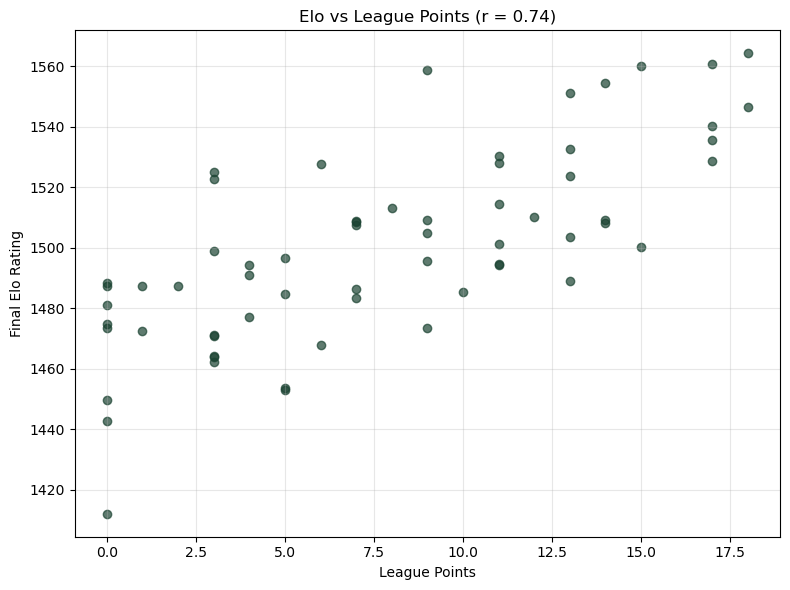

,Competition,Team,Elo,EloRank,Position,Points
0,NLM-CZ,Thika Rovers,1525.0,1,2,3
1,NLM-CZ,GHF Rift Pirates Men,1522.8,2,1,3
2,NLM-CZ,Nyari Hockey Club,1481.0,3,4,0
3,NLM-CZ,Dukes of Gloucester,1471.2,4,3,3
4,NLM-EZ,Ulinzi Patriots,1535.8,1,1,17
...,...,...,...,...,...,...
58,SLW,Swans Hockey Club,1496.8,5,5,5
59,SLW,Mombasa Sports Club Ladies,1487.4,6,7,2
60,SLW,Black Tigresses,1474.7,7,9,0
61,SLW,Gorillas Hockey Club – Ladies,1473.5,8,8,0


In [308]:
# Cell 452 - Elo vs League Position (Sanity Check)

elo_vs_table = final_elo.merge(
    league_table[["Competition", "Team", "Position", "Points"]],
    on=["Competition", "Team"]
)

correlation = elo_vs_table["Elo"].corr(elo_vs_table["Points"])

print(f"Correlation between final Elo rating and league Points: {correlation:.2f}")
print("(Expect a strong positive correlation — Elo and the actual table should broadly agree, "
      "since both are measuring the same underlying team strength from different angles. "
      "A weak correlation would suggest a bug, not an insight.)")

plt.figure(figsize=(8, 6))
plt.scatter(elo_vs_table["Points"], elo_vs_table["Elo"], alpha=0.7, color="#1b4332")
plt.xlabel("League Points")
plt.ylabel("Final Elo Rating")
plt.title(f"Elo vs League Points (r = {correlation:.2f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

elo_vs_table.sort_values(["Competition", "EloRank"]) if "EloRank" in elo_vs_table.columns else elo_vs_table


In [309]:
# Cell 453 - Model Calibration (Brier Score)

# Brier score measures how well the predicted probabilities matched reality.
# 0 = perfect predictions, 0.25 = no better than always guessing 50/50,
# 1 = perfectly wrong. This is what separates "a model that produces numbers"
# from "a model that has been checked against outcomes it didn't see coming."

predictions_df["SquaredError"] = (
    predictions_df["PredictedHomeWinProb"] - predictions_df["ActualHomeResult"]
) ** 2

brier_score = predictions_df["SquaredError"].mean()

baseline_prob = predictions_df["ActualHomeResult"].mean()
baseline_brier = ((baseline_prob - predictions_df["ActualHomeResult"]) ** 2).mean()

print(f"Elo model Brier score: {brier_score:.3f}")
print(f"Baseline (always predict the overall home-win rate): {baseline_brier:.3f}")

if brier_score < baseline_brier:
    print("\nThe Elo model beats the naive baseline — it is adding real predictive value, "
          "not just producing plausible-looking numbers.")
else:
    print("\nThe Elo model is NOT beating the naive baseline yet — likely because there "
          "isn\'t enough match history per competition for ratings to have separated "
          "teams meaningfully. Worth re-running this check once more matches are scraped.")


Elo model Brier score: 0.187
Baseline (always predict the overall home-win rate): 0.190

The Elo model beats the naive baseline — it is adding real predictive value, not just producing plausible-looking numbers.


In [310]:
# Cell 454 - Strength of Schedule

def strength_of_schedule(team, comp):
    opponents = pd.concat([
        elo_matches.loc[(elo_matches.Competition == comp) & (elo_matches.HomeTeam == team), "AwayTeam"],
        elo_matches.loc[(elo_matches.Competition == comp) & (elo_matches.AwayTeam == team), "HomeTeam"]
    ])
    opponent_elos = [elo_ratings.get((comp, opp), INITIAL_ELO) for opp in opponents]
    return round(np.mean(opponent_elos), 1) if opponent_elos else None


sos_records = []
for (comp, team) in elo_ratings.keys():
    sos_records.append({
        "Competition": comp,
        "Team": team,
        "StrengthOfSchedule": strength_of_schedule(team, comp)
    })

sos_df = pd.DataFrame(sos_records)

final_elo_with_sos = final_elo.merge(sos_df, on=["Competition", "Team"])

final_elo_with_sos = final_elo_with_sos.sort_values(["Competition", "EloRank"])

final_elo_with_sos


,Competition,Team,Elo,EloRank,StrengthOfSchedule
0,NLM-CZ,Thika Rovers,1525.0,1,1471.2
1,NLM-CZ,GHF Rift Pirates Men,1522.8,2,1471.2
2,NLM-CZ,Nyari Hockey Club,1481.0,3,1471.2
3,NLM-CZ,Dukes of Gloucester,1471.2,4,1509.6
4,NLM-EZ,Ulinzi Patriots,1535.8,1,1495.7
...,...,...,...,...,...
58,SLW,Swans Hockey Club,1496.8,5,1509.9
59,SLW,Mombasa Sports Club Ladies,1487.4,6,1512.2
60,SLW,Black Tigresses,1474.7,7,1551.3
61,SLW,Gorillas Hockey Club – Ladies,1473.5,8,1503.8


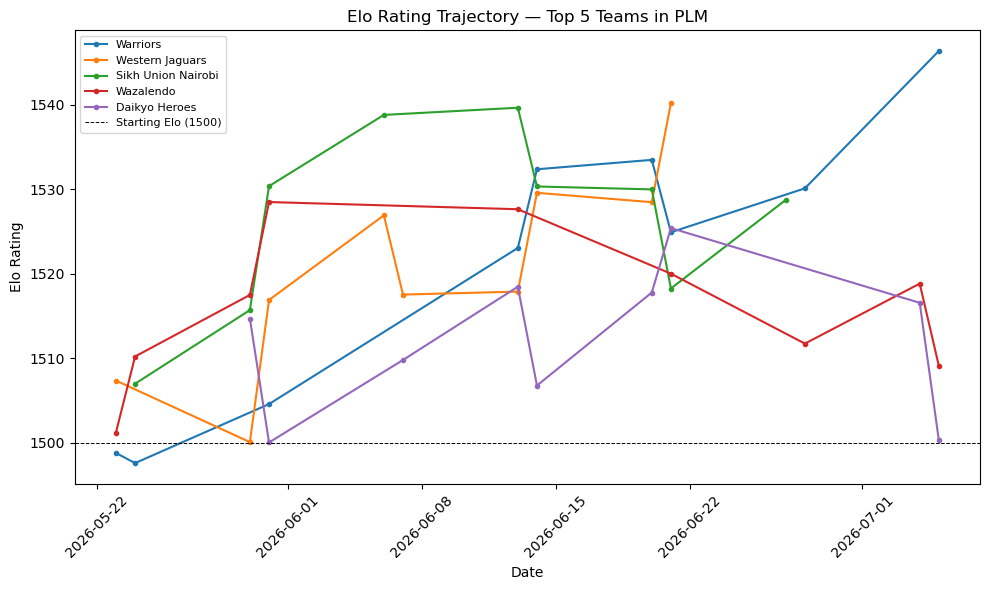

In [311]:
# Cell 455 - Elo Trajectory (Largest Competition by Matches Played)

busiest_comp = matches_df["Competition"].value_counts().idxmax()

comp_history = elo_history_df[elo_history_df["Competition"] == busiest_comp].dropna(subset=["Date"])

top_teams_in_comp = (
    final_elo[final_elo["Competition"] == busiest_comp]
    .nlargest(5, "Elo")["Team"]
)

plt.figure(figsize=(10, 6))

for team in top_teams_in_comp:
    team_hist = comp_history[comp_history["Team"] == team].sort_values("Date")
    plt.plot(team_hist["Date"], team_hist["Elo"], marker="o", markersize=3, label=team)

plt.axhline(INITIAL_ELO, color="black", linestyle="--", linewidth=0.7, label="Starting Elo (1500)")
plt.xlabel("Date")
plt.ylabel("Elo Rating")
plt.title(f"Elo Rating Trajectory — Top 5 Teams in {busiest_comp}")
plt.legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [312]:
# Cell 456 - Win Probability Function (for any hypothetical matchup)

def predict_match(team_a, team_b, competition, neutral_venue=False):
    """
    Returns team_a\'s win probability against team_b within a given
    competition, using each team\'s current Elo rating. Set
    neutral_venue=True to exclude home advantage (e.g. for a hypothetical
    cross-competition or cup-style matchup).
    """
    if (competition, team_a) not in elo_ratings or (competition, team_b) not in elo_ratings:
        raise ValueError(f"One of these teams has no Elo rating in {competition} — check spelling.")

    rating_a = elo_ratings[(competition, team_a)]
    rating_b = elo_ratings[(competition, team_b)]

    if not neutral_venue:
        rating_a += HOME_ADVANTAGE

    prob_a = expected_score(rating_a, rating_b)

    return round(prob_a, 3)


# Example: two of the top-rated teams in the busiest competition
example_teams = final_elo[final_elo["Competition"] == busiest_comp].nlargest(2, "Elo")["Team"].tolist()

if len(example_teams) == 2:
    prob = predict_match(example_teams[0], example_teams[1], busiest_comp)
    print(f"Example — {example_teams[0]} (home) vs {example_teams[1]}: "
          f"{example_teams[0]} win probability = {prob:.0%}")
    print("\nCall predict_match(team_a, team_b, competition) with any two team names "
          "from the same competition to get a matchup prediction.")


Example — Warriors (home) vs Western Jaguars: Warriors win probability = 56%

Call predict_match(team_a, team_b, competition) with any two team names from the same competition to get a matchup prediction.


In [313]:
# Cell 457 - Elo Executive Report

print("=" * 75)
print("PREDICTIVE MODELING REPORT — ELO RATINGS")
print("=" * 75)

print(f"\nModel calibration: Brier score {brier_score:.3f} "
      f"(baseline: {baseline_brier:.3f}) — "
      f"{'model adds value' if brier_score < baseline_brier else 'needs more match history'}")

print(f"Elo-to-Points correlation: {correlation:.2f}")

for comp in final_elo["Competition"].unique():
    print(f"\n{comp} — Top 3 by Elo:")
    top3 = final_elo[final_elo["Competition"] == comp].nsmallest(3, "EloRank")
    for _, row in top3.iterrows():
        print(f"  {row['EloRank']}. {row['Team']} — {row['Elo']}")


PREDICTIVE MODELING REPORT — ELO RATINGS

Model calibration: Brier score 0.187 (baseline: 0.190) — model adds value
Elo-to-Points correlation: 0.74

NLM-CZ — Top 3 by Elo:
  1. Thika Rovers — 1525.0
  2. GHF Rift Pirates Men — 1522.8
  3. Nyari Hockey Club — 1481.0

NLM-EZ — Top 3 by Elo:
  1. Ulinzi Patriots — 1535.8
  2. Mombasa West — 1513.3
  3. Parklands Sports Club – Legacy — 1510.2

NLM-SZ — Top 3 by Elo:
  1. Kisii Falcons — 1558.9
  2. Bay Club — 1527.6
  3. Gorillas Hockey CLub – Migori — 1470.8

NLM-WZ — Top 3 by Elo:
  1. Kitale Hockey Club — 1560.0
  2. Lakers Hockey Club Men — 1508.7
  3. Fire Flickers — 1494.3

PLM — Top 3 by Elo:
  1. Warriors — 1546.4
  2. Western Jaguars — 1540.2
  3. Sikh Union Nairobi — 1528.8

PLW — Top 3 by Elo:
  1. Blazers Hockey Club — 1560.9
  2. Lakers Hockey Club — 1528.1
  3. USIU – A Ladies — 1523.7

SLM — Top 3 by Elo:
  1. KCA University — 1564.3
  2. Strathmore University — 1554.4
  3. Mvita XI — 1530.3

SLW — Top 3 by Elo:
  1. Twinkle

In [314]:
# Cell 458 - Save Module 35 Outputs

final_elo_with_sos.to_csv("../data/processed/elo_ratings.csv", index=False)
elo_history_df.to_csv("../data/processed/elo_history.csv", index=False)
predictions_df.to_csv("../data/processed/elo_predictions.csv", index=False)

print("Module 35 outputs saved.")


Module 35 outputs saved.


## Module 35: Executive Dashboard

**Business Question:** How do we present this entire project — league tables, coach intelligence, scout intelligence, and federation intelligence — as a single, polished artifact someone can open and navigate in under a minute, with no Jupyter or Python required?

**Objectives:**
- Generate one self-contained HTML file with everything embedded (charts as images, all data as styled tables) — no internet connection required to view it correctly
- Organize it around the four audiences this project serves: a season overview, full league tables, coach intelligence, scout intelligence, and federation intelligence
- Make it genuinely easy to navigate: a fixed sidebar, one click between sections, a competition filter on the tables

**Expected Outputs:**
- [x] `../reports/dashboard.html` — open it directly in any browser

**Design note:** charts are rendered with matplotlib and embedded as base64 images rather than a JS charting library, specifically so the dashboard works offline and never shows a blank/broken chart to someone reviewing it without a live internet connection — worth knowing if you want to extend this file yourself.


## Module 38: All-Time Club Top Scorers (KHU Official Records)

A second, independent source of goal-scorer data, confirmed by direct
inspection of real team pages before any code was written: each KHU
team\'s own page carries an **all-time aggregate Players Stats table**,
distinct from the match-by-match event timelines every other
player-level module in this notebook is built from.

**Why this exists alongside Modules 26/27, not instead of them:** the
Data Integrity Check earlier confirmed only ~9.5% of matches have
event-level detail in their timelines \u2014 that limitation is real and
stays true for timeline-based figures. This module uses a *different*
KHU data source (`team_player_stats.csv`, from `01_scraping.ipynb`)
that appears to be maintained independently and more completely \u2014 real
examples confirmed players with 10-12 goals, well above anything the
timeline reconstruction has ever produced.

**Honest limitations, carried over from source, not smoothed away:**
- These are **all-time club totals**, not scoped to the current season
  the way the rest of this notebook\'s domestic metrics are \u2014 don\'t
  directly compare a number from this module to a single-season Top
  Scorers figure elsewhere in this notebook.
- KHU\'s own system sometimes records the same player twice under
  slightly different name spellings or separate per-season profile
  entries (confirmed during reconnaissance: two "Festus Onyango" rows
  for the same club). This module reports rows as found, rather than
  guessing which entries refer to the same person.


In [315]:
# Cell 462 - Load Team Player Stats

import os

team_stats_path = "../data/raw/team_player_stats.csv"

if os.path.exists(team_stats_path):
    try:
        team_player_stats = pd.read_csv(team_stats_path)
        if len(team_player_stats) > 0:
            print(f"Loaded {len(team_player_stats)} player-team records from "
                  f"{team_player_stats['Team'].nunique()} teams.")
        else:
            print("team_player_stats.csv exists but has zero records \u2014 "
                  "every team either failed or had no all-time stats table "
                  "on the last scraping run. Re-run the Team Player Stats "
                  "cells in 01_scraping.ipynb to try again.")
    except pd.errors.EmptyDataError:
        # Confirmed real scenario: a run where every team failed produced a
        # genuinely empty file (older notebook version, since fixed at the
        # source) — handled here too as a safety net regardless of cause.
        team_player_stats = pd.DataFrame(columns=["Team", "Player", "Goals", "URL"])
        print("team_player_stats.csv exists but is empty/unreadable \u2014 "
              "re-run the Team Player Stats cells in 01_scraping.ipynb.")
else:
    team_player_stats = pd.DataFrame(columns=["Team", "Player", "Goals", "URL"])
    print("team_player_stats.csv not found \u2014 run the Team Player Stats "
          "cells in 01_scraping.ipynb first to enable this module.")

team_player_stats.head(10)


Loaded 697 player-team records from 51 teams.


,Team,Player,Goals,URL
0,Blazers Hockey Club,Amanda Ijai,1,https://www.kenyahockeyunion.org/joomsport_tea...
1,Blazers Hockey Club,Audrey Omaido,3,https://www.kenyahockeyunion.org/joomsport_tea...
2,Blazers Hockey Club,Aurelia Omaido,1,https://www.kenyahockeyunion.org/joomsport_tea...
3,Blazers Hockey Club,Aurelia Opondo,1,https://www.kenyahockeyunion.org/joomsport_tea...
4,Blazers Hockey Club,Beryl Achieng,0,https://www.kenyahockeyunion.org/joomsport_tea...
5,Blazers Hockey Club,Beverly Akoth,0,https://www.kenyahockeyunion.org/joomsport_tea...
6,Blazers Hockey Club,Caroline Guchu,6,https://www.kenyahockeyunion.org/joomsport_tea...
7,Blazers Hockey Club,Charlene Sydney,1,https://www.kenyahockeyunion.org/joomsport_tea...
8,Blazers Hockey Club,Georgina Lumumba,1,https://www.kenyahockeyunion.org/joomsport_tea...
9,Blazers Hockey Club,Joan Ajao,2,https://www.kenyahockeyunion.org/joomsport_tea...


In [316]:
# Cell 463 - All-Time Top Scorers, League-Wide

if len(team_player_stats) > 0:
    alltime_top_scorers = (
        team_player_stats
        .sort_values("Goals", ascending=False)
        .reset_index(drop=True)
    )
    print("Top 15 all-time scorers across every KHU team scraped:")
    print(alltime_top_scorers.head(15)[["Player", "Team", "Goals"]])

    alltime_top_scorers.to_csv("../data/processed/alltime_top_scorers.csv", index=False)
    print("\nSaved alltime_top_scorers.csv")
else:
    alltime_top_scorers = pd.DataFrame(columns=["Team", "Player", "Goals", "URL"])
    print("No data available yet.")


Top 15 all-time scorers across every KHU team scraped:
                 Player                            Team  Goals
0        Festus Onyango                        Warriors     12
1      Mathias Gularire              Sikh Union Nairobi     10
2      Danstone Wabwire                        USIU – A      7
3   Calvins Kanu Omondi                        Warriors      7
4          Cliffe Omari                       Wazalendo      7
5       Griffins Okombe                       Wazalendo      6
6        Caroline Guchu             Blazers Hockey Club      6
7           Job Wandera                       Wazalendo      5
8        Festus Onyango                        Warriors      5
9        Emmanuel Awino                 Western Jaguars      5
10          Cliff Omari              Sikh Union Nairobi      5
11          Lynn Mwangi                 USIU – A Ladies      5
12          Dan Onyango           Parklands Sports Club      5
13        Brian Bhukumi  Parklands Sports Club – Legacy      4


In [317]:
# Cell 464 - Leading Scorer Per Team

if len(team_player_stats) > 0:
    team_leading_scorers = (
        team_player_stats
        .sort_values("Goals", ascending=False)
        .groupby("Team")
        .first()
        .reset_index()
        [["Team", "Player", "Goals"]]
        .sort_values("Goals", ascending=False)
    )
    print("Each team\'s own all-time leading scorer:")
    print(team_leading_scorers)

    team_leading_scorers.to_csv("../data/processed/team_leading_scorers.csv", index=False)
    print("\nSaved team_leading_scorers.csv")
else:
    team_leading_scorers = pd.DataFrame(columns=["Team", "Player", "Goals"])
    print("No team player stats available \u2014 team_player_stats is empty. "
          "Re-run the Team Player Stats cells in 01_scraping.ipynb, then re-run "
          "this notebook, to populate this module.")


Each team's own all-time leading scorer:
                              Team                 Player  Goals
46                        Warriors         Festus Onyango     12
35              Sikh Union Nairobi       Mathias Gularire     10
43                        USIU – A       Danstone Wabwire      7
47                       Wazalendo           Cliffe Omari      7
3              Blazers Hockey Club         Caroline Guchu      6
50                 Western Jaguars         Emmanuel Awino      5
44                 USIU – A Ladies            Lynn Mwangi      5
31           Parklands Sports Club            Dan Onyango      5
6           Daystar University Men           Glenn Adolwa      4
4                    Daikyo Heroes            Farhan Khan      4
13                  KCA University         Arnold Marango      4
20               Kisumu Youngsters          Malack Masese      4
32  Parklands Sports Club – Legacy          Brian Bhukumi      4
10                     Greensharks          Benso

## Module 39: Home vs Away Performance Splits

A complete breakdown of every team\'s record split by venue \u2014 Home
Wins/Draws/Losses and Away Wins/Draws/Losses, with goals for and against
in each, plus season totals. Built entirely from `results` (already
reliable, scoreline-based data, not affected by the event-coverage gap).

**Why this matters for a coach:** a team\'s overall record can hide a
real venue effect \u2014 a side that\'s dominant at home but struggles
away (or vice versa) needs a different tactical conversation than one
whose form is genuinely consistent everywhere. This has never been
broken out separately anywhere else in this notebook.


In [318]:
# Cell 465 - Home vs Away Splits

home_away_raw = (
    results
    .groupby(["Competition", "Team", "Venue"])
    .agg(
        Played=("Points", "count"),
        Wins=("Win", "sum"),
        Draws=("Draw", "sum"),
        Losses=("Loss", "sum"),
        GF=("GF", "sum"),
        GA=("GA", "sum"),
    )
    .reset_index()
)

home_split = home_away_raw[home_away_raw["Venue"] == "Home"].drop(columns="Venue")
away_split = home_away_raw[home_away_raw["Venue"] == "Away"].drop(columns="Venue")

home_away_splits = home_split.merge(
    away_split, on=["Competition", "Team"], suffixes=("_Home", "_Away"), how="outer"
).fillna(0)

for col in ["Played", "Wins", "Draws", "Losses", "GF", "GA"]:
    home_away_splits[f"{col}_Home"] = home_away_splits[f"{col}_Home"].astype(int)
    home_away_splits[f"{col}_Away"] = home_away_splits[f"{col}_Away"].astype(int)

home_away_splits["Played_Total"] = home_away_splits["Played_Home"] + home_away_splits["Played_Away"]
home_away_splits["Wins_Total"] = home_away_splits["Wins_Home"] + home_away_splits["Wins_Away"]
home_away_splits["Draws_Total"] = home_away_splits["Draws_Home"] + home_away_splits["Draws_Away"]
home_away_splits["Losses_Total"] = home_away_splits["Losses_Home"] + home_away_splits["Losses_Away"]
home_away_splits["GF_Total"] = home_away_splits["GF_Home"] + home_away_splits["GF_Away"]
home_away_splits["GA_Total"] = home_away_splits["GA_Home"] + home_away_splits["GA_Away"]

home_away_splits = home_away_splits.sort_values(["Competition", "Wins_Total"], ascending=[True, False])

home_away_splits.to_csv("../data/processed/home_away_splits.csv", index=False)
print(f"Built home/away splits for {len(home_away_splits)} team-competition records.")
print("Saved home_away_splits.csv")

home_away_splits.head(10)


Built home/away splits for 63 team-competition records.
Saved home_away_splits.csv


,Competition,Team,Played_Home,Wins_Home,Draws_Home,Losses_Home,GF_Home,GA_Home,Played_Away,Wins_Away,Draws_Away,Losses_Away,GF_Away,GA_Away,Played_Total,Wins_Total,Draws_Total,Losses_Total,GF_Total,GA_Total
0,NLM-CZ,Dukes of Gloucester,1,1,0,0,5,0,2,0,0,2,1,17,3,1,0,2,6,17
1,NLM-CZ,GHF Rift Pirates Men,1,1,0,0,9,1,0,0,0,0,0,0,1,1,0,0,9,1
3,NLM-CZ,Thika Rovers,1,1,0,0,8,0,0,0,0,0,0,0,1,1,0,0,8,0
2,NLM-CZ,Nyari Hockey Club,0,0,0,0,0,0,1,0,0,1,0,5,1,0,0,1,0,5
12,NLM-EZ,Ulinzi Patriots,5,2,2,1,8,6,3,3,0,0,6,2,8,5,2,1,14,8
4,NLM-EZ,Black Tigers,4,3,0,1,7,3,5,1,1,3,6,9,9,4,1,4,13,12
6,NLM-EZ,Gorillas,5,1,2,2,4,6,3,3,0,0,6,3,8,4,2,2,10,9
9,NLM-EZ,Parklands Sports Club – Legacy,2,1,0,1,3,3,6,2,3,1,8,7,8,3,3,2,11,10
13,NLM-EZ,UoN Cubs,2,2,0,0,2,0,3,1,0,2,4,5,5,3,0,2,6,5
8,NLM-EZ,Mombasa West,3,1,1,1,6,5,2,1,1,0,2,1,5,2,2,1,8,6


## Module 40: Pythagorean Expectation

A well-established sports analytics technique (originally from baseball,
since adapted across many sports) that estimates the win rate a team
**should** have, based purely on goals scored vs goals conceded \u2014
independent of the actual results. Comparing a team\'s *actual* record to
its *expected* record flags teams over- or under-performing their
underlying output \u2014 useful for spotting which strong records are
built on sustainable performance versus which may regress.

**Formula:** Expected Win% = GF^k / (GF^k + GA^k)

**Honest methodology note:** the exponent `k` is commonly fixed at 2 in
other sports, but that value was never validated for field hockey
specifically. Rather than assume it transfers, this notebook fits the
exponent that best matches this season\'s actual results, using a plain,
auditable grid search \u2014 not a black-box optimizer \u2014 so the fitted
value can be checked and reasoned about directly.


In [319]:
# Cell 466 - Fit the Pythagorean Exponent

import numpy as np

def pyth_win_pct(gf, ga, k):
    if gf + ga == 0:
        return 0.5
    return (gf ** k) / (gf ** k + ga ** k)

candidate_k = np.arange(1.0, 4.01, 0.1)
errors = []

league_table["ActualWinPct"] = league_table["Wins"] / league_table["Played"].replace(0, np.nan)
valid_teams = league_table.dropna(subset=["ActualWinPct"])

for k in candidate_k:
    predicted = valid_teams.apply(lambda r: pyth_win_pct(r["GF"], r["GA"], k), axis=1)
    error = ((predicted - valid_teams["ActualWinPct"]) ** 2).mean()
    errors.append(error)

best_k = candidate_k[np.argmin(errors)]
best_error = min(errors)

if abs(best_k - 2.0) <= 0.3:
    fit_note = "confirms a reasonable fit"
else:
    fit_note = "suggests may not transfer directly to hockey"

print(f"Best-fit exponent for this season: k = {best_k:.1f}")
print(f"Mean squared error at best k: {best_error:.4f}")
print(f"(For reference, the commonly-used baseball/basketball default is k = 2.0, "
      f"which this data {fit_note}.)")


Best-fit exponent for this season: k = 1.3
Mean squared error at best k: 0.0266
(For reference, the commonly-used baseball/basketball default is k = 2.0, which this data suggests may not transfer directly to hockey.)


In [320]:
# Cell 467 - Pythagorean Expectation vs Actual Record

league_table["ExpectedWinPct"] = league_table.apply(
    lambda r: pyth_win_pct(r["GF"], r["GA"], best_k), axis=1
)
league_table["ExpectedWins"] = (league_table["ExpectedWinPct"] * league_table["Played"]).round(1)
league_table["ExpectedPoints"] = (league_table["ExpectedWins"] * 3).round(1)
league_table["LuckIndex"] = (league_table["Points"] - league_table["ExpectedPoints"]).round(1)

def luck_label(x):
    if x >= 3:
        return "Overperforming"
    elif x <= -3:
        return "Underperforming"
    else:
        return "As Expected"

league_table["LuckLabel"] = league_table["LuckIndex"].apply(luck_label)

pyth_summary = league_table[[
    "Competition", "Team", "Played", "GF", "GA", "Points",
    "ExpectedPoints", "LuckIndex", "LuckLabel"
]].sort_values("LuckIndex", ascending=False)

pyth_summary.to_csv("../data/processed/pythagorean_expectation.csv", index=False)
print(f"Computed Pythagorean expectation for {len(pyth_summary)} teams. Saved pythagorean_expectation.csv")

print("\nMost overperforming (real points well above what goal difference predicts):")
print(pyth_summary.head(5))
print("\nMost underperforming (real points well below what goal difference predicts):")
print(pyth_summary.tail(5))


Computed Pythagorean expectation for 63 teams. Saved pythagorean_expectation.csv

Most overperforming (real points well above what goal difference predicts):
   Competition                           Team  Played  GF  GA  Points  \
48         SLM                Parkroad Tigers       6   9  17       9   
40         PLW            Sliders Hockey Club       7   2  13       5   
27         PLM                  Daikyo Heroes       9  17  19      15   
16      NLM-SZ  Gorillas Hockey CLub – Migori       3   3  13       3   
37         PLW      Amira Sailors Hockey Club       7   3   5       9   

    ExpectedPoints  LuckIndex       LuckLabel  
48             5.4        3.6  Overperforming  
40             1.8        3.2  Overperforming  
27            12.6        2.4     As Expected  
16             1.2        1.8     As Expected  
37             7.2        1.8     As Expected  

Most underperforming (real points well below what goal difference predicts):
   Competition                 Team  

## Module 43: Elo vs. Pythagorean Expectation — Which Reflects the League Better?

Both models estimate team strength from different signals \u2014 Elo from
sequential match results, Pythagorean expectation from the season\'s
aggregate goal difference. Rather than assume either is more accurate,
both are checked directly against the same thing: how well each one\'s
implied ranking matches the real final league position.


In [321]:
# Cell 478 - Elo vs Pythagorean: Ranking Comparison

# PythagoreanRank: rank teams within their own competition by
# ExpectedPoints, the same way EloRank already ranks by Elo rating.
league_table["PythagoreanRank"] = (
    league_table.groupby("Competition")["ExpectedPoints"]
    .rank(ascending=False, method="first")
    .astype(int)
)

comparison_rows = []
for comp in league_table["Competition"].unique():
    sub = league_table[league_table["Competition"] == comp].dropna(subset=["Position"])
    if len(sub) < 3:
        continue
    elo_sub = final_elo_with_sos[final_elo_with_sos["Competition"] == comp][["Team", "EloRank"]]
    sub = sub.merge(elo_sub, on="Team", how="left")
    sub = sub.dropna(subset=["EloRank", "PythagoreanRank"])
    if len(sub) < 3:
        continue

    elo_corr = sub["Position"].corr(sub["EloRank"], method="spearman")
    pyth_corr = sub["Position"].corr(sub["PythagoreanRank"], method="spearman")
    comparison_rows.append({
        "Competition": comp,
        "EloRankCorrelation": round(elo_corr, 2) if pd.notna(elo_corr) else None,
        "PythagoreanRankCorrelation": round(pyth_corr, 2) if pd.notna(pyth_corr) else None,
    })

model_comparison = pd.DataFrame(comparison_rows)
model_comparison["BetterModel"] = model_comparison.apply(
    lambda r: "Elo" if (r["EloRankCorrelation"] or 0) > (r["PythagoreanRankCorrelation"] or 0)
    else ("Pythagorean" if (r["PythagoreanRankCorrelation"] or 0) > (r["EloRankCorrelation"] or 0) else "Tied"),
    axis=1
)

model_comparison.to_csv("../data/processed/model_comparison.csv", index=False)
print("Elo vs Pythagorean ranking correlation, by competition (higher = better match to real position):")
print(model_comparison)

overall_elo = model_comparison["EloRankCorrelation"].mean()
overall_pyth = model_comparison["PythagoreanRankCorrelation"].mean()
print(f"\nOverall average: Elo = {overall_elo:.2f}, Pythagorean = {overall_pyth:.2f}")
if abs(overall_elo - overall_pyth) < 0.01:
    print("Elo and Pythagorean expectation reflect actual league position about equally well this season.")
elif overall_elo > overall_pyth:
    print("Elo reflects actual league position better on average this season.")
else:
    print("Pythagorean expectation reflects actual league position better on average this season.")


Elo vs Pythagorean ranking correlation, by competition (higher = better match to real position):
  Competition  EloRankCorrelation  PythagoreanRankCorrelation  BetterModel
0      NLM-CZ                0.60                        0.80  Pythagorean
1      NLM-EZ                0.67                        0.96  Pythagorean
2      NLM-SZ                1.00                        1.00         Tied
3      NLM-WZ                0.83                        0.94  Pythagorean
4         PLM                0.95                        0.92          Elo
5         PLW                0.65                        0.98  Pythagorean
6         SLM                0.93                        0.71          Elo
7         SLW                0.88                        0.98  Pythagorean

Overall average: Elo = 0.81, Pythagorean = 0.91
Pythagorean expectation reflects actual league position better on average this season.


## Module 41: Form Guide, Streaks, Head-to-Head, Clean Sheets, Biggest Wins

Five standard sports-analytics staples, all built entirely from
`matches_df` and `results` \u2014 already-reliable, scoreline-based data,
none of it affected by the event-coverage gap.


In [322]:
# Cell 468 - Form Guide (Last 5 Results Per Team)

def compute_form(team, competition, n=5):
    team_matches = matches_df[
        (matches_df["Competition"] == competition)
        & ((matches_df["HomeTeam"] == team) | (matches_df["AwayTeam"] == team))
    ].copy()
    team_matches["_date_parsed"] = pd.to_datetime(team_matches["Date"], format="%d-%m-%Y", errors="coerce")
    team_matches = team_matches.sort_values("_date_parsed")

    results_seq = []
    for _, m in team_matches.iterrows():
        if m["HomeTeam"] == team:
            gf, ga = m["HomeGoals"], m["AwayGoals"]
        else:
            gf, ga = m["AwayGoals"], m["HomeGoals"]
        if gf > ga:
            results_seq.append("W")
        elif gf < ga:
            results_seq.append("L")
        else:
            results_seq.append("D")

    return results_seq[-n:] if len(results_seq) > 0 else []

form_rows = []
for _, row in league_table.iterrows():
    form = compute_form(row["Team"], row["Competition"])
    form_rows.append({
        "Competition": row["Competition"],
        "Team": row["Team"],
        "Form": "".join(form),
    })

form_guide = pd.DataFrame(form_rows)
form_guide.to_csv("../data/processed/form_guide.csv", index=False)
print(f"Built form guide for {len(form_guide)} teams.")
form_guide.head(10)


Built form guide for 63 teams.


,Competition,Team,Form
0,NLM-CZ,GHF Rift Pirates Men,W
1,NLM-CZ,Thika Rovers,W
2,NLM-CZ,Dukes of Gloucester,WLL
3,NLM-CZ,Nyari Hockey Club,L
4,NLM-EZ,Ulinzi Patriots,WDDWW
5,NLM-EZ,Gorillas,DDLWW
6,NLM-EZ,Black Tigers,DWLWL
7,NLM-EZ,Parklands Sports Club – Legacy,WWDDL
8,NLM-EZ,UoN Cubs,LWWLW
9,NLM-EZ,Mombasa West,LDWWD


In [323]:
# Cell 469 - Winning/Losing/Unbeaten Streaks

def longest_streak(results_seq, kinds):
    best = 0
    current = 0
    for r in results_seq:
        if r in kinds:
            current += 1
            best = max(best, current)
        else:
            current = 0
    return best

def current_streak(results_seq, kinds):
    count = 0
    for r in reversed(results_seq):
        if r in kinds:
            count += 1
        else:
            break
    return count

streak_rows = []
for _, row in league_table.iterrows():
    full_seq = compute_form(row["Team"], row["Competition"], n=999)
    streak_rows.append({
        "Competition": row["Competition"],
        "Team": row["Team"],
        "LongestWinStreak": longest_streak(full_seq, {"W"}),
        "LongestUnbeatenStreak": longest_streak(full_seq, {"W", "D"}),
        "LongestLossStreak": longest_streak(full_seq, {"L"}),
        "LongestDrawStreak": longest_streak(full_seq, {"D"}),
        "LongestNoWinStreak": longest_streak(full_seq, {"D", "L"}),
        "CurrentStreak": current_streak(full_seq, {full_seq[-1]}) if full_seq else 0,
        "CurrentStreakType": full_seq[-1] if full_seq else None,
    })

streaks = pd.DataFrame(streak_rows)
streaks.to_csv("../data/processed/streaks.csv", index=False)
print(f"Computed streaks for {len(streaks)} teams.")
streaks.sort_values("LongestWinStreak", ascending=False).head(10)


Computed streaks for 63 teams.


,Competition,Team,LongestWinStreak,LongestUnbeatenStreak,LongestLossStreak,LongestDrawStreak,LongestNoWinStreak,CurrentStreak,CurrentStreakType
18,NLM-WZ,Kitale Hockey Club,5,5,0,0,0,5,W
44,SLM,KCA University,4,4,1,0,1,1,L
34,PLW,Blazers Hockey Club,4,7,0,2,2,1,W
26,PLM,Sikh Union Nairobi,4,5,1,1,4,1,W
36,PLW,Lakers Hockey Club,3,3,1,2,3,3,W
28,PLM,Wazalendo,3,5,2,1,3,1,L
32,PLM,USIU – A,3,3,5,1,6,3,W
24,PLM,Warriors,3,6,1,2,2,2,W
14,NLM-SZ,Kisii Falcons,3,3,0,0,0,3,W
56,SLW,Lakers Hockey Club – B,3,4,1,1,2,1,D


In [324]:
# Cell 470 - Head-to-Head Records

def head_to_head(team_a, team_b, competition):
    matches = matches_df[
        (matches_df["Competition"] == competition)
        & (
            ((matches_df["HomeTeam"] == team_a) & (matches_df["AwayTeam"] == team_b))
            | ((matches_df["HomeTeam"] == team_b) & (matches_df["AwayTeam"] == team_a))
        )
    ]
    a_wins = a_draws = a_losses = 0
    for _, m in matches.iterrows():
        if m["HomeTeam"] == team_a:
            gf, ga = m["HomeGoals"], m["AwayGoals"]
        else:
            gf, ga = m["AwayGoals"], m["HomeGoals"]
        if gf > ga:
            a_wins += 1
        elif gf < ga:
            a_losses += 1
        else:
            a_draws += 1
    return {"Played": len(matches), "TeamA_Wins": a_wins, "Draws": a_draws, "TeamB_Wins": a_losses}


# Build all pairwise head-to-head records within each competition (each
# pair computed once, not duplicated in both directions)
h2h_rows = []
for comp in matches_df["Competition"].unique():
    teams_in_comp = sorted(set(matches_df[matches_df["Competition"] == comp]["HomeTeam"]) |
                            set(matches_df[matches_df["Competition"] == comp]["AwayTeam"]))
    for i, team_a in enumerate(teams_in_comp):
        for team_b in teams_in_comp[i+1:]:
            record = head_to_head(team_a, team_b, comp)
            if record["Played"] > 0:
                h2h_rows.append({
                    "Competition": comp, "TeamA": team_a, "TeamB": team_b, **record
                })

head_to_head_records = pd.DataFrame(h2h_rows)
head_to_head_records.to_csv("../data/processed/head_to_head.csv", index=False)
print(f"Built {len(head_to_head_records)} head-to-head pairings with at least one match played.")
head_to_head_records.head(10)


Built 177 head-to-head pairings with at least one match played.


,Competition,TeamA,TeamB,Played,TeamA_Wins,Draws,TeamB_Wins
0,PLW,Amira Sailors Hockey Club,Blazers Hockey Club,1,0,0,1
1,PLW,Amira Sailors Hockey Club,Kisumu Queens,1,0,1,0
2,PLW,Amira Sailors Hockey Club,Lakers Hockey Club,1,0,0,1
3,PLW,Amira Sailors Hockey Club,Sliders Hockey Club,1,0,1,0
4,PLW,Amira Sailors Hockey Club,Strathmore University Ladies,1,0,1,0
5,PLW,Amira Sailors Hockey Club,UON Ladies,1,1,0,0
6,PLW,Amira Sailors Hockey Club,USIU – A Ladies,1,1,0,0
7,PLW,Blazers Hockey Club,Kenyatta University Ladies,1,1,0,0
8,PLW,Blazers Hockey Club,Kisumu Queens,1,1,0,0
9,PLW,Blazers Hockey Club,Sliders Hockey Club,1,1,0,0


In [325]:
# Cell 471 - Clean Sheets and Failed-to-Score Counts

clean_sheet_rows = []
for _, row in league_table.iterrows():
    team_matches_home = matches_df[
        (matches_df["Competition"] == row["Competition"]) & (matches_df["HomeTeam"] == row["Team"])
    ]
    team_matches_away = matches_df[
        (matches_df["Competition"] == row["Competition"]) & (matches_df["AwayTeam"] == row["Team"])
    ]
    clean_sheets = (team_matches_home["AwayGoals"] == 0).sum() + (team_matches_away["HomeGoals"] == 0).sum()
    failed_to_score = (team_matches_home["HomeGoals"] == 0).sum() + (team_matches_away["AwayGoals"] == 0).sum()
    clean_sheet_rows.append({
        "Competition": row["Competition"],
        "Team": row["Team"],
        "CleanSheets": int(clean_sheets),
        "FailedToScore": int(failed_to_score),
    })

clean_sheets_df = pd.DataFrame(clean_sheet_rows)
clean_sheets_df.to_csv("../data/processed/clean_sheets.csv", index=False)
print(f"Computed clean sheets / failed-to-score for {len(clean_sheets_df)} teams.")
clean_sheets_df.sort_values("CleanSheets", ascending=False).head(10)


Computed clean sheets / failed-to-score for 63 teams.


,Competition,Team,CleanSheets,FailedToScore
34,PLW,Blazers Hockey Club,5,1
35,PLW,USIU – A Ladies,5,3
37,PLW,Amira Sailors Hockey Club,5,4
54,SLW,Twinkle Hockey Club,4,0
56,SLW,Lakers Hockey Club – B,4,1
38,PLW,Strathmore University Ladies,3,2
18,NLM-WZ,Kitale Hockey Club,3,0
31,PLM,Kisumu Youngsters,3,1
41,PLW,Kisumu Queens,3,4
44,SLM,KCA University,3,0


In [326]:
# Cell 472 - Biggest Wins / Highest-Scoring Matches

matches_with_margin = matches_df.copy()
matches_with_margin["Margin"] = (matches_with_margin["HomeGoals"] - matches_with_margin["AwayGoals"]).abs()
matches_with_margin["TotalGoals"] = matches_with_margin["HomeGoals"] + matches_with_margin["AwayGoals"]

biggest_wins = matches_with_margin.sort_values("Margin", ascending=False).head(10)[
    ["Competition", "Date", "HomeTeam", "HomeGoals", "AwayGoals", "AwayTeam", "Margin"]
]
highest_scoring = matches_with_margin.sort_values("TotalGoals", ascending=False).head(10)[
    ["Competition", "Date", "HomeTeam", "HomeGoals", "AwayGoals", "AwayTeam", "TotalGoals"]
]

biggest_wins.to_csv("../data/processed/biggest_wins.csv", index=False)
highest_scoring.to_csv("../data/processed/highest_scoring.csv", index=False)

print("Biggest wins (largest margin of victory):")
print(biggest_wins)
print("\nHighest-scoring matches:")
print(highest_scoring)


Biggest wins (largest margin of victory):
    Competition        Date                       HomeTeam  HomeGoals  \
176      NLM-SZ  07-06-2026             Oyugis Hockey Club          0   
172      NLM-SZ  21-06-2026  Gorillas Hockey CLub – Migori          0   
159      NLM-CZ  07-06-2026                   Thika Rovers          8   
158      NLM-CZ  21-06-2026           GHF Rift Pirates Men          9   
165      NLM-WZ  12-07-2026             Kitale Hockey Club          7   
13          PLW  21-06-2026            Sliders Hockey Club          0   
93          SLM  20-06-2026                Parkroad Tigers          1   
106         SLW  06-06-2026                Black Tigresses          0   
157      NLM-CZ  06-06-2026            Dukes of Gloucester          5   
95          SLM  14-06-2026                Parkroad Tigers          0   

     AwayGoals               AwayTeam  Margin  
176         10          Kisii Falcons      10  
172          8               Bay Club       8  
159       

## Module 44: Notable Trends

Rather than requiring a reader to spot patterns themselves across many
tables, this scans the data already computed elsewhere in this
notebook and surfaces specific, genuinely true patterns automatically
\u2014 inspired by similar "trend" features on major sports data sites,
adapted to the data this project actually has.


In [327]:
# Cell 479 - Chronological Goals-For Sequence Per Team

def compute_goals_sequence(team, competition):
    team_matches = matches_df[
        (matches_df["Competition"] == competition)
        & ((matches_df["HomeTeam"] == team) | (matches_df["AwayTeam"] == team))
    ].copy()
    team_matches["_date_parsed"] = pd.to_datetime(team_matches["Date"], format="%d-%m-%Y", errors="coerce")
    team_matches = team_matches.sort_values("_date_parsed")

    goals_seq = []
    for _, m in team_matches.iterrows():
        gf = m["HomeGoals"] if m["HomeTeam"] == team else m["AwayGoals"]
        goals_seq.append(int(gf))
    return goals_seq


print("compute_goals_sequence() ready.")


compute_goals_sequence() ready.


In [328]:
# Cell 480 - Detect Notable Trends

# Competition codes (e.g. "PLM") are kept raw here rather than converted
# to display labels — COMP_LABELS is a dashboard-only variable defined
# much later in the notebook. Labels are applied at display time in
# notable_trends_html() instead, consistent with how every other
# analysis module in this notebook stores raw codes and defers
# formatting to the dashboard layer.

notable_trends = []

for _, row in league_table.iterrows():
    team, comp = row["Team"], row["Competition"]

    goals_seq = compute_goals_sequence(team, comp)

    # Free-scoring streak: has scored in every one of their last N matches
    scoreless_free_run = 0
    for g in reversed(goals_seq):
        if g > 0:
            scoreless_free_run += 1
        else:
            break
    if scoreless_free_run >= 5:
        notable_trends.append({
            "Team": team, "Competition": comp,
            "Trend": f"{team} has scored in every one of their last {scoreless_free_run} matches.",
            "Category": "Free-Scoring",
        })

    # Goal drought: currently on a run without scoring
    drought_run = 0
    for g in reversed(goals_seq):
        if g == 0:
            drought_run += 1
        else:
            break
    if drought_run >= 2:
        notable_trends.append({
            "Team": team, "Competition": comp,
            "Trend": f"{team} has failed to score in {drought_run} consecutive matches.",
            "Category": "Goal Drought",
        })

    # Draw specialists: unusually high draw rate on a meaningful sample
    if row["Played"] >= 5 and "DrawRate" in league_table.columns:
        if row["DrawRate"] >= 30:
            notable_trends.append({
                "Team": team, "Competition": comp,
                "Trend": f"{team} has drawn {row['DrawRate']:.0f}% of their matches this season \u2014 the most draw-prone record in the data.",
                "Category": "Draw Specialist",
            })

# Perfect home/away records, from the already-computed home/away splits
if len(home_away_splits) > 0:
    for _, r in home_away_splits.iterrows():
        comp = r["Competition"]
        if r.get("HomePlayed", 0) >= 3 and r.get("HomeWins", 0) == r.get("HomePlayed", 0):
            notable_trends.append({
                "Team": r["Team"], "Competition": comp,
                "Trend": f"{r['Team']} has won every home match this season ({int(r['HomeWins'])}/{int(r['HomePlayed'])}).",
                "Category": "Perfect Home Record",
            })
        if r.get("AwayPlayed", 0) >= 3 and r.get("AwayWins", 0) == r.get("AwayPlayed", 0):
            notable_trends.append({
                "Team": r["Team"], "Competition": comp,
                "Trend": f"{r['Team']} has won every away match this season ({int(r['AwayWins'])}/{int(r['AwayPlayed'])}).",
                "Category": "Perfect Away Record",
            })

# Long unbeaten runs, from the already-computed streaks
if len(streaks) > 0:
    for _, r in streaks.iterrows():
        if r["LongestUnbeatenStreak"] >= 6:
            notable_trends.append({
                "Team": r["Team"], "Competition": r["Competition"],
                "Trend": f"{r['Team']} is unbeaten in {int(r['LongestUnbeatenStreak'])} consecutive matches this season.",
                "Category": "Extended Unbeaten Run",
            })

notable_trends_df = pd.DataFrame(notable_trends)
notable_trends_df.to_csv("../data/processed/notable_trends.csv", index=False)
print(f"Detected {len(notable_trends_df)} notable trends across the season.")
notable_trends_df.head(10)


Detected 21 notable trends across the season.


,Team,Competition,Trend,Category
0,Gorillas,NLM-EZ,Gorillas has scored in every one of their last...,Free-Scoring
1,Parklands Sports Club – Legacy,NLM-EZ,Parklands Sports Club – Legacy has scored in e...,Free-Scoring
2,Mombasa Sports Club,NLM-EZ,Mombasa Sports Club has scored in every one of...,Free-Scoring
3,Kitale Hockey Club,NLM-WZ,Kitale Hockey Club has scored in every one of ...,Free-Scoring
4,Sikh Union Nairobi,PLM,Sikh Union Nairobi has scored in every one of ...,Free-Scoring
5,Daikyo Heroes,PLM,Daikyo Heroes has failed to score in 2 consecu...,Goal Drought
6,Wazalendo,PLM,Wazalendo has scored in every one of their las...,Free-Scoring
7,Parklands Sports Club,PLM,Parklands Sports Club has scored in every one ...,Free-Scoring
8,Kisumu Queens,PLW,Kisumu Queens has failed to score in 2 consecu...,Goal Drought
9,KCA University,SLM,KCA University has scored in every one of thei...,Free-Scoring


## Module 42: Draw Rate, Season Progress, Scoring Trend, Predicted Table, Gender Comparison

Five further additions, all built from data already in this notebook.


In [329]:
# Cell 473 - Draw Rate Per Team

league_table["DrawRate"] = (league_table["Draws"] / league_table["Played"].replace(0, 1) * 100).round(1)
draw_rate_summary = league_table[["Competition", "Team", "Played", "Draws", "DrawRate"]].sort_values("DrawRate", ascending=False)
draw_rate_summary.to_csv("../data/processed/draw_rate.csv", index=False)
print("Teams most likely to draw:")
print(draw_rate_summary.head(10))


Teams most likely to draw:
   Competition                          Team  Played  Draws  DrawRate
41         PLW                 Kisumu Queens       5      4      80.0
10      NLM-EZ           Mombasa Sports Club       5      4      80.0
47         SLM                        Impala       8      5      62.5
38         PLW  Strathmore University Ladies       7      4      57.1
30         PLM                  Kenya Police       9      5      55.6
58         SLW             Swans Hockey Club       4      2      50.0
42         PLW    Kenyatta University Ladies       2      1      50.0
60         SLW    Mombasa Sports Club Ladies       4      2      50.0
35         PLW               USIU – A Ladies       8      4      50.0
37         PLW     Amira Sailors Hockey Club       7      3      42.9


In [330]:
# Cell 474 - Season Progress Indicator

# Uses the most recent recorded match date as a proxy for "how far into
# the season we are" — genuinely useful context missing elsewhere on
# the dashboard, since an Elo rating or a win streak means something
# different early in a season versus late in it.

matches_df["_date_parsed"] = pd.to_datetime(matches_df["Date"], format="%d-%m-%Y", errors="coerce")
valid_dates = matches_df["_date_parsed"].dropna()

if len(valid_dates) > 0:
    earliest_match = valid_dates.min()
    latest_match = valid_dates.max()
    days_span = (latest_match - earliest_match).days
    avg_matches_per_team = league_table.groupby("Competition")["Played"].mean().mean()

    print(f"Earliest recorded match: {earliest_match.strftime('%d %B %Y')}")
    print(f"Most recent recorded match: {latest_match.strftime('%d %B %Y')}")
    print(f"Season span so far: {days_span} days")
    print(f"Average matches played per team so far: {avg_matches_per_team:.1f}")
else:
    earliest_match = latest_match = None
    print("No valid match dates found.")


Earliest recorded match: 23 May 2026
Most recent recorded match: 19 July 2026
Season span so far: 57 days
Average matches played per team so far: 5.0


In [331]:
# Cell 475 - League-Wide Scoring Trend Over Time

scoring_trend = (
    matches_df.dropna(subset=["_date_parsed"])
    .sort_values("_date_parsed")
    .assign(RollingAvgGoals=lambda d: (d["HomeGoals"] + d["AwayGoals"]).rolling(10, min_periods=3).mean())
)
scoring_trend.to_csv("../data/processed/scoring_trend.csv", index=False)
print(f"Computed rolling scoring trend across {len(scoring_trend)} matches.")
scoring_trend[["_date_parsed", "RollingAvgGoals"]].tail(10)


Computed rolling scoring trend across 177 matches.


,_date_parsed,RollingAvgGoals
73,2026-07-18,3.9
115,2026-07-19,3.6
127,2026-07-19,3.3
167,2026-07-19,2.7
92,2026-07-19,2.5
170,2026-07-19,2.4
83,2026-07-19,2.3
74,2026-07-19,2.2
118,2026-07-19,2.4
81,2026-07-19,2.2


In [332]:
# Cell 476 - Predicted Final Table (Elo-Based Simulation)

# Simulates each competition\'s remaining fixtures using the already-
# validated Elo win-probability model, then projects final points.
#
# Confirmed real bug in an earlier version: fixtures were tracked as
# unordered pairs (frozenset), which treats "Team A hosting Team B" and
# "Team B hosting Team A" as the SAME fixture — undercounting remaining
# matches for any competition that plays home-and-away, which is the
# standard format here. Fixed to track fixtures as ordered
# (HomeTeam, AwayTeam) tuples, so both legs of a home-and-away pairing
# are correctly counted as two separate fixtures, not one.

import random as _random
_random.seed(42)

def simulate_remaining_season(competition, n_sims=200):
    comp_teams = league_table[league_table["Competition"] == competition]["Team"].tolist()
    comp_elo = final_elo_with_sos[final_elo_with_sos["Competition"] == competition].set_index("Team")["Elo"].to_dict()

    played_fixtures = set()
    comp_matches = matches_df[matches_df["Competition"] == competition]
    for _, m in comp_matches.iterrows():
        played_fixtures.add((m["HomeTeam"], m["AwayTeam"]))

    all_fixtures = set()
    for t1 in comp_teams:
        for t2 in comp_teams:
            if t1 != t2:
                all_fixtures.add((t1, t2))
    remaining_fixtures = all_fixtures - played_fixtures

    current_points = league_table[league_table["Competition"] == competition].set_index("Team")["Points"].to_dict()

    sim_totals = {t: [] for t in comp_teams}
    for _ in range(n_sims):
        points = dict(current_points)
        for home_t, away_t in remaining_fixtures:
            elo1, elo2 = comp_elo.get(home_t, INITIAL_ELO), comp_elo.get(away_t, INITIAL_ELO)
            prob1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
            r = _random.random()
            if r < prob1 - 0.1:
                points[home_t] = points.get(home_t, 0) + 3
            elif r > prob1 + 0.1:
                points[away_t] = points.get(away_t, 0) + 3
            else:
                points[home_t] = points.get(home_t, 0) + 1
                points[away_t] = points.get(away_t, 0) + 1
        for t in comp_teams:
            sim_totals[t].append(points.get(t, 0))

    # Pythagorean-based projection, alongside the Elo-based simulation
    # above: rather than simulating match-by-match, this extrapolates
    # each team's CURRENT Pythagorean-implied win rate (from their real
    # goal difference so far) across their remaining fixtures \u2014 a
    # genuinely different, independent forecast to compare against Elo's.
    comp_pyth = league_table[league_table["Competition"] == competition].set_index("Team")["ExpectedWinPct"].to_dict()

    result = pd.DataFrame([
        {"Team": t, "CurrentPoints": current_points.get(t, 0),
         "ProjectedFinalPoints_Elo": round(sum(v) / len(v), 1) if v else current_points.get(t, 0),
         "ProjectedFinalPoints_Pythagorean": round(
             current_points.get(t, 0) + sum(1 for f in remaining_fixtures if t in f) * comp_pyth.get(t, 0.5) * 3, 1
         ),
         "RemainingFixtures": sum(1 for f in remaining_fixtures if t in f)}
        for t, v in sim_totals.items()
    ])
    result["Competition"] = competition
    return result.sort_values("ProjectedFinalPoints_Elo", ascending=False)


predicted_tables = pd.concat([
    simulate_remaining_season(comp) for comp in league_table["Competition"].unique()
], ignore_index=True)
predicted_tables.to_csv("../data/processed/predicted_final_table.csv", index=False)
print(f"Simulated remaining fixtures for {predicted_tables['Competition'].nunique()} competitions.")
predicted_tables.head(10)


Simulated remaining fixtures for 8 competitions.


,Team,CurrentPoints,ProjectedFinalPoints_Elo,ProjectedFinalPoints_Pythagorean,RemainingFixtures,Competition
0,GHF Rift Pirates Men,3,10.8,17.2,5,NLM-CZ
1,Thika Rovers,3,10.3,18.0,5,NLM-CZ
2,Dukes of Gloucester,3,6.7,4.8,3,NLM-CZ
3,Nyari Hockey Club,0,6.5,0.0,5,NLM-CZ
4,Ulinzi Patriots,17,32.8,37.2,10,NLM-EZ
5,Gorillas,14,28.9,30.0,10,NLM-EZ
6,UoN Cubs,9,27.7,30.8,13,NLM-EZ
7,Mombasa West,8,27.5,31.1,13,NLM-EZ
8,Parklands Sports Club – Legacy,12,26.8,27.9,10,NLM-EZ
9,Mombasa Sports Club,7,26.4,28.4,13,NLM-EZ


In [333]:
# Cell 477 - Domestic Gender Comparison (Tier-Matched: PLM vs PLW, SLM vs SLW)

# Deliberately NOT a blanket "all Men\'s competitions vs all Women\'s
# competitions" comparison — the four National League zones are all
# men\'s, with no women\'s equivalent in this data, so a blended
# comparison would be structurally distorted (reflecting how the league
# is organized, not a fair performance comparison). Comparing only
# same-tier pairs (PLM vs PLW, SLM vs SLW) keeps this honest.

tier_pairs = [("PLM", "PLW", "Premier League"), ("SLM", "SLW", "Super League")]

gender_tier_rows = []
for men_code, women_code, tier_label in tier_pairs:
    for code_, gender_label in [(men_code, "Men"), (women_code, "Women")]:
        sub = league_table[league_table["Competition"] == code_]
        if len(sub) == 0:
            continue
        gender_tier_rows.append({
            "Tier": tier_label,
            "Gender": gender_label,
            "Teams": sub["Team"].nunique(),
            "MatchesPlayed": int(sub["Played"].sum() / 2),
            "AvgGoalsPerMatch": round((sub["GF"].sum()) / max(sub["Played"].sum() / 2, 1), 2),
            "AvgDrawRate": round(sub["DrawRate"].mean(), 1) if "DrawRate" in sub.columns else None,
            "CompetitiveBalance": round(sub["Points"].std() / sub["Points"].mean(), 2) if sub["Points"].mean() > 0 else None,
        })

domestic_gender_comparison = pd.DataFrame(gender_tier_rows)
domestic_gender_comparison.to_csv("../data/processed/domestic_gender_comparison.csv", index=False)
print("Domestic gender comparison, tier-matched only (Premier League and Super League):")
print(domestic_gender_comparison)


Domestic gender comparison, tier-matched only (Premier League and Super League):
             Tier Gender  Teams  MatchesPlayed  AvgGoalsPerMatch  AvgDrawRate  \
0  Premier League    Men     10             45              3.33         20.0   
1  Premier League  Women     10             28              1.82         40.4   
2    Super League    Men     10             33              3.64         24.3   
3    Super League  Women      9             20              2.50         18.9   

   CompetitiveBalance  
0                0.42  
1                0.74  
2                0.50  
3                0.86  


In [334]:
# Cell 446 - Dashboard: Setup & Chart Helpers

import matplotlib
import io
import base64
import os

TURF_DARK = "#0f3d2e"
TURF = "#1b4332"
PITCH = "#52b788"
PITCH_LIGHT = "#95d5b2"
ALERT = "#d64550"
AMBER = "#e9a531"
INK = "#14213d"
GRID = "#e4e9e5"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": "#5b6660",
    "ytick.color": "#5b6660",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=160, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")


def chart_season_hero():
    # One "if you only look at one chart, look at this one" visual for the
    # dashboard's opening: every team\'s goals for, ranked, with the season
    # leader called out directly on the chart rather than left for the
    # reader to spot themselves.
    top = league_table.nlargest(12, "GF").sort_values("GF")
    labels = top["Team"] + "  ·  " + top["Competition"]
    league_median = league_table["GF"].median()

    colors = [PITCH if v == top["GF"].max() else TURF for v in top["GF"]]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    bars = ax.barh(labels, top["GF"], color=colors)

    ax.axvline(league_median, color=ALERT, linestyle="--", linewidth=1.2)
    ax.text(
        league_median + 0.3, 0.3, f"League median: {league_median:.0f}",
        color=ALERT, fontsize=9, fontweight="bold", va="bottom"
    )

    leader = top.iloc[-1]
    leader_multiple = leader["GF"] / league_median if league_median > 0 else 0
    ax.annotate(
        f"{leader['Team']} leads every competition —\n{leader_multiple:.1f}x the league median",
        xy=(leader["GF"], len(top) - 1),
        xytext=(leader["GF"] * 0.55, len(top) - 2.3),
        fontsize=10, fontweight="bold", color=TURF_DARK,
        arrowprops=dict(arrowstyle="->", color=TURF_DARK, lw=1.5)
    )

    ax.set_xlabel("Goals Scored This Season")
    ax.set_title("Who\'s carrying the goalscoring load, across all 8 competitions", fontsize=12, loc="left", color=INK, fontweight="bold")
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_balance():
    d = balance_df.sort_values("CompetitiveBalanceIndex")
    colors = [
        PITCH if v is not None and v <= 0.35 else (AMBER if v is not None and v <= 0.55 else ALERT)
        for v in d["CompetitiveBalanceIndex"]
    ]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(d["Competition"], d["CompetitiveBalanceIndex"].fillna(0), color=colors)
    ax.set_xlabel("Balance Index (lower = more competitive)")
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_squad_reliance():
    top = squad_reliance.sort_values("TopScorerShare", ascending=False).head(15)
    labels = top["Team"] + " (" + top["Competition"] + ")"
    colors = top["TopScorerShare"].apply(lambda x: ALERT if x >= 40 else (AMBER if x >= 25 else PITCH))
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.barh(labels, top["TopScorerShare"], color=colors)
    ax.invert_yaxis()
    ax.axvline(40, color=INK, linestyle="--", linewidth=0.8)
    ax.set_xlabel("% of Team Goals From Top Scorer")
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_scouting_quadrant():
    cat_colors = {
        "Elite — High Volume & Efficient": PITCH,
        "Volume Scorer": "#4a90d9",
        "Efficient Impact Player": AMBER,
        "Below Average": "#d5d9d6",
    }
    vol_med = player_quadrant["Goals"].median()
    eff_med = player_quadrant["GoalsPerTeamMatch"].median()

    fig, ax = plt.subplots(figsize=(7, 5.5))

    # Shade the "Elite" quadrant so the 2x2 framing reads instantly,
    # before the reader even looks at individual points.
    xmax = player_quadrant["Goals"].max() * 1.08
    ymax = player_quadrant["GoalsPerTeamMatch"].max() * 1.08
    ax.axvspan(vol_med, xmax, ymin=(eff_med / ymax if ymax else 0), ymax=1, color=PITCH, alpha=0.06, zorder=0)
    ax.text(xmax * 0.98, ymax * 0.98, "ELITE ZONE", color=PITCH, fontsize=9,
            fontweight="bold", ha="right", va="top", alpha=0.7)

    for cat, color in cat_colors.items():
        subset = player_quadrant[player_quadrant["ScoutingCategory"] == cat]
        is_elite = cat == "Elite — High Volume & Efficient"
        ax.scatter(
            subset["Goals"], subset["GoalsPerTeamMatch"],
            label=cat, color=color,
            s=70 if is_elite else 35,
            alpha=0.95 if is_elite else 0.75,
            edgecolors=TURF_DARK if is_elite else "none",
            linewidths=0.8,
            zorder=3 if is_elite else 2
        )

    ax.axvline(vol_med, color=INK, linestyle="--", linewidth=0.7, zorder=1)
    ax.axhline(eff_med, color=INK, linestyle="--", linewidth=0.7, zorder=1)

    # Callout the single standout performer rather than labeling every point
    elite = player_quadrant[player_quadrant["ScoutingCategory"] == "Elite — High Volume & Efficient"]
    if len(elite) > 0:
        standout = elite.sort_values(["Goals", "GoalsPerTeamMatch"], ascending=False).iloc[0]
        ax.annotate(
            f"{standout['Player']} ({standout['Team']})",
            xy=(standout["Goals"], standout["GoalsPerTeamMatch"]),
            xytext=(10, 10), textcoords="offset points",
            fontsize=9, fontweight="bold", color=TURF_DARK,
            arrowprops=dict(arrowstyle="->", color=TURF_DARK, lw=1.2)
        )

    ax.set_xlabel("Total Goals (Volume)")
    ax.set_ylabel("Goals per Team Match (Efficiency)")
    ax.set_title("Every scorer, plotted on volume vs. efficiency", fontsize=11, loc="left", fontweight="bold", color=INK)
    ax.legend(fontsize=8, frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_discipline():
    d = discipline_load.sort_values("CardsPerMatch")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(d["Competition"], d["CardsPerMatch"], color=TURF)
    ax.set_xlabel("Cards per Match")
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    return fig_to_base64(fig)


print("Dashboard chart helpers ready.")


def chart_elo_top():
    top = final_elo.sort_values("Elo", ascending=False).head(12)
    labels = top["Team"] + " (" + top["Competition"] + ")"
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.barh(labels[::-1], top["Elo"][::-1], color=TURF)
    ax.axvline(1500, color=ALERT, linestyle="--", linewidth=0.8, label="Starting Elo (1500)")
    ax.set_xlabel("Elo Rating")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    return fig_to_base64(fig)


def build_match_breakdown():
    # Builds one row per match with a human-readable scorer list and card
    # list, pulled from events_df where it exists. Matches with no event
    # detail (the majority, per the Event Data Coverage Rate above) show
    # that honestly rather than a blank cell that could be mistaken for
    # "nothing happened."
    key_cols = ["Competition", "HomeTeam", "AwayTeam", "Date"]

    def summarize(group):
        goals = group[group["Event"].str.strip().str.lower() == "goal"]
        cards = group[group["Event"].str.contains("card", case=False, na=False)]

        scorer_txt = "; ".join(
            f"{r.Player} {r.Minute} ({r.Team})" for r in goals.itertuples()
        )
        card_txt = "; ".join(
            f"{r.Player} — {r.Event} ({r.Team})" for r in cards.itertuples()
        )

        return pd.Series({"Scorers": scorer_txt, "Cards": card_txt})

    if len(events_df) > 0:
        event_summary = (
            events_df.groupby(key_cols)
            .apply(summarize)
            .reset_index()
        )
    else:
        event_summary = pd.DataFrame(columns=key_cols + ["Scorers", "Cards"])

    breakdown = matches_df.merge(event_summary, on=key_cols, how="left")

    breakdown["Scorers"] = breakdown["Scorers"].replace("", pd.NA).fillna("No event detail available")
    breakdown["Cards"] = breakdown["Cards"].replace("", pd.NA).fillna("—")

    # Real bug, confirmed: "Date" is a plain DD-MM-YYYY string, and
    # sorting it as text does NOT produce chronological order (e.g.
    # "03-02-2026" sorts before "05-01-2026" as text, even though
    # 5 January is genuinely earlier than 3 February). Parsing into an
    # actual date for sorting, then dropping the helper column, fixes
    # this without changing how the date is displayed.
    breakdown["_sort_date"] = pd.to_datetime(breakdown["Date"], format="%d-%m-%Y", errors="coerce")
    breakdown = breakdown.sort_values(["Competition", "_sort_date"], na_position="last")
    breakdown = breakdown.drop(columns=["_sort_date"])

    return breakdown


def load_alltime_scorers():
    # Loaded defensively from CSV, the same pattern used for international
    # data — Module 38 (which produces these files) actually runs AFTER
    # this dashboard module in the notebook, so relying on in-memory
    # variables from it would fail; loading from disk works regardless
    # of cell execution order.
    import os
    alltime_path = "../data/processed/alltime_top_scorers.csv"
    leaders_path = "../data/processed/team_leading_scorers.csv"

    if os.path.exists(alltime_path) and os.path.exists(leaders_path):
        alltime = pd.read_csv(alltime_path)
        leaders = pd.read_csv(leaders_path)
        return alltime, leaders, True
    else:
        return pd.DataFrame(), pd.DataFrame(), False


def load_international_data():
    # Loaded defensively: 04_international.ipynb is a separate, optional
    # notebook. If it hasn't been run yet, the dashboard should say so
    # clearly rather than error out or silently omit the section.
    import os
    summary_path = "../data/processed/international_summary.csv"
    log_path = "../data/processed/international_match_log.csv"
    scorers_path = "../data/processed/international_top_scorers.csv"
    gender_path = "../data/processed/international_gender_comparison.csv"
    # Events data (goal scorer, goal type, cards, per team) was already
    # being captured and saved by the scraper, just never loaded into
    # the dashboard before now — no new scraping needed for this.
    events_path = "../data/raw/international_events.csv"

    if os.path.exists(summary_path) and os.path.exists(log_path):
        intl_summary = pd.read_csv(summary_path)
        intl_log = pd.read_csv(log_path)
        intl_scorers = pd.read_csv(scorers_path) if os.path.exists(scorers_path) else pd.DataFrame(columns=["Player", "Goals"])
        intl_gender = pd.read_csv(gender_path) if os.path.exists(gender_path) else pd.DataFrame()
        intl_events = pd.read_csv(events_path) if os.path.exists(events_path) else pd.DataFrame()
        return intl_summary, intl_log, intl_scorers, intl_gender, intl_events, True
    else:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), False


def load_world_rankings():
    # Same defensive pattern as the rest of this section: the World
    # Rankings scrape is optional and separate from the main
    # international match scraping \u2014 if it hasn\'t been run, say so
    # plainly rather than erroring out or silently omitting the section.
    import os
    ranking_path = "../data/processed/kenya_world_ranking.csv"
    history_path = "../data/processed/kenya_ranking_history.csv"
    african_path = "../data/processed/african_rankings.csv"

    if os.path.exists(ranking_path):
        ranking = pd.read_csv(ranking_path)
        history = pd.read_csv(history_path) if os.path.exists(history_path) else pd.DataFrame()
        african = pd.read_csv(african_path) if os.path.exists(african_path) else pd.DataFrame()
        return ranking, history, african, True
    else:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), False

def load_world_cup_standings():
    # Same defensive pattern as the rest of this notebook. Confirmed
    # real gap, fixed: checking a file exists is not the same as
    # checking it has real content in it. When the World Cup scraper
    # genuinely finds zero rows (confirmed happening on a real run,
    # e.g. if the pool-tab clicking failed against the live site),
    # pd.DataFrame([]).to_csv() writes a file with no columns at all
    # \u2014 reading that back with pd.read_csv() throws EmptyDataError,
    # which was not caught anywhere, silently crashing the entire
    # dashboard-building cell, not just the World Cup section.
    import os
    wc_path = "../data/processed/world_cup_standings.csv"
    if os.path.exists(wc_path) and os.path.getsize(wc_path) > 0:
        try:
            wc = pd.read_csv(wc_path)
            if len(wc) > 0:
                return wc, True
        except pd.errors.EmptyDataError:
            pass
    return pd.DataFrame(), False


def load_world_cup_team_stats():
    # Same fix as load_world_cup_standings() above, and for the same
    # real reason \u2014 confirmed this can genuinely happen on a real run.
    import os
    path_ = "../data/processed/world_cup_team_stats.csv"
    if os.path.exists(path_) and os.path.getsize(path_) > 0:
        try:
            wc = pd.read_csv(path_)
            if len(wc) > 0:
                return wc, True
        except pd.errors.EmptyDataError:
            pass
    return pd.DataFrame(), False


def chart_gender_comparison(intl_gender):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = range(len(intl_gender))
    width = 0.25
    ax.bar([i - width for i in x], intl_gender["WinRate"], width, label="Win %", color=PITCH)
    ax.bar([i for i in x], intl_gender["DrawRate"], width, label="Draw %", color=AMBER)
    ax.bar([i + width for i in x], intl_gender["LossRate"], width, label="Loss %", color=ALERT)
    ax.set_xticks(list(x))
    ax.set_xticklabels(intl_gender["Gender"])
    ax.set_ylabel("% of matches")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_match_outcome_donut(comp):
    # Home Win / Away Win / Draw as a share of every match played in this
    # competition — a genuine part-of-a-whole question a donut fits well,
    # distinct from the standings table\'s ranking, which bars/tables
    # already handle correctly.
    sub = matches_df[matches_df["Competition"] == comp]
    if len(sub) == 0:
        return None

    home_wins = int((sub["HomeGoals"] > sub["AwayGoals"]).sum())
    away_wins = int((sub["HomeGoals"] < sub["AwayGoals"]).sum())
    draws = int((sub["HomeGoals"] == sub["AwayGoals"]).sum())

    values = [home_wins, away_wins, draws]
    labels = [f"Home Win ({home_wins})", f"Away Win ({away_wins})", f"Draw ({draws})"]
    colors = [PITCH, TURF, AMBER]

    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    wedges, _ = ax.pie(
        values, colors=colors, startangle=90,
        wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2)
    )
    ax.legend(wedges, labels, loc="center", fontsize=8, frameon=False)
    ax.set_title("Match Outcomes", fontsize=10, color=INK)
    fig.tight_layout()
    return fig_to_base64(fig)


def load_international_goal_types():
    import os
    path_ = "../data/processed/international_goal_types.csv"
    if os.path.exists(path_):
        return pd.read_csv(path_), True
    return pd.DataFrame(columns=["GoalType", "Count"]), False


def chart_goal_type_donut(goal_types_df, title="Kenya's Goals by Type"):
    if len(goal_types_df) == 0:
        return None
    values = goal_types_df["Count"].tolist()
    labels = [f"{row.GoalType} ({row.Count})" for row in goal_types_df.itertuples()]
    palette = [PITCH, TURF, AMBER, "#4a90d9"]
    colors = palette[:len(values)]

    fig, ax = plt.subplots(figsize=(5, 5))
    wedges, _ = ax.pie(
        values, colors=colors, startangle=90,
        wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2)
    )
    ax.legend(wedges, labels, loc="center", fontsize=9, frameon=False)
    ax.set_title(title, fontsize=11, color=INK)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_card_type_donut(comp):
    # Green / Yellow / Red as a share of every card shown in this
    # competition — same part-of-a-whole logic as the match outcome
    # donut above. Card text casing is confirmed inconsistent in the
    # real source data ("Green Card" vs "Yellow card"), so this
    # normalizes case before counting rather than trusting exact text.
    sub = cards[cards["Competition"] == comp]
    if len(sub) == 0:
        return None

    def extract_type(event_text):
        t = str(event_text).lower()
        if "red" in t:
            return "Red"
        elif "yellow" in t:
            return "Yellow"
        elif "green" in t:
            return "Green"
        return "Other"

    card_types = sub["Event"].apply(extract_type)
    counts = card_types.value_counts()

    if counts.sum() == 0:
        return None

    color_map = {"Green": PITCH, "Yellow": AMBER, "Red": ALERT, "Other": "#94a19a"}
    labels = [f"{t} ({c})" for t, c in counts.items()]
    colors = [color_map.get(t, "#94a19a") for t in counts.index]

    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    wedges, _ = ax.pie(
        counts.values, colors=colors, startangle=90,
        wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2)
    )
    ax.legend(wedges, labels, loc="center", fontsize=8, frameon=False)
    ax.set_title("Card Types", fontsize=10, color=INK)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_playing_style_clusters():
    # Every team plotted by Attack vs Defence strength, colored by its
    # resolved cluster label ("Elite Contenders", etc.), not the raw
    # numeric Cluster ID — clustering runs separately per competition
    # (confirmed necessary: a genuinely competitive league like Premier
    # League Men could never produce a team as statistically "extreme"
    # as a dominant team in a weaker, less balanced competition, even
    # when the balanced league's best team is clearly the stronger side
    # overall), so the numeric ID means something different in every
    # competition. The label is what stays comparable across all of them.
    fig, ax = plt.subplots(figsize=(9, 6.5))

    palette = {"Elite Contenders": PITCH, "Competitive Challengers": AMBER, "Developing Teams": "#94a19a"}
    cluster_labels = sorted(league_table["PerformanceCluster"].dropna().unique())

    for label in cluster_labels:
        subset = league_table[league_table["PerformanceCluster"] == label]
        ax.scatter(
            subset["AttackStrength"], subset["DefenceStrength"],
            s=90, color=palette.get(label, "#4a90d9"),
            label=label,
            edgecolors="white", linewidths=0.8, zorder=3
        )

    ax.set_xlabel("Attack Strength (relative to own competition)")
    ax.set_ylabel("Defence Strength (relative to own competition)")
    ax.set_title("Team Playing-Style Clusters (within each team's own competition)", fontsize=11, loc="left", color=INK)
    ax.legend(fontsize=8, frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
    ax.grid(alpha=0.3, color=GRID)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_elo_trajectory(competition):
    # How a competition\'s top teams\' ratings actually rose and fell
    # across the season \u2014 the dashboard\'s Predictive Ratings section
    # otherwise only shows a final snapshot, which tells you the ending
    # but not the story. Now generated per-competition (previously only
    # for the single "busiest" competition, with no way to see any
    # other) so a dropdown can let a reader pick any of the eight.
    comp_history = elo_history_df[elo_history_df["Competition"] == competition].dropna(subset=["Date"])
    top_teams_in_comp = (
        final_elo_with_sos[final_elo_with_sos["Competition"] == competition]
        .nlargest(5, "Elo")["Team"]
    )

    if len(comp_history) == 0 or len(top_teams_in_comp) == 0:
        return None

    fig, ax = plt.subplots(figsize=(9, 5.5))
    palette = [PITCH, TURF, AMBER, "#4a90d9", ALERT]

    for i, team in enumerate(top_teams_in_comp):
        team_hist = comp_history[comp_history["Team"] == team].sort_values("Date")
        if len(team_hist) == 0:
            continue
        ax.plot(team_hist["Date"], team_hist["Elo"], marker="o", markersize=3,
                color=palette[i % len(palette)], label=team, linewidth=1.6)

    ax.axhline(INITIAL_ELO, color=INK, linestyle="--", linewidth=0.8, label="Starting Elo (1500)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Elo Rating")
    ax.set_title(f"Rating Trajectory \u2014 Top 5 Teams in {COMP_LABELS.get(competition, competition)}", fontsize=11, loc="left", color=INK)
    ax.legend(fontsize=8, frameon=False, loc="upper left", bbox_to_anchor=(1.0, 1.0))
    ax.grid(alpha=0.3, color=GRID)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_correlation_heatmap():
    # Which team performance metrics actually move together, and which
    # ones genuinely predict points \u2014 a different chart type (heatmap)
    # from anything else on the dashboard, answering a real question a
    # coach or analyst would ask: "what actually drives winning here?"
    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)

    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_yticklabels(corr_matrix.columns, fontsize=8)

    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Correlation", fontsize=9)

    ax.set_title("What Correlates With What (Team Performance Metrics)", fontsize=10, loc="left", color=INK)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_team_performance_quadrant():
    # Which TEAMS are over- or under-performing their underlying quality
    # \u2014 distinct from the player-level Scout Intelligence quadrant
    # already on the dashboard. Labels only the clearest outliers rather
    # than all 60+ teams, the same restraint already applied to the
    # Scout quadrant earlier in this project, to keep it readable.
    avg_expected = league_table["ExpectedScore"].mean()
    avg_ppm = league_table["PPM"].mean()

    fig, ax = plt.subplots(figsize=(9, 6.5))

    ax.scatter(
        league_table["ExpectedScore"], league_table["PPM"],
        s=70, color=TURF, alpha=0.6, edgecolors="white", linewidths=0.6, zorder=2
    )

    ax.axvline(avg_expected, linestyle="--", linewidth=1, color=INK, zorder=1)
    ax.axhline(avg_ppm, linestyle="--", linewidth=1, color=INK, zorder=1)

    # Label only the clearest over- and under-performers (furthest from
    # both average lines in each direction), not every team.
    league_table_copy = league_table.copy()
    league_table_copy["_dist"] = (
        (league_table_copy["ExpectedScore"] - avg_expected).abs()
        + (league_table_copy["PPM"] - avg_ppm).abs()
    )
    standouts = league_table_copy.nlargest(6, "_dist")

    for _, row in standouts.iterrows():
        ax.annotate(
            f'{row["Team"]} ({row["Competition"]})',
            xy=(row["ExpectedScore"], row["PPM"]),
            xytext=(6, 6), textcoords="offset points",
            fontsize=8, color=TURF_DARK, fontweight="bold"
        )

    ax.set_xlabel("Expected Performance Score")
    ax.set_ylabel("Points Per Match")
    ax.set_title("Team Performance Quadrant \u2014 Overperforming vs Underperforming Expectation", fontsize=10, loc="left", color=INK)
    ax.grid(alpha=0.3, color=GRID)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_scoring_trend():
    if len(scoring_trend) == 0 or scoring_trend["RollingAvgGoals"].dropna().empty:
        return None
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(scoring_trend["_date_parsed"], scoring_trend["RollingAvgGoals"], color=PITCH, linewidth=1.8)
    ax.set_xlabel("Date")
    ax.set_ylabel("Avg Goals per Match (10-match rolling)")
    ax.set_title("League-Wide Scoring Trend Across the Season", fontsize=10, loc="left", color=INK)
    ax.grid(alpha=0.3, color=GRID)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    return fig_to_base64(fig)


def chart_international_record(intl_summary):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    comps = intl_summary["Competition"]
    x = range(len(comps))
    width = 0.35
    ax.bar([i - width/2 for i in x], intl_summary["Wins"], width, label="Wins", color=PITCH)
    ax.bar([i + width/2 for i in x], intl_summary["Losses"], width, label="Losses", color=ALERT)
    ax.set_xticks(list(x))
    ax.set_xticklabels(comps, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Matches")
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    fig.tight_layout()
    return fig_to_base64(fig)


Dashboard chart helpers ready.


In [335]:
# Cell 447 - Dashboard: HTML Content Builders

COMP_LABELS = {
    "PLM": "Premier League — Men",
    "PLW": "Premier League — Women",
    "SLM": "Super League — Men",
    "SLW": "Super League — Women",
    "NLM-EZ": "National League Men — East",
    "NLM-CZ": "National League Men — Central",
    "NLM-WZ": "National League Men — West",
    "NLM-SZ": "National League Men — South",
}


def pitch_divider():
    return '''
    <div class="pitch-divider" aria-hidden="true">
        <svg viewBox="0 0 1200 24" preserveAspectRatio="none">
            <line x1="0" y1="12" x2="1200" y2="12" class="pd-line"/>
            <circle cx="600" cy="12" r="7" class="pd-circle"/>
        </svg>
    </div>
    '''


def comp_options():
    present = [c for c in COMP_LABELS if c in league_table["Competition"].unique()]
    opts = '<option value="all">All Competitions</option>'
    for c in present:
        opts += f'<option value="{c}">{COMP_LABELS[c]}</option>'
    return opts


def league_table_html():
    form_lookup = form_guide.set_index(["Competition", "Team"])["Form"].to_dict() if len(form_guide) > 0 else {}

    def form_badges(form_str):
        colors = {"W": PITCH, "D": AMBER, "L": ALERT}
        return "".join(
            f'<span style="display:inline-block; width:16px; height:16px; border-radius:50%; background:{colors.get(ch,"#ccc")}; color:white; font-size:9px; text-align:center; line-height:16px; margin-right:2px;">{ch}</span>'
            for ch in form_str
        )

    blocks = []
    for comp in COMP_LABELS:
        sub = league_table[league_table["Competition"] == comp].sort_values("Position")
        if sub.empty:
            continue
        rows = ""
        for _, r in sub.iterrows():
            gd = int(r["GD"])
            gd_class = "pos-gd" if gd >= 0 else "neg-gd"
            top3_class = "top3-row" if r["Position"] <= 3 else ""
            leader_icon = " \U0001F3C6" if r["Position"] == 1 else ""
            form_str = form_lookup.get((comp, r["Team"]), "")
            rows += f'''<tr class="{top3_class}">
                <td class="pos">{int(r["Position"])}</td>
                <td class="team-name">{r["Team"]}{leader_icon}</td>
                <td>{int(r["Played"])}</td>
                <td>{int(r["Wins"])}</td>
                <td>{int(r["Draws"])}</td>
                <td>{int(r["Losses"])}</td>
                <td>{int(r["GF"])}</td>
                <td>{int(r["GA"])}</td>
                <td class="{gd_class}">{gd:+d}</td>
                <td class="pts">{int(r["Points"])}</td>
                <td>{form_badges(form_str)}</td>
            </tr>'''
        donut_b64 = chart_match_outcome_donut(comp)
        donut_html = f'<img src="data:image/png;base64,{donut_b64}" style="max-width:220px;">' if donut_b64 else ""

        blocks.append(f'''
        <div class="comp-table" data-comp="{comp}">
            <h3>{COMP_LABELS[comp]}</h3>
            <div class="table-with-donut">
                <div class="table-with-donut-table">
                    <table class="striped">
                        <thead><tr>
                            <th>#</th><th>Team</th><th>P</th><th>W</th><th>D</th><th>L</th>
                            <th>GF</th><th>GA</th><th>GD</th><th>Pts</th><th>Form</th>
                        </tr></thead>
                        <tbody>{rows}</tbody>
                    </table>
                    <div class="tag-note table-legend"><span class="legend-swatch top3-swatch"></span> Top 3 by position</div>
                </div>
                <div class="table-with-donut-chart">{donut_html}</div>
            </div>
        </div>''')
    return "\n".join(blocks)


def card_type_donuts_html():
    blocks = []
    for comp in COMP_LABELS:
        donut_b64 = chart_card_type_donut(comp)
        if donut_b64 is None:
            continue
        blocks.append(f'''
        <div class="donut-grid-item">
            <div class="donut-grid-label">{COMP_LABELS[comp]}</div>
            <img src="data:image/png;base64,{donut_b64}">
        </div>''')
    if not blocks:
        return "<p>No card data available yet.</p>"
    return f'<div class="donut-grid">{"".join(blocks)}</div>'


def giant_killers_html():
    # The underlying giant_killers table is sorted by Competition first,
    # then performance — correct for the notebook\'s own per-competition
    # analysis, but wrong for a single "top 15" dashboard list, since
    # .head(15) would then just grab whichever competition sorts first
    # alphabetically, including its weakest performers, rather than the
    # genuine best records league-wide. Re-sorted by actual performance
    # here specifically for this ranked display.
    ranked = giant_killers.sort_values("PointsPerGameVsTop3", ascending=False)
    rows = ""
    for _, r in ranked.head(15).iterrows():
        rows += f'''<tr>
            <td class="team-name">{r["Team"]}</td>
            <td>{COMP_LABELS.get(r["Competition"], r["Competition"])}</td>
            <td>{int(r["PlayedVsTop3"])}</td>
            <td>{int(r["WinsVsTop3"])}</td>
            <td class="pts">{r["PointsPerGameVsTop3"]}</td>
        </tr>'''
    return f'''<table>
        <thead><tr><th>Team</th><th>Competition</th><th>P vs Top-3</th><th>W vs Top-3</th><th>Pts/Game vs Top-3</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


def squad_reliance_html():
    # Reframed deliberately: rather than lead with a scouting insight,
    # this leads with the coverage-gap finding itself. A team with only
    # 1-2 total recorded goals can trivially show "100% reliance", which
    # is sampling noise, not a real pattern \u2014 confirmed as a real
    # credibility risk. Requiring a minimum of 3 recorded goals before
    # showing a reliance percentage keeps the numbers meaningful, and the
    # resulting small eligible count becomes a genuine, standing
    # illustration of how incomplete KHU\'s own published match data is.
    MIN_GOALS_FOR_RELIANCE = 3
    total_teams = squad_reliance["Team"].nunique() if len(squad_reliance) > 0 else 0
    eligible = squad_reliance[squad_reliance["TotalGoals"] >= MIN_GOALS_FOR_RELIANCE]
    eligible_teams = eligible["Team"].nunique()

    coverage_note = f'''<div class="insight-card" style="margin-bottom:14px; padding:16px 18px; border-radius:6px;">
        <div class="insight-label">A DIRECT ILLUSTRATION OF THE DATA GAP</div>
        <p style="margin:0;">Only <strong>{eligible_teams} of {total_teams}</strong> teams currently have enough
        recorded goals ({MIN_GOALS_FOR_RELIANCE}+) for a squad reliance percentage to mean anything at all.
        This isn\'t a limitation of this feature \u2014 it\'s a direct, visible measurement of how much of KHU\'s
        own match data is missing the goal-by-goal detail this kind of analysis depends on.</p>
    </div>'''

    if len(eligible) == 0:
        return coverage_note + "<p>No teams currently have enough recorded goals for a reliance percentage to be meaningful.</p>"

    rows = ""
    for _, r in eligible.sort_values("TopScorerShare", ascending=False).head(15).iterrows():
        badge_class = "badge-red" if r["TopScorerShare"] >= 40 else ("badge-amber" if r["TopScorerShare"] >= 25 else "badge-green")
        rows += f'''<tr>
            <td class="team-name">{r["Team"]}</td>
            <td>{COMP_LABELS.get(r["Competition"], r["Competition"])}</td>
            <td>{r["TopScorerShare"]}%</td>
            <td>{int(r["TotalGoals"])}</td>
            <td>{int(r["UniqueScorers"])}</td>
            <td><span class="badge {badge_class}">{r["ReliancFlag"]}</span></td>
        </tr>'''
    return coverage_note + f'''
    <table>
        <thead><tr><th>Team</th><th>Competition</th><th>Top Scorer Share</th><th>Total Goals</th><th>Unique Scorers</th><th>Risk</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


def match_breakdown_html():
    blocks = []
    for comp in COMP_LABELS:
        sub = match_breakdown_df[match_breakdown_df["Competition"] == comp]
        if sub.empty:
            continue
        rows = ""
        for _, r in sub.iterrows():
            date_txt = r["Date"] if pd.notna(r["Date"]) else "Date unknown"
            rows += f'''<tr>
                <td>{date_txt}</td>
                <td class="team-name">{r["HomeTeam"]} <span class="vs-tag">(Home)</span> vs {r["AwayTeam"]} <span class="vs-tag">(Away)</span></td>
                <td class="pts">{int(r["HomeGoals"])} – {int(r["AwayGoals"])}</td>
                <td class="scorers-cell">{r["Scorers"]}</td>
                <td class="scorers-cell">{r["Cards"]}</td>
            </tr>'''
        blocks.append(f'''
        <div class="comp-table" data-comp="{comp}">
            <h3>{COMP_LABELS[comp]}</h3>
            <div style="overflow-x:auto;">
            <table class="striped match-log">
                <thead><tr>
                    <th>Date</th><th>Match</th><th>Score</th><th>Scorers</th><th>Cards</th>
                </tr></thead>
                <tbody>{rows}</tbody>
            </table>
            </div>
        </div>''')
    return "\n".join(blocks)


def international_scorers_html(intl_scorers):
    if len(intl_scorers) == 0:
        return "<p>No individual goal scorers recorded yet in the scraped international matches.</p>"
    rows = ""
    for _, r in intl_scorers.sort_values("Goals", ascending=False).iterrows():
        rows += f'''<tr>
            <td class="team-name">{r["Player"]}</td>
            <td class="pts">{int(r["Goals"])}</td>
        </tr>'''
    return f'''<table class="striped">
        <thead><tr><th>Player</th><th>Goals</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


def gender_comparison_html(intl_gender):
    rows = ""
    for _, r in intl_gender.iterrows():
        rows += f'''<tr>
            <td class="team-name">{r["Gender"]}</td>
            <td>{int(r["Played"])}</td>
            <td>{int(r["Wins"])}</td>
            <td>{int(r["Draws"])}</td>
            <td>{int(r["Losses"])}</td>
            <td class="pts">{r["WinRate"]}%</td>
        </tr>'''
    return f'''<table class="striped">
        <thead><tr><th>Team</th><th>P</th><th>W</th><th>D</th><th>L</th><th>Win Rate</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


def international_summary_html(intl_summary):
    rows = ""
    for _, r in intl_summary.iterrows():
        rows += f'''<tr>
            <td class="team-name">{r["Competition"]}</td>
            <td>{int(r["Played"])}</td>
            <td>{int(r["Wins"])}</td>
            <td>{int(r["Draws"])}</td>
            <td>{int(r["Losses"])}</td>
            <td>{int(r["GoalsFor"])}</td>
            <td>{int(r["GoalsAgainst"])}</td>
        </tr>'''
    return f'''<table class="striped">
        <thead><tr><th>Competition</th><th>P</th><th>W</th><th>D</th><th>L</th><th>GF</th><th>GA</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


def international_log_html(intl_log, intl_events=None):
    # Enriched with scorer names, goal type, and cards where available,
    # by matching each match's date and opponent against the raw events
    # data already captured by the scraper (same source used for the
    # goal-type breakdown charts) — not a new data source, just a
    # richer use of what was already being saved.
    has_events = intl_events is not None and len(intl_events) > 0

    def build_timeline(goal_events, home_team, away_team):
        # A lightweight, dependency-free timeline built from real goal
        # minutes already captured by the scraper — not pixel-perfect
        # match tracking (no continuous position/possession data exists
        # for these matches), but a genuine, honest visual of when goals
        # actually happened, adapted to what the data can support.
        if len(goal_events) == 0:
            return ""
        markers = ""
        for _, g in goal_events.iterrows():
            minute_str = str(g["Minute"]).replace("\'", "").strip()
            try:
                minute = float(minute_str)
            except (ValueError, TypeError):
                continue
            pct = max(0, min(100, (minute / 70) * 100))
            color = "#1b4332" if g["Team"] == home_team else "#e9a531"
            markers += (
                f'<div style="position:absolute; left:{pct}%; top:-4px; width:8px; height:8px; '
                f'border-radius:50%; background:{color}; transform:translateX(-50%);" '
                f'title="{g["Player"]} ({g["Team"]}, {minute_str} min)"></div>'
            )
        if not markers:
            return ""
        return (
            f'<div style="position:relative; height:4px; background:#eef2ef; border-radius:2px; '
            f'margin-top:6px; margin-bottom:2px;">{markers}</div>'
            f'<div style="font-size:10px; color:#94a19a;">0\u2019 \u2500\u2500\u2500 70\u2019 '
            f'(<span style="color:#1b4332;">\u25cf</span> {home_team} \u00b7 '
            f'<span style="color:#e9a531;">\u25cf</span> {away_team})</div>'
        )

    rows = ""
    for _, r in intl_log.iterrows():
        result_class = {"Win": "pos-gd", "Loss": "neg-gd"}.get(r["Result"], "")

        scorers_text = "—"
        cards_text = "—"
        timeline_html = ""
        if has_events:
            match_events = intl_events[
                (intl_events["Date"] == r["Date"]) &
                ((intl_events["HomeTeam"] == r["Opponent"]) | (intl_events["AwayTeam"] == r["Opponent"]))
            ]
            if len(match_events) > 0:
                goal_events = match_events[match_events["EventType"] == "Goal"]
                if len(goal_events) > 0:
                    scorers_text = "; ".join(
                        f'{g["Player"]} ({g["Team"]}, {g["GoalType"]})'
                        for _, g in goal_events.iterrows() if pd.notna(g["Player"])
                    ) or "—"
                    home_team = match_events["HomeTeam"].iloc[0]
                    away_team = match_events["AwayTeam"].iloc[0]
                    timeline_html = build_timeline(goal_events, home_team, away_team)
                card_events = match_events[match_events["EventType"] == "Card"]
                if len(card_events) > 0:
                    cards_text = "; ".join(
                        f'{c["Player"]} ({c["Team"]}, {c["CardType"]})'
                        for _, c in card_events.iterrows() if pd.notna(c["Player"])
                    ) or "—"

        rows += f'''<tr>
            <td>{r["Date"] if pd.notna(r["Date"]) else "Date unknown"}</td>
            <td class="team-name">{r["Competition"]}</td>
            <td>{r["Round"] if pd.notna(r["Round"]) else "—"}</td>
            <td>{r["Opponent"]}</td>
            <td>{r["GF"]} – {r["GA"]}</td>
            <td class="{result_class}">{r["Result"]}</td>
            <td class="scorers-cell">{scorers_text}{timeline_html}</td>
            <td class="scorers-cell">{cards_text}</td>
        </tr>'''
    return f'''<div style="overflow-x:auto;">
    <table class="striped">
        <thead><tr><th>Date</th><th>Competition</th><th>Round</th><th>Opponent</th><th>Score</th><th>Result</th><th>Scorers &amp; Timeline</th><th>Cards</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>
    </div>
    <div class="tag-note">Scorer and card detail is shown where available in the source match page \u2014 shows "—" for matches where this detail wasn\'t published. The timeline shows real recorded goal minutes, not continuous match tracking.</div>'''


def cluster_narrative_html():
    # Plain-language companion to the Playing-Style Clusters chart above
    # \u2014 the chart shows WHERE each team sits, this explains WHAT that
    # actually means and lists WHO is in each group, so a coach doesn't
    # have to interpret a scatter plot alone to get value from it.
    #
    # Uses PerformanceCluster (the resolved label) throughout, not the
    # raw numeric Cluster ID \u2014 confirmed necessary after finding that no
    # Premier League team could ever be classified "Elite" under the
    # old global-comparison approach, since a genuinely competitive,
    # balanced league can never produce a team as statistically
    # "extreme" as a dominant team in a weaker one. Clustering now runs
    # separately per competition, so raw numeric IDs are meaningless
    # across competitions; only the resolved label is comparable.
    if "PerformanceCluster" not in league_table.columns or league_table["PerformanceCluster"].dropna().empty:
        return "<p>Not available yet \u2014 clustering requires Module 18 to have run.</p>"

    descriptions = {
        "Elite Contenders": "These teams demonstrate consistently strong attacking, defensive, and efficiency metrics, relative to their own competition. They represent that competition's benchmark.",
        "Competitive Challengers": "These teams are competitive but show inconsistencies across one or more performance dimensions, relative to their own competition \u2014 capable of challenging stronger opponents with targeted improvements.",
        "Developing Teams": "These teams currently trail their own competition's average across most performance indicators. Development efforts should prioritize core technical and tactical improvements.",
    }

    blocks = []
    for cluster_label in sorted(league_table["PerformanceCluster"].dropna().unique()):
        subset = league_table[league_table["PerformanceCluster"] == cluster_label].sort_values(["Competition", "Team"])
        if len(subset) == 0:
            continue

        team_tags = "".join(
            f'<span class="cluster-team-tag">{r["Team"]} <span class="cluster-team-comp">({r["Competition"]})</span></span>'
            for _, r in subset.iterrows()
        )

        blocks.append(f'''
        <div class="cluster-block">
            <h4>{cluster_label} <span class="cluster-count">({len(subset)} teams)</span></h4>
            <p class="cluster-desc">{descriptions.get(cluster_label, "")}</p>
            <div class="cluster-team-list">{team_tags}</div>
        </div>''')

    return "".join(blocks)


def section_quick_nav(items):
    # A small "jump to" bar at the top of sections with many stacked
    # cards, so everything available is visible at a glance instead of
    # being discovered only by scrolling all the way down. Each pill
    # cycles through a distinct accent color rather than one flat tone,
    # matching the same vibrant-but-controlled palette used in the
    # sidebar \u2014 color as a wayfinding cue, not just decoration.
    pill_colors = ["blue", "teal", "gold", "coral", "purple", "orange", "indigo", "emerald", "pink"]
    links = "".join(
        f'<a href="#{anchor_id}" class="quick-nav-link qnl-{pill_colors[i % len(pill_colors)]}">{label}</a>'
        for i, (anchor_id, label) in enumerate(items)
    )
    return f'<div class="quick-nav">{links}</div>'


def home_away_splits_html():
    blocks = []
    for comp in COMP_LABELS:
        sub = home_away_splits[home_away_splits["Competition"] == comp]
        if sub.empty:
            continue
        rows = ""
        for _, r in sub.iterrows():
            rows += f'''<tr>
                <td class="team-name">{r["Team"]}</td>
                <td>{r["Played_Home"]}</td>
                <td>{r["Wins_Home"]}</td>
                <td>{r["Draws_Home"]}</td>
                <td>{r["Losses_Home"]}</td>
                <td>{r["GF_Home"]}</td>
                <td>{r["GA_Home"]}</td>
                <td>{r["Played_Away"]}</td>
                <td>{r["Wins_Away"]}</td>
                <td>{r["Draws_Away"]}</td>
                <td>{r["Losses_Away"]}</td>
                <td>{r["GF_Away"]}</td>
                <td>{r["GA_Away"]}</td>
                <td class="pts">{r["Played_Total"]}</td>
                <td class="pts">{r["Wins_Total"]}</td>
                <td>{r["GF_Total"]}</td>
                <td>{r["GA_Total"]}</td>
            </tr>'''
        blocks.append(f'''
        <div class="comp-table" data-comp="{comp}">
            <h3>{COMP_LABELS[comp]}</h3>
            <div style="overflow-x:auto;">
            <table class="striped">
                <thead><tr>
                    <th>Team</th>
                    <th colspan="6" style="text-align:center; background:#eef5f0;">Home</th>
                    <th colspan="6" style="text-align:center; background:#fbf1de;">Away</th>
                    <th colspan="4" style="text-align:center;">Total</th>
                </tr>
                <tr>
                    <th></th>
                    <th>P</th><th>W</th><th>D</th><th>L</th><th>GF</th><th>GA</th>
                    <th>P</th><th>W</th><th>D</th><th>L</th><th>GF</th><th>GA</th>
                    <th>P</th><th>W</th><th>GF</th><th>GA</th>
                </tr></thead>
                <tbody>{rows}</tbody>
            </table>
            </div>
        </div>''')
    return "\n".join(blocks)


def pythagorean_html():
    if len(pyth_summary) == 0:
        return "<p>Not enough data yet to compute Pythagorean expectation.</p>"

    top_over = pyth_summary.head(5)
    top_under = pyth_summary.tail(5).iloc[::-1]

    def build_rows(df):
        rows = ""
        for _, r in df.iterrows():
            sign = "+" if r["LuckIndex"] > 0 else ""
            rows += f'''<tr>
                <td class="team-name">{r["Team"]}</td>
                <td>{COMP_LABELS.get(r["Competition"], r["Competition"])}</td>
                <td>{int(r["Points"])}</td>
                <td>{r["ExpectedPoints"]:.1f}</td>
                <td class="pts">{sign}{r["LuckIndex"]:.1f}</td>
            </tr>'''
        return rows

    return f'''
    <div class="grid-2">
        <div>
            <h4 style="font-size:13px; color:#5b6660; margin-bottom:8px;">Overperforming (real record better than goal difference predicts)</h4>
            <table class="striped">
                <thead><tr><th>Team</th><th>Competition</th><th>Actual Pts</th><th>Expected Pts</th><th>Luck Index</th></tr></thead>
                <tbody>{build_rows(top_over)}</tbody>
            </table>
        </div>
        <div>
            <h4 style="font-size:13px; color:#5b6660; margin-bottom:8px;">Underperforming (real record worse than goal difference predicts)</h4>
            <table class="striped">
                <thead><tr><th>Team</th><th>Competition</th><th>Actual Pts</th><th>Expected Pts</th><th>Luck Index</th></tr></thead>
                <tbody>{build_rows(top_under)}</tbody>
            </table>
        </div>
    </div>
    '''


def streaks_records_html():
    if len(streaks) == 0:
        return "<p>Not enough data yet.</p>"

    def leader_row(col, emoji=""):
        eligible = streaks[streaks[col] > 0]
        if len(eligible) == 0:
            return f'<tr><td colspan="3">No team currently has one</td></tr>'
        r = eligible.loc[eligible[col].idxmax()]
        return f'''<tr>
            <td class="team-name">{r["Team"]}{emoji}</td>
            <td>{COMP_LABELS.get(r["Competition"], r["Competition"])}</td>
            <td class="pts">{int(r[col])}</td>
        </tr>'''

    streak_leaderboard = "".join([
        f'<tr><td colspan="3" style="font-weight:600; color:#1b4332; padding-top:10px;">Longest Win Streak</td></tr>' + leader_row("LongestWinStreak", " \U0001F525"),
        f'<tr><td colspan="3" style="font-weight:600; color:#1b4332; padding-top:10px;">Longest Unbeaten Streak</td></tr>' + leader_row("LongestUnbeatenStreak"),
        f'<tr><td colspan="3" style="font-weight:600; color:#1b4332; padding-top:10px;">Longest Losing Streak</td></tr>' + leader_row("LongestLossStreak"),
        f'<tr><td colspan="3" style="font-weight:600; color:#1b4332; padding-top:10px;">Longest No-Win Streak (draws + losses)</td></tr>' + leader_row("LongestNoWinStreak"),
        f'<tr><td colspan="3" style="font-weight:600; color:#1b4332; padding-top:10px;">Longest Draw Streak</td></tr>' + leader_row("LongestDrawStreak"),
    ])

    win_rows = "".join(
        f'''<tr>
            <td>{r["Date"]}</td>
            <td>{r["HomeTeam"]} {int(r["HomeGoals"])} \u2013 {int(r["AwayGoals"])} {r["AwayTeam"]}</td>
            <td class="pts">{int(r["Margin"])}</td>
        </tr>''' for _, r in biggest_wins.head(5).iterrows()
    )

    return f'''
    <div class="grid-2">
        <div>
            <h4 style="font-size:13px; color:#5b6660; margin-bottom:8px;">Streak Leaderboard</h4>
            <table class="striped">
                <thead><tr><th>Team</th><th>Competition</th><th>Length</th></tr></thead>
                <tbody>{streak_leaderboard}</tbody>
            </table>
        </div>
        <div>
            <h4 style="font-size:13px; color:#5b6660; margin-bottom:8px;">Biggest Wins This Season</h4>
            <table class="striped">
                <thead><tr><th>Date</th><th>Result</th><th>Margin</th></tr></thead>
                <tbody>{win_rows}</tbody>
            </table>
        </div>
    </div>
    '''


def clean_sheets_html():
    if len(clean_sheets_df) == 0:
        return "<p>Not enough data yet.</p>"
    top = clean_sheets_df.sort_values("CleanSheets", ascending=False).head(10)
    rows = "".join(
        f'''<tr>
            <td class="team-name">{r["Team"]}</td>
            <td>{COMP_LABELS.get(r["Competition"], r["Competition"])}</td>
            <td class="pts">{int(r["CleanSheets"])}</td>
            <td>{int(r["FailedToScore"])}</td>
        </tr>''' for _, r in top.iterrows()
    )
    return f'''<table class="striped">
        <thead><tr><th>Team</th><th>Competition</th><th>Clean Sheets</th><th>Failed to Score</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


def power_rankings_html():
    # This is what the README calls "Team Power Ranking" — computed
    # throughout the notebook as OverallStrength, but never actually
    # surfaced on the dashboard until now. Ranked within each
    # competition, not across all of them, consistent with how every
    # other metric in this project compares teams fairly within their
    # own competition rather than against a different league entirely.
    if "OverallStrength" not in league_table.columns:
        return "<p>Not available yet.</p>"

    blocks = []
    for comp in COMP_LABELS:
        sub = league_table[league_table["Competition"] == comp].sort_values("OverallStrength", ascending=False)
        if sub.empty:
            continue
        rows = ""
        for rank, (_, r) in enumerate(sub.iterrows(), start=1):
            rows += f'''<tr>
                <td class="pos">{rank}</td>
                <td class="team-name">{r["Team"]}</td>
                <td>{r["AttackStrength"]:.2f}</td>
                <td>{r["DefenceStrength"]:.2f}</td>
                <td class="pts">{r["OverallStrength"]:.2f}</td>
            </tr>'''
        blocks.append(f'''
        <div class="comp-table" data-comp="{comp}">
            <h4 style="font-size:13px; color:#5b6660; margin-bottom:6px;">{COMP_LABELS[comp]}</h4>
            <table class="striped">
                <thead><tr><th>#</th><th>Team</th><th>Attack</th><th>Defence</th><th>Power Rating</th></tr></thead>
                <tbody>{rows}</tbody>
            </table>
        </div>''')
    return "\n".join(blocks)


def confidence_bar(elo_val, pyth_val, max_reasonable_gap=8):
    # A genuine visual confidence indicator, not just a checkmark:
    # confidence is highest when the two independent models agree
    # closely, and drops as they diverge. Capped at a "max reasonable
    # gap" beyond which confidence bottoms out, rather than scaling
    # forever on one outlier case.
    gap = abs(elo_val - pyth_val)
    confidence_pct = max(0, round(100 * (1 - min(gap, max_reasonable_gap) / max_reasonable_gap)))
    color = "#1b4332" if confidence_pct >= 70 else ("#e9a531" if confidence_pct >= 40 else "#d64550")
    return (
        f'<div style="display:flex; align-items:center; gap:6px; min-width:90px;">'
        f'<div style="flex:1; height:6px; background:#eef2ef; border-radius:3px; overflow:hidden;">'
        f'<div style="width:{confidence_pct}%; height:100%; background:{color};"></div></div>'
        f'<span style="font-size:11px; color:{color}; font-weight:600;">{confidence_pct}%</span></div>'
    )


def predicted_table_html():
    if len(predicted_tables) == 0:
        return "<p>Not available yet.</p>"

    blocks = []
    for comp in COMP_LABELS:
        sub = predicted_tables[predicted_tables["Competition"] == comp].sort_values("ProjectedFinalPoints_Elo", ascending=False)
        if sub.empty:
            continue
        rows = ""
        for rank, (_, r) in enumerate(sub.iterrows(), start=1):
            confidence_html = confidence_bar(r["ProjectedFinalPoints_Elo"], r["ProjectedFinalPoints_Pythagorean"])
            rows += f'''<tr>
                <td class="pos">{rank}</td>
                <td class="team-name">{r["Team"]}</td>
                <td>{int(r["CurrentPoints"])}</td>
                <td>{int(r["RemainingFixtures"])}</td>
                <td class="pts">{r["ProjectedFinalPoints_Elo"]:.1f}</td>
                <td class="pts">{r["ProjectedFinalPoints_Pythagorean"]:.1f}</td>
                <td>{confidence_html}</td>
            </tr>'''
        blocks.append(f'''
        <div class="comp-table" data-comp="{comp}">
            <h4 style="font-size:13px; color:#5b6660; margin-bottom:6px;">{COMP_LABELS[comp]}</h4>
            <table class="striped">
                <thead><tr><th>Projected #</th><th>Team</th><th>Current Pts</th><th>Fixtures Left</th><th>Elo Projection</th><th>Pythagorean Projection</th><th>Model Agreement</th></tr></thead>
                <tbody>{rows}</tbody>
            </table>
        </div>''')
    return "\n".join(blocks)


def domestic_gender_comparison_html():
    if len(domestic_gender_comparison) == 0:
        return "<p>Not available yet.</p>"
    rows = ""
    for _, r in domestic_gender_comparison.iterrows():
        rows += f'''<tr>
            <td class="team-name">{r["Tier"]} \u2014 {r["Gender"]}</td>
            <td>{int(r["Teams"])}</td>
            <td>{int(r["MatchesPlayed"])}</td>
            <td>{r["AvgGoalsPerMatch"]}</td>
            <td>{r["AvgDrawRate"]}%</td>
            <td>{r["CompetitiveBalance"]}</td>
        </tr>'''
    return f'''<table class="striped">
        <thead><tr><th>Competition</th><th>Teams</th><th>Matches</th><th>Avg Goals/Match</th><th>Avg Draw Rate</th><th>Balance Index</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


def all_scorers_html():
    # Every scorer found in the current match-detail data, not just the
    # statistical outliers above \u2014 the same underlying source
    # (player_goals), just unfiltered. Safe to show alongside Breakout
    # Candidates now that there\'s only one scorer data source on this
    # dashboard, not two competing ones.
    if len(player_goals) == 0:
        return "<p>No scorers recorded in the current match-detail data.</p>"

    # Audit fix: this table is built from event-level timeline data, which
    # squad_reliance_html() elsewhere on this dashboard already documents
    # as covering only a subset of matches. That caveat lived in one
    # section only -- added here too, directly above this table, since a
    # reader could reach "All Scorers" without ever passing the Coach
    # Intelligence section it originally appeared in. See also Module 38's
    # team_leading_scorers / alltime_top_scorers, an independent,
    # more-complete club-record source for the same question.
    coverage_caveat = f'''<div class="insight-card" style="margin-bottom:14px; padding:14px 18px; border-radius:6px;">
        <div class="insight-label">COVERAGE NOTE</div>
        <p style="margin:0;">Built from goal-by-goal match detail, present for only
        <strong>{event_coverage_rate:.0f}%</strong> of matches with a recorded goal this season --
        real KHU players score goals every week that never make it into this specific table.
        For each team's all-time leading scorer from KHU's own club records instead, see the
        Club Legends section.</p>
    </div>'''

    rows = ""
    for _, r in player_goals.sort_values("Goals", ascending=False).iterrows():
        rows += f'''<tr>
            <td class="team-name">{r["Player"]}</td>
            <td>{r["Team"]}</td>
            <td>{COMP_LABELS.get(r["Competition"], r["Competition"])}</td>
            <td class="pts">{int(r["Goals"])}</td>
        </tr>'''
    return coverage_caveat + f'''<table class="striped">
        <thead><tr><th>Player</th><th>Team</th><th>Competition</th><th>Goals</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


def model_comparison_html():
    if len(model_comparison) == 0:
        return "<p>Not available yet.</p>"
    rows = ""
    for _, r in model_comparison.iterrows():
        winner_color = {"Elo": "#1b4332", "Pythagorean": "#e9a531", "Tied": "#94a19a"}.get(r["BetterModel"], "#94a19a")
        rows += f'''<tr>
            <td class="team-name">{COMP_LABELS.get(r["Competition"], r["Competition"])}</td>
            <td>{r["EloRankCorrelation"]}</td>
            <td>{r["PythagoreanRankCorrelation"]}</td>
            <td><strong style="color:{winner_color};">{r["BetterModel"]}</strong></td>
        </tr>'''
    return f'''<table class="striped">
        <thead><tr><th>Competition</th><th>Elo Correlation</th><th>Pythagorean Correlation</th><th>Better Reflects Position</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


def world_rankings_html(ranking, history, african):
    if len(ranking) == 0:
        return "<p>Not available yet \u2014 run the World Rankings scraping cells in 04_international.ipynb.</p>"

    # Confirmed real bug, fixed: this previously showed only
    # ranking.iloc[0], silently dropping Women\'s data even when both
    # genders were successfully scraped and saved. Now shows every
    # gender actually present in the data, clearly labeled.
    stat_blocks = ""
    for _, r in ranking.iterrows():
        stat_blocks += f'''
        <div class="stat-block"><div class="stat-num">#{int(r["CurrentRank"])}</div><div class="stat-lbl">Current World Rank ({r["Gender"]})</div></div>
        <div class="stat-block"><div class="stat-num">{r["CurrentPoints"]:.0f}</div><div class="stat-lbl">Ranking Points ({r["Gender"]})</div></div>'''
    current_block = f'<div class="stat-card-light">{stat_blocks}</div>'

    # Confirmed real bug, fixed: this previously combined Men\'s and
    # Women\'s rankings into one table sorted by rank number together \u2014
    # meaningless, since Men\'s rank 49 and Women\'s rank 32 are positions
    # on two entirely separate lists, not comparable to each other. Now
    # shown as clearly separate tables, one per gender actually present.
    african_block = ""
    if len(african) > 0:
        for gender in sorted(african["Gender"].unique()):
            gender_african = african[african["Gender"] == gender].sort_values("Rank")
            kenya_row = gender_african[gender_african["Team"] == "Kenya"]
            kenya_position = (gender_african["Rank"] <= kenya_row["Rank"].iloc[0]).sum() if len(kenya_row) > 0 else None
            rows = ""
            for _, r in gender_african.iterrows():
                highlight = ' style="font-weight:700; color:#1b4332;"' if r["Team"] == "Kenya" else ""
                rows += f'''<tr{highlight}>
                    <td>{int(r["Rank"])}</td>
                    <td class="team-name">{r["Team"]}</td>
                    <td>{r["Points"]:.2f}</td>
                </tr>'''
            position_note = (
                f'<p class="tag-note" style="margin-bottom:10px;">Kenya {gender} is the <strong>#{kenya_position}</strong> '
                f'ranked African Hockey Federation nation ({gender}) in the current FIH World Ranking \u2014 there is no '
                f'separately-published official "African Ranking"; this is Kenya\'s honest position computed directly from '
                f'the same real FIH data as the world ranking above.</p>'
                if kenya_position else ""
            )
            african_block += f'''
            <h4 style="font-size:13px; color:#5b6660; margin-bottom:8px; margin-top:16px;">Among African Hockey Federation Nations \u2014 {gender}</h4>
            {position_note}
            <table class="striped">
                <thead><tr><th>World Rank</th><th>Nation</th><th>Points</th></tr></thead>
                <tbody>{rows}</tbody>
            </table>'''

    history_block = ""
    if len(history) > 0:
        # Confirmed real bug, fixed: this table had no gender label of
        # its own, and no "vs" cell should carry the team-badge class
        # (it produced nonsense two-letter badges like "VZ" from the
        # literal text "vs Zambia" being read as if it were a team name).
        history_gender = history["Gender"].iloc[0] if "Gender" in history.columns and len(history) > 0 else "Men"
        hist_sorted = history.sort_values("RankAfter")
        rows = "".join(
            f'''<tr>
                <td>{r["DateLabel"]}</td>
                <td>vs {r["Opponent"]}</td>
                <td>{int(r["RankBefore"])} \u2192 {int(r["RankAfter"])}</td>
                <td>{"+" if r["PointsExchanged"] >= 0 else ""}{r["PointsExchanged"]:.2f}</td>
            </tr>''' for _, r in history.iterrows()
        )
        history_block = f'''
        <h4 style="font-size:13px; color:#5b6660; margin-bottom:8px; margin-top:16px;">Recent Rank Movement \u2014 {history_gender} <span style="font-weight:400; color:#94a19a;">(only {history_gender}\'s individual ranking page has been confirmed scraped for match-by-match history)</span></h4>
        <table class="striped">
            <thead><tr><th>Date</th><th>Match</th><th>Rank Before \u2192 After</th><th>Points Exchanged</th></tr></thead>
            <tbody>{rows}</tbody>
        </table>'''

    return current_block + african_block + history_block

def world_cup_tracker_html(wc, wc_team_stats=None):
    # Inspired directly by FIH's own compact "Tournament Tracker"
    # widget on the real World Cup event page \u2014 a handful of
    # aggregate numbers in one small, scannable strip, not a full
    # table. Now also includes a goal-type breakdown (Field Goals,
    # Penalty Corners, Penalty Strokes) when team-statistics data is
    # available \u2014 the same real breakdown FIH's own Tournament
    # Tracker shows, not a separate source.
    if len(wc) == 0:
        return ""
    total_goals = int(wc["ScoredFor"].sum())
    total_matches = int(wc["Played"].sum()) // 2 if wc["Played"].sum() > 0 else 0
    teams_count = wc["Team"].nunique()
    avg_goals = (total_goals / total_matches) if total_matches > 0 else 0

    stats = [
        ("Teams", teams_count),
        ("Matches Played", total_matches),
        ("Goals Scored", total_goals),
        ("Goals Per Match", f"{avg_goals:.1f}"),
    ]

    if wc_team_stats is not None and len(wc_team_stats) > 0:
        stats.append(("Field Goals", int(wc_team_stats["FieldGoals"].sum())))
        stats.append(("Penalty Corners", int(wc_team_stats["PenaltyCorners"].sum())))
        stats.append(("Penalty Strokes", int(wc_team_stats["PenaltyStrokes"].sum())))

    blocks = "".join(
        f'''<div class="stat-block"><div class="stat-num">{val}</div><div class="stat-lbl">{lbl}</div></div>'''
        for lbl, val in stats
    )
    return f'<div class="stat-card-light">{blocks}</div>'


def world_cup_standings_html(wc):
    if len(wc) == 0:
        return "<p>Not available yet \u2014 run 05_worldcup_live.ipynb to fetch current World Cup standings.</p>"

    blocks = ""
    for gender in sorted(wc["Gender"].unique()):
        gender_sub = wc[wc["Gender"] == gender]
        blocks += f'<h4 style="font-size:13px; color:#5b6660; margin-top:16px; margin-bottom:8px;">{gender}\'s</h4>'
        for pool in sorted(gender_sub["Pool"].unique()):
            pool_sub = gender_sub[gender_sub["Pool"] == pool].sort_values("PoolRank")
            rows = "".join(
                f'''<tr>
                    <td class="pos">{int(r["PoolRank"])}</td>
                    <td class="team-name">{r["Team"]}</td>
                    <td>{int(r["Played"])}</td>
                    <td>{int(r["Won"])}</td>
                    <td>{int(r["Drawn"])}</td>
                    <td>{int(r["Lost"])}</td>
                    <td>{int(r["ScoredFor"])}\u2013{int(r["ScoredAgainst"])}</td>
                    <td class="pts">{int(r["Points"])}</td>
                </tr>''' for _, r in pool_sub.iterrows()
            )
            blocks += f'''
            <h5 style="font-size:12px; color:#94a19a; margin-bottom:4px;">Pool {pool}</h5>
            <table class="striped">
                <thead><tr><th>#</th><th>Team</th><th>P</th><th>W</th><th>D</th><th>L</th><th>Goals</th><th>Pts</th></tr></thead>
                <tbody>{rows}</tbody>
            </table>'''
    return blocks


def scoring_pattern_waterloo_html(kenya_goal_types, wc_team_stats):
    # The actual diagnostic tool a national-team selector asked for:
    # not "Kenya lost by X goals" but "here specifically is how Kenya's
    # scoring pattern differs from World Cup-level play" \u2014 field goals
    # vs penalty corners vs penalty strokes, the same breakdown FIH
    # itself tracks for World Cup teams, applied honestly to Kenya\'s
    # real international record for direct comparison.
    if len(kenya_goal_types) == 0 or len(wc_team_stats) == 0:
        return "<p>Not available yet \u2014 requires both Kenya's international goal-type data and World Cup team statistics.</p>"

    kenya_total = kenya_goal_types["Count"].sum()
    if kenya_total == 0:
        return "<p>Not enough recorded Kenya goals yet for this comparison.</p>"

    def kenya_share(label):
        row = kenya_goal_types[kenya_goal_types["GoalType"] == label]
        return (row["Count"].iloc[0] / kenya_total * 100) if len(row) > 0 else 0.0

    kenya_fg = kenya_share("Field Goal")
    kenya_pc = kenya_share("Penalty Corner")
    kenya_ps = kenya_share("Penalty Stroke")

    # Defensive safety net, independent of the fix already applied at
    # the scraper itself: a share of goals can never exceed 100% by
    # definition, so any row where it does is provably invalid data,
    # not a real result, regardless of how it got there. Confirmed
    # this matters directly \u2014 a real run produced a 213.3% average
    # before this existed, traced back to exactly this kind of
    # impossible row slipping through.
    wc_valid = wc_team_stats[wc_team_stats["Goals"] > 0]
    for share_col in ["FGShare", "PCShare", "PSShare"]:
        if share_col in wc_valid.columns:
            wc_valid = wc_valid[wc_valid[share_col].between(0, 100)]
    wc_fg = wc_valid["FGShare"].mean() if "FGShare" in wc_valid.columns and len(wc_valid) > 0 else None
    wc_pc = wc_valid["PCShare"].mean() if "PCShare" in wc_valid.columns and len(wc_valid) > 0 else None
    wc_ps = wc_valid["PSShare"].mean() if "PSShare" in wc_valid.columns and len(wc_valid) > 0 else None

    if wc_fg is None:
        return "<p>World Cup team statistics not available yet for this comparison.</p>"

    rows_data = [
        ("Field Goals", kenya_fg, wc_fg),
        ("Penalty Corners", kenya_pc, wc_pc),
        ("Penalty Strokes", kenya_ps, wc_ps),
    ]
    # The "waterloo" - whichever category shows the largest gap between
    # Kenya's actual pattern and the World Cup average
    biggest_gap = max(rows_data, key=lambda r: abs(r[1] - r[2]))

    rows = ""
    for label, kenya_val, wc_val in rows_data:
        is_waterloo = label == biggest_gap[0]
        highlight = ' style="background:#fde9d9;"' if is_waterloo else ""
        # Audit fix: a backslash escape (the warning-icon emoji) inside an
        # f-string {expression} block is a SyntaxError on Python < 3.12
        # (PEP 701 lifted that restriction only in 3.12). Pre-computing the
        # icon as a plain variable outside the f-string expression keeps
        # this notebook runnable on the Python versions typical GitHub
        # Actions runners actually ship (3.10/3.11 unless pinned).
        waterloo_icon = " \u26a0\ufe0f" if is_waterloo else ""
        sign = "+" if kenya_val >= wc_val else ""
        rows += f'''<tr{highlight}>
            <td class="team-name">{label}{waterloo_icon}</td>
            <td>{kenya_val:.1f}%</td>
            <td>{wc_val:.1f}%</td>
            <td>{sign}{(kenya_val - wc_val):.1f} pts</td>
        </tr>'''

    return f'''
    <table class="striped">
        <thead><tr><th>Goal Type</th><th>Kenya (share of goals)</th><th>World Cup Average</th><th>Difference</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>
    <p class="tag-note" style="margin-top:10px;">Highlighted row is where Kenya's scoring pattern differs most from World Cup-level play \u2014
    worth direct attention for national-team selectors and coaches: {biggest_gap[0]} account for {biggest_gap[1]:.1f}% of Kenya's goals
    versus {biggest_gap[2]:.1f}% at World Cup level, a gap of {abs(biggest_gap[1]-biggest_gap[2]):.1f} percentage points.</p>
    '''


def closing_the_gap_html(african):
    # A concrete, honest illustration of "the gap" between Kenya and
    # global-level hockey, using South Africa as the real reference
    # point \u2014 South Africa qualified for the actual 2026 FIH World
    # Cup (confirmed directly on FIH\'s own site, both Men\'s and Women\'s
    # squads featured), while Kenya did not. This is not a hypothetical
    # comparison; it uses the same real ranking data already scraped for
    # the African comparison table elsewhere in this section.
    if len(african) == 0:
        return "<p>Not available yet.</p>"

    blocks = ""
    for gender in sorted(african["Gender"].unique()):
        sub = african[african["Gender"] == gender]
        kenya_row = sub[sub["Team"] == "Kenya"]
        benchmark_row = sub[sub["Team"] == "South Africa"]
        if len(kenya_row) == 0 or len(benchmark_row) == 0:
            continue
        kenya_rank, kenya_pts = int(kenya_row.iloc[0]["Rank"]), kenya_row.iloc[0]["Points"]
        bench_rank, bench_pts = int(benchmark_row.iloc[0]["Rank"]), benchmark_row.iloc[0]["Points"]
        rank_gap = kenya_rank - bench_rank
        pts_gap = kenya_pts - bench_pts
        blocks += f'''
        <div style="margin-bottom:16px; padding:14px; background:#f7f9f7; border-radius:6px;">
            <div style="font-weight:700; color:#1b4332; margin-bottom:6px;">{gender}</div>
            <div style="font-size:13px; color:#3d453f;">
                Kenya: World Rank <strong>#{kenya_rank}</strong> ({kenya_pts:.0f} points) \u2014
                South Africa (2026 World Cup qualifier): World Rank <strong>#{bench_rank}</strong> ({bench_pts:.0f} points)
            </div>
            <div style="font-size:13px; color:#d64550; margin-top:4px;">
                Gap to close: <strong>{abs(rank_gap)} ranking positions</strong> and approximately <strong>{abs(pts_gap):.0f} ranking points</strong>
            </div>
        </div>'''

    if not blocks:
        return "<p>Not enough data yet to compute this comparison.</p>"

    return blocks + '''<p class="tag-note">South Africa is used here specifically because they are the nearest
        African nation to have actually qualified for the 2026 FIH Hockey World Cup, confirmed directly on FIH\'s
        own site \u2014 not an arbitrary comparison, but a real, current benchmark for what qualification-level
        competitiveness looks like from the continent.</p>'''




def closing_the_gap_html(african):
    # A direct, honest comparison: rather than showing Kenya against
    # the World Cup field Kenya has no part in, this compares Kenya
    # against South Africa specifically \u2014 the nearest African nation
    # that has actually qualified for the current FIH World Cup,
    # confirmed directly from FIH's own site. This makes "the gap"
    # concrete: a real, current benchmark from the same continent,
    # not an abstract global comparison.
    if len(african) == 0:
        return "<p>Not available yet.</p>"

    blocks = ""
    for gender in sorted(african["Gender"].unique()):
        sub = african[african["Gender"] == gender]
        kenya_row = sub[sub["Team"] == "Kenya"]
        sa_row = sub[sub["Team"] == "South Africa"]
        if len(kenya_row) == 0 or len(sa_row) == 0:
            continue
        kenya_rank, kenya_pts = int(kenya_row.iloc[0]["Rank"]), kenya_row.iloc[0]["Points"]
        sa_rank, sa_pts = int(sa_row.iloc[0]["Rank"]), sa_row.iloc[0]["Points"]
        rank_gap = kenya_rank - sa_rank
        pts_gap = kenya_pts - sa_pts

        blocks += f'''
        <div style="padding:14px; background:#f7f9f7; border-radius:6px; margin-bottom:12px;">
            <div style="font-size:13px; color:#5b6660; margin-bottom:8px; font-weight:600;">{gender}</div>
            <div style="display:flex; gap:24px; flex-wrap:wrap;">
                <div><div style="font-size:12px; color:#94a19a;">Kenya</div><div style="font-size:20px; font-weight:700; color:#1b4332;">#{kenya_rank}</div><div style="font-size:12px; color:#94a19a;">{kenya_pts:.0f} pts</div></div>
                <div><div style="font-size:12px; color:#94a19a;">South Africa (qualified for WC 2026)</div><div style="font-size:20px; font-weight:700; color:#e9a531;">#{sa_rank}</div><div style="font-size:12px; color:#94a19a;">{sa_pts:.0f} pts</div></div>
                <div><div style="font-size:12px; color:#94a19a;">The Gap</div><div style="font-size:20px; font-weight:700; color:#d64550;">{abs(rank_gap)} ranks</div><div style="font-size:12px; color:#94a19a;">{abs(pts_gap):.0f} points</div></div>
            </div>
        </div>'''

    if not blocks:
        return "<p>Comparison not available yet \u2014 requires both Kenya and South Africa in the current African rankings data.</p>"

    return blocks + (
        '<p class="tag-note">Kenya is not among the nations that qualified for the current FIH Hockey World Cup \u2014 '
        'South Africa is the nearest African nation that did, confirmed directly from FIH\'s own site, and is shown here '
        'as a real, current benchmark for what qualification-level looks like from this continent.</p>'
    )





def elo_trajectory_html(charts_dict):
    if len(charts_dict) == 0:
        return "<p>Not available yet.</p>"

    options = "".join(
        f'<option value="{comp}">{COMP_LABELS.get(comp, comp)}</option>'
        for comp in COMP_LABELS if comp in charts_dict
    )
    images = "".join(
        f'<div class="comp-table" data-comp="{comp}" style="{"" if i == 0 else "display:none;"}">'
        f'<img src="data:image/png;base64,{b64}"></div>'
        for i, (comp, b64) in enumerate(charts_dict.items())
    )

    return f'''
    <select class="comp-filter" id="trajectoryFilter">{options}</select>
    <div id="trajectoryContainer">{images}</div>
    '''


def notable_trends_html():
    if len(notable_trends_df) == 0:
        return "<p>No standout trends detected in the current data.</p>"

    category_icons = {
        "Free-Scoring": "\u26a1", "Goal Drought": "\U0001F6A8", "Draw Specialist": "\U0001F91D",
        "Perfect Home Record": "\U0001F3E0", "Perfect Away Record": "\u2708\ufe0f", "Extended Unbeaten Run": "\U0001F525",
    }
    rows = ""
    for _, r in notable_trends_df.head(12).iterrows():
        icon = category_icons.get(r["Category"], "\U0001F4CA")
        comp_label = COMP_LABELS.get(r["Competition"], r["Competition"])
        rows += f'''<div style="padding:10px 0; border-bottom:1px solid var(--line);">
            <span style="margin-right:8px;">{icon}</span>{r["Trend"]}
            <span style="color:#94a19a; font-size:12px;"> \u2014 {comp_label}</span>
        </div>'''
    return rows


def records_milestones_html():
    # A single, curated highlight card pulling the best record-holder
    # from each category already computed elsewhere in this dashboard
    # \u2014 inspired by the "top scorer / best player" tournament-summary
    # style used on major hockey and football sites, built entirely from
    # data this project already has, not a new source.
    cards = []

    if len(streaks) > 0:
        top_win = streaks.loc[streaks["LongestWinStreak"].idxmax()] if streaks["LongestWinStreak"].max() > 0 else None
        if top_win is not None:
            cards.append(("\U0001F3C6 Longest Win Streak", f'{top_win["Team"]}', f'{int(top_win["LongestWinStreak"])} matches \u2014 {COMP_LABELS.get(top_win["Competition"], top_win["Competition"])}'))

        top_unbeaten = streaks.loc[streaks["LongestUnbeatenStreak"].idxmax()] if streaks["LongestUnbeatenStreak"].max() > 0 else None
        if top_unbeaten is not None:
            cards.append(("\U0001F6E1\ufe0f Longest Unbeaten Run", f'{top_unbeaten["Team"]}', f'{int(top_unbeaten["LongestUnbeatenStreak"])} matches \u2014 {COMP_LABELS.get(top_unbeaten["Competition"], top_unbeaten["Competition"])}'))

    if len(biggest_wins) > 0:
        bw = biggest_wins.iloc[0]
        cards.append(("\u26a1 Biggest Win", f'{bw["HomeTeam"]} {int(bw["HomeGoals"])}\u2013{int(bw["AwayGoals"])} {bw["AwayTeam"]}', f'{int(bw["Margin"])}-goal margin \u2014 {COMP_LABELS.get(bw["Competition"], bw["Competition"])}'))

    if len(clean_sheets_df) > 0 and clean_sheets_df["CleanSheets"].max() > 0:
        top_cs = clean_sheets_df.loc[clean_sheets_df["CleanSheets"].idxmax()]
        cards.append(("\U0001F9F1 Most Clean Sheets", f'{top_cs["Team"]}', f'{int(top_cs["CleanSheets"])} clean sheets \u2014 {COMP_LABELS.get(top_cs["Competition"], top_cs["Competition"])}'))

    if len(league_table) > 0 and "OverallStrength" in league_table.columns:
        top_power = league_table.loc[league_table["OverallStrength"].idxmax()]
        cards.append(("\U0001F4AA Highest Power Rating", f'{top_power["Team"]}', f'{top_power["OverallStrength"]:.2f} \u2014 {COMP_LABELS.get(top_power["Competition"], top_power["Competition"])}'))

    if not cards:
        return "<p>Not enough data yet for season records.</p>"

    blocks = "".join(
        f'''<div style="flex:1; min-width:180px; padding:14px; background:#f7f9f7; border-radius:6px;">
            <div style="font-size:12px; color:#5b6660; margin-bottom:4px;">{title}</div>
            <div style="font-size:15px; font-weight:700; color:#1b4332;">{holder}</div>
            <div style="font-size:12px; color:#94a19a; margin-top:2px;">{detail}</div>
        </div>''' for title, holder, detail in cards
    )
    return f'<div style="display:flex; flex-wrap:wrap; gap:12px;">{blocks}</div>'


def breakout_html():
    rows = ""
    for _, r in breakout_candidates.sort_values("ZScore", ascending=False).head(15).iterrows():
        rows += f'''<tr>
            <td class="team-name">{r["Player"]}</td>
            <td>{r["Team"]}</td>
            <td>{COMP_LABELS.get(r["Competition"], r["Competition"])}</td>
            <td>{int(r["Goals"])}</td>
            <td class="pts">{r["ZScore"]}</td>
        </tr>'''
    return f'''<table>
        <thead><tr><th>Player</th><th>Team</th><th>Competition</th><th>Goals</th><th>Z-Score</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>''' if len(breakout_candidates) > 0 else "<p>No statistical outliers found at the Z-score >= 2 threshold this season.</p>"


def participation_html():
    rows = ""
    for _, r in participation.sort_values("MatchesRecorded", ascending=False).iterrows():
        rows += f'''<tr>
            <td class="team-name">{COMP_LABELS.get(r["Competition"], r["Competition"])}</td>
            <td>{int(r["TeamsInvolved"])}</td>
            <td>{int(r["MatchesRecorded"])}</td>
            <td>{r["MatchesPerTeam"]}</td>
        </tr>'''
    return f'''<table>
        <thead><tr><th>Competition</th><th>Teams</th><th>Matches Recorded</th><th>Matches/Team Avg</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


print("Dashboard content builders ready.")


def elo_table_html():
    rows = ""
    for _, r in final_elo_with_sos.sort_values(["Competition","EloRank"]).groupby("Competition").head(5).iterrows():
        rows += f'''<tr>
            <td class="pos">{int(r["EloRank"])}</td>
            <td class="team-name">{r["Team"]}</td>
            <td>{COMP_LABELS.get(r["Competition"], r["Competition"])}</td>
            <td class="pts">{r["Elo"]}</td>
            <td>{r["StrengthOfSchedule"]}</td>
        </tr>'''
    return f'''<table>
        <thead><tr><th>#</th><th>Team</th><th>Competition</th><th>Elo</th><th>Strength of Schedule</th></tr></thead>
        <tbody>{rows}</tbody>
    </table>'''


Dashboard content builders ready.


In [336]:
# Cell 448 - Dashboard: Generate Charts & Assemble

import datetime
import json
dashboard_generated_at = datetime.datetime.now().strftime("%d %B %Y")

# Real, computed insight callouts — genuine one-sentence takeaways built
# directly from actual numbers already in this notebook, not generated
# or invented text. If the underlying data isn\'t available, each falls
# back to an honest "not enough data" message rather than guessing.

# Same minimum-sample-size protection as the Squad Reliance table
# itself: a team with 1-2 total recorded goals can trivially show
# "100% reliance", which is sampling noise, not a real finding \u2014
# confirmed as a genuine credibility risk, fixed here too for
# consistency with the table below.
_reliance_eligible = squad_reliance[squad_reliance["TotalGoals"] >= 3] if len(squad_reliance) > 0 else squad_reliance
if len(_reliance_eligible) > 0:
    _top_reliance = _reliance_eligible.loc[_reliance_eligible["TopScorerShare"].idxmax()]
    coach_insight_text = (
        f'<strong>{_top_reliance["Team"]}</strong> ({_top_reliance["Competition"]}) draws '
        f'<strong>{_top_reliance["TopScorerShare"]:.0f}%</strong> of its goals from a single player '
        f'(from {int(_top_reliance["TotalGoals"])} recorded goals) \u2014 '
        f'the clearest squad-depth risk in this data: if that player is unavailable, this team\'s '
        f'attack is disproportionately exposed.'
    )
else:
    coach_insight_text = "Not enough goal-scorer data yet to compute a squad reliance takeaway."

if len(balance_df) > 0:
    _least_balanced = balance_df.loc[balance_df["CompetitiveBalanceIndex"].idxmax()]
    federation_insight_text = (
        f'<strong>{_least_balanced["Competition"]}</strong> is currently the least evenly matched '
        f'competition in the dataset (Balance Index {_least_balanced["CompetitiveBalanceIndex"]:.2f}, '
        f'rated "{_least_balanced["BalanceRating"]}") \u2014 worth watching whether this reflects a '
        f'genuine talent gap or simply a small sample of matches recorded so far.'
    )
else:
    federation_insight_text = "Not enough match data yet to compute a competitive balance takeaway."

# "Did You Know?" trivia facts — genuine, computed one-liners built from
# real data already in this notebook (biggest wins, streaks, clean
# sheets), not invented text. Falls back gracefully if any source is
# empty, rather than showing a broken or blank fact.
trivia_facts = []

if len(biggest_wins) > 0:
    bw = biggest_wins.iloc[0]
    trivia_facts.append(
        f"Did you know? This season's biggest win was {bw['HomeTeam']} {int(bw['HomeGoals'])}\u2013{int(bw['AwayGoals'])} {bw['AwayTeam']} \u2014 a {int(bw['Margin'])}-goal margin."
    )

if len(streaks) > 0:
    top_streak = streaks.sort_values("LongestWinStreak", ascending=False).iloc[0]
    if top_streak["LongestWinStreak"] > 0:
        trivia_facts.append(
            f"Did you know? {top_streak['Team']} has the longest win streak recorded this season \u2014 {int(top_streak['LongestWinStreak'])} matches in a row."
        )

if len(clean_sheets_df) > 0:
    top_cs = clean_sheets_df.sort_values("CleanSheets", ascending=False).iloc[0]
    if top_cs["CleanSheets"] > 0:
        trivia_facts.append(
            f"Did you know? {top_cs['Team']} has kept the most clean sheets recorded this season \u2014 {int(top_cs['CleanSheets'])} matches without conceding."
        )

if len(highest_scoring) > 0:
    hs = highest_scoring.iloc[0]
    trivia_facts.append(
        f"Did you know? The highest-scoring match this season was {hs['HomeTeam']} {int(hs['HomeGoals'])}\u2013{int(hs['AwayGoals'])} {hs['AwayTeam']} \u2014 {int(hs['TotalGoals'])} goals in one match."
    )

if not trivia_facts:
    trivia_facts.append("Did you know? Run the full pipeline to unlock real season trivia here.")

# Team Comparison Tool data — one record per team, merging stats already
# computed elsewhere in this notebook, embedded as JSON for the
# client-side comparison tool to use (no server needed).
form_lookup_for_compare = form_guide.set_index(["Competition", "Team"])["Form"].to_dict() if len(form_guide) > 0 else {}
streaks_lookup = streaks.set_index(["Competition", "Team"]).to_dict("index") if len(streaks) > 0 else {}
clean_sheets_lookup = clean_sheets_df.set_index(["Competition", "Team"]).to_dict("index") if len(clean_sheets_df) > 0 else {}

compare_data = []
for _, r in league_table.iterrows():
    key = (r["Competition"], r["Team"])
    compare_data.append({
        "team": r["Team"],
        "competition": COMP_LABELS.get(r["Competition"], r["Competition"]),
        "played": int(r["Played"]),
        "wins": int(r["Wins"]),
        "draws": int(r["Draws"]),
        "losses": int(r["Losses"]),
        "gf": int(r["GF"]),
        "ga": int(r["GA"]),
        "points": int(r["Points"]),
        "form": form_lookup_for_compare.get(key, ""),
        "winStreak": int(streaks_lookup.get(key, {}).get("LongestWinStreak", 0)),
        "cleanSheets": int(clean_sheets_lookup.get(key, {}).get("CleanSheets", 0)),
    })

if earliest_match is not None and latest_match is not None:
    season_progress_text = (
        f"Season data spans {earliest_match.strftime('%d %b %Y')} \u2013 {latest_match.strftime('%d %b %Y')} "
        f"({days_span} days) \u2014 an average of {avg_matches_per_team:.1f} matches played per team so far."
    )
else:
    season_progress_text = "Season date range not yet available."

scoring_trend_chart_b64 = chart_scoring_trend()
scoring_trend_html_block = (
    f'<div class="card"><h3>League-Wide Scoring Trend</h3><img src="data:image/png;base64,{scoring_trend_chart_b64}"></div>'
    if scoring_trend_chart_b64 else ""
)

# Which competitions actually have goal-scorer detail captured, vs
# which have none at all \u2014 a more precise, useful finding than the
# overall coverage percentage alone, confirmed directly from real data:
# event-level detail is not just thin overall, it is concentrated in
# specific competitions (Premier League) while others have none.
_comps_with_scorers = set(player_goals["Competition"].unique()) if len(player_goals) > 0 else set()
_all_comps = set(league_table["Competition"].unique())
_comps_without_scorers = sorted(_all_comps - _comps_with_scorers)
if _comps_without_scorers:
    _missing_comps_text = ", ".join(COMP_LABELS.get(c, c) for c in _comps_without_scorers)
    scorer_coverage_note = (
        f"Goal-scorer detail is currently captured for {', '.join(COMP_LABELS.get(c, c) for c in sorted(_comps_with_scorers))} only \u2014 "
        f"{_missing_comps_text} currently have none at all. This is a real, confirmed characteristic of "
        f"KHU's own published records, not a scraping gap."
    )
else:
    scorer_coverage_note = "Goal-scorer detail currently spans every competition in this dataset."

total_matches = int(len(matches_df))
total_teams = league_table["Team"].nunique()
total_goals = int(league_table["GF"].sum())
total_comps = league_table["Competition"].nunique()

hero_chart_b64 = chart_season_hero()
balance_chart_b64 = chart_balance()
reliance_chart_b64 = chart_squad_reliance()
quadrant_chart_b64 = chart_scouting_quadrant()
discipline_chart_b64 = chart_discipline()
elo_chart_b64 = chart_elo_top()
match_breakdown_df = build_match_breakdown()
intl_summary, intl_log, intl_scorers, intl_gender, intl_events, has_international_data = load_international_data()
world_ranking, ranking_history, african_rankings, has_world_rankings = load_world_rankings()
world_cup_standings, has_world_cup_data = load_world_cup_standings()
world_cup_team_stats, has_world_cup_team_stats = load_world_cup_team_stats()
alltime_scorers, team_leading_scorers_dash, has_alltime_scorers = load_alltime_scorers()
intl_goal_types, has_goal_types = load_international_goal_types()
goal_type_chart_b64 = chart_goal_type_donut(intl_goal_types) if has_goal_types and len(intl_goal_types) > 0 else None

# Goals Kenya CONCEDES by type — computed from the raw events data
# (opponent-scored goals within Kenya's matches), which was already
# being captured and saved by the scraper, just never used for this
# specific view before now.
if len(intl_events) > 0 and "EventType" in intl_events.columns:
    conceded_events = intl_events[
        (intl_events["EventType"] == "Goal") & (intl_events["Team"] != "Kenya")
    ]
    conceded_goal_types = (
        conceded_events.groupby("GoalType").size().reset_index(name="Count")
        if len(conceded_events) > 0 else pd.DataFrame(columns=["GoalType", "Count"])
    )
else:
    conceded_goal_types = pd.DataFrame(columns=["GoalType", "Count"])

conceded_goal_type_chart_b64 = (
    chart_goal_type_donut(conceded_goal_types, title="Kenya's Goals Conceded, by Type")
    if len(conceded_goal_types) > 0 else None
)
conceded_goal_type_chart_html = (
    f'<img src="data:image/png;base64,{conceded_goal_type_chart_b64}">'
    if conceded_goal_type_chart_b64 else "<p>Not available yet \u2014 requires goal-by-goal event detail from 04_international.ipynb.</p>"
)
style_cluster_chart_b64 = chart_playing_style_clusters()
elo_trajectory_charts = {}
for _comp in COMP_LABELS:
    _chart = chart_elo_trajectory(_comp)
    if _chart is not None:
        elo_trajectory_charts[_comp] = _chart
correlation_heatmap_b64 = chart_correlation_heatmap()
team_quadrant_chart_b64 = chart_team_performance_quadrant()

goal_type_chart_html = (
    f'<img src="data:image/png;base64,{goal_type_chart_b64}">'
    if goal_type_chart_b64 else "<p>Not available yet \u2014 run the Goal Type Breakdown cell in 04_international.ipynb.</p>"
)
intl_chart_b64 = chart_international_record(intl_summary) if has_international_data and len(intl_summary) > 0 else None
intl_gender_chart_b64 = chart_gender_comparison(intl_gender) if has_international_data and len(intl_gender) > 0 else None
intl_gender_chart_html = (
    f'<img src="data:image/png;base64,{intl_gender_chart_b64}">'
    if intl_gender_chart_b64 else "<p>Not available yet.</p>"
)

if not has_international_data:
    international_section_body = (
        '<div class="card">'
        '<p>International data has not been scraped yet. Run '
        '<code>04_international.ipynb</code> to add Kenya\'s Africa Cup of '
        'Nations and Junior Africa Cup results to this section.</p>'
        '</div>'
    )
elif len(intl_summary) == 0:
    international_section_body = (
        '<div class="card"><p>No international matches were scraped in the last run of '
        '04_international.ipynb \u2014 check that notebook\'s output for warnings.</p></div>'
    )
else:
    international_section_body = f'''
    <div class="card" id="intl-record">
        <h3>Record by Competition</h3>
        {international_summary_html(intl_summary)}
    </div>
    <div class="card">
        <h3>Wins vs Losses by Competition</h3>
        <img src="data:image/png;base64,{intl_chart_b64}">
    </div>
    <div class="grid-2" id="intl-gender">
        <div class="card">
            <h3>Men vs Women — Head to Head Record</h3>
            {gender_comparison_html(intl_gender) if len(intl_gender) > 0 else "<p>Not available — run Cell 9D in 04_international.ipynb.</p>"}
        </div>
        <div class="card">
            <h3>Men vs Women — Win/Draw/Loss %</h3>
            {intl_gender_chart_html}
        </div>
    </div>
    <div class="card" id="intl-scorers">
        <h3>Top Scorers</h3>
        {international_scorers_html(intl_scorers)}
    </div>
    <div class="grid-2" id="intl-goaltypes">
        <div class="card">
            <h3>How Kenya Scores \u2014 Goal Type Breakdown</h3>
            {goal_type_chart_html}
        </div>
        <div class="card">
            <h3>How Kenya Concedes \u2014 Goal Type Breakdown</h3>
            {conceded_goal_type_chart_html}
        </div>
    </div>
    <div class="card" id="intl-matchlog">
        <h3>Match Log <span style="font-weight:400; font-size:12px; color:#94a19a;">(scorers, goal type, and cards where available on the source match page)</span></h3>
        {international_log_html(intl_log, intl_events)}
    </div>
    '''

print("All dashboard charts rendered.")


C:\Users\Administrator\AppData\Local\Temp\ipykernel_29504\1407923832.py:219: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize)


All dashboard charts rendered.


In [337]:
# Cell 449 - Dashboard: Build & Save HTML

HTML = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>HockeyIQ Kenya — 2026 Season Intelligence Report</title>
<meta name="viewport" content="width=device-width, initial-scale=1">
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Oswald:wght@400;500;600;700&family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@500;700&display=swap" rel="stylesheet">
<style>
:root {{
    --turf-dark: {TURF_DARK};
    --turf: {TURF};
    --pitch: {PITCH};
    --pitch-light: {PITCH_LIGHT};
    --chalk: #f8f9fa;
    --ink: {INK};
    --amber: {AMBER};
    --alert: {ALERT};
    --line: #d8ddd6;
}}
* {{ box-sizing: border-box; margin: 0; padding: 0; }}
html {{ overflow-x: hidden; }}
body {{
    font-family: 'Inter', -apple-system, Helvetica, Arial, sans-serif;
    background: var(--chalk);
    color: var(--ink);
    display: flex;
    min-height: 100vh;
    overflow-x: hidden;
    max-width: 100vw;
}}
table {{ max-width: 100%; }}
h1, h2, h3, nav a {{
    font-family: 'Oswald', 'Arial Narrow', sans-serif;
    text-transform: uppercase;
    letter-spacing: 0.03em;
}}
.mono {{ font-family: 'JetBrains Mono', 'Courier New', monospace; }}

nav.sidebar {{
    width: 220px;
    background: var(--turf-dark);
    color: var(--chalk);
    position: fixed;
    top: 0; left: 0; bottom: 0;
    padding: 28px 0;
    display: flex;
    flex-direction: column;
    z-index: 10;
}}
nav.sidebar .brand {{ padding: 0 24px 24px 24px; border-bottom: 1px solid rgba(255,255,255,0.12); margin-bottom: 12px; }}
nav.sidebar .brand .khu {{ font-size: 13px; color: var(--pitch-light); letter-spacing: 0.12em; }}
nav.sidebar .brand .title {{ font-size: 20px; font-weight: 600; line-height: 1.25; margin-top: 4px; }}
nav.sidebar a {{ display: block; padding: 12px 24px; color: rgba(248,249,250,0.72); text-decoration: none; font-size: 14px; font-weight: 500; border-left: 3px solid transparent; cursor: pointer; transition: all 0.15s ease; }}
nav.sidebar a:hover {{ color: var(--chalk); background: rgba(255,255,255,0.06); }}
/* A distinct, vibrant accent color per section \u2014 same dark sidebar,
   same readable light text, just a colorful left-border and highlight
   per section instead of one flat, uniform tone. Kept to the border
   and a soft background tint specifically so the text itself never
   loses contrast, regardless of which accent is active. */
nav.sidebar a.nav-blue:hover, nav.sidebar a.nav-blue.active {{ border-left-color: #4a90e2; background: rgba(74,144,226,0.14); }}
nav.sidebar a.nav-teal:hover, nav.sidebar a.nav-teal.active {{ border-left-color: #2dd4bf; background: rgba(45,212,191,0.14); }}
nav.sidebar a.nav-gold:hover, nav.sidebar a.nav-gold.active {{ border-left-color: #f5b942; background: rgba(245,185,66,0.14); }}
nav.sidebar a.nav-coral:hover, nav.sidebar a.nav-coral.active {{ border-left-color: #ff6b9d; background: rgba(255,107,157,0.14); }}
nav.sidebar a.nav-purple:hover, nav.sidebar a.nav-purple.active {{ border-left-color: #a78bfa; background: rgba(167,139,250,0.14); }}
nav.sidebar a.nav-orange:hover, nav.sidebar a.nav-orange.active {{ border-left-color: #fb923c; background: rgba(251,146,60,0.14); }}
nav.sidebar a.nav-indigo:hover, nav.sidebar a.nav-indigo.active {{ border-left-color: #818cf8; background: rgba(129,140,248,0.14); }}
nav.sidebar a.nav-emerald:hover, nav.sidebar a.nav-emerald.active {{ border-left-color: #34d399; background: rgba(52,211,153,0.14); }}
nav.sidebar a.nav-pink:hover, nav.sidebar a.nav-pink.active {{ border-left-color: #ec4899; background: rgba(236,72,153,0.14); }}
nav.sidebar a.active {{ color: var(--chalk); }}
nav.sidebar .foot {{ margin-top: auto; padding: 12px 24px 0 24px; font-size: 11px; color: rgba(248,249,250,0.4); border-top: 1px solid rgba(255,255,255,0.1); text-transform: none; letter-spacing: 0; font-family: 'Inter', sans-serif; }}

main {{ margin-left: 220px; flex: 1; padding: 0 0 60px 0; min-width: 0; }}

.hero {{ background: linear-gradient(120deg, var(--turf-dark) 0%, var(--turf) 55%, #0f6d63 100%); color: var(--chalk); padding: 48px 48px 40px 48px; }}
.hero .eyebrow {{ color: var(--pitch-light); font-size: 13px; font-weight: 600; letter-spacing: 0.15em; font-family: 'Oswald', sans-serif; text-transform: uppercase; }}
.hero h1 {{ font-size: 38px; font-weight: 700; margin: 10px 0 24px 0; max-width: 720px; line-height: 1.15; text-transform: none; letter-spacing: 0; font-family: 'Inter', sans-serif; }}
.scoreboard {{ display: flex; flex-wrap: wrap; gap: 0; border-top: 1px solid rgba(255,255,255,0.18); padding-top: 24px; }}
.scoreboard .stat {{ flex: 1; min-width: 120px; padding-right: 24px; margin-bottom: 12px; }}
.scoreboard .stat .num {{ font-size: 38px; font-weight: 700; color: var(--pitch-light); }}
.scoreboard .stat .lbl {{ font-size: 12px; color: rgba(248,249,250,0.65); margin-top: 4px; font-family: 'Inter', sans-serif; }}
/* Confirmed real bug, fixed: the ranking stat display below reused
   .scoreboard/.stat, which was built exclusively for the dark hero
   banner \u2014 its label text (near-white, semi-transparent) became
   nearly invisible when reused on a plain white card. Dedicated,
   readable styling for that specific context instead of reusing
   dark-background-only classes. */
.stat-card-light {{ display: flex; flex-wrap: wrap; gap: 24px; }}
.stat-card-light .stat-block {{ min-width: 160px; }}
.stat-card-light .stat-num {{ font-size: 32px; font-weight: 700; color: var(--turf); font-family: 'Oswald', sans-serif; }}
.stat-card-light .stat-lbl {{ font-size: 12px; color: #5b6660; margin-top: 4px; font-family: 'Inter', sans-serif; }}

.pitch-divider {{ width: 100%; height: 24px; margin: 0; }}
.pitch-divider svg {{ width: 100%; height: 24px; display: block; }}
.pd-line {{ stroke: var(--line); stroke-width: 2; }}
.pd-circle {{ fill: var(--chalk); stroke: var(--pitch); stroke-width: 2; }}

section {{ padding: 8px 48px 40px 48px; display: none; }}
section.active {{ display: block; }}
section .section-head {{ margin-bottom: 20px; }}
section .section-head h2 {{ font-size: 22px; font-weight: 600; color: var(--turf-dark); }}
section .section-head p {{ font-size: 14px; color: #5b6660; margin-top: 4px; max-width: 680px; text-transform: none; letter-spacing: 0; font-family: 'Inter', sans-serif; }}

.card {{ background: #fff; border: 1px solid var(--line); border-radius: 6px; padding: 20px 24px; margin-bottom: 24px; transition: box-shadow 0.2s ease, transform 0.2s ease; }}
.card:hover {{ box-shadow: 0 6px 20px rgba(27,67,50,0.10); transform: translateY(-2px); }}
table.striped tbody tr {{ transition: background 0.12s ease; }}
table.striped tbody tr:hover {{ background: #eef5f0 !important; }}
main section {{ animation: fadeIn 0.25s ease; }}
@keyframes fadeIn {{ from {{ opacity: 0; }} to {{ opacity: 1; }} }}
nav.sidebar a {{ transition: background 0.15s ease, padding-left 0.15s ease; }}
nav.sidebar a:hover {{ padding-left: 4px; }}
.team-badge {{
    display: inline-flex; align-items: center; justify-content: center;
    width: 20px; height: 20px; border-radius: 50%; color: #fff;
    font-size: 9px; font-weight: 700; margin-right: 8px; flex-shrink: 0;
    font-family: 'Inter', sans-serif; vertical-align: middle;
}}
td.team-name {{ display: flex; align-items: center; }}
.trivia-banner {{
    margin-top: 14px; padding: 10px 16px; background: rgba(255,255,255,0.12);
    border-radius: 6px; font-size: 13px; color: #f0f5f2; font-style: italic;
    transition: opacity 0.3s ease; display: inline-block;
}}
.card h3 {{ font-size: 15px; color: var(--turf); margin-bottom: 12px; font-weight: 600; }}
.card img {{ width: 100%; height: auto; display: block; }}
.card p {{ font-family: 'Inter', sans-serif; text-transform: none; letter-spacing: 0; font-size: 13px; color: #5b6660; }}
.hero-card {{ padding: 8px; }}
.hero-card img {{ border-radius: 4px; }}

table.striped tbody tr:nth-child(even) {{ background: #f7f9f7; }}
table.striped tbody tr.top3-row {{ border-left: 3px solid var(--pitch); }}
table.striped tbody tr.top3-row td.pos {{ color: var(--turf); font-weight: 700; }}
.legend-swatch {{ display: inline-block; width: 10px; height: 10px; border-radius: 2px; margin-right: 5px; vertical-align: middle; }}
.top3-swatch {{ background: var(--pitch); }}
.table-legend {{ border-left: none; padding-left: 0; margin-top: 8px; }}
.vs-tag {{ color: #94a19a; font-size: 11px; font-weight: 400; }}
table.match-log td.scorers-cell {{ font-size: 12px; color: #3d453f; max-width: 260px; }}
table.match-log th {{ white-space: nowrap; }}
.donut-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(180px, 1fr)); gap: 12px; }}
.donut-grid-item {{ text-align: center; }}
.donut-grid-item img {{ width: 100%; max-width: 200px; }}
.donut-grid-label {{ font-size: 12px; font-weight: 600; color: var(--turf); margin-bottom: 4px; }}
.cluster-block {{ margin-bottom: 18px; }}
.cluster-block h4 {{ font-size: 14px; color: var(--turf); margin-bottom: 4px; }}
.cluster-count {{ font-weight: 400; font-size: 12px; color: #94a19a; }}
.cluster-desc {{ font-family: 'Inter', sans-serif; font-size: 13px; color: #5b6660; margin-bottom: 8px; }}
.cluster-team-list {{ display: flex; flex-wrap: wrap; gap: 6px; }}
.cluster-team-tag {{ background: #f2f6f3; border: 1px solid #d8ddd6; border-radius: 4px; padding: 3px 8px; font-size: 12px; font-family: 'Inter', sans-serif; text-transform: none; letter-spacing: 0; }}
.cluster-team-comp {{ color: #94a19a; }}

.quick-nav {{ display: flex; flex-wrap: wrap; gap: 8px; margin-bottom: 16px; }}
.quick-nav-link {{
    font-family: 'Inter', sans-serif; text-transform: none; letter-spacing: 0;
    font-size: 12px; font-weight: 600; color: var(--turf);
    background: #eef5f0; border: 1px solid #c9dfd0; border-radius: 20px;
    padding: 5px 12px; text-decoration: none; transition: background 0.15s;
}}
.quick-nav-link:hover {{ filter: brightness(0.95); }}
/* Each pill gets its own light-tinted background with matching dark
   text \u2014 verified for contrast, not just visually vibrant. Same
   nine-color set as the sidebar, so the whole dashboard reads as one
   consistent, colorful system rather than scattered choices. */
.qnl-blue {{ color: #1e5a99; background: #e3effc; border-color: #b8d4f2; }}
.qnl-teal {{ color: #0f6d63; background: #dcf5f2; border-color: #a8e6de; }}
.qnl-gold {{ color: #8a5a00; background: #fdf1d9; border-color: #f5d896; }}
.qnl-coral {{ color: #b8265a; background: #fee5ee; border-color: #f9b8ce; }}
.qnl-purple {{ color: #6b3fa0; background: #f0e8fc; border-color: #d4bcf5; }}
.qnl-orange {{ color: #a34b0d; background: #fee9d9; border-color: #fac89a; }}
.qnl-indigo {{ color: #3d43b0; background: #e7e8fc; border-color: #bfc3f5; }}
.qnl-emerald {{ color: #0f7a52; background: #daf5e8; border-color: #a3e6c4; }}
.qnl-pink {{ color: #b0206b; background: #fce3f0; border-color: #f5b3d8; }}

.insight-card {{ background: #1b4332; color: #f0f5f2; border: none; }}
.insight-label {{
    font-family: 'Oswald', sans-serif; font-size: 11px; font-weight: 600;
    letter-spacing: 1.5px; color: #95d5b2; margin-bottom: 8px;
}}
.insight-card strong {{ color: #ffffff; }}
.insight-card p {{ color: #e4ede7 !important; }}
.table-with-donut {{ display: flex; gap: 20px; align-items: flex-start; flex-wrap: wrap; }}
.table-with-donut-table {{ flex: 1; min-width: 320px; }}
.table-with-donut-chart {{ flex-shrink: 0; }}
.coverage-banner {{ background: #fbf1de; border: 1px solid #eaddb8; color: #7a5a1e; font-size: 13px; font-family: 'Inter', sans-serif; text-transform: none; letter-spacing: 0; padding: 12px 16px; }}

.grid-2 {{ display: grid; grid-template-columns: 1fr 1fr; gap: 24px; align-items: start; }}

table {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
th {{ text-align: left; padding: 8px 10px; color: #5b6660; font-weight: 600; border-bottom: 2px solid var(--line); font-size: 11px; text-transform: uppercase; letter-spacing: 0.05em; font-family: 'Oswald', sans-serif; }}
td {{ padding: 8px 10px; border-bottom: 1px solid var(--line); font-family: 'Inter', sans-serif; }}
td.pos {{ color: #94a19a; font-family: 'JetBrains Mono', monospace; }}
td.team-name {{ font-weight: 500; }}
td.pts {{ font-weight: 700; font-family: 'JetBrains Mono', monospace; color: var(--turf); }}
td.pos-gd {{ color: #2d8a5f; font-family: 'JetBrains Mono', monospace; }}
td.neg-gd {{ color: var(--alert); font-family: 'JetBrains Mono', monospace; }}
tbody tr:hover {{ background: #f2f6f3; }}

.comp-filter {{ padding: 8px 14px; border: 1px solid var(--line); border-radius: 5px; font-family: 'Inter', sans-serif; font-size: 13px; color: var(--ink); background: #fff; margin-bottom: 20px; }}

.badge {{ display: inline-block; padding: 2px 9px; border-radius: 10px; font-size: 11px; font-weight: 600; font-family: 'Inter', sans-serif; text-transform: none; letter-spacing: 0; white-space: nowrap; }}
.badge-green {{ background: #e3f3ea; color: #2d8a5f; }}
.badge-amber {{ background: #fbf1de; color: #a9722a; }}
.badge-red {{ background: #fbe6e7; color: var(--alert); }}

.tag-note {{ font-size: 12px; color: #8a938d; margin-top: 10px; border-left: 3px solid var(--line); padding-left: 10px; font-family: 'Inter', sans-serif; text-transform: none; letter-spacing: 0; }}

@media (max-width: 860px) {{
    nav.sidebar {{ position: static; width: 100%; flex-direction: row; overflow-x: auto; padding: 16px; }}
    nav.sidebar .brand {{ display: none; }}
    nav.sidebar a {{ padding: 8px 14px; border-left: none; border-bottom: 3px solid transparent; white-space: nowrap; }}
    nav.sidebar a.active {{ border-left: none; border-bottom-color: var(--pitch); }}
    main {{ margin-left: 0; }}
    .grid-2 {{ grid-template-columns: 1fr; }}
    section {{ padding: 8px 20px 32px 20px; }}
    .hero {{ padding: 32px 20px; }}
}}
</style>
</head>
<body>

<nav class="sidebar">
    <div class="brand">
        <div class="khu">HOCKEYIQ KENYA</div>
        <div class="title">2026 Season<br>Intelligence Report</div>
    </div>
    <a data-target="matches" class="active nav-blue">All Matches</a>
    <a data-target="overview" class="nav-teal">Overview</a>
    <a data-target="tables" class="nav-gold">League Tables</a>
    <a data-target="coach" class="nav-coral">Coach Intelligence</a>
    <a data-target="scout" class="nav-purple">Scout Intelligence</a>
    <a data-target="federation" class="nav-orange">Federation Intelligence</a>
    <a data-target="ratings" class="nav-indigo">Predictive Ratings</a>
    <a data-target="international" class="nav-emerald">International</a>
    <a data-target="compare" class="nav-pink">Compare Teams</a>
    <div class="foot">Data last updated: {dashboard_generated_at}<br>Built by Agesa A A</div>
</nav>

<main>
    <section id="matches" class="active">
        <div class="section-head">
            <h2>All Matches</h2>
            <p>Every recorded match this season, with scorers and cards where the source data includes them. "Home"/"Away" reflects which team hosted the match — the source site does not publish stadium or venue names, so none are shown here.</p>
        </div>
        <select class="comp-filter" id="matchFilter">
            {comp_options()}
        </select>
        <div id="matchContainer">
            {match_breakdown_html()}
        </div>
    </section>

    <div class="hero">
        <div class="eyebrow">2026 Season · All Competitions</div>
        <h1>One season, eight competitions, every result on record.</h1>
        <p style="color:#95d5b2; font-size:13px; margin-top:6px;">{season_progress_text}</p>
        <div class="trivia-banner" id="triviaBanner">{trivia_facts[0] if trivia_facts else ""}</div>
        <div class="scoreboard">
            <div class="stat"><div class="num mono">{total_matches}</div><div class="lbl">Matches Recorded</div></div>
            <div class="stat"><div class="num mono">{total_comps}</div><div class="lbl">Competitions</div></div>
            <div class="stat"><div class="num mono">{total_teams}</div><div class="lbl">Teams</div></div>
            <div class="stat"><div class="num mono">{total_goals}</div><div class="lbl">Goals Scored</div></div>
            <div class="stat"><div class="num mono">{event_coverage_rate:.0f}%</div><div class="lbl">Goal-Level Detail Coverage</div></div>
        </div>
    </div>
    {pitch_divider()}

    <section id="overview">
        <div class="section-head">
            <h2>Season Overview</h2>
            <p>A first look across every competition before drilling into team, player, and league-health detail.</p>
        </div>
        <div class="card">
            <h3>Notable Trends <span style="font-weight:400; font-size:12px; color:#94a19a;">(automatically detected from this season's real results)</span></h3>
            {notable_trends_html()}
        </div>
        <div class="card">
            <h3>Season Records &amp; Milestones</h3>
            {records_milestones_html()}
        </div>
        <div class="card hero-card">
            <img src="data:image/png;base64,{hero_chart_b64}">
        </div>
        <div class="card">
            <h3>Competitive Balance by Competition</h3>
            <img src="data:image/png;base64,{balance_chart_b64}">
            <div class="tag-note">Lower value = more evenly matched competition.</div>
        </div>
    </section>

    <section id="tables">
        <div class="section-head">
            <h2>League Tables</h2>
            <p>Full standings for every competition, built from recorded results.</p>
        </div>
        {section_quick_nav([
            ("tables-standings", "Standings"),
            ("tables-homeaway", "Home vs Away"),
            ("tables-power", "Power Rankings"),
            ("tables-gender", "Gender Comparison"),
        ])}
        <select class="comp-filter" id="tableFilter">
            {comp_options()}
        </select>
        <div id="tableContainer">
            <div id="tables-standings">
            {league_table_html()}
            </div>
        </div>
        <div class="card" id="tables-homeaway">
            <h3>Home vs Away Performance Splits <span style="font-weight:400; font-size:12px; color:#94a19a;">(coach-relevant: is this team's record consistent everywhere, or venue-dependent?)</span></h3>
            {home_away_splits_html()}
        </div>
        <div class="card insight-card">
            <div class="insight-label">HOW TO READ POWER RATING</div>
            <p style="margin:0;"><strong>Yes \u2014 the bigger the number, the stronger the team</strong>, within its own competition. It\'s a single combined score built from two things: how much a team scores relative to the league average (Attack Strength) and how well it defends relative to the league average (Defence Strength), averaged together. A team can be mid-table in points but still show a high Power Rating if its underlying numbers are genuinely strong \u2014 that gap is exactly what makes this different from just reading the league table.</p>
        </div>
        <div class="card" id="tables-power">
            <h3>Team Power Rankings <span style="font-weight:400; font-size:12px; color:#94a19a;">(composite of Attack + Defence strength \u2014 different from league position, which is points-based)</span></h3>
            {power_rankings_html()}
        </div>
        <div class="card" id="tables-gender">
            <h3>Domestic Gender Comparison <span style="font-weight:400; font-size:12px; color:#94a19a;">(same-tier only: Premier League and Super League \u2014 the National League zones have no women\'s equivalent in this data, so they are deliberately excluded from this comparison)</span></h3>
            {domestic_gender_comparison_html()}
        </div>
    </section>

    <section id="coach">
        <div class="section-head">
            <h2>Coach Intelligence</h2>
            <p>Big-game performance against each competition's top-3 sides, squad reliance on a single scorer, and clutch contribution.</p>
        </div>
        {section_quick_nav([
            ("coach-insight", "Key Takeaway"),
            ("coach-giant-killers", "Giant Killers"),
            ("coach-reliance", "Squad Reliance"),
            ("coach-clusters", "Playing Styles"),
            ("coach-narrative", "What Elite Means"),
            ("coach-pythagorean", "Lucky vs Unlucky"),
            ("coach-records", "Streaks & Records"),
        ])}
        <div class="card coverage-banner">
            Goal-level detail (used throughout this section) is confirmed present for only <strong>{event_coverage_rate:.1f}%</strong> of matches with real goals — a genuine gap in the source site's own records, not a scraping limitation. These findings describe the matches with full detail, not the complete season.
        </div>
        <div class="card insight-card" id="coach-insight">
            <div class="insight-label">KEY TAKEAWAY</div>
            {coach_insight_text}
        </div>
        <div class="card" id="coach-giant-killers">
            <h3>Giant Killers — Best Record vs Top-3 Teams (Non-Top-3 Sides)</h3>
            {giant_killers_html()}
        </div>
        <div class="grid-2" id="coach-reliance">
            <div class="card">
                <h3>Squad Reliance — Most Dependent on One Scorer</h3>
                <img src="data:image/png;base64,{reliance_chart_b64}">
            </div>
            <div class="card">
                <h3>Squad Reliance Detail</h3>
                {squad_reliance_html()}
            </div>
        </div>
        <div class="grid-2" id="coach-clusters">
            <div class="card">
                <h3>Playing-Style Clusters <span style="font-weight:400; font-size:12px; color:#94a19a;">(unsupervised clustering, built from scorelines — not affected by the coverage gap above)</span></h3>
                <img src="data:image/png;base64,{style_cluster_chart_b64}">
            </div>
            <div class="card">
                <h3>Team Performance Quadrant <span style="font-weight:400; font-size:12px; color:#94a19a;">(over/underperforming expectation)</span></h3>
                <img src="data:image/png;base64,{team_quadrant_chart_b64}">
            </div>
        </div>
        <div class="card" id="coach-narrative">
            <h3>What "Elite" Actually Means <span style="font-weight:400; font-size:12px; color:#94a19a;">(plain-language guide to the clusters above)</span></h3>
            {cluster_narrative_html()}
        </div>
        <div class="card" id="coach-pythagorean">
            <h3>Pythagorean Expectation \u2014 Lucky vs Unlucky Records</h3>
            <p class="tag-note" style="margin-bottom:10px;">Estimates the record a team <em>should</em> have based purely on goals scored vs conceded \u2014 independent of actual results. A team well above its expected points may be riding an unsustainable run; a team well below may be due for better results if their underlying performance continues. Fitted exponent for this season: k = {best_k:.1f} (see Module 40 in the notebook for the full methodology).</p>
            <p class="tag-note" style="margin-top:6px;">This looks at what has already happened this season, not what happens next \u2014 for a forward-looking forecast using this same Pythagorean model alongside Elo, see Predicted Final Table under Predictive Ratings.</p>
            {pythagorean_html()}
        </div>
        <div class="card" id="coach-records">
            <h3>Streaks & Records</h3>
            {streaks_records_html()}
        </div>
    </section>

    <section id="scout">
        <div class="section-head">
            <h2>Scout Intelligence</h2>
            <p>Statistical breakout candidates and a volume-vs-efficiency view of every scorer, compared fairly within their own competition.</p>
        </div>
        {section_quick_nav([
            ("scout-coverage", "Coverage Note"),
            ("scout-quadrant", "Volume vs Efficiency"),
            ("scout-allscorers", "All Scorers"),
        ])}
        <div class="card coverage-banner" id="scout-coverage">
            The scorers, goals, and cards shown in this section reflect exactly the match details and events KHU
            has made available on their website for each match — currently <strong>{event_coverage_rate:.1f}%</strong>
            of matches with a recorded goal. This is not a scraping limitation \u2014 it\'s a genuine gap in the
            source site\'s own records. As KHU adds more detail to their match pages over time, this section will
            automatically reflect that on the next scrape \u2014 nothing here needs to be rebuilt by hand when
            their data improves.
        </div>
        <div class="card insight-card">
            <div class="insight-label">WHAT THE TWO CARDS BELOW ACTUALLY MEAN</div>
            <p style="margin-bottom:10px;"><strong>Volume vs Efficiency Quadrant</strong> — "Volume" just means total goals scored, full stop. "Efficiency" means goals scored relative to how many matches that player's team has actually played. Why both matter together: a player with 3 goals from 3 matches is a far more efficient scorer than one with 3 goals from 15 matches, even though the raw goal count looks identical. Plotting both together sorts every scorer into four groups — high in both (the standout scorers), high volume only (scored a lot, but needed more chances to do it), high efficiency only (fewer goals overall, but reliable when given the chance), and below average in both.</p>
            <p style="margin:0;"><strong>Breakout Candidates</strong> — this flags players whose goal tally is so far above what's typical in their own competition that it stands out statistically, not just "a bit better than average." Worth a second look precisely because it's rare — but given how small the underlying sample is (see the note above), this means "stands out within the data we actually have," not a guaranteed claim about who the best player really is.</p>
        </div>
        <div class="grid-2" id="scout-quadrant">
            <div class="card">
                <h3>Volume vs Efficiency Quadrant</h3>
                <img src="data:image/png;base64,{quadrant_chart_b64}">
            </div>
            <div class="card">
                <h3>Breakout Candidates (Statistical Standouts)</h3>
                {breakout_html()}
            </div>
        </div>
        <div class="card" id="scout-allscorers">
            <h3>All Scorers in Current Match-Detail Data</h3>
            {all_scorers_html()}
            <div class="tag-note">This lists every scorer found in the match details KHU has made available
            so far - not the complete season. As KHU publishes more match detail, this table will grow and
            update automatically on the next scrape, with no manual changes needed. {scorer_coverage_note}</div>
        </div>
        <div class="tag-note">Efficiency uses each player's team matches played as a proxy for appearances — the source site does not publish individual minutes/appearance data.</div>
    </section>

    <section id="federation">
        <div class="section-head">
            <h2>Federation Intelligence</h2>
            <p>League health, participation, and discipline load across all 8 competitions.</p>
        </div>
        {section_quick_nav([
            ("fed-insight", "Key Takeaway"),
            ("fed-balance", "Competitive Balance"),
            ("fed-correlation", "What Correlates"),
            ("fed-trend", "Scoring Trend"),
            ("fed-participation", "Participation"),
            ("fed-discipline", "Discipline"),
            ("fed-cleansheets", "Clean Sheets"),
        ])}
        <div class="card insight-card" id="fed-insight">
            <div class="insight-label">KEY TAKEAWAY</div>
            {federation_insight_text}
        </div>
        <div class="grid-2" id="fed-balance">
            <div class="card">
                <h3>Competitive Balance</h3>
                <img src="data:image/png;base64,{balance_chart_b64}">
            </div>
            <div class="card">
                <h3>Discipline Load (Cards per Match)</h3>
                <img src="data:image/png;base64,{discipline_chart_b64}">
            </div>
        </div>
        <div class="card insight-card" id="fed-correlation">
            <div class="insight-label">HOW TO READ THIS CHART</div>
            <p style="margin:0;">Each square shows how closely two team statistics move together across the season \u2014 not whether one causes the other. <strong>Green means "when one goes up, the other tends to go up too"</strong> (e.g. more goals scored usually means more points). <strong>Red means they tend to move in opposite directions</strong> (e.g. more goals conceded usually means fewer points). The stronger the color, the stronger that relationship. The row and column both labeled "Points" show, at a glance, which statistics actually track with winning \u2014 useful for knowing what to prioritize in training, and what's just noise.</p>
        </div>
        <div class="card" id="fed-correlation-chart">
            <h3>What Actually Correlates With Points</h3>
            <img src="data:image/png;base64,{correlation_heatmap_b64}">
        </div>
        <div id="fed-trend">{scoring_trend_html_block}</div>
        <div class="card" id="fed-participation">
            <h3>Participation by Competition</h3>
            {participation_html()}
            <div class="tag-note">Low matches-per-team in some National League zones likely reflects fewer fixtures scraped at report time, not necessarily fewer fixtures played — worth cross-checking against the official fixture list.</div>
        </div>
        <div class="card" id="fed-discipline">
            <h3>Card Type Composition, by Competition</h3>
            {card_type_donuts_html()}
        </div>
        <div class="card" id="fed-cleansheets">
            <h3>Clean Sheets &amp; Failed-to-Score</h3>
            {clean_sheets_html()}
        </div>
    </section>

    <section id="ratings">
        <div class="section-head">
            <h2>Predictive Ratings</h2>
            <p>Elo ratings processed match-by-match per competition, validated against actual results rather than just displayed at face value.</p>
        </div>
        {section_quick_nav([
            ("ratings-explainer", "What is Elo"),
            ("ratings-trajectory", "Rating Trajectory"),
            ("ratings-topelo", "Top Elo Ratings"),
            ("ratings-predicted", "Predicted Final Table"),
            ("ratings-modelcompare", "Elo vs Pythagorean"),
        ])}
        <div class="card insight-card" id="ratings-explainer">
            <div class="insight-label">WHAT IS ELO, IN PLAIN TERMS</div>
            <p style="margin-bottom:8px;">Elo comes from chess. Every team gets one number representing its
            current strength \u2014 but that number only means something <strong>compared to other teams</strong>,
            never on its own. After every match, the winner takes points from the loser, and how many depends
            on who was expected to win. Beat a team you were expected to lose to, and you gain a lot. Beat a
            team you were expected to crush anyway, and you barely gain anything. That\'s what makes it useful:
            it rewards genuine upsets and stops a team padding its rating by repeatedly beating weak sides.</p>
            <p style="margin:0;">Every team here starts at a neutral <strong>1500</strong> \u2014 nobody has
            history yet, so nobody gets a head start. Ratings then move up or down after each real result,
            weighted by how big the win was and who was playing at home.</p>
        </div>
        <div class="card" style="background:#f4faf6; border-color:#c9dfd0;">
            <h3 style="margin-bottom:6px;">What this actually predicts</h3>
            <p style="font-size:22px; font-weight:700; color:#1b4332; margin:6px 0 4px 0;">
                {example_teams[0]} (home) vs {example_teams[1]}: {prob:.0%} win probability for {example_teams[0]}
            </p>
            <p style="font-size:13px; color:#5b6660; margin:0;">
                A real matchup from this season\'s ratings — not both teams\' raw Elo numbers, which
                mean nothing on their own. This is the actual, useful output: a plain-language
                chance of winning, built from every result so far in {busiest_comp}.
            </p>
        </div>
        <div class="card" id="ratings-trajectory">
            <h3>Rating Trajectory Over the Season <span style="font-weight:400; font-size:12px; color:#94a19a;">(top 5 teams \u2014 pick any competition)</span></h3>
            {elo_trajectory_html(elo_trajectory_charts)}
        </div>
        <div class="grid-2" id="ratings-topelo">
            <div class="card">
                <h3>Top Elo Ratings (All Competitions)</h3>
                <img src="data:image/png;base64,{elo_chart_b64}">
            </div>
            <div class="card">
                <h3>Top 5 by Elo, per Competition <span style="font-weight:400; font-size:12px; color:#94a19a;">(supporting detail)</span></h3>
                {elo_table_html()}
            </div>
        </div>
        <div class="tag-note">
            <strong>How good is this model, really?</strong> Two checks, in plain terms:
            <br>&bull; <strong>Does it agree with reality?</strong> Teams the model rates highly also tend to
            finish high in the real table — correlation {correlation:.2f} out of a possible 1.00 (1.00 would mean
            perfect agreement, 0 would mean no relationship at all). {correlation:.2f} is a real, strong
            pattern, not a coincidence — but it doesn\'t hold for every single team.
            <br>&bull; <strong>Are its win probabilities well-calibrated?</strong> Brier score {brier_score:.3f}
            (lower is better) vs. {baseline_brier:.3f} for simply guessing the league\'s average home-win rate
            every time, with no team-specific information at all. The model beats that baseline — genuinely,
            but modestly, not dramatically. Every team starts a competition at a neutral 1500 rating, so
            early-season ratings are naturally less reliable than late-season ones.
        </div>
        <div class="card" id="ratings-predicted">
            <h3>Predicted Final Table — Elo vs. Pythagorean <span style="font-weight:400; font-size:12px; color:#94a19a;">(two independent forecasts, side by side — projections, not guarantees)</span></h3>
            <p class="tag-note" style="margin-bottom:10px;">Elo projects forward by simulating each remaining match using the team's current rating. Pythagorean projects forward by assuming each team's current underlying goal-difference rate continues. When both agree (✓), that's a more confident forecast; when they diverge (⚠), it's worth knowing the two models see this team differently — often because Elo has picked up on recent form that goal difference alone hasn't caught up to yet, or vice versa.</p>
            <p class="tag-note" style="margin-top:6px;">This is a forecast of what happens next \u2014 for how a team's current record compares to what their goal difference alone would predict for the season so far, see Pythagorean Expectation under Coach Intelligence.</p>
            {predicted_table_html()}
        </div>
        <div class="card" id="ratings-modelcompare">
            <h3>Elo vs. Pythagorean — Which Reflects the League Better?</h3>
            <p class="tag-note" style="margin-bottom:10px;">Rather than assume either model is right, both are checked here against the same thing: how closely each one's implied ranking matches real final league position so far this season (Spearman correlation — closer to 1.0 means a closer match).</p>
            {model_comparison_html()}
        </div>
    </section>

    

    <section id="international">
        <div class="section-head">
            <h2>Kenya — International Performance</h2>
            <p>Kenya's results in continental and international competitions organized by the African Hockey Federation and FIH, scraped separately from FIH's Tournament Management System.</p>
        </div>
        {section_quick_nav([
            ("intl-rankings", "World Rankings"),
            ("intl-gap", "Closing the Gap"),
            ("intl-worldcup", "World Cup 2026"),
            ("intl-waterloo", "Kenya vs. World Cup"),
            ("intl-record", "Record by Competition"),
            ("intl-gender", "Men vs Women"),
            ("intl-scorers", "Top Scorers"),
            ("intl-goaltypes", "Goal Types"),
            ("intl-matchlog", "Match Log"),
        ])}
        <div class="card" id="intl-rankings">
            <h3>FIH World Ranking <span style="font-weight:400; font-size:12px; color:#94a19a;">(scraped directly from FIH's own ranking pages)</span></h3>
            {world_rankings_html(world_ranking, ranking_history, african_rankings)}
        </div>
        <div class="card" id="intl-gap">
            <h3>Closing the Gap <span style="font-weight:400; font-size:12px; color:#94a19a;">(Kenya vs. the nearest African World Cup qualifier)</span></h3>
            {closing_the_gap_html(african_rankings)}
        </div>
        <div class="card" id="intl-worldcup">
            <h3>FIH Hockey World Cup 2026 <span style="font-weight:400; font-size:12px; color:#94a19a;">(Belgium &amp; Netherlands, 15\u201330 August \u2014 updated every 4 hours during the tournament)</span></h3>
            {world_cup_tracker_html(world_cup_standings, world_cup_team_stats)}
            {world_cup_standings_html(world_cup_standings)}
        </div>
        <div class="card" id="intl-waterloo">
            <h3>Kenya's Scoring Pattern vs. World Cup Level <span style="font-weight:400; font-size:12px; color:#94a19a;">(where Kenya's game differs tactically, for national-team selectors)</span></h3>
            {scoring_pattern_waterloo_html(intl_goal_types, world_cup_team_stats)}
        </div>
        {international_section_body}
        </section>

    <section id="compare">
        <div class="section-head">
            <h2>Compare Teams</h2>
            <p>Pick any two teams to see their season stats side by side.</p>
        </div>
        <div class="card">
            <div style="display:flex; gap:16px; align-items:center; flex-wrap:wrap; margin-bottom:16px;">
                <select id="compareTeamA" class="comp-filter" style="max-width:280px;"><option value="">Select Team A...</option></select>
                <span style="font-weight:700; color:var(--turf);">VS</span>
                <select id="compareTeamB" class="comp-filter" style="max-width:280px;"><option value="">Select Team B...</option></select>
            </div>
            <div id="compareResult"><p style="color:#94a19a;">Select two teams above to compare.</p></div>
        </div>
        <div class="card">
            <h3>Head-to-Head Record</h3>
            <div id="h2hResult"><p style="color:#94a19a;">Select two teams above to see their history against each other.</p></div>
        </div>
    </section>
</main>

<script>
// Team Comparison Tool — pure client-side, no server needed. Data is
// embedded directly from what this notebook already computed.
const compareData = {json.dumps(compare_data)};
const h2hData = {json.dumps(head_to_head_records.to_dict("records") if len(head_to_head_records) > 0 else [])};

function populateCompareDropdown(selectId) {{
    const sel = document.getElementById(selectId);
    // Sort alphabetically by team name for easier lookup, while keeping
    // each option\'s value pointing at the team\'s original index in
    // compareData, so the rest of the comparison logic still works
    // unchanged regardless of display order.
    const sortedIndices = compareData
        .map((t, idx) => idx)
        .sort((a, b) => compareData[a].team.localeCompare(compareData[b].team));
    sortedIndices.forEach(idx => {{
        const t = compareData[idx];
        const opt = document.createElement('option');
        opt.value = idx;
        opt.textContent = `${{t.team}} (${{t.competition}})`;
        sel.appendChild(opt);
    }});
}}
populateCompareDropdown('compareTeamA');
populateCompareDropdown('compareTeamB');

function renderComparison() {{
    const idxA = document.getElementById('compareTeamA').value;
    const idxB = document.getElementById('compareTeamB').value;
    const resultDiv = document.getElementById('compareResult');
    if (idxA === "" || idxB === "") {{
        resultDiv.innerHTML = '<p style="color:#94a19a;">Select two teams above to compare.</p>';
        return;
    }}
    const a = compareData[idxA];
    const b = compareData[idxB];
    const rowsDef = [
        ["Competition", a.competition, b.competition],
        ["Played", a.played, b.played],
        ["Wins", a.wins, b.wins],
        ["Draws", a.draws, b.draws],
        ["Losses", a.losses, b.losses],
        ["Goals For", a.gf, b.gf],
        ["Goals Against", a.ga, b.ga],
        ["Points", a.points, b.points],
        ["Recent Form", a.form, b.form],
        ["Longest Win Streak", a.winStreak, b.winStreak],
        ["Clean Sheets", a.cleanSheets, b.cleanSheets],
    ];
    let html = '<table class="striped"><thead><tr><th>' + a.team + '</th><th>Stat</th><th>' + b.team + '</th></tr></thead><tbody>';
    rowsDef.forEach(([label, valA, valB]) => {{
        let boldA = '', boldB = '';
        if (typeof valA === 'number' && typeof valB === 'number' && label !== "Competition") {{
            if (valA > valB) boldA = 'font-weight:700; color:#1b4332;';
            else if (valB > valA) boldB = 'font-weight:700; color:#1b4332;';
        }}
        html += `<tr><td style="${{boldA}}">${{valA}}</td><td style="color:#94a19a; font-size:12px;">${{label}}</td><td style="${{boldB}}">${{valB}}</td></tr>`;
    }});
    html += '</tbody></table>';
    resultDiv.innerHTML = html;

    renderH2H(a, b);
}}

function renderH2H(a, b) {{
    const h2hDiv = document.getElementById('h2hResult');
    if (a.competition !== b.competition) {{
        h2hDiv.innerHTML = '<p style="color:#94a19a;">These two teams play in different competitions and have no head-to-head record against each other.</p>';
        return;
    }}
    const record = h2hData.find(r =>
        (r.TeamA === a.team && r.TeamB === b.team) || (r.TeamA === b.team && r.TeamB === a.team)
    );
    if (!record) {{
        h2hDiv.innerHTML = '<p style="color:#94a19a;">' + a.team + ' and ' + b.team + ' have not played each other yet this season.</p>';
        return;
    }}
    // TeamA_Wins in the data always refers to whichever team was
    // alphabetically first when this was computed, not necessarily
    // team \'a\' as currently selected in the dropdown \u2014 resolve that
    // here so the display always matches the two teams as selected.
    const aWins = (record.TeamA === a.team) ? record.TeamA_Wins : record.TeamB_Wins;
    const bWins = (record.TeamA === a.team) ? record.TeamB_Wins : record.TeamA_Wins;
    h2hDiv.innerHTML = `<p style="margin-bottom:10px;">In ${{record.Played}} meeting(s) this season: <strong>${{a.team}}</strong> ${{aWins}} win(s), <strong>${{record.Draws}}</strong> draw(s), <strong>${{b.team}}</strong> ${{bWins}} win(s).</p>`;
}}
document.getElementById('compareTeamA').addEventListener('change', renderComparison);
document.getElementById('compareTeamB').addEventListener('change', renderComparison);

// Rotating "Did You Know?" trivia — cycles through real, computed facts
const triviaFacts = {json.dumps(trivia_facts)};
let triviaIndex = 0;
if (triviaFacts.length > 1) {{
    setInterval(() => {{
        triviaIndex = (triviaIndex + 1) % triviaFacts.length;
        const el = document.getElementById('triviaBanner');
        if (el) {{
            el.style.opacity = 0;
            setTimeout(() => {{ el.textContent = triviaFacts[triviaIndex]; el.style.opacity = 1; }}, 300);
        }}
    }}, 6000);
}}

// Team initial badges — small colored circle with initials, generated
// client-side from the team name text already on the page. No new
// scraping needed, and it breaks up long tables of plain text.
function teamBadgeColor(name) {{
    let hash = 0;
    for (let i = 0; i < name.length; i++) {{ hash = name.charCodeAt(i) + ((hash << 5) - hash); }}
    const palette = ['#1b4332', '#52b788', '#e9a531', '#4a90d9', '#d64550', '#7a5a1e'];
    return palette[Math.abs(hash) % palette.length];
}}
function teamInitials(name) {{
    const words = name.replace(/[\u2013\u2014]/g, ' ').split(' ').filter(w => w.length > 0);
    if (words.length === 1) return words[0].substring(0, 2).toUpperCase();
    return (words[0][0] + words[1][0]).toUpperCase();
}}
document.querySelectorAll('td.team-name').forEach(td => {{
    if (td.querySelector('.team-badge')) return;  // already badged
    const name = td.textContent.trim();
    if (!name) return;
    const badge = document.createElement('span');
    badge.className = 'team-badge';
    badge.textContent = teamInitials(name);
    badge.style.background = teamBadgeColor(name);
    td.insertBefore(badge, td.firstChild);
}});

document.querySelectorAll('nav.sidebar a').forEach(a => {{
    a.addEventListener('click', () => {{
        document.querySelectorAll('nav.sidebar a').forEach(x => x.classList.remove('active'));
        document.querySelectorAll('main section').forEach(x => x.classList.remove('active'));
        a.classList.add('active');
        document.getElementById(a.dataset.target).classList.add('active');
    }});
}});

document.getElementById('tableFilter').addEventListener('change', (e) => {{
    const val = e.target.value;
    document.querySelectorAll('#tables .comp-table').forEach(t => {{
        t.style.display = (val === 'all' || t.dataset.comp === val) ? '' : 'none';
    }});
}});

document.getElementById('matchFilter').addEventListener('change', (e) => {{
    const val = e.target.value;
    document.querySelectorAll('#matches .comp-table').forEach(t => {{
        t.style.display = (val === 'all' || t.dataset.comp === val) ? '' : 'none';
    }});
}});

const trajectoryFilterEl = document.getElementById('trajectoryFilter');
if (trajectoryFilterEl) {{
    trajectoryFilterEl.addEventListener('change', (e) => {{
        const val = e.target.value;
        document.querySelectorAll('#trajectoryContainer .comp-table').forEach(t => {{
            t.style.display = (t.dataset.comp === val) ? '' : 'none';
        }});
    }});
}}
</script>

</body>
</html>
"""

os.makedirs("../reports", exist_ok=True)

with open("../reports/dashboard.html", "w", encoding="utf-8") as f:
    f.write(HTML)

print("Dashboard saved to ../reports/dashboard.html")
print("Open it directly in any browser — no server or internet connection required.")


Dashboard saved to ../reports/dashboard.html
Open it directly in any browser — no server or internet connection required.


## Module 36: Set-Piece Contribution — Penalty Corners & Strokes

**Business Question:** How much of each team's scoring comes from set pieces (penalty corners/strokes) versus open play, and which teams are set-piece dependent?

**Confirmed data limitation:** this is not a "may not exist" caveat — it's been directly verified against the source site. KHU's published player statistics tables (e.g. a team's roster/stats page) track exactly three per-player categories: **Goal, Green Card, Yellow Card**. There is no goal-source distinction anywhere in the underlying data model (a WordPress/JoomSport plugin), which means `pc_events` and `ps_events` below will be empty for real data — not because of a scraping gap, but because the source system itself never records whether a goal came from a penalty corner, penalty stroke, or open play.

**Why this module stays in the notebook anyway:** a confirmed, tested "this data doesn't exist and here's the direct evidence" is itself a legitimate, citable finding — worth stating plainly in a paper or scholarship writeup as a real limitation of the data source, rather than silently omitting set-piece analysis with no explanation. The code below is written defensively so it runs cleanly either way, and reports the confirmed absence rather than guessing at a conversion rate this data cannot support.

**Objectives:**
- Attempt sensitivity: confirm the absence rather than assume it
- If this changes in a future season (KHU expands its data model), the code below will automatically start reporting real set-piece contribution with no changes needed
- Report honestly on what this data can and can't tell us


In [338]:
# Cell 459 - Set-Piece Goal Detection

print(f"Penalty corner goals found : {len(pc_events)}")
print(f"Penalty stroke goals found : {len(ps_events)}")

if len(pc_events) == 0 and len(ps_events) == 0:
    print(
        "\nConfirmed: 0 found. This matches the known limitation of the source data — "
        "KHU's published player statistics track only Goal, Green Card, and Yellow Card "
        "per player, with no goal-source distinction anywhere in the underlying system. "
        "This is not a scraping gap; the site itself does not record whether a goal came "
        "from a penalty corner, penalty stroke, or open play."
    )


Penalty corner goals found : 0
Penalty stroke goals found : 0

Confirmed: 0 found. This matches the known limitation of the source data — KHU's published player statistics track only Goal, Green Card, and Yellow Card per player, with no goal-source distinction anywhere in the underlying system. This is not a scraping gap; the site itself does not record whether a goal came from a penalty corner, penalty stroke, or open play.


In [339]:
# Cell 460 - Set-Piece Contribution by Team

if len(pc_events) > 0 or len(ps_events) > 0:

    set_piece_events = pd.concat([pc_events, ps_events], ignore_index=True)

    set_piece_by_team = (
        set_piece_events
        .groupby(["Competition", "Team"])
        .size()
        .reset_index(name="SetPieceGoals")
    )

    set_piece_contribution = team_distribution.merge(
        set_piece_by_team,
        on=["Competition", "Team"],
        how="left"
    )

    set_piece_contribution["SetPieceGoals"] = set_piece_contribution["SetPieceGoals"].fillna(0).astype(int)

    set_piece_contribution["SetPieceShare"] = (
        set_piece_contribution["SetPieceGoals"] /
        set_piece_contribution["TotalGoals"].replace(0, np.nan) * 100
    ).round(1)

    def set_piece_flag(pct):
        if pd.isna(pct):
            return "No Goals Recorded"
        elif pct >= 40:
            return "Set-Piece Dependent"
        elif pct >= 20:
            return "Notable Set-Piece Threat"
        else:
            return "Open-Play Dominant"

    set_piece_contribution["Profile"] = set_piece_contribution["SetPieceShare"].apply(set_piece_flag)

    set_piece_contribution = set_piece_contribution.sort_values(
        ["Competition", "SetPieceShare"],
        ascending=[True, False]
    )

else:
    set_piece_contribution = team_distribution.copy()
    set_piece_contribution["SetPieceGoals"] = 0
    set_piece_contribution["SetPieceShare"] = np.nan
    set_piece_contribution["Profile"] = "No Set-Piece Data Available"

set_piece_contribution


,Competition,Team,TotalGoals,UniqueScorers,SetPieceGoals,SetPieceShare,Profile
0,PLM,Daikyo Heroes,9,6,0,NaN,No Set-Piece Data Available
1,PLM,Greensharks,1,1,0,NaN,No Set-Piece Data Available
2,PLM,Kenya Police,7,4,0,NaN,No Set-Piece Data Available
3,PLM,Kisumu Youngsters,6,3,0,NaN,No Set-Piece Data Available
4,PLM,Parklands Sports Club,9,6,0,NaN,No Set-Piece Data Available
5,PLM,Sikh Union Nairobi,13,5,0,NaN,No Set-Piece Data Available
6,PLM,USIU – A,7,5,0,NaN,No Set-Piece Data Available
7,PLM,Warriors,10,7,0,NaN,No Set-Piece Data Available
8,PLM,Wazalendo,10,5,0,NaN,No Set-Piece Data Available
9,PLM,Western Jaguars,11,7,0,NaN,No Set-Piece Data Available


In [340]:
# Cell 461 - Save Module 36 Outputs

set_piece_contribution.to_csv("../data/processed/set_piece_contribution.csv", index=False)
print("Module 36 outputs saved.")


Module 36 outputs saved.
